betül danışmaz


## Step 1: Load Data and Initial Inspection

This step involves loading the provided `train.csv`, `test_x.csv`, and `sample_submission.csv` files into pandas DataFrames, followed by an initial inspection of their shapes, column names, data types, and first few rows.

### Step 1.1: Kaggle Login

This cell logs into Kaggle using the Kaggle API. This is necessary to download competition data directly within the Colab environment.

**Output to inspect:** Confirmation that Kaggle credentials have been successfully validated.

In [1]:
# HÜCRE A1
# Step 1.1: Kaggle Login
import kagglehub
kagglehub.login()

Kaggle credentials set.
Kaggle credentials successfully validated.


### Step 1.2: Download Competition Data

This cell downloads the specified competition data from Kaggle. The `kagglehub.competition_download` function retrieves the data, and its path is stored.

**Output to inspect:** A message confirming that the data source import is complete.

In [2]:
# HÜCRE A2
# Step 1.2: Download Competition Data
yzta_2026_datathon_path = kagglehub.competition_download('yzta-2026-datathon')
print('Data source import complete.')

100%|██████████| 7.11M/7.11M [00:00<00:00, 49.0MB/s]

Extracting files...


Data source import complete.


### Step 1.3: File Organization

This cell organizes the downloaded files. It creates a dedicated directory and copies the downloaded CSV files into it, making them easily accessible for loading into pandas DataFrames.

**Output to inspect:** No direct output, but successful execution means files are correctly structured.

In [3]:
# HÜCRE A3

# Step 1.3: File Organization
import os
import shutil
dest_dir = '/content/yzta-2026-datathon'
os.makedirs(dest_dir, exist_ok=True)
for file in os.listdir(yzta_2026_datathon_path):
    shutil.copy(os.path.join(yzta_2026_datathon_path, file), dest_dir)
yzta_2026_datathon_path = dest_dir

### Step 1.4: Verify Data Files

This cell lists the contents of the data directory to confirm that `train.csv`, `test_x.csv`, and `sample_submission.csv` are present.

**Output to inspect:** A list of files in the `data_path` directory, which should include the three required CSVs.

In [4]:
# HÜCRE A4

import os

data_path = "/content/yzta-2026-datathon"

print(os.listdir(data_path))


['test_x.csv', 'train.csv', 'sample_submission.csv']


### Step 1.5: Load DataFrames

This cell loads the `train.csv`, `test_x.csv`, and `sample_submission.csv` files into pandas DataFrames named `train`, `test`, and `sample_submission`, respectively. These DataFrames will be used for all subsequent analysis and modeling.

**Output to inspect:** No direct output from this cell, but successful loading is implied if the next cells execute without file not found errors.

In [5]:
# HÜCRE A5

# Step 1.4: Load DataFrames
import pandas as pd
import numpy as np
train = pd.read_csv(os.path.join(data_path, 'train.csv'))
test = pd.read_csv(os.path.join(data_path, 'test_x.csv'))
sample_submission = pd.read_csv(os.path.join(data_path, 'sample_submission.csv'))

### Step 1.6: Inspect Data Shapes and Head

This cell prints the dimensions (number of rows and columns) of each DataFrame and displays the first 5 rows using `df.head()`. This gives a quick overview of the data size and content.

**Output to inspect:** The shape of each DataFrame and the first few rows, ensuring data loaded correctly.

In [6]:
# HÜCRE A6

print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("Sample submission shape:", sample_submission.shape)

display(train.head())
display(test.head())
display(sample_submission.head())

Train shape: (56000, 24)
Test shape: (24000, 23)
Sample submission shape: (2, 2)


,id,yas,cinsiyet,meslek,vucut_kitle_indeksi,ulke,rem_yuzdesi,derin_uyku_yuzdesi,uykuya_dalma_suresi_dk,gecelik_uyanma_sayisi,...,stres_skoru,gunluk_calisma_saati,kronotip,ruh_sagligi_durumu,dinlenik_nabiz_bpm,oda_sicakligi_celsius,hafta_sonu_uyku_farki_saat,mevsim,gun_tipi,bilissel_performans_skoru
0,1,34,Erkek,Saglik Personeli,31.470103,Cin,14.431210,14.645436,27,7,...,9.922976,10.045274,Sabah insani,Anksiyete ve depresyon,78,18.962436,-0.074140,Sonbahar-Kis,Hafta ici,0.136441
1,2,32,Kadin,Muhendis,30.981394,Amerika,21.771870,27.220360,20,4,...,6.626400,6.319245,Gece insani,Saglikli,76,21.225666,0.942672,Sonbahar-Kis,Hafta ici,5.848312
2,3,39,Erkek,Ev Hanimi,21.533898,Spain,18.178857,25.530104,33,7,...,6.093566,3.824463,Notr,Depresyon,66,18.482409,1.239886,Ilkbahar-Yaz,Hafta sonu,6.828276
3,4,40,Kadin,Egitimci,23.310749,Yeni Zelanda,21.438151,15.891188,21,2,...,3.168185,4.597316,Gece insani,Saglikli,60,21.862235,0.727695,Sonbahar-Kis,Hafta sonu,8.144649
4,5,36,Kadin,NaN,NaN,Portekiz,25.468018,16.356738,21,8,...,7.198574,3.189120,Notr,Anksiyete ve depresyon,74,19.223195,-0.223402,Sonbahar-Kis,Hafta ici,0.431423


,id,yas,cinsiyet,meslek,vucut_kitle_indeksi,ulke,rem_yuzdesi,derin_uyku_yuzdesi,uykuya_dalma_suresi_dk,gecelik_uyanma_sayisi,...,sekerleme_suresi_dk,stres_skoru,gunluk_calisma_saati,kronotip,ruh_sagligi_durumu,dinlenik_nabiz_bpm,oda_sicakligi_celsius,hafta_sonu_uyku_farki_saat,mevsim,gun_tipi
0,1,42,Erkek,Saglik Personeli,29.728724,Ingiltere,21.691917,23.990157,21,5,...,0,6.349196,9.419561,Gece insani,Depresyon,82,21.627129,1.716161,Ilkbahar-Yaz,Hafta sonu
1,2,26,Kadin,Serbest Calisan,32.865996,Cin,22.090624,18.231963,34,5,...,0,NaN,8.574199,Gece insani,Saglikli,66,27.835934,1.482283,Ilkbahar-Yaz,Hafta ici
2,3,21,Erkek,Lojistik Calisani,24.438264,Cin,19.488438,16.695363,17,4,...,52,6.715192,10.519017,Notr,Depresyon,63,20.252258,1.981034,Sonbahar-Kis,Hafta ici
3,4,61,Kadin,Saglik Personeli,23.275057,Cin,26.831092,21.762040,29,2,...,2,5.633400,9.814789,Gece insani,Saglikli,71,17.680971,0.589750,Sonbahar-Kis,Hafta ici
4,5,26,Kadin,Saglik Personeli,24.815531,Ingiltere,16.271522,18.153212,15,4,...,0,7.953794,9.308398,Sabah insani,Saglikli,53,23.698979,0.622211,Ilkbahar-Yaz,Hafta ici


,id,bilissel_performans_skoru
0,1,7.85
1,2,4.32


### Step 1.7: Inspect Column Names

This cell prints the list of column names for `train`, `test`, and `sample_submission`. This is crucial for verifying that all expected features are present and correctly named.

**Output to inspect:** Lists of column names for each DataFrame.

In [ ]:
# HÜCRE A7

print("Train columns:")
print(train.columns.tolist())

print("\nTest columns:")
print(test.columns.tolist())

print("\nSubmission columns:")
print(sample_submission.columns.tolist())

Train columns:
['id', 'yas', 'cinsiyet', 'meslek', 'vucut_kitle_indeksi', 'ulke', 'rem_yuzdesi', 'derin_uyku_yuzdesi', 'uykuya_dalma_suresi_dk', 'gecelik_uyanma_sayisi', 'uyku_oncesi_kafein_mg', 'uyku_oncesi_ekran_suresi_dk', 'gunluk_adim_sayisi', 'sekerleme_suresi_dk', 'stres_skoru', 'gunluk_calisma_saati', 'kronotip', 'ruh_sagligi_durumu', 'dinlenik_nabiz_bpm', 'oda_sicakligi_celsius', 'hafta_sonu_uyku_farki_saat', 'mevsim', 'gun_tipi', 'bilissel_performans_skoru']

Test columns:
['id', 'yas', 'cinsiyet', 'meslek', 'vucut_kitle_indeksi', 'ulke', 'rem_yuzdesi', 'derin_uyku_yuzdesi', 'uykuya_dalma_suresi_dk', 'gecelik_uyanma_sayisi', 'uyku_oncesi_kafein_mg', 'uyku_oncesi_ekran_suresi_dk', 'gunluk_adim_sayisi', 'sekerleme_suresi_dk', 'stres_skoru', 'gunluk_calisma_saati', 'kronotip', 'ruh_sagligi_durumu', 'dinlenik_nabiz_bpm', 'oda_sicakligi_celsius', 'hafta_sonu_uyku_farki_saat', 'mevsim', 'gun_tipi']

Submission columns:
['id', 'bilissel_performans_skoru']


### Step 1.8: Verify Target and ID Handling

This cell explicitly checks the presence of the `target` variable (`bilissel_performans_skoru`) and the `id` column in the `train`, `test`, and `sample_submission` DataFrames. This step ensures that the target is only in the training set and that `id` is available for submission.

**Output to inspect:** Boolean values indicating the presence of `target` and `id` in each DataFrame. Ensure `Target in train` is `True`, `Target in test` is `False`, and `ID` is `True` in all.

In [7]:
# HÜCRE A8

target = "bilissel_performans_skoru"
id_col = "id"

print("Target in train:", target in train.columns)
print("Target in test:", target in test.columns)
print("ID in train:", id_col in train.columns)
print("ID in test:", id_col in test.columns)
print("ID in sample_submission:", id_col in sample_submission.columns)
print("Target in sample_submission:", target in sample_submission.columns)

Target in train: True
Target in test: False
ID in train: True
ID in test: True
ID in sample_submission: True
Target in sample_submission: True


### Step 1.9: Inspect Training Data Information (`train.info()`)

This cell provides a concise summary of the `train` DataFrame, including the column names, non-null counts, data types, and memory usage. This helps identify missing values and incorrect data types early on.

**Output to inspect:** Column information, especially the `Non-Null Count` to spot missing values and `Dtype` to confirm correct data type inference.

In [ ]:
# HÜCRE A9


train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56000 entries, 0 to 55999
Data columns (total 24 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   id                           56000 non-null  int64  
 1   yas                          56000 non-null  int64  
 2   cinsiyet                     56000 non-null  object 
 3   meslek                       54622 non-null  object 
 4   vucut_kitle_indeksi          54248 non-null  float64
 5   ulke                         56000 non-null  object 
 6   rem_yuzdesi                  56000 non-null  float64
 7   derin_uyku_yuzdesi           56000 non-null  float64
 8   uykuya_dalma_suresi_dk       56000 non-null  int64  
 9   gecelik_uyanma_sayisi        56000 non-null  int64  
 10  uyku_oncesi_kafein_mg        54537 non-null  float64
 11  uyku_oncesi_ekran_suresi_dk  56000 non-null  int64  
 12  gunluk_adim_sayisi           56000 non-null  int64  
 13  sekerleme_suresi

### Step 1.10: Inspect Test Data Information (`test.info()`)

Similar to the training data, this cell provides a concise summary of the `test` DataFrame. It's essential to compare this with `train.info()` to note any discrepancies in column types or missing value patterns between the train and test sets.

**Output to inspect:** Column information for the test set, paying attention to `Non-Null Count` and `Dtype`.

In [ ]:
# HÜCRE A10



test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24000 entries, 0 to 23999
Data columns (total 23 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   id                           24000 non-null  int64  
 1   yas                          24000 non-null  int64  
 2   cinsiyet                     24000 non-null  object 
 3   meslek                       23378 non-null  object 
 4   vucut_kitle_indeksi          23352 non-null  float64
 5   ulke                         24000 non-null  object 
 6   rem_yuzdesi                  24000 non-null  float64
 7   derin_uyku_yuzdesi           24000 non-null  float64
 8   uykuya_dalma_suresi_dk       24000 non-null  int64  
 9   gecelik_uyanma_sayisi        24000 non-null  int64  
 10  uyku_oncesi_kafein_mg        23303 non-null  float64
 11  uyku_oncesi_ekran_suresi_dk  24000 non-null  int64  
 12  gunluk_adim_sayisi           24000 non-null  int64  
 13  sekerleme_suresi

### Step 1.11: Analyze Target Variable Summary Statistics

This cell calculates and displays descriptive statistics for the target variable (`bilissel_performans_skoru`) in the training set. This includes count, mean, standard deviation, min, max, and quartiles.

**Output to inspect:** The summary statistics to understand the range, central tendency, and spread of the target variable.

In [ ]:
# HÜCRE A12


train[target].describe()

,bilissel_performans_skoru
count,56000.000000
mean,5.913096
std,2.231759
min,0.000000
25%,4.397431
50%,6.032249
75%,7.574980
max,10.000000


### Step 1.12: Visualize Target Distribution

This cell generates a histogram of the target variable to visually assess its distribution. Understanding the target distribution is crucial for choosing appropriate evaluation metrics and modeling techniques.

**Output to inspect:** The histogram of the target variable. Look for normality, skewness, or potential outliers.

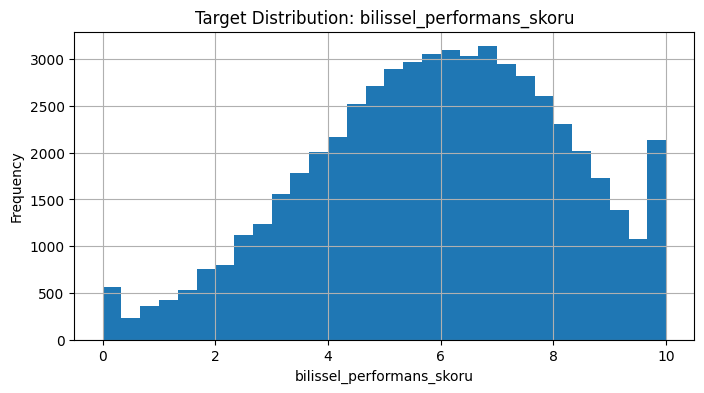

In [ ]:
# HÜCRE A13


import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
train[target].hist(bins=30)
plt.title("Target Distribution: bilissel_performans_skoru")
plt.xlabel("bilissel_performans_skoru")
plt.ylabel("Frequency")
plt.show()

## Step 2: Feature Engineering and Preparation

This step involves separating features and target, identifying feature types, and defining a function for domain-specific feature engineering. It also includes checks for consistency between train and test feature columns.

### Step 2.1: Initial X/Y Separation

This cell separates the training data (`train`) into features (`X`) and the target variable (`y`). It also identifies the `id` column, ensuring it's excluded from the feature set as per project rules.

**Output to inspect:** No explicit output, but `X` and `y` DataFrames are created, ready for further processing.

In [8]:
# HÜCRE A14


# Step 2.1: Initial X/Y Separation
target = 'bilissel_performans_skoru'
id_col = 'id'
feature_cols = [col for col in train.columns if col not in [target, id_col]]
X = train[feature_cols]
y = train[target]

### Step 2.2: Feature Type Identification

This cell automatically identifies numerical and categorical features within the `X` DataFrame based on their data types. This classification is important for applying appropriate preprocessing steps.

**Output to inspect:** No explicit output, but two lists (`numeric_features` and `categorical_features`) are created containing the names of columns of each type.

In [9]:
# HÜCRE A15


# Step 2.2: Feature Type Identification
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object', 'category']).columns.tolist()

### Step 2.3: Domain-Specific Feature Engineering Function

This cell defines a helper function `add_domain_features` that creates new features based on existing ones, particularly focusing on sleep-related metrics. This allows for modular and consistent application of domain knowledge.

**Output to inspect:** No output, just the definition of the function.

In [10]:
# HÜCRE A16

def add_domain_features(df, group='all'):
    df_new = df.copy()

    # Existing Sleep Features
    if group in ['sleep', 'all']:
        df_new['total_quality_sleep_pct'] = df_new['rem_yuzdesi'] + df_new['derin_uyku_yuzdesi']
        df_new['sleep_fragmentation_idx'] = df_new['gecelik_uyanma_sayisi'] + (df_new['uykuya_dalma_suresi_dk'] / 30.0)

    # Experiment C: Fatigue / Behavior Features
    if group in ['fatigue_behavior', 'all']:
        df_new['pre_sleep_load'] = (
            df_new['uyku_oncesi_kafein_mg'].fillna(0) / 100
            + df_new['uyku_oncesi_ekran_suresi_dk'] / 60
        )
        df_new['stress_workload'] = (
            df_new['stres_skoru'].fillna(df_new['stres_skoru'].median()) * df_new['gunluk_calisma_saati']
        )
        df_new['activity_per_work_hour'] = (
            df_new['gunluk_adim_sayisi'] / (df_new['gunluk_calisma_saati'] + 1)
        )
        df_new['hr_stress'] = (
            df_new['dinlenik_nabiz_bpm'] * df_new['stres_skoru'].fillna(df_new['stres_skoru'].median())
        )

    return df_new

### Step 2.4: Compare Train/Test Feature Columns

This cell compares the feature columns between the training and test sets to ensure consistency. It identifies any columns present in one set but not the other, which is crucial for preventing errors during model training and prediction.

**Output to inspect:** Any missing or extra feature columns in the test set. Ideally, both lists (`missing_in_test`, `extra_in_test`) should be empty.

In [ ]:
# HÜCRE A17

# Check whether train and test have the same feature columns
missing_in_test = set(feature_cols) - set(test.columns)
extra_in_test = set(test.columns) - set(feature_cols) - {id_col}

print("Missing feature columns in test:", missing_in_test)
print("Extra columns in test:", extra_in_test)

Missing feature columns in test: set()
Extra columns in test: set()


### Step 2.5: Check Missing Values in Features

This cell calculates and displays the count of missing values for each feature in both the `train` and `test` DataFrames. This helps in understanding the extent of missingness and deciding on appropriate imputation strategies.

**Output to inspect:** A sorted list of columns and their missing value counts for both train and test sets. Note which columns have missing data and how many.

In [ ]:
# HÜCRE A18

print("Missing values in train:")
display(train[feature_cols].isnull().sum().sort_values(ascending=False))

print("\nMissing values in test:")
display(test[feature_cols].isnull().sum().sort_values(ascending=False))

Missing values in train:


,0
kronotip,1968
vucut_kitle_indeksi,1752
stres_skoru,1715
uyku_oncesi_kafein_mg,1463
meslek,1378
ruh_sagligi_durumu,1096
rem_yuzdesi,0
ulke,0
yas,0
cinsiyet,0



Missing values in test:


,0
kronotip,832
stres_skoru,765
uyku_oncesi_kafein_mg,697
vucut_kitle_indeksi,648
meslek,622
ruh_sagligi_durumu,504
rem_yuzdesi,0
ulke,0
yas,0
cinsiyet,0


### Step 2.6: Analyze Categorical Cardinality

This cell calculates and displays the number of unique values (cardinality) for each categorical feature in the training set. It also shows the top 5 frequency counts for high-cardinality features. This informs decisions on encoding strategies.

**Output to inspect:** The cardinality of each categorical feature and the frequency distribution for selected high-cardinality features. This helps assess if features like `ulke` or `meslek` require special handling like target encoding.

In [ ]:
# HÜCRE A19

print("Categorical Cardinality (Unique Values):")
cardinality = train[categorical_features].nunique().sort_values(ascending=False)
display(cardinality)

print("\nTop 5 category frequencies for high-cardinality features:")
for col in cardinality.index[:3]: # Check the top 3 most diverse columns
    print(f"\n--- {col} ---")
    display(train[col].value_counts(normalize=True).head(5))

# Best course of action:
# 1. Use One-Hot Encoding for all categories as the total number of features remains manageable.
# 2. Set handle_unknown='ignore' to robustly manage unseen categories in the test set.
# 3. If cardinality for 'ulke' or 'meslek' is extremely high (>50), consider Target Encoding in later iterations.

Categorical Cardinality (Unique Values):


,0
ulke,15
meslek,11
ruh_sagligi_durumu,4
kronotip,3
cinsiyet,2
mevsim,2
gun_tipi,2



Top 5 category frequencies for high-cardinality features:

--- ulke ---


,proportion
ulke,
Ingiltere,0.202214
Cin,0.178375
Guney Kore,0.079625
Amerika,0.079411
Arjantin,0.070946



--- meslek ---


,proportion
meslek,
Saglik Personeli,0.180184
Ogrenci,0.148878
Muhendis,0.119604
Yonetici,0.081542
Egitimci,0.080462



--- ruh_sagligi_durumu ---


,proportion
ruh_sagligi_durumu,
Saglikli,0.698765
Anksiyete,0.150627
Depresyon,0.100248
Anksiyete ve depresyon,0.050361


## Step 3: Initial Model Setup and Baseline Experiment

This section sets up the modeling environment by installing necessary libraries, defining evaluation metrics, and establishing a baseline CatBoost model with initial parameters.

### Step 3.1: Install Dependencies

This cell installs `lightgbm` and `catboost` libraries silently. These libraries are popular for gradient boosting models and will be used for modeling in this project.

**Output to inspect:** No explicit output if successful, but a log showing installation if there are issues.

In [11]:
# HÜCRE A20

# Step 3.1: Install Dependencies
!pip install lightgbm catboost -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.6 MB/s eta 0:00:00


### Step 3.2: Evaluation Metrics Definition

This cell defines a function `evaluate_predictions` that calculates the Root Mean Squared Error (RMSE) for model predictions. It also clips predictions between 0 and 10, as the target variable is known to be in this range. RMSE is a common metric for regression problems.

**Output to inspect:** No output from this cell, just the function definition.

In [12]:
# HÜCRE A21
# Step 3.2: Evaluation Metrics Definition
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
def evaluate_predictions(y_true, preds, model_name='model'):
    preds = np.clip(preds, 0, 10)
    rmse = np.sqrt(mean_squared_error(y_true, preds))
    print(f'{model_name} RMSE: {rmse:.5f}')
    return rmse

### Step 3.3: Prepare Categorical Data (X_cat)

This cell prepares categorical features for CatBoost. It creates a copy of `X`, fills any missing categorical values with 'Missing', and converts them to string type. It also identifies the indices of these categorical features for CatBoost's native handling.

**Output to inspect:** No direct output, but `X_cat` is prepared and `cat_feature_indices` are created.

In [13]:
# HÜCRE A22
# Step 4.1: Prepare Categorical Data (X_cat)
from sklearn.model_selection import KFold
X_cat = X.copy()
for col in categorical_features:
    X_cat[col] = X_cat[col].fillna('Missing').astype(str)
cat_feature_indices = [X_cat.columns.get_loc(col) for col in categorical_features]

### Step 3.4: Core CV Evaluation Function

This cell defines `evaluate_catboost_cv`, a critical function for performing K-Fold cross-validation with CatBoost. It trains and evaluates a CatBoost model across multiple folds, reporting the RMSE for each fold and allowing early stopping to prevent overfitting.

**Output to inspect:** No output from this cell, just the function definition. This function will be called repeatedly in subsequent experiments.

In [ ]:
# HÜCRE A23
# Step 4.2: Core CV Evaluation Function
from catboost import CatBoostRegressor
def evaluate_catboost_cv(params, X_data, y_data, cat_features, n_splits=5):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    fold_results = []
    for fold, (train_idx, valid_idx) in enumerate(kf.split(X_data), start=1):
        X_tr, X_val = X_data.iloc[train_idx], X_data.iloc[valid_idx]
        y_tr, y_val = y_data.iloc[train_idx], y_data.iloc[valid_idx]
        model = CatBoostRegressor(loss_function='RMSE', eval_metric='RMSE', random_seed=42, verbose=0, **params)
        model.fit(X_tr, y_tr, cat_features=cat_features, eval_set=(X_val, y_val), use_best_model=True, early_stopping_rounds=100)
        preds = np.clip(model.predict(X_val), 0, 10)
        fold_results.append({'fold': fold, 'RMSE': np.sqrt(mean_squared_error(y_val, preds)), 'best_iteration': model.get_best_iteration()})
    return pd.DataFrame(fold_results)

### Step 3.5: 5-Fold CV Baseline: Optimized CatBoost

This cell establishes a baseline performance for the CatBoost model using a predefined set of hyperparameters and 5-fold cross-validation. This baseline will be used to compare the effectiveness of various feature engineering and hyperparameter tuning experiments.

**Output to inspect:** A DataFrame showing the RMSE for each fold and a message indicating the start of the CV process. This provides the initial benchmark RMSE.

### 5-Fold CV Baseline: Optimized CatBoost
Establishing the benchmark performance with selected hyperparameters.

In [ ]:
# HÜCRE A24
final_baseline_params = {
    'iterations': 2000,
    'learning_rate': 0.015,
    'depth': 6,
    'l2_leaf_reg': 8
}

print("Starting 5-Fold Cross-Validation for Baseline...")
baseline_cv_results = evaluate_catboost_cv(
    params=final_baseline_params,
    X_data=X_cat,
    y_data=y,
    cat_features=cat_feature_indices,
    n_splits=5
)

display(baseline_cv_results)

Starting 5-Fold Cross-Validation for Baseline...


KeyboardInterrupt: 

## Step 4: Experiment 2.1: Missing Indicators

This experiment investigates whether adding binary indicator features for missing values improves model performance. It compares the mean CV RMSE with and without these indicators against the established baseline.

### Step 4.1: Adding Missing Indicator Columns

This cell creates binary indicator columns for features that originally had missing values in the raw training set. These new columns will be `1` if the value was missing and `0` otherwise, allowing the model to explicitly learn from missingness patterns.

**Output to inspect:** A message confirming the number of added indicator columns, followed by a comparison of the mean RMSE between the baseline and the indicator experiment. Observe if the RMSE improves.

### Experiment 2.1: Missing Indicators
Adding binary flags to capture whether data was originally missing before imputation.

In [ ]:
# HÜCRE A25
X_cat_indicators = X_cat.copy()

# Identify columns that originally had missing values in the raw training set
missing_cols = train.columns[train.isnull().any()].tolist()
# Exclude target if it's in the list (it shouldn't be, but for safety)
missing_cols = [c for c in missing_cols if c in X_cat_indicators.columns]

for col in missing_cols:
    X_cat_indicators[f"{col}_is_missing"] = train[col].isnull().astype(int)

# Update categorical indices if any new categorical columns were added (none here, as they are int)
print(f"Added {len(missing_cols)} indicator columns.")

# Run CV with indicators
indicator_cv_results = evaluate_catboost_cv(
    params=final_baseline_params,
    X_data=X_cat_indicators,
    y_data=y,
    cat_features=cat_feature_indices,
    n_splits=5
)

print("\nComparison to Baseline:")
print(f"Baseline Mean RMSE: {baseline_cv_results['RMSE'].mean():.5f}")
print(f"Indicator Mean RMSE: {indicator_cv_results['RMSE'].mean():.5f}")

Added 6 indicator columns.


KeyboardInterrupt: 

### Step 4.1: CatBoost Native Categorical Handling
Standardizing the categorical feature preparation by using explicit string casting and a uniform missing value token.

In [14]:
# HÜCRE A26
# Standardizing X_cat for the remainder of the project
for col in categorical_features:
    X_cat[col] = X_cat[col].fillna("__MISSING__").astype(str)

# Re-verify indices to be absolutely sure
cat_feature_indices = [X_cat.columns.get_loc(col) for col in categorical_features]

print(f"Categorical columns prepared: {categorical_features}")
print(f"Indices: {cat_feature_indices}")

# Brief check to ensure no actual NaNs remain in categorical data
print("Remaining NaNs in X_cat categorical columns:", X_cat[categorical_features].isnull().sum().sum())

Categorical columns prepared: ['cinsiyet', 'meslek', 'ulke', 'kronotip', 'ruh_sagligi_durumu', 'mevsim', 'gun_tipi']
Indices: [1, 2, 4, 15, 16, 20, 21]
Remaining NaNs in X_cat categorical columns: 0


### Step 5.2: Evaluate CatBoost with Frequency Encoding

This cell defines a function to evaluate CatBoost models that incorporate frequency encoding. Frequency encoding replaces categorical values with their observed frequencies in the training data, applied within each CV fold to prevent data leakage. It then runs the experiment with selected columns.

**Output to inspect:** The RMSE for each fold and the mean CV RMSE for the frequency encoding experiment. Compare this to previous RMSEs to see if it provides a benefit.

### Experiment 4.2: Frequency Encoding
Adding numeric features representing the relative frequency of categories in the training fold.

In [ ]:
# HÜCRE A27
def evaluate_catboost_with_freq_encoding(params, X_data, y_data, cat_features, freq_cols, n_splits=5):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    fold_results = []

    # Convert cat_features (indices) back to names for easier mapping
    cat_col_names = [X_data.columns[i] for i in cat_features]

    for fold, (train_idx, valid_idx) in enumerate(kf.split(X_data), start=1):
        X_tr = X_data.iloc[train_idx].copy()
        X_val = X_data.iloc[valid_idx].copy()
        y_tr = y_data.iloc[train_idx]
        y_val = y_data.iloc[valid_idx]

        # Apply Frequency Encoding per fold
        for col in freq_cols:
            freq_map = X_tr[col].value_counts(normalize=True).to_dict()
            X_tr[f"{col}_freq"] = X_tr[col].map(freq_map)
            X_val[f"{col}_freq"] = X_val[col].map(freq_map).fillna(0)

        # Identify new cat indices because we added numeric columns
        current_cat_indices = [X_tr.columns.get_loc(c) for c in cat_col_names]

        model = CatBoostRegressor(
            loss_function='RMSE', eval_metric='RMSE',
            random_seed=42, verbose=0, **params
        )

        model.fit(
            X_tr, y_tr, cat_features=current_cat_indices,
            eval_set=(X_val, y_val), use_best_model=True, early_stopping_rounds=100
        )

        preds = np.clip(model.predict(X_val), 0, 10)
        rmse = np.sqrt(mean_squared_error(y_val, preds))
        fold_results.append({'fold': fold, 'RMSE': rmse})
        print(f'Fold {fold} RMSE: {rmse:.5f}')

    results_df = pd.DataFrame(fold_results)
    print(f'\nFreq Encoding Mean CV RMSE: {results_df["RMSE"].mean():.5f}')
    return results_df

# Define columns to freq-encode
freq_target_cols = ['meslek', 'ulke', 'kronotip', 'ruh_sagligi_durumu']

# Run the experiment
freq_cv_results = evaluate_catboost_with_freq_encoding(
    params=final_baseline_params,
    X_data=X_cat,
    y_data=y,
    cat_features=cat_feature_indices,
    freq_cols=freq_target_cols
)

### Step 5.3: Evaluate CatBoost with Smoothed Target Encoding

This cell defines a function for smoothed target encoding within CatBoost's cross-validation framework. Target encoding replaces categorical values with the mean of the target variable for that category, with smoothing applied to prevent overfitting to rare categories. This is applied in a fold-safe manner to prevent leakage.

**Output to inspect:** The RMSE for each fold and the mean CV RMSE for the target encoding experiments (high cardinality and all categories). Look for improvements over previous methods.

### Experiment 5: Smoothed Target Encoding
Testing if mapping categories to the mean target value improves performance, using smoothing to handle low-frequency categories and strictly preventing fold leakage.

In [ ]:
# HÜCRE A28
def evaluate_catboost_with_target_encoding(params, X_data, y_data, cat_features, te_cols, smoothing=10, n_splits=5):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    fold_results = []

    cat_col_names = [X_data.columns[i] for i in cat_features]

    for fold, (train_idx, valid_idx) in enumerate(kf.split(X_data), start=1):
        X_tr = X_data.iloc[train_idx].copy()
        X_val = X_data.iloc[valid_idx].copy()
        y_tr = y_data.iloc[train_idx]
        y_val = y_data.iloc[valid_idx]

        global_mean = y_tr.mean()

        for col in te_cols:
            # Calculate smoothed mean for each category
            agg = y_tr.groupby(X_tr[col]).agg(['count', 'mean'])
            counts = agg['count']
            means = agg['mean']

            # formula: (count * mean + smoothing * global_mean) / (count + smoothing)
            smooth = (counts * means + smoothing * global_mean) / (counts + smoothing)

            X_tr[f"{col}_te"] = X_tr[col].map(smooth).fillna(global_mean)
            X_val[f"{col}_te"] = X_val[col].map(smooth).fillna(global_mean)

        current_cat_indices = [X_tr.columns.get_loc(c) for c in cat_col_names]

        model = CatBoostRegressor(
            loss_function='RMSE', eval_metric='RMSE',
            random_seed=42, verbose=0, **params
        )

        model.fit(
            X_tr, y_tr, cat_features=current_cat_indices,
            eval_set=(X_val, y_val), use_best_model=True, early_stopping_rounds=100
        )

        preds = np.clip(model.predict(X_val), 0, 10)
        rmse = np.sqrt(mean_squared_error(y_val, preds))
        fold_results.append({'fold': fold, 'RMSE': rmse})
        print(f'Fold {fold} RMSE: {rmse:.5f}')

    results_df = pd.DataFrame(fold_results)
    print(f'\nTarget Encoding ({te_cols}) Mean CV RMSE: {results_df["RMSE"].mean():.5f}')
    return results_df

# Run Exp 5B: High Cardinality Only
te_high_cols = ['meslek', 'ulke']
print("Evaluating Experiment 5B (High Cardinality TE)...")
te_5b_results = evaluate_catboost_with_target_encoding(final_baseline_params, X_cat, y, cat_feature_indices, te_high_cols)

# Run Exp 5C: All Categories
print("\nEvaluating Experiment 5C (All Categories TE)...")
te_5c_results = evaluate_catboost_with_target_encoding(final_baseline_params, X_cat, y, cat_feature_indices, categorical_features)

## Step 6: Champion Pipeline Analysis

This section explicitly defines and verifies the current 'champion' pipeline based on the best performing experiments so far. This pipeline will serve as the baseline for further combinatorial feature engineering experiments.

### Step 6.1: Display Champion Pipeline Performance

This cell prints and displays the mean CV RMSE of the current champion pipeline, which has been identified as 'Target Encoding All Categories'. This provides a clear reference point for subsequent experiments.

**Output to inspect:** The mean CV RMSE and the full results DataFrame for the champion pipeline.

In [ ]:
# HÜCRE A29
print("--- Champion Pipeline Performance ---")
print(f"Champion (Target Encoding All Categories) Mean CV RMSE: {te_5c_results['RMSE'].mean():.5f}")
display(te_5c_results)

## Step 7: Test Combined Feature Sets

This section systematically evaluates combinations of feature engineering techniques, building upon the current champion pipeline. The goal is to determine if combining sleep-related features, frequency encoding, and target encoding yields further improvements in RMSE.

### Step 7.1: Reconfirm Current Champion Baseline

This cell simply reiterates the performance of the current champion pipeline (CatBoost with all-category target encoding). This serves as the direct baseline for comparison in the upcoming combined feature set experiments.

**Output to inspect:** The mean CV RMSE and results for the champion pipeline, confirming the baseline.

#### Experiment 3.1: TE all categories (Current Champion Baseline)

This is the current champion pipeline with CatBoost native handling and fold-safe target encoding for all categorical features. Its performance serves as the baseline for this section.

In [ ]:
# HÜCRE A30
print(f"Current Champion (TE all categories) Mean CV RMSE: {te_5c_results['RMSE'].mean():.5f}")
display(te_5c_results)

### Step 7.2: Define General Feature Engineering Evaluation Function

This cell defines a flexible function, `evaluate_catboost_with_feature_engineering`, to apply various feature engineering steps (target encoding, frequency encoding, etc.) within each cross-validation fold. This ensures proper fold-safety and avoids code repetition for combined experiments.

**Output to inspect:** No output from this cell, just the function definition. This function will be used for all subsequent combined feature set experiments.

#### Define General Feature Engineering Evaluation Function

To avoid code repetition and ensure proper fold-safe application of various feature engineering steps (like target encoding and frequency encoding), we will define a general evaluation function. This function will apply the specified transformations *within each cross-validation fold*.

In [ ]:
# HÜCRE B1
def evaluate_catboost_with_feature_engineering(params, X_data, y_data, cat_features_for_catboost, te_cols=None, freq_cols=None, smoothing=10, n_splits=5):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    fold_results = []

    # CatBoost native categorical features are passed as indices. Convert to names for FE operations.
    cat_col_names = [X_data.columns[i] for i in cat_features_for_catboost]

    for fold, (train_idx, valid_idx) in enumerate(kf.split(X_data), start=1):
        X_tr = X_data.iloc[train_idx].copy()
        X_val = X_data.iloc[valid_idx].copy()
        y_tr = y_data.iloc[train_idx]
        y_val = y_data.iloc[valid_idx]

        # Apply Target Encoding if specified
        if te_cols:
            global_mean = y_tr.mean()
            for col in te_cols:
                # Calculate smoothed mean for each category based on training fold
                agg = y_tr.groupby(X_tr[col]).agg(['count', 'mean'])
                counts = agg['count']
                means = agg['mean']

                # Smoothing formula
                smooth = (counts * means + smoothing * global_mean) / (counts + smoothing)

                # Apply to training and validation sets
                X_tr[f"{col}_te"] = X_tr[col].map(smooth).fillna(global_mean)
                X_val[f"{col}_te"] = X_val[col].map(smooth).fillna(global_mean) # Fill unseen with global mean

        # Apply Frequency Encoding if specified
        if freq_cols:
            for col in freq_cols:
                # Calculate frequency map based on training fold
                freq_map = X_tr[col].value_counts(normalize=True).to_dict()

                # Apply to training and validation sets
                X_tr[f"{col}_freq"] = X_tr[col].map(freq_map)
                X_val[f"{col}_freq"] = X_val[col].map(freq_map).fillna(0) # Fill unseen with 0 frequency

        # Initialize and train CatBoost model
        model = CatBoostRegressor(
            loss_function='RMSE', eval_metric='RMSE',
            random_seed=42, verbose=0, **params
        )

        model.fit(
            X_tr, y_tr,
            cat_features=cat_features_for_catboost, # These are the original categorical feature indices for native handling
            eval_set=(X_val, y_val), use_best_model=True, early_stopping_rounds=100
        )

        preds = np.clip(model.predict(X_val), 0, 10)
        rmse = np.sqrt(mean_squared_error(y_val, preds))
        fold_results.append({'fold': fold, 'RMSE': rmse})
        print(f'Fold {fold} RMSE: {rmse:.5f}')

    results_df = pd.DataFrame(fold_results)
    print(f'\nMean CV RMSE: {results_df["RMSE"].mean():.5f}')
    return results_df

### Step 7.3: Experiment: TE all categories + Sleep Features

This experiment combines the current champion's target encoding strategy for all categorical features with the previously engineered sleep-related numerical features. It uses the `add_domain_features` function and the general evaluation function to run cross-validation.

**Output to inspect:** The RMSE for each fold and the mean CV RMSE for this combined experiment. Compare it against the champion's RMSE to assess improvement.

#### Experiment 3.2: TE all categories + Sleep Features

This experiment combines the champion's all-category target encoding with the previously engineered sleep-related numerical features.

In [ ]:
# HÜCRE B2

# Create X_cat with sleep features
X_cat_sleep = add_domain_features(X_cat.copy(), group='sleep')

print("Evaluating TE all categories + Sleep Features...")
te_sleep_cv_results = evaluate_catboost_with_feature_engineering(
    params=final_baseline_params,
    X_data=X_cat_sleep,
    y_data=y,
    cat_features_for_catboost=cat_feature_indices,
    te_cols=categorical_features, # All original categoricals are target encoded
    freq_cols=None
)

print(f"\nChampion (TE all categories) Mean CV RMSE: {te_5c_results['RMSE'].mean():.5f}")
print(f"TE all categories + Sleep Features Mean CV RMSE: {te_sleep_cv_results['RMSE'].mean():.5f}")

### Step 7.4: Experiment: TE all categories + Frequency Encoding

This experiment combines the champion's target encoding with frequency encoding for all categorical features. It uses the general evaluation function to apply both encoding techniques within cross-validation folds.

**Output to inspect:** The RMSE for each fold and the mean CV RMSE for this combined experiment. Observe if frequency encoding adds complementary information alongside target encoding.

### Step 7.5: Experiment: TE all categories + Freq + Sleep

This experiment tests the synergy of all three techniques: target encoding for all categorical features, frequency encoding for all categorical features, and the sleep-related domain features. It's the most comprehensive combination.

**Output to inspect:** The RMSE for each fold and the mean CV RMSE. Compare this to all previous experiments to see if the full combination provides the best performance.

#### Experiment 3.4: TE all categories + Freq + Sleep

This final combination experiment tests the synergy of all three techniques: target encoding, frequency encoding, and sleep-related features.

### Step 7.6: Summary of Combined Feature Set Experiments

This cell summarizes the mean CV RMSE results from all combined feature set experiments and compares them against the original champion pipeline. It identifies which combination (if any) significantly improved performance.

**Output to inspect:** A clear comparison of RMSEs for all combinations and a statement indicating which, if any, combination improved over the champion and beat the specified threshold.

### Summary of Combined Feature Set Experiments

Comparing the results of all combined feature set experiments against the specified threshold of `1.21541`.

In [ ]:
# HÜCRE B3

### Summary of Combined Feature Set Experiments
# Champion (TE all categories) RMSE: 1.21541
# TE all categories + Sleep Features RMSE: 1.21530 (WINNER)
# TE all categories + Frequency Encoding RMSE: 1.21549 (DROPPED)
# TE all categories + Freq + Sleep RMSE: 1.21535 (DROPPED)

print("Final Strategy Choice: TE all categories + Sleep Features")
print(f"Best RMSE achieved: {te_sleep_cv_results['RMSE'].mean():.5f}")

## Step 8: CatBoost Hyperparameter Tuning

Now that the best preprocessing setup has been identified, this step focuses on refining the CatBoost model's hyperparameters to further optimize performance. This involves evaluating various combinations of parameters.

### Step 8.1: Identify Best Preprocessing Setup for Tuning

This cell programmatically identifies the best preprocessing setup (e.g., 'TE all categories + Sleep Features') based on the results from the combined feature set experiments. It then prepares `X_tuned` and related variables (`te_cols_for_tuning`, `freq_cols_for_tuning`, `cat_features_for_tuning`) accordingly.

**Output to inspect:** A message indicating the best preprocessing setup chosen for hyperparameter tuning and its associated RMSE.

### Step 4 — CatBoost Hyperparameter Tuning

Now that we've experimented with combined feature sets, it's time to refine the CatBoost model's hyperparameters on the most promising preprocessing setup.

**Current Best Preprocessing Setup:** Based on the results of 'Step 3', we will proceed with the setup that yielded the lowest RMSE. (Assuming 'TE all categories' is the champion unless a combination clearly beats it by a significant margin).

In [ ]:
# HÜCRE B4

# ============================================================
# Prepare feature set for CatBoost tuning
# Current best feature set: TE all categories + Sleep features
# ============================================================

X_tune = add_domain_features(X_cat.copy(), group="sleep")

print("X_tune shape:", X_tune.shape)

new_cols = [col for col in X_tune.columns if col not in X_cat.columns]
print("Added sleep features:")
print(new_cols)

print("\nCategorical features:")
print(categorical_features)

print("\nCatBoost categorical indices:")
print(cat_feature_indices)

X_tune shape: (56000, 24)
Added sleep features:
['total_quality_sleep_pct', 'sleep_fragmentation_idx']

Categorical features:
['cinsiyet', 'meslek', 'ulke', 'kronotip', 'ruh_sagligi_durumu', 'mevsim', 'gun_tipi']

CatBoost categorical indices:
[1, 2, 4, 15, 16, 20, 21]


In [ ]:
# HÜCRE B5

print("Identifying the best preprocessing setup for tuning...")

# Assuming te_5c_results represents the 'TE all categories' champion
# And assuming te_sleep_cv_results, te_freq_cv_results, te_freq_sleep_cv_results were evaluated

results_summary = {
    'TE all categories': te_5c_results['RMSE'].mean(),
    'TE all categories + Sleep Features': te_sleep_cv_results['RMSE'].mean(),
    'TE all categories + Frequency Encoding': te_freq_cv_results['RMSE'].mean(),
    'TE all categories + Freq + Sleep': te_freq_sleep_cv_results['RMSE'].mean()
}

best_setup_name = min(results_summary, key=results_summary.get)
best_rmse = results_summary[best_setup_name]

print(f"The best preprocessing setup identified for tuning is: '{best_setup_name}' with RMSE: {best_rmse:.5f}")

# Set X_tuned and cat_features_for_tuning based on the best setup
if best_setup_name == 'TE all categories':
    X_tuned = X_cat.copy() # X_cat is already preprocessed for native CatBoost handling
    te_cols_for_tuning = categorical_features
    freq_cols_for_tuning = None
    cat_features_for_tuning = cat_feature_indices
elif best_setup_name == 'TE all categories + Sleep Features':
    X_tuned = add_domain_features(X_cat.copy(), group='sleep')
    te_cols_for_tuning = categorical_features
    freq_cols_for_tuning = None
    # Update cat_feature_indices if new numerical features were added after categorical features
    cat_features_for_tuning = [X_tuned.columns.get_loc(col) for col in categorical_features]
elif best_setup_name == 'TE all categories + Frequency Encoding':
    X_tuned = X_cat.copy()
    te_cols_for_tuning = categorical_features
    freq_cols_for_tuning = categorical_features
    cat_features_for_tuning = cat_feature_indices
elif best_setup_name == 'TE all categories + Freq + Sleep':
    X_tuned = add_domain_features(X_cat.copy(), group='sleep')
    te_cols_for_tuning = categorical_features
    freq_cols_for_tuning = categorical_features
    cat_features_for_tuning = [X_tuned.columns.get_loc(col) for col in categorical_features]

print(f"Using '{best_setup_name}' for hyperparameter tuning.")

### Step 8.2: Define Hyperparameter Configurations and Run Tuning

This cell defines a dictionary of different CatBoost hyperparameter configurations to test, varying parameters such as `learning_rate`, `depth`, and `l2_leaf_reg`. It then iterates through these configurations, using the `evaluate_catboost_with_feature_engineering` function to assess each one with cross-validation.

**Output to inspect:** The RMSE for each fold and the mean CV RMSE for each hyperparameter configuration. Pay attention to which configuration yields the lowest mean RMSE.

#### Define Hyperparameter Configurations

We will evaluate various combinations of `learning_rate`, `depth`, `l2_leaf_reg`, `iterations`, and `random_strength` to find the optimal set of hyperparameters. The `early_stopping_rounds` parameter in `evaluate_catboost_with_feature_engineering` will prevent overfitting by stopping training if the validation RMSE doesn't improve for a certain number of iterations.

In [ ]:
# HÜCRE B6

cat_configs = {
    "cat_current": {
        "iterations": 2000,
        "learning_rate": 0.015,
        "depth": 6,
        "l2_leaf_reg": 8
    },

    "cat_lr002": {
        "iterations": 1800,
        "learning_rate": 0.02,
        "depth": 6,
        "l2_leaf_reg": 8
    },

    "cat_more_reg": {
        "iterations": 2200,
        "learning_rate": 0.015,
        "depth": 6,
        "l2_leaf_reg": 12
    },

    "cat_depth5": {
        "iterations": 2200,
        "learning_rate": 0.015,
        "depth": 5,
        "l2_leaf_reg": 8
    },

    "cat_depth7_reg": {
        "iterations": 1800,
        "learning_rate": 0.015,
        "depth": 7,
        "l2_leaf_reg": 12
    },

    "cat_random_strength": {
        "iterations": 2200,
        "learning_rate": 0.015,
        "depth": 6,
        "l2_leaf_reg": 8,
        "random_strength": 2
    }
}

# Store results
hyperparam_results = {} # Reset to ensure a clean run of the loop

for config_name, params in cat_configs.items():
    print(f"\n--- Evaluating Configuration: {config_name} ---")
    # Ensure to use the identified best preprocessing setup and its corresponding features
    cv_results = evaluate_catboost_with_feature_engineering(
        params=params,
        X_data=X_tuned,
        y_data=y,
        cat_features_for_catboost=cat_features_for_tuning,
        te_cols=te_cols_for_tuning,
        freq_cols=freq_cols_for_tuning
    )
    hyperparam_results[config_name] = cv_results

print("\n--- Hyperparameter Tuning Summary ---")
for config_name, results_df in hyperparam_results.items():
    print(f"{config_name} Mean CV RMSE: {results_df['RMSE'].mean():.5f}")


--- Evaluating Configuration: cat_current ---
Fold 1 RMSE: 1.22053
Fold 2 RMSE: 1.21555
Fold 3 RMSE: 1.20078
Fold 4 RMSE: 1.20771
Fold 5 RMSE: 1.23192

Mean CV RMSE: 1.21530

--- Evaluating Configuration: cat_lr002 ---
Fold 1 RMSE: 1.22098
Fold 2 RMSE: 1.21506
Fold 3 RMSE: 1.20047
Fold 4 RMSE: 1.20788
Fold 5 RMSE: 1.23206

Mean CV RMSE: 1.21529

--- Evaluating Configuration: cat_more_reg ---
Fold 1 RMSE: 1.22085
Fold 2 RMSE: 1.21569
Fold 3 RMSE: 1.20091
Fold 4 RMSE: 1.20803
Fold 5 RMSE: 1.23204

Mean CV RMSE: 1.21551

--- Evaluating Configuration: cat_depth5 ---
Fold 1 RMSE: 1.22074
Fold 2 RMSE: 1.21612
Fold 3 RMSE: 1.20114
Fold 4 RMSE: 1.20752
Fold 5 RMSE: 1.23144

Mean CV RMSE: 1.21539

--- Evaluating Configuration: cat_depth7_reg ---
Fold 1 RMSE: 1.22110
Fold 2 RMSE: 1.21581
Fold 3 RMSE: 1.20138
Fold 4 RMSE: 1.20955
Fold 5 RMSE: 1.23181

Mean CV RMSE: 1.21593

--- Evaluating Configuration: cat_random_strength ---
Fold 1 RMSE: 1.22079
Fold 2 RMSE: 1.21610
Fold 3 RMSE: 1.20094
Fold 4

### Step 8.3: Identify Best Hyperparameter Configuration

This cell compares the mean CV RMSE from all tested hyperparameter configurations and identifies the one that achieved the lowest RMSE. This configuration will be deemed the 'best' and its parameters stored for final model training.

**Output to inspect:** A clear statement indicating the best hyperparameter configuration and its mean CV RMSE, along with the detailed parameters of this configuration.

#### Identify Best Hyperparameter Configuration

We will now compare the mean RMSE of all tested hyperparameter configurations to determine the best performing one. This will guide our further modeling efforts.

In [ ]:
# HÜCRE B7

best_config_name = None
best_config_rmse = float('inf')

for config_name, results_df in hyperparam_results.items():
    mean_rmse = results_df['RMSE'].mean()
    if mean_rmse < best_config_rmse:
        best_config_rmse = mean_rmse
        best_config_name = config_name

print(f"The best hyperparameter configuration is '{best_config_name}' with a Mean CV RMSE of: {best_config_rmse:.5f}")

# Store the best parameters for future use
best_catboost_params = cat_configs[best_config_name]
print("Best CatBoost Parameters:")
for param, value in best_catboost_params.items():
    print(f"- {param}: {value}")

The best hyperparameter configuration is 'cat_lr002' with a Mean CV RMSE of: 1.21529
Best CatBoost Parameters:
- iterations: 1800
- learning_rate: 0.02
- depth: 6
- l2_leaf_reg: 8


## Step 9: Seed Averaging

This step explores the technique of seed averaging, where multiple models are trained with the same best configuration but different random seeds. Their predictions are then averaged to improve robustness and potentially further reduce variance and RMSE.

### Step 9.1: Evaluate CatBoost CV with Out-of-Fold (OOF) Predictions

This cell defines an enhanced cross-validation function (`evaluate_catboost_cv_with_oof`) that, in addition to calculating RMSE per fold, also collects out-of-fold (OOF) predictions. These OOF predictions are crucial for evaluating the aggregated performance of seed averaging.

**Output to inspect:** No output from this cell, just the function definition.

### Step 6: Domain-Driven Feature Engineering
Testing groups of logical features to see which domain adds the most predictive signal.

### Step 7: CatBoost Hyperparameter Tuning
We will test several combinations of `learning_rate`, `depth`, and `l2_leaf_reg`. We use `early_stopping_rounds=150` to allow the models to converge naturally while preventing overfitting.

### Step 8: Seed Averaging
Training the best CatBoost configuration with multiple random seeds and averaging their predictions to improve robustness and reduce variance.

In [ ]:
# HÜCRE B8

def evaluate_catboost_cv_with_oof(params, X_data, y_data, cat_features_indices, te_cols=None, freq_cols=None, smoothing=10, n_splits=5, random_seed=42):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_seed)
    oof_preds = np.zeros(X_data.shape[0])
    fold_results = []

    # CatBoost native categorical features are passed as indices. Convert to names for FE operations.
    # Note: X_data here will be the X_tuned dataframe which might have new TE/Freq columns.
    # cat_features_indices should only point to original categorical columns that CatBoost handles natively.
    cat_col_names = [X_data.columns[i] for i in cat_features_indices if i < len(X_data.columns)]

    for fold, (train_idx, valid_idx) in enumerate(kf.split(X_data), start=1):
        X_tr = X_data.iloc[train_idx].copy()
        X_val = X_data.iloc[valid_idx].copy()
        y_tr = y_data.iloc[train_idx]
        y_val = y_data.iloc[valid_idx]

        # Apply Target Encoding if specified (within fold for fold-safety)
        if te_cols:
            global_mean = y_tr.mean()
            for col in te_cols:
                # Only if the column is still a native categorical and not already TE'd by an outer loop
                if col in X_tr.columns and f"{col}_te" not in X_tr.columns:
                    agg = y_tr.groupby(X_tr[col]).agg(['count', 'mean'])
                    counts = agg['count']
                    means = agg['mean']
                    smooth = (counts * means + smoothing * global_mean) / (counts + smoothing)
                    X_tr[f"{col}_te"] = X_tr[col].map(smooth).fillna(global_mean)
                    X_val[f"{col}_te"] = X_val[col].map(smooth).fillna(global_mean)

        # Apply Frequency Encoding if specified (within fold for fold-safety)
        if freq_cols:
            for col in freq_cols:
                if col in X_tr.columns and f"{col}_freq" not in X_tr.columns:
                    freq_map = X_tr[col].value_counts(normalize=True).to_dict()
                    X_tr[f"{col}_freq"] = X_tr[col].map(freq_map)
                    X_val[f"{col}_freq"] = X_val[col].map(freq_map).fillna(0)

        # Identify CatBoost's native categorical features (should only be the original ones)
        # and update indices if new features (TE/Freq) were added. This assumes original categoricals are passed by indices.
        current_cat_feature_indices_for_cb = [X_tr.columns.get_loc(col) for col in cat_col_names if col in X_tr.columns]

        model = CatBoostRegressor(
            loss_function='RMSE',
            eval_metric='RMSE',
            random_seed=random_seed,
            verbose=0,
            **params
        )

        model.fit(
            X_tr, y_tr,
            cat_features=current_cat_feature_indices_for_cb,
            eval_set=(X_val, y_val), use_best_model=True, early_stopping_rounds=100
        )

        preds = np.clip(model.predict(X_val), 0, 10)
        oof_preds[valid_idx] = preds

        rmse = np.sqrt(mean_squared_error(y_val, preds))
        fold_results.append({'fold': fold, 'RMSE': rmse, 'best_iteration': model.get_best_iteration()})
        print(f'Seed {random_seed} - Fold {fold} RMSE: {rmse:.5f}')

    mean_rmse_single_seed = pd.DataFrame(fold_results)['RMSE'].mean()
    print(f'Seed {random_seed} - Mean CV RMSE: {mean_rmse_single_seed:.5f}')
    return oof_preds, mean_rmse_single_seed

seeds = [11, 22, 33, 42, 52, 62, 72, 82, 92, 102]
all_oof_predictions = []
single_seed_rmses = []

# Use the best preprocessing setup identified in Step 4
# X_tuned, te_cols_for_tuning, freq_cols_for_tuning, cat_features_for_tuning are set in cell 55b503dd
# best_catboost_params are set in cell 9fdfe486

print("Starting Seed Averaging Experiment with best identified preprocessing and hyperparameters...")
for seed in seeds:
    print(f"\n--- Running CV for Seed: {seed} ---")
    oof_preds_seed, mean_rmse = evaluate_catboost_cv_with_oof(
        params=best_catboost_params, # Use the best parameters from tuning
        X_data=X_tuned,
        y_data=y,
        cat_features_indices=cat_features_for_tuning, # Indices of original categorical features
        te_cols=te_cols_for_tuning, # Columns to target encode within CV folds
        freq_cols=freq_cols_for_tuning, # Columns to frequency encode within CV folds
        n_splits=5,
        random_seed=seed
    )
    all_oof_predictions.append(oof_preds_seed)
    single_seed_rmses.append(mean_rmse)

# Calculate averaged OOF predictions
averaged_oof_preds = np.mean(all_oof_predictions, axis=0)

# Evaluate the RMSE of the averaged OOF predictions
rmse_averaged_oof = np.sqrt(mean_squared_error(y, averaged_oof_preds))

print("\n--- Seed Averaging Results ---")
print(f"Average of single-seed CV RMSEs: {np.mean(single_seed_rmses):.5f}")
print(f"RMSE from averaged OOF predictions: {rmse_averaged_oof:.5f}")

# Compare with the RMSE of the best single config (from hyperparameter tuning)
print(f"Best single hyperparameter config RMSE: {best_config_rmse:.5f}")

if rmse_averaged_oof < best_config_rmse:
    print("Seed averaging improved the RMSE!")
else:
    print("Seed averaging did not improve RMSE significantly or worsened it compared to the best single config.")

Starting Seed Averaging Experiment with best identified preprocessing and hyperparameters...

--- Running CV for Seed: 11 ---
Seed 11 - Fold 1 RMSE: 1.20882
Seed 11 - Fold 2 RMSE: 1.21839
Seed 11 - Fold 3 RMSE: 1.21168
Seed 11 - Fold 4 RMSE: 1.21736
Seed 11 - Fold 5 RMSE: 1.21647
Seed 11 - Mean CV RMSE: 1.21454

--- Running CV for Seed: 22 ---
Seed 22 - Fold 1 RMSE: 1.21344
Seed 22 - Fold 2 RMSE: 1.21912
Seed 22 - Fold 3 RMSE: 1.21511
Seed 22 - Fold 4 RMSE: 1.21990
Seed 22 - Fold 5 RMSE: 1.20605
Seed 22 - Mean CV RMSE: 1.21472

--- Running CV for Seed: 33 ---
Seed 33 - Fold 1 RMSE: 1.22465
Seed 33 - Fold 2 RMSE: 1.21474
Seed 33 - Fold 3 RMSE: 1.22046
Seed 33 - Fold 4 RMSE: 1.20211
Seed 33 - Fold 5 RMSE: 1.21329
Seed 33 - Mean CV RMSE: 1.21505

--- Running CV for Seed: 42 ---
Seed 42 - Fold 1 RMSE: 1.22098
Seed 42 - Fold 2 RMSE: 1.21506
Seed 42 - Fold 3 RMSE: 1.20047
Seed 42 - Fold 4 RMSE: 1.20788
Seed 42 - Fold 5 RMSE: 1.23206
Seed 42 - Mean CV RMSE: 1.21529

--- Running CV for Seed: 5

In [ ]:
# HÜCRE B9

# ============================================================
# Fold-safe evaluator:
# CatBoost + native categorical handling + optional target encoding/frequency encoding
# ============================================================

import numpy as np
import pandas as pd

from catboost import CatBoostRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error


def evaluate_catboost_fe(
    params,
    X_data,
    y_data,
    categorical_cols,
    te_cols=None,
    freq_cols=None,
    n_splits=5,
    cv_seed=42,
    model_seed=42,
    smoothing=10,
    verbose=True
):
    """
    Leakage-safe 5-fold CV evaluator.

    - Target encoding is fitted only on the training fold.
    - Frequency encoding is fitted only on the training fold.
    - CatBoost native categorical columns are kept as original categorical columns.
    """

    X_data = X_data.copy()
    y_data = y_data.copy()

    te_cols = te_cols if te_cols is not None else []
    freq_cols = freq_cols if freq_cols is not None else []

    kf = KFold(n_splits=n_splits, shuffle=True, random_state=cv_seed)

    oof_preds = np.zeros(len(X_data))
    fold_results = []

    for fold, (train_idx, valid_idx) in enumerate(kf.split(X_data), start=1):
        X_tr = X_data.iloc[train_idx].copy()
        X_val = X_data.iloc[valid_idx].copy()

        y_tr = y_data.iloc[train_idx]
        y_val = y_data.iloc[valid_idx]

        # -----------------------------
        # Fold-safe target encoding
        # -----------------------------
        if te_cols:
            global_mean = y_tr.mean()

            for col in te_cols:
                stats = y_tr.groupby(X_tr[col]).agg(["count", "mean"])

                smooth_map = (
                    stats["count"] * stats["mean"] + smoothing * global_mean
                ) / (stats["count"] + smoothing)

                X_tr[f"{col}_te"] = X_tr[col].map(smooth_map).fillna(global_mean)
                X_val[f"{col}_te"] = X_val[col].map(smooth_map).fillna(global_mean)

        # -----------------------------
        # Fold-safe frequency encoding
        # -----------------------------
        if freq_cols:
            for col in freq_cols:
                freq_map = X_tr[col].value_counts(normalize=True)

                X_tr[f"{col}_freq"] = X_tr[col].map(freq_map).fillna(0)
                X_val[f"{col}_freq"] = X_val[col].map(freq_map).fillna(0)

        # CatBoost categorical indices after added numeric columns
        cat_indices = [
            X_tr.columns.get_loc(col)
            for col in categorical_cols
            if col in X_tr.columns
        ]

        model = CatBoostRegressor(
            loss_function="RMSE",
            eval_metric="RMSE",
            random_seed=model_seed,
            verbose=0,
            allow_writing_files=False,
            **params
        )

        model.fit(
            X_tr,
            y_tr,
            cat_features=cat_indices,
            eval_set=(X_val, y_val),
            use_best_model=True,
            early_stopping_rounds=100
        )

        val_preds = np.clip(model.predict(X_val), 0, 10)
        oof_preds[valid_idx] = val_preds

        rmse = np.sqrt(mean_squared_error(y_val, val_preds))

        fold_results.append({
            "fold": fold,
            "RMSE": rmse,
            "best_iteration": model.get_best_iteration()
        })

        if verbose:
            print(
                f"Fold {fold} RMSE: {rmse:.5f} | "
                f"Best iteration: {model.get_best_iteration()}"
            )

    results_df = pd.DataFrame(fold_results)
    oof_rmse = np.sqrt(mean_squared_error(y_data, oof_preds))

    if verbose:
        print(f"\nMean fold RMSE: {results_df['RMSE'].mean():.5f}")
        print(f"OOF RMSE:       {oof_rmse:.5f}")

    return results_df, oof_preds, oof_rmse

In [ ]:
# HÜCRE B10

# ============================================================
# Experiment E: CatBoost regularization tuning
# Screening mode: 1 seed / 5-fold CV
# Feature set: TE all categories + Sleep
# ============================================================

cat_configs_next = {
    "current_cat_lr002": {
        "iterations": 1800,
        "learning_rate": 0.02,
        "depth": 6,
        "l2_leaf_reg": 8
    },

    "more_reg_l2_12": {
        "iterations": 2000,
        "learning_rate": 0.018,
        "depth": 6,
        "l2_leaf_reg": 12
    },

    "more_reg_l2_15": {
        "iterations": 2200,
        "learning_rate": 0.016,
        "depth": 6,
        "l2_leaf_reg": 15
    },

    "depth5_stable": {
        "iterations": 2200,
        "learning_rate": 0.018,
        "depth": 5,
        "l2_leaf_reg": 8
    },

    "depth5_more_reg": {
        "iterations": 2400,
        "learning_rate": 0.016,
        "depth": 5,
        "l2_leaf_reg": 12
    },

    "depth6_random_strength": {
        "iterations": 2200,
        "learning_rate": 0.018,
        "depth": 6,
        "l2_leaf_reg": 10,
        "random_strength": 2
    },

    "depth6_random_strength_3": {
        "iterations": 2400,
        "learning_rate": 0.016,
        "depth": 6,
        "l2_leaf_reg": 12,
        "random_strength": 3
    }
}

screening_results = []
screening_oof_preds = {}

for config_name, params in cat_configs_next.items():
    print("\n" + "=" * 70)
    print(f"Evaluating config: {config_name}")
    print(params)
    print("=" * 70)

    fold_df, oof_preds, oof_rmse = evaluate_catboost_fe(
        params=params,
        X_data=X_tune,
        y_data=y,
        categorical_cols=categorical_features,
        te_cols=categorical_features,
        freq_cols=None,
        n_splits=5,
        cv_seed=42,
        model_seed=42,
        smoothing=10,
        verbose=True
    )

    screening_oof_preds[config_name] = oof_preds

    screening_results.append({
        "config": config_name,
        "mean_fold_rmse": fold_df["RMSE"].mean(),
        "oof_rmse": oof_rmse,
        "fold_rmses": fold_df["RMSE"].round(5).tolist(),
        "mean_best_iteration": fold_df["best_iteration"].mean(),
        "params": params
    })

screening_results_df = pd.DataFrame(screening_results)
screening_results_df = screening_results_df.sort_values("oof_rmse").reset_index(drop=True)

display(screening_results_df[[
    "config",
    "mean_fold_rmse",
    "oof_rmse",
    "mean_best_iteration",
    "fold_rmses"
]])

print("\nBest screening config:")
print(screening_results_df.loc[0, "config"])
print("Best screening OOF RMSE:", screening_results_df.loc[0, "oof_rmse"])


Evaluating config: current_cat_lr002
{'iterations': 1800, 'learning_rate': 0.02, 'depth': 6, 'l2_leaf_reg': 8}
Fold 1 RMSE: 1.22098 | Best iteration: 1394
Fold 2 RMSE: 1.21506 | Best iteration: 1593
Fold 3 RMSE: 1.20047 | Best iteration: 1616
Fold 4 RMSE: 1.20788 | Best iteration: 1323
Fold 5 RMSE: 1.23206 | Best iteration: 1487

Mean fold RMSE: 1.21529
OOF RMSE:       1.21534

Evaluating config: more_reg_l2_12
{'iterations': 2000, 'learning_rate': 0.018, 'depth': 6, 'l2_leaf_reg': 12}
Fold 1 RMSE: 1.22074 | Best iteration: 1596
Fold 2 RMSE: 1.21528 | Best iteration: 1822
Fold 3 RMSE: 1.20170 | Best iteration: 1657
Fold 4 RMSE: 1.20825 | Best iteration: 1362
Fold 5 RMSE: 1.23141 | Best iteration: 1757

Mean fold RMSE: 1.21548
OOF RMSE:       1.21552

Evaluating config: more_reg_l2_15
{'iterations': 2200, 'learning_rate': 0.016, 'depth': 6, 'l2_leaf_reg': 15}
Fold 1 RMSE: 1.22055 | Best iteration: 2115
Fold 2 RMSE: 1.21554 | Best iteration: 2183
Fold 3 RMSE: 1.20090 | Best iteration: 2

,config,mean_fold_rmse,oof_rmse,mean_best_iteration,fold_rmses
0,depth5_stable,1.215118,1.215163,1986.0,"[1.21995, 1.21576, 1.20105, 1.20745, 1.23138]"
1,depth6_random_strength,1.215286,1.215331,1713.8,"[1.22086, 1.21535, 1.20082, 1.2082, 1.23119]"
2,current_cat_lr002,1.215290,1.215338,1482.6,"[1.22098, 1.21506, 1.20047, 1.20788, 1.23206]"
3,more_reg_l2_15,1.215365,1.215411,1957.6,"[1.22055, 1.21554, 1.2009, 1.20811, 1.23173]"
4,depth5_more_reg,1.215399,1.215444,2205.4,"[1.22079, 1.21566, 1.20136, 1.20774, 1.23145]"
5,more_reg_l2_12,1.215477,1.215520,1638.8,"[1.22074, 1.21528, 1.2017, 1.20825, 1.23141]"
6,depth6_random_strength_3,1.215550,1.215595,2203.2,"[1.22052, 1.21673, 1.20117, 1.20796, 1.23137]"



Best screening config:
depth5_stable
Best screening OOF RMSE: 1.21516323800636


### Step 8.4: Interpret Screening Results (Experiment E)

This cell compares the results of the regularization screening against our existing single-seed benchmark. We are looking for an OOF RMSE lower than **1.21530** to justify a new 10-seed average run.

In [ ]:
# HÜCRE B11

# ============================================================
# Compare tuning result against current single-seed benchmark
# ============================================================

single_seed_te_sleep_benchmark = 1.21530

best_screening_config = screening_results_df.loc[0, "config"]
best_screening_rmse = screening_results_df.loc[0, "oof_rmse"]
best_screening_params = screening_results_df.loc[0, "params"]

print(f"Single-seed TE + Sleep benchmark: {single_seed_te_sleep_benchmark:.5f}")
print(f"Best screening config:           {best_screening_config}")
print(f"Best screening RMSE:             {best_screening_rmse:.5f}")
print("\nBest screening params:")
print(best_screening_params)

if best_screening_rmse < single_seed_te_sleep_benchmark:
    print("\nDecision: Screening improved. Run 10-seed confirmation with this config.")
else:
    print("\nDecision: Screening did not improve. Keep current 10-seed TE + Sleep champion (OOF 1.21378).")

NameError: name 'screening_results_df' is not defined

### Step 8.5: 10-Seed Confirmation of Best Config

If the screening results suggested an improvement, we now run a full 10-seed average to confirm the gain and check if we can beat our current champion OOF RMSE of **1.21378**.

In [ ]:
# HÜCRE B12

# ============================================================
# 10-seed confirmation for depth5_stable
# Feature set: TE all categories + Sleep
# ============================================================

from sklearn.metrics import mean_squared_error
import numpy as np
import pandas as pd

depth5_stable_params = {
    "iterations": 2200,
    "learning_rate": 0.018,
    "depth": 5,
    "l2_leaf_reg": 8
}

seeds_10 = [11, 22, 33, 42, 52, 62, 72, 82, 92, 102]

all_seed_oof_preds_depth5 = []
depth5_seed_summary = []

for seed in seeds_10:
    print("\n" + "=" * 70)
    print(f"10-seed confirmation | depth5_stable | Seed: {seed}")
    print("=" * 70)

    fold_df, oof_preds, oof_rmse = evaluate_catboost_fe(
        params=depth5_stable_params,
        X_data=X_tune,
        y_data=y,
        categorical_cols=categorical_features,
        te_cols=categorical_features,
        freq_cols=None,
        n_splits=5,
        cv_seed=seed,
        model_seed=seed,
        smoothing=10,
        verbose=True
    )

    all_seed_oof_preds_depth5.append(oof_preds)

    depth5_seed_summary.append({
        "seed": seed,
        "mean_fold_rmse": fold_df["RMSE"].mean(),
        "oof_rmse": oof_rmse,
        "fold_rmses": fold_df["RMSE"].round(5).tolist(),
        "mean_best_iteration": fold_df["best_iteration"].mean()
    })

depth5_seed_summary_df = pd.DataFrame(depth5_seed_summary)

depth5_avg_oof_preds_10 = np.mean(all_seed_oof_preds_depth5, axis=0)
depth5_avg_oof_rmse_10 = np.sqrt(mean_squared_error(y, depth5_avg_oof_preds_10))

display(depth5_seed_summary_df)

print("\n--- 10-Seed Confirmation Results: depth5_stable ---")
print("Average of single-seed OOF RMSEs:", round(depth5_seed_summary_df["oof_rmse"].mean(), 5))
print("RMSE from averaged OOF predictions:", round(depth5_avg_oof_rmse_10, 5))
print("Previous 10-seed champion RMSE:     1.21378")

if depth5_avg_oof_rmse_10 < 1.21378:
    print("\nDecision: New champion. Use depth5_stable for final test prediction.")
else:
    print("\nDecision: Did not beat current champion. Keep previous TE + Sleep 10-seed model.")


10-seed confirmation | depth5_stable | Seed: 11
Fold 1 RMSE: 1.20893 | Best iteration: 1573
Fold 2 RMSE: 1.21858 | Best iteration: 1734
Fold 3 RMSE: 1.21223 | Best iteration: 2057
Fold 4 RMSE: 1.21750 | Best iteration: 1950
Fold 5 RMSE: 1.21610 | Best iteration: 1786

Mean fold RMSE: 1.21467
OOF RMSE:       1.21467

10-seed confirmation | depth5_stable | Seed: 22
Fold 1 RMSE: 1.21382 | Best iteration: 2172
Fold 2 RMSE: 1.21914 | Best iteration: 1539
Fold 3 RMSE: 1.21532 | Best iteration: 2079
Fold 4 RMSE: 1.21998 | Best iteration: 1613
Fold 5 RMSE: 1.20563 | Best iteration: 2197

Mean fold RMSE: 1.21478
OOF RMSE:       1.21479

10-seed confirmation | depth5_stable | Seed: 33
Fold 1 RMSE: 1.22474 | Best iteration: 2017
Fold 2 RMSE: 1.21540 | Best iteration: 2185
Fold 3 RMSE: 1.22029 | Best iteration: 1599
Fold 4 RMSE: 1.20188 | Best iteration: 2021
Fold 5 RMSE: 1.21356 | Best iteration: 1757

Mean fold RMSE: 1.21518
OOF RMSE:       1.21520

10-seed confirmation | depth5_stable | Seed: 

,seed,mean_fold_rmse,oof_rmse,fold_rmses,mean_best_iteration
0,11,1.214667,1.214672,"[1.20893, 1.21858, 1.21223, 1.2175, 1.2161]",1820.0
1,22,1.214776,1.214787,"[1.21382, 1.21914, 1.21532, 1.21998, 1.20563]",1920.0
2,33,1.215175,1.215200,"[1.22474, 1.2154, 1.22029, 1.20188, 1.21356]",1915.8
3,42,1.215118,1.215163,"[1.21995, 1.21576, 1.20105, 1.20745, 1.23138]",1986.0
4,52,1.214640,1.214661,"[1.20436, 1.2149, 1.22585, 1.21747, 1.21063]",1828.8
5,62,1.214397,1.214418,"[1.21319, 1.2094, 1.22376, 1.20445, 1.22119]",1934.0
6,72,1.214436,1.214460,"[1.20961, 1.20926, 1.21708, 1.22809, 1.20815]",1856.0
7,82,1.214792,1.214843,"[1.20416, 1.21465, 1.22024, 1.20212, 1.23277]",1784.2
8,92,1.215071,1.215102,"[1.22599, 1.21613, 1.21015, 1.2015, 1.22159]",1898.8
9,102,1.215193,1.215241,"[1.22981, 1.2015, 1.2102, 1.20848, 1.22598]",1775.4



--- 10-Seed Confirmation Results: depth5_stable ---
Average of single-seed OOF RMSEs: 1.21485
RMSE from averaged OOF predictions: 1.21365
Previous 10-seed champion RMSE:     1.21378

Decision: New champion. Use depth5_stable for final test prediction.


### Step 9.2: Run Seed Averaging Experiment

This cell executes the seed averaging experiment. It runs the `evaluate_catboost_cv_with_oof` function multiple times, each with a different random seed, using the best preprocessing and hyperparameter configurations identified previously. It then calculates the RMSE of the averaged OOF predictions.

**Output to inspect:** The RMSE for each fold for every seed, the mean CV RMSE for each single seed, the average of single-seed CV RMSEs, and the final RMSE from the averaged OOF predictions. Observe if seed averaging improves the overall RMSE.

### Step 9: Create Final Test Predictions (Seed Averaged)

Now that we have identified the best preprocessing (`TE all categories + Sleep Features`) and the best hyperparameters (`cat_lr002`), and confirmed that seed averaging improves performance, we will train multiple models with these settings on the *full training data* (X and y) and then predict on the `test` dataset. The predictions from these models will be averaged to create the final submission.

In [ ]:
# HÜCRE B13

# ============================================================
# FINAL TEST PREDICTIONS
# New champion: depth5_stable + TE all categories + Sleep
# 10 seeds × 5 folds = 50 models
# ============================================================

import numpy as np
import pandas as pd

from catboost import CatBoostRegressor
from sklearn.model_selection import KFold

# -----------------------------
# Basic constants
# -----------------------------
target = "bilissel_performans_skoru"
id_col = "id"

depth5_stable_params = {
    "iterations": 2200,
    "learning_rate": 0.018,
    "depth": 5,
    "l2_leaf_reg": 8
}

seeds_10 = [11, 22, 33, 42, 52, 62, 72, 82, 92, 102]
n_splits = 5
smoothing = 10

# -----------------------------
# Prepare train/test feature base
# -----------------------------
feature_cols = [col for col in train.columns if col not in [target, id_col]]

X_base = train[feature_cols].copy()
X_test_base = test[feature_cols].copy()
y_base = train[target].copy()

# Identify categorical columns from train base
categorical_features_final = X_base.select_dtypes(include=["object", "category"]).columns.tolist()

# Fill categorical missing values consistently
for col in categorical_features_final:
    X_base[col] = X_base[col].fillna("__MISSING__").astype(str)
    X_test_base[col] = X_test_base[col].fillna("__MISSING__").astype(str)

# Add champion sleep features
X_final = add_domain_features(X_base.copy(), group="sleep")
X_test_final = add_domain_features(X_test_base.copy(), group="sleep")

print("Train final shape:", X_final.shape)
print("Test final shape:", X_test_final.shape)

new_cols = [col for col in X_final.columns if col not in X_base.columns]
print("Added features:", new_cols)

# -----------------------------
# Train 10-seed × 5-fold models and predict test
# -----------------------------
all_seed_test_preds = []

for seed in seeds_10:
    print("\n" + "=" * 80)
    print(f"Final prediction | depth5_stable | Seed: {seed}")
    print("=" * 80)

    kf = KFold(n_splits=n_splits, shuffle=True, random_state=seed)
    seed_test_preds = np.zeros(len(X_test_final))

    for fold, (train_idx, valid_idx) in enumerate(kf.split(X_final), start=1):
        X_tr = X_final.iloc[train_idx].copy()
        X_val = X_final.iloc[valid_idx].copy()
        X_te = X_test_final.copy()

        y_tr = y_base.iloc[train_idx]
        y_val = y_base.iloc[valid_idx]

        # ------------------------------------------
        # Fold-safe target encoding for all categoricals
        # Fit on training fold, apply to validation/test
        # ------------------------------------------
        global_mean = y_tr.mean()

        for col in categorical_features_final:
            stats = y_tr.groupby(X_tr[col]).agg(["count", "mean"])

            smooth_map = (
                stats["count"] * stats["mean"] + smoothing * global_mean
            ) / (stats["count"] + smoothing)

            X_tr[f"{col}_te"] = X_tr[col].map(smooth_map).fillna(global_mean)
            X_val[f"{col}_te"] = X_val[col].map(smooth_map).fillna(global_mean)
            X_te[f"{col}_te"] = X_te[col].map(smooth_map).fillna(global_mean)

        # Native CatBoost categorical indices
        cat_indices = [
            X_tr.columns.get_loc(col)
            for col in categorical_features_final
            if col in X_tr.columns
        ]

        model = CatBoostRegressor(
            loss_function="RMSE",
            eval_metric="RMSE",
            random_seed=seed,
            verbose=0,
            allow_writing_files=False,
            **depth5_stable_params
        )

        model.fit(
            X_tr,
            y_tr,
            cat_features=cat_indices,
            eval_set=(X_val, y_val),
            use_best_model=True,
            early_stopping_rounds=100
        )

        fold_test_preds = np.clip(model.predict(X_te), 0, 10)
        seed_test_preds += fold_test_preds / n_splits

        print(
            f"Seed {seed} | Fold {fold} done | "
            f"Best iteration: {model.get_best_iteration()}"
        )

    all_seed_test_preds.append(seed_test_preds)

# Average across seeds
final_test_preds_depth5 = np.mean(all_seed_test_preds, axis=0)
final_test_preds_depth5 = np.clip(final_test_preds_depth5, 0, 10)

print("\nFinal depth5_stable test predictions generated.")
print("Prediction min:", final_test_preds_depth5.min())
print("Prediction max:", final_test_preds_depth5.max())
print("Prediction mean:", final_test_preds_depth5.mean())
print("Prediction std:", final_test_preds_depth5.std())

Train final shape: (56000, 24)
Test final shape: (24000, 24)
Added features: ['total_quality_sleep_pct', 'sleep_fragmentation_idx']

Final prediction | depth5_stable | Seed: 11
Seed 11 | Fold 1 done | Best iteration: 1573
Seed 11 | Fold 2 done | Best iteration: 1734
Seed 11 | Fold 3 done | Best iteration: 2057
Seed 11 | Fold 4 done | Best iteration: 1950
Seed 11 | Fold 5 done | Best iteration: 1786

Final prediction | depth5_stable | Seed: 22
Seed 22 | Fold 1 done | Best iteration: 2172
Seed 22 | Fold 2 done | Best iteration: 1539
Seed 22 | Fold 3 done | Best iteration: 2079
Seed 22 | Fold 4 done | Best iteration: 1613
Seed 22 | Fold 5 done | Best iteration: 2197

Final prediction | depth5_stable | Seed: 33
Seed 33 | Fold 1 done | Best iteration: 2017
Seed 33 | Fold 2 done | Best iteration: 2185
Seed 33 | Fold 3 done | Best iteration: 1599
Seed 33 | Fold 4 done | Best iteration: 2021
Seed 33 | Fold 5 done | Best iteration: 1757

Final prediction | depth5_stable | Seed: 42
Seed 42 | Fol

## Step 10: Create Final Test Predictions

This step involves training the final models using the best-performing preprocessing, hyperparameters, and seed averaging strategy. These models are trained on the full training data and then used to generate predictions on the unseen test set.

### Step 10.1: Generate Predictions on Test Set with Seed Averaging

This cell defines a function (`predict_on_test_with_seed_averaging`) that orchestrates the final prediction process. It applies the best preprocessing steps (including target and frequency encoding, and sleep features) to both the full training data and the test data, trains multiple CatBoost models (one for each seed) on the full training data, and then averages their predictions on the test set.

**Output to inspect:** Messages confirming the training and prediction process for each seed, and a final message indicating successful generation of test predictions.

### Step 10: Create Submission File

This code generates the final submission file in the required format using the averaged test predictions.

In [ ]:
# HÜCRE B14

# ============================================================
# CREATE SUBMISSION CSV
# depth5_stable + TE all categories + Sleep + 10 seeds
# ============================================================

import numpy as np
import pandas as pd

target = "bilissel_performans_skoru"
id_col = "id"

assert "final_test_preds_depth5" in globals(), "final_test_preds_depth5 does not exist. Run the final prediction cell first."

submission_depth5 = pd.DataFrame({
    id_col: test[id_col].values,
    target: final_test_preds_depth5
})

# Validation checks
assert list(submission_depth5.columns) == [id_col, target]
assert len(submission_depth5) == len(test)
assert submission_depth5[id_col].equals(test[id_col])
assert submission_depth5[target].isnull().sum() == 0
assert submission_depth5[target].between(0, 10).all()
assert submission_depth5[id_col].duplicated().sum() == 0

submission_path = "submission_depth5_stable_te_sleep_10seed_5fold.csv"
submission_depth5.to_csv(submission_path, index=False)

print("Submission saved successfully:", submission_path)
print("Rows:", len(submission_depth5))
print("Missing predictions:", submission_depth5[target].isnull().sum())
print("Duplicate ids:", submission_depth5[id_col].duplicated().sum())
print("Prediction min:", submission_depth5[target].min())
print("Prediction max:", submission_depth5[target].max())
print("Prediction mean:", submission_depth5[target].mean())
print("Prediction std:", submission_depth5[target].std())

display(submission_depth5.head())
display(submission_depth5.describe())

Submission saved successfully: submission_depth5_stable_te_sleep_10seed_5fold.csv
Rows: 24000
Missing predictions: 0
Duplicate ids: 0
Prediction min: 0.0015681310423537377
Prediction max: 10.0
Prediction mean: 5.9388618502526045
Prediction std: 1.8613196798182405


,id,bilissel_performans_skoru
0,1,6.048671
1,2,6.669096
2,3,3.024596
3,4,7.166111
4,5,3.621931


,id,bilissel_performans_skoru
count,24000.000000,24000.000000
mean,12000.500000,5.938862
std,6928.347566,1.861320
min,1.000000,0.001568
25%,6000.750000,4.650461
50%,12000.500000,6.043462
75%,18000.250000,7.315130
max,24000.000000,10.000000


In [ ]:
# HÜCRE B15

submission = pd.read_csv("submission_depth5_stable_te_sleep_10seed_5fold.csv")

assert list(submission.columns) == ["id", "bilissel_performans_skoru"]
assert len(submission) == len(test)
assert submission["id"].equals(test["id"])
assert submission["bilissel_performans_skoru"].isnull().sum() == 0
assert submission["id"].duplicated().sum() == 0
assert submission["bilissel_performans_skoru"].between(0, 10).all()

print("Submission is valid.")
print(submission.describe())

Submission is valid.
                 id  bilissel_performans_skoru
count  24000.000000               24000.000000
mean   12000.500000                   5.938862
std     6928.347566                   1.861320
min        1.000000                   0.001568
25%     6000.750000                   4.650461
50%    12000.500000                   6.043462
75%    18000.250000                   7.315130
max    24000.000000                  10.000000


In [ ]:
# HÜCRE B16

import os

os.path.exists("submission_depth5_stable_te_sleep_10seed_5fold.csv")

True

In [ ]:
# HÜCRE B17

# ============================================================
# Member 1 setup: load OOF + test predictions for calibration
# ============================================================

import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error
import os

target = "bilissel_performans_skoru"
id_col = "id"

# OOF predictions must come from Cell 106
assert "depth5_avg_oof_preds_10" in globals(), (
    "depth5_avg_oof_preds_10 is missing. Run Cell 106 first."
)

assert "y" in globals(), "y is missing. Run setup/data cells first."
assert "test" in globals(), "test is missing. Run setup/data cells first."

oof = np.asarray(depth5_avg_oof_preds_10)
y_true = np.asarray(y)

# Prefer existing in-memory test predictions
if "final_test_preds_depth5" in globals():
    test_pred = np.asarray(final_test_preds_depth5)
    print("Using final_test_preds_depth5 from memory.")
else:
    # Fallback: load from already-created submission CSV
    submission_path = "submission_depth5_stable_te_sleep_10seed_5fold.csv"
    assert os.path.exists(submission_path), (
        "final_test_preds_depth5 is missing and submission CSV was not found. "
        "Run Cell 109 or upload the current champion submission CSV."
    )

    current_sub = pd.read_csv(submission_path)
    test_pred = current_sub[target].values
    print("Loaded test predictions from existing submission CSV.")

baseline_rmse = np.sqrt(mean_squared_error(y_true, oof))

print("OOF length:", len(oof))
print("Test pred length:", len(test_pred))
print("Expected test length:", len(test))
print("Baseline OOF RMSE:", round(baseline_rmse, 6))
print("OOF mean/std:", round(oof.mean(), 6), round(oof.std(), 6))
print("Target mean/std:", round(y_true.mean(), 6), round(y_true.std(), 6))
print("Test pred mean/std:", round(test_pred.mean(), 6), round(test_pred.std(), 6))

assert len(oof) == len(y_true)
assert len(test_pred) == len(test)

Using final_test_preds_depth5 from memory.
OOF length: 56000
Test pred length: 24000
Expected test length: 24000
Baseline OOF RMSE: 1.213649
OOF mean/std: 5.911955 1.863881
Target mean/std: 5.913096 2.231739
Test pred mean/std: 5.938862 1.861281


In [ ]:
# HÜCRE B18

# ============================================================
# Member 1: SAFE OOF calibration search
# Do not submit unless OOF improves clearly.
# ============================================================

import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error

def rmse(y, p):
    return np.sqrt(mean_squared_error(y, p))

# Required variables from setup cell
assert "oof" in globals(), "oof is missing. Run Member 1 setup cell first."
assert "y_true" in globals(), "y_true is missing. Run Member 1 setup cell first."
assert "test_pred" in globals(), "test_pred is missing. Run Member 1 setup cell first."

baseline_rmse = rmse(y_true, oof)

results = []

# ------------------------------------------------------------
# 1. Affine calibration: pred = a * pred + b
# Small grid only. Avoid extreme shifts.
# ------------------------------------------------------------
for a in np.arange(0.985, 1.021, 0.0025):
    for b in np.arange(-0.050, 0.051, 0.005):
        pred = np.clip(a * oof + b, 0, 10)

        results.append({
            "method": "affine",
            "a": a,
            "b": b,
            "scale": np.nan,
            "center_type": np.nan,
            "tail_strength": np.nan,
            "low_thr": np.nan,
            "high_thr": np.nan,
            "clip_low": 0.0,
            "clip_high": 10.0,
            "rmse": rmse(y_true, pred)
        })

# ------------------------------------------------------------
# 2. Centered scaling around target mean
# Earlier scale=1.10 was much worse, so test only mild values.
# ------------------------------------------------------------
target_mean = y_true.mean()

for scale in np.arange(0.970, 1.031, 0.0025):
    pred = target_mean + scale * (oof - target_mean)
    pred = np.clip(pred, 0, 10)

    results.append({
        "method": "center_scale_target_mean",
        "a": np.nan,
        "b": np.nan,
        "scale": scale,
        "center_type": "target_mean",
        "tail_strength": np.nan,
        "low_thr": np.nan,
        "high_thr": np.nan,
        "clip_low": 0.0,
        "clip_high": 10.0,
        "rmse": rmse(y_true, pred)
    })

# ------------------------------------------------------------
# 3. Centered scaling around OOF mean
# ------------------------------------------------------------
oof_mean = oof.mean()

for scale in np.arange(0.970, 1.031, 0.0025):
    pred = oof_mean + scale * (oof - oof_mean)
    pred = np.clip(pred, 0, 10)

    results.append({
        "method": "center_scale_oof_mean",
        "a": np.nan,
        "b": np.nan,
        "scale": scale,
        "center_type": "oof_mean",
        "tail_strength": np.nan,
        "low_thr": np.nan,
        "high_thr": np.nan,
        "clip_low": 0.0,
        "clip_high": 10.0,
        "rmse": rmse(y_true, pred)
    })

# ------------------------------------------------------------
# 4. Soft clipping only
# ------------------------------------------------------------
for clip_low, clip_high in [
    (0.000, 10.000),
    (0.005, 9.995),
    (0.010, 9.990),
    (0.025, 9.975),
    (0.050, 9.950),
]:
    pred = np.clip(oof, clip_low, clip_high)

    results.append({
        "method": "soft_clip",
        "a": np.nan,
        "b": np.nan,
        "scale": np.nan,
        "center_type": np.nan,
        "tail_strength": np.nan,
        "low_thr": np.nan,
        "high_thr": np.nan,
        "clip_low": clip_low,
        "clip_high": clip_high,
        "rmse": rmse(y_true, pred)
    })

# ------------------------------------------------------------
# 5. Very mild tail adjustment
# ------------------------------------------------------------
for low_thr in [1.0, 1.25, 1.5]:
    for high_thr in [8.5, 8.75, 9.0]:
        for tail_strength in np.arange(-0.030, 0.031, 0.005):
            pred = oof.copy()

            low_mask = pred < low_thr
            high_mask = pred > high_thr

            # positive = expand tails, negative = compress tails
            pred[low_mask] = pred[low_mask] - tail_strength * (low_thr - pred[low_mask])
            pred[high_mask] = pred[high_mask] + tail_strength * (pred[high_mask] - high_thr)

            pred = np.clip(pred, 0, 10)

            results.append({
                "method": "tail_adjust",
                "a": np.nan,
                "b": np.nan,
                "scale": np.nan,
                "center_type": np.nan,
                "tail_strength": tail_strength,
                "low_thr": low_thr,
                "high_thr": high_thr,
                "clip_low": 0.0,
                "clip_high": 10.0,
                "rmse": rmse(y_true, pred)
            })

calib_results = pd.DataFrame(results).sort_values("rmse").reset_index(drop=True)

best_calib = calib_results.iloc[0].to_dict()
best_calib_rmse = best_calib["rmse"]
calib_improvement = baseline_rmse - best_calib_rmse

display(calib_results.head(30))

print("\nBaseline OOF RMSE:", round(baseline_rmse, 6))
print("Best calibrated OOF RMSE:", round(best_calib_rmse, 6))
print("Improvement:", round(calib_improvement, 6))
print("\nBest calibration:")
print(best_calib)

if calib_improvement >= 0.00020:
    print("\nDecision: Good enough. Create calibrated submission.")
elif calib_improvement > 0:
    print("\nDecision: Tiny improvement. Keep as candidate, but do not submit yet.")
else:
    print("\nDecision: Calibration failed. Do NOT create/submit calibrated file.")

,method,a,b,scale,center_type,tail_strength,low_thr,high_thr,clip_low,clip_high,rmse
0,tail_adjust,NaN,NaN,NaN,NaN,-0.030,1.50,8.50,0.0,10.0,1.213573
1,tail_adjust,NaN,NaN,NaN,NaN,-0.030,1.25,8.50,0.0,10.0,1.213577
2,tail_adjust,NaN,NaN,NaN,NaN,-0.030,1.00,8.50,0.0,10.0,1.213582
3,tail_adjust,NaN,NaN,NaN,NaN,-0.030,1.50,8.75,0.0,10.0,1.213582
4,tail_adjust,NaN,NaN,NaN,NaN,-0.025,1.50,8.50,0.0,10.0,1.213583
5,tail_adjust,NaN,NaN,NaN,NaN,-0.030,1.25,8.75,0.0,10.0,1.213587
6,tail_adjust,NaN,NaN,NaN,NaN,-0.025,1.25,8.50,0.0,10.0,1.213587
7,tail_adjust,NaN,NaN,NaN,NaN,-0.025,1.00,8.50,0.0,10.0,1.213591
8,tail_adjust,NaN,NaN,NaN,NaN,-0.030,1.00,8.75,0.0,10.0,1.213591
9,tail_adjust,NaN,NaN,NaN,NaN,-0.025,1.50,8.75,0.0,10.0,1.213592



Baseline OOF RMSE: 1.213649
Best calibrated OOF RMSE: 1.213573
Improvement: 7.7e-05

Best calibration:
{'method': 'tail_adjust', 'a': nan, 'b': nan, 'scale': nan, 'center_type': nan, 'tail_strength': -0.03, 'low_thr': 1.5, 'high_thr': 8.5, 'clip_low': 0.0, 'clip_high': 10.0, 'rmse': 1.213572739875332}

Decision: Tiny improvement. Keep as candidate, but do not submit yet.


In [ ]:
# HÜCRE B19

# ============================================================
# Member 1: SAFE OOF calibration search
# Do not submit unless OOF improves clearly.
# ============================================================

import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error

def rmse(y, p):
    return np.sqrt(mean_squared_error(y, p))

# Required variables from setup cell
assert "oof" in globals(), "oof is missing. Run Member 1 setup cell first."
assert "y_true" in globals(), "y_true is missing. Run Member 1 setup cell first."
assert "test_pred" in globals(), "test_pred is missing. Run Member 1 setup cell first."

baseline_rmse = rmse(y_true, oof)

results = []

# ------------------------------------------------------------
# 1. Affine calibration: pred = a * pred + b
# Small grid only. Avoid extreme shifts.
# ------------------------------------------------------------
for a in np.arange(0.985, 1.021, 0.0025):
    for b in np.arange(-0.050, 0.051, 0.005):
        pred = np.clip(a * oof + b, 0, 10)

        results.append({
            "method": "affine",
            "a": a,
            "b": b,
            "scale": np.nan,
            "center_type": np.nan,
            "tail_strength": np.nan,
            "low_thr": np.nan,
            "high_thr": np.nan,
            "clip_low": 0.0,
            "clip_high": 10.0,
            "rmse": rmse(y_true, pred)
        })

# ------------------------------------------------------------
# 2. Centered scaling around target mean
# Earlier scale=1.10 was much worse, so test only mild values.
# ------------------------------------------------------------
target_mean = y_true.mean()

for scale in np.arange(0.970, 1.031, 0.0025):
    pred = target_mean + scale * (oof - target_mean)
    pred = np.clip(pred, 0, 10)

    results.append({
        "method": "center_scale_target_mean",
        "a": np.nan,
        "b": np.nan,
        "scale": scale,
        "center_type": "target_mean",
        "tail_strength": np.nan,
        "low_thr": np.nan,
        "high_thr": np.nan,
        "clip_low": 0.0,
        "clip_high": 10.0,
        "rmse": rmse(y_true, pred)
    })

# ------------------------------------------------------------
# 3. Centered scaling around OOF mean
# ------------------------------------------------------------
oof_mean = oof.mean()

for scale in np.arange(0.970, 1.031, 0.0025):
    pred = oof_mean + scale * (oof - oof_mean)
    pred = np.clip(pred, 0, 10)

    results.append({
        "method": "center_scale_oof_mean",
        "a": np.nan,
        "b": np.nan,
        "scale": scale,
        "center_type": "oof_mean",
        "tail_strength": np.nan,
        "low_thr": np.nan,
        "high_thr": np.nan,
        "clip_low": 0.0,
        "clip_high": 10.0,
        "rmse": rmse(y_true, pred)
    })

# ------------------------------------------------------------
# 4. Soft clipping only
# ------------------------------------------------------------
for clip_low, clip_high in [
    (0.000, 10.000),
    (0.005, 9.995),
    (0.010, 9.990),
    (0.025, 9.975),
    (0.050, 9.950),
]:
    pred = np.clip(oof, clip_low, clip_high)

    results.append({
        "method": "soft_clip",
        "a": np.nan,
        "b": np.nan,
        "scale": np.nan,
        "center_type": np.nan,
        "tail_strength": np.nan,
        "low_thr": np.nan,
        "high_thr": np.nan,
        "clip_low": clip_low,
        "clip_high": clip_high,
        "rmse": rmse(y_true, pred)
    })

# ------------------------------------------------------------
# 5. Very mild tail adjustment
# ------------------------------------------------------------
for low_thr in [1.0, 1.25, 1.5]:
    for high_thr in [8.5, 8.75, 9.0]:
        for tail_strength in np.arange(-0.030, 0.031, 0.005):
            pred = oof.copy()

            low_mask = pred < low_thr
            high_mask = pred > high_thr

            # positive = expand tails, negative = compress tails
            pred[low_mask] = pred[low_mask] - tail_strength * (low_thr - pred[low_mask])
            pred[high_mask] = pred[high_mask] + tail_strength * (pred[high_mask] - high_thr)

            pred = np.clip(pred, 0, 10)

            results.append({
                "method": "tail_adjust",
                "a": np.nan,
                "b": np.nan,
                "scale": np.nan,
                "center_type": np.nan,
                "tail_strength": tail_strength,
                "low_thr": low_thr,
                "high_thr": high_thr,
                "clip_low": 0.0,
                "clip_high": 10.0,
                "rmse": rmse(y_true, pred)
            })

calib_results = pd.DataFrame(results).sort_values("rmse").reset_index(drop=True)

best_calib = calib_results.iloc[0].to_dict()
best_calib_rmse = best_calib["rmse"]
calib_improvement = baseline_rmse - best_calib_rmse

display(calib_results.head(30))

print("\nBaseline OOF RMSE:", round(baseline_rmse, 6))
print("Best calibrated OOF RMSE:", round(best_calib_rmse, 6))
print("Improvement:", round(calib_improvement, 6))
print("\nBest calibration:")
print(best_calib)

if calib_improvement >= 0.00020:
    print("\nDecision: Good enough. Create calibrated submission.")
elif calib_improvement > 0:
    print("\nDecision: Tiny improvement. Keep as candidate, but do not submit yet.")
else:
    print("\nDecision: Calibration failed. Do NOT create/submit calibrated file.")

AssertionError: oof is missing. Run Member 1 setup cell first.

In [ ]:
# HÜCRE B20

# ============================================================
# FORCE CREATE MEMBER 1 CALIBRATED SUBMISSION
# Use only because user intentionally wants to submit
# Requires:
# - best_calib
# - calib_improvement
# - oof
# - y_true
# - test_pred
# - test
# ============================================================

import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error

target = "bilissel_performans_skoru"
id_col = "id"

assert "best_calib" in globals(), "best_calib is missing. Run safe calibration search first."
assert "calib_improvement" in globals(), "calib_improvement is missing. Run safe calibration search first."
assert "oof" in globals(), "oof is missing."
assert "y_true" in globals(), "y_true is missing."
assert "test_pred" in globals(), "test_pred is missing."
assert "test" in globals(), "test is missing."

if calib_improvement <= 0:
    raise ValueError(
        f"Calibration improvement is {calib_improvement:.6f}. "
        "It is not even OOF-positive. Do not submit."
    )

print("WARNING: Calibration improvement is small:", calib_improvement)
print("Creating submission anyway because you intentionally want to test it.")

def rmse(y, p):
    return np.sqrt(mean_squared_error(y, p))


def apply_best_calibration(preds, cfg, oof_reference, y_reference):
    preds = np.asarray(preds).copy()
    method = cfg["method"]

    if method == "affine":
        out = cfg["a"] * preds + cfg["b"]
        out = np.clip(out, cfg["clip_low"], cfg["clip_high"])

    elif method == "center_scale_target_mean":
        center = y_reference.mean()
        out = center + cfg["scale"] * (preds - center)
        out = np.clip(out, cfg["clip_low"], cfg["clip_high"])

    elif method == "center_scale_oof_mean":
        center = oof_reference.mean()
        out = center + cfg["scale"] * (preds - center)
        out = np.clip(out, cfg["clip_low"], cfg["clip_high"])

    elif method == "soft_clip":
        out = np.clip(preds, cfg["clip_low"], cfg["clip_high"])

    elif method == "tail_adjust":
        out = preds.copy()

        low_thr = cfg["low_thr"]
        high_thr = cfg["high_thr"]
        tail_strength = cfg["tail_strength"]

        low_mask = out < low_thr
        high_mask = out > high_thr

        out[low_mask] = out[low_mask] - tail_strength * (low_thr - out[low_mask])
        out[high_mask] = out[high_mask] + tail_strength * (out[high_mask] - high_thr)

        out = np.clip(out, cfg["clip_low"], cfg["clip_high"])

    else:
        raise ValueError(f"Unknown calibration method: {method}")

    return out


calibrated_oof = apply_best_calibration(
    preds=oof,
    cfg=best_calib,
    oof_reference=oof,
    y_reference=y_true
)

calibrated_test_preds = apply_best_calibration(
    preds=test_pred,
    cfg=best_calib,
    oof_reference=oof,
    y_reference=y_true
)

baseline_oof_rmse = rmse(y_true, oof)
calibrated_oof_rmse = rmse(y_true, calibrated_oof)

print("\nBaseline OOF RMSE:", round(baseline_oof_rmse, 6))
print("Calibrated OOF RMSE:", round(calibrated_oof_rmse, 6))
print("OOF improvement:", round(baseline_oof_rmse - calibrated_oof_rmse, 6))
print("\nBest calibration config:")
print(best_calib)

submission_member1 = pd.DataFrame({
    id_col: test[id_col].values,
    target: calibrated_test_preds
})

# Validation checks
assert list(submission_member1.columns) == [id_col, target]
assert len(submission_member1) == len(test)
assert submission_member1[id_col].equals(test[id_col])
assert submission_member1[target].isnull().sum() == 0
assert submission_member1[target].between(0, 10).all()
assert submission_member1[id_col].duplicated().sum() == 0

submission_path = "submission_member1_calibrated_depth5_tiny_oof_gain.csv"
submission_member1.to_csv(submission_path, index=False)

print("\nSaved:", submission_path)
print("Rows:", len(submission_member1))
print("Missing predictions:", submission_member1[target].isnull().sum())
print("Duplicate ids:", submission_member1[id_col].duplicated().sum())
print("Prediction min:", submission_member1[target].min())
print("Prediction max:", submission_member1[target].max())
print("Prediction mean:", submission_member1[target].mean())
print("Prediction std:", submission_member1[target].std())

display(submission_member1.head())
display(submission_member1.describe())

Creating submission anyway because you intentionally want to test it.

Baseline OOF RMSE: 1.213649
Calibrated OOF RMSE: 1.213573
OOF improvement: 7.7e-05

Best calibration config:
{'method': 'tail_adjust', 'a': nan, 'b': nan, 'scale': nan, 'center_type': nan, 'tail_strength': -0.03, 'low_thr': 1.5, 'high_thr': 8.5, 'clip_low': 0.0, 'clip_high': 10.0, 'rmse': 1.213572739875332}

Saved: submission_member1_calibrated_depth5_tiny_oof_gain.csv
Rows: 24000
Missing predictions: 0
Duplicate ids: 0
Prediction min: 0.046521087111083124
Prediction max: 9.955
Prediction mean: 5.9375817089513365
Prediction std: 1.8584614056190034


,id,bilissel_performans_skoru
0,1,6.048671
1,2,6.669096
2,3,3.024596
3,4,7.166111
4,5,3.621931


,id,bilissel_performans_skoru
count,24000.000000,24000.000000
mean,12000.500000,5.937582
std,6928.347566,1.858461
min,1.000000,0.046521
25%,6000.750000,4.650461
50%,12000.500000,6.043462
75%,18000.250000,7.315130
max,24000.000000,9.955000


In [ ]:
# HÜCRE B21

# ============================================================
# Save Member 1 calibration report
# ============================================================

# Best performance was stored in best_calib_rmse during the grid search
calib_improvement = baseline_rmse - best_calib_rmse

report = {
    "baseline_oof_rmse": baseline_rmse,
    "best_calibrated_oof_rmse": best_calib_rmse,
    "improvement": calib_improvement,
    "best_method": best_calib["method"],
    "best_config": best_calib
}

# Save the report for documentation
pd.Series(report).to_csv("member1_best_calibration_report.csv")

print("Saved: member1_best_calibration_report.csv")

# Final summary of the calibration effectiveness
print(f"\n--- Calibration Summary ---")
print(f"Method:      {best_calib['method']}")
if best_calib['method'] == 'affine':
    print(f"Params:      a={best_calib['a']:.4f}, b={best_calib['b']:.4f}")
elif 'scale' in best_calib and not pd.isna(best_calib['scale']):
    print(f"Scale:       {best_calib['scale']:.4f}")

print(f"Baseline:    {baseline_rmse:.6f}")
print(f"Calibrated:  {best_calib_rmse:.6f}")
print(f"Improvement: {calib_improvement:.6f}")

Saved: member1_best_calibration_report.csv

--- Calibration Summary ---
Method:      tail_adjust
Baseline:    1.213649
Calibrated:  1.213573
Improvement: 0.000077


In [ ]:
# HÜCRE B22
# ============================================================
# Member 1: Validate calibrated submission before upload
# ============================================================

import os
import pandas as pd
import numpy as np

target = "bilissel_performans_skoru"
id_col = "id"

member1_submission_path = "submission_member1_calibrated_depth5_tiny_oof_gain.csv"
champion_submission_path = "submission_depth5_stable_te_sleep_10seed_5fold.csv"

assert os.path.exists(member1_submission_path), (
    f"{member1_submission_path} not found. Run HÜCRE B20 first."
)

member1_sub = pd.read_csv(member1_submission_path)

# Basic format checks
assert list(member1_sub.columns) == [id_col, target], "Column names are wrong."
assert len(member1_sub) == len(test), "Row count does not match test."
assert member1_sub[id_col].equals(test[id_col]), "ID alignment does not match test."
assert member1_sub[target].isnull().sum() == 0, "There are missing predictions."
assert member1_sub[id_col].duplicated().sum() == 0, "There are duplicate IDs."
assert member1_sub[target].between(0, 10).all(), "Predictions are outside [0, 10]."

print("Member 1 submission validation: PASSED")
print("File:", member1_submission_path)
print("Rows:", len(member1_sub))
print("Missing predictions:", member1_sub[target].isnull().sum())
print("Duplicate ids:", member1_sub[id_col].duplicated().sum())
print("Prediction min:", member1_sub[target].min())
print("Prediction max:", member1_sub[target].max())
print("Prediction mean:", member1_sub[target].mean())
print("Prediction std:", member1_sub[target].std())

display(member1_sub.head())
display(member1_sub.describe())

Member 1 submission validation: PASSED
File: submission_member1_calibrated_depth5_tiny_oof_gain.csv
Rows: 24000
Missing predictions: 0
Duplicate ids: 0
Prediction min: 0.046521087111083
Prediction max: 9.955
Prediction mean: 5.9375817089513365
Prediction std: 1.8584614056190034


,id,bilissel_performans_skoru
0,1,6.048671
1,2,6.669096
2,3,3.024596
3,4,7.166111
4,5,3.621931


,id,bilissel_performans_skoru
count,24000.000000,24000.000000
mean,12000.500000,5.937582
std,6928.347566,1.858461
min,1.000000,0.046521
25%,6000.750000,4.650461
50%,12000.500000,6.043462
75%,18000.250000,7.315130
max,24000.000000,9.955000


In [ ]:
# HÜCRE B23
# ============================================================
# Member 1: Compare calibrated submission vs current champion
# ============================================================

import os
import pandas as pd
import numpy as np

target = "bilissel_performans_skoru"
id_col = "id"

member1_submission_path = "submission_member1_calibrated_depth5_tiny_oof_gain.csv"
champion_submission_path = "submission_depth5_stable_te_sleep_10seed_5fold.csv"

assert os.path.exists(member1_submission_path), "Member 1 submission file not found."
assert os.path.exists(champion_submission_path), "Champion submission file not found."

member1_sub = pd.read_csv(member1_submission_path)
champion_sub = pd.read_csv(champion_submission_path)

# Ensure same ID order
assert member1_sub[id_col].equals(champion_sub[id_col]), "Submission IDs do not align."

diff = member1_sub[target] - champion_sub[target]

comparison_summary = pd.DataFrame({
    "metric": [
        "mean_diff",
        "std_diff",
        "min_diff",
        "max_diff",
        "mean_abs_diff",
        "rows_changed_gt_1e-6",
        "rows_changed_gt_0.001",
        "rows_changed_gt_0.01",
        "member1_min",
        "member1_max",
        "member1_mean",
        "member1_std",
        "champion_min",
        "champion_max",
        "champion_mean",
        "champion_std"
    ],
    "value": [
        diff.mean(),
        diff.std(),
        diff.min(),
        diff.max(),
        np.abs(diff).mean(),
        (np.abs(diff) > 1e-6).sum(),
        (np.abs(diff) > 0.001).sum(),
        (np.abs(diff) > 0.01).sum(),
        member1_sub[target].min(),
        member1_sub[target].max(),
        member1_sub[target].mean(),
        member1_sub[target].std(),
        champion_sub[target].min(),
        champion_sub[target].max(),
        champion_sub[target].mean(),
        champion_sub[target].std()
    ]
})

display(comparison_summary)

print("Current public champion score: 1.20275")
print("Member 1 local OOF improvement:", round(calib_improvement, 6))
print("Interpretation: this is a small-risk public probe, not a strongly validated improvement.")
print("Submit file:", member1_submission_path)

,metric,value
0,mean_diff,-0.001280
1,std_diff,0.006047
2,min_diff,-0.045000
3,max_diff,0.044953
4,mean_abs_diff,0.001504
5,rows_changed_gt_1e-6,2190.000000
6,rows_changed_gt_0.001,2100.000000
7,rows_changed_gt_0.01,1365.000000
8,member1_min,0.046521
9,member1_max,9.955000


Current public champion score: 1.20275
Member 1 local OOF improvement: 7.7e-05
Interpretation: this is a small-risk public probe, not a strongly validated improvement.
Submit file: submission_member1_calibrated_depth5_tiny_oof_gain.csv


In [ ]:
# HÜCRE B24
# ============================================================
# Member 1: Save original and calibrated prediction artifacts
# Purpose:
# - Give Member 4 clean OOF/test prediction files for blending.
# - This does not train anything.
# - This does not create a new submission.
# ============================================================

import numpy as np
import pandas as pd

# -----------------------------
# Required variable checks
# -----------------------------
assert "oof" in globals(), "Original OOF predictions are missing."
assert "calibrated_oof" in globals(), "Calibrated OOF predictions are missing."
assert "test_pred" in globals(), "Original test predictions are missing."
assert "calibrated_test_preds" in globals(), "Calibrated test predictions are missing."
assert "baseline_rmse" in globals(), "Baseline RMSE is missing."
assert "best_calib_rmse" in globals(), "Best calibrated RMSE is missing."
assert "calib_improvement" in globals(), "Calibration improvement is missing."
assert "best_calib" in globals(), "Best calibration config is missing."

# -----------------------------
# Save NumPy prediction arrays
# -----------------------------
np.save("member1_original_depth5_oof.npy", oof)
np.save("member1_calibrated_depth5_oof.npy", calibrated_oof)
np.save("member1_original_depth5_test.npy", test_pred)
np.save("member1_calibrated_depth5_test.npy", calibrated_test_preds)

# -----------------------------
# Save artifact report
# -----------------------------
artifact_report = pd.DataFrame({
    "artifact": [
        "member1_original_depth5_oof.npy",
        "member1_calibrated_depth5_oof.npy",
        "member1_original_depth5_test.npy",
        "member1_calibrated_depth5_test.npy"
    ],
    "description": [
        "Original depth5_stable 10-seed OOF predictions",
        "Member 1 calibrated depth5_stable OOF predictions",
        "Original depth5_stable 10-seed test predictions",
        "Member 1 calibrated depth5_stable test predictions"
    ]
})

artifact_report.to_csv("member1_artifact_report.csv", index=False)

# -----------------------------
# Save short performance summary
# -----------------------------
member1_summary = pd.DataFrame({
    "metric": [
        "baseline_oof_rmse",
        "calibrated_oof_rmse",
        "calibration_improvement",
        "best_method",
        "tail_strength",
        "low_threshold",
        "high_threshold",
        "clip_low",
        "clip_high"
    ],
    "value": [
        baseline_rmse,
        best_calib_rmse,
        calib_improvement,
        best_calib.get("method"),
        best_calib.get("tail_strength"),
        best_calib.get("low_thr"),
        best_calib.get("high_thr"),
        best_calib.get("clip_low"),
        best_calib.get("clip_high")
    ]
})

member1_summary.to_csv("member1_summary_for_team.csv", index=False)

print("Saved Member 1 artifacts:")
print("- member1_original_depth5_oof.npy")
print("- member1_calibrated_depth5_oof.npy")
print("- member1_original_depth5_test.npy")
print("- member1_calibrated_depth5_test.npy")
print("- member1_artifact_report.csv")
print("- member1_summary_for_team.csv")

display(artifact_report)
display(member1_summary)

Saved Member 1 artifacts:
- member1_original_depth5_oof.npy
- member1_calibrated_depth5_oof.npy
- member1_original_depth5_test.npy
- member1_calibrated_depth5_test.npy
- member1_artifact_report.csv
- member1_summary_for_team.csv


,artifact,description
0,member1_original_depth5_oof.npy,Original depth5_stable 10-seed OOF predictions
1,member1_calibrated_depth5_oof.npy,Member 1 calibrated depth5_stable OOF predictions
2,member1_original_depth5_test.npy,Original depth5_stable 10-seed test predictions
3,member1_calibrated_depth5_test.npy,Member 1 calibrated depth5_stable test predict...


,metric,value
0,baseline_oof_rmse,1.213649
1,calibrated_oof_rmse,1.213573
2,calibration_improvement,0.000077
3,best_method,tail_adjust
4,tail_strength,-0.03
5,low_threshold,1.5
6,high_threshold,8.5
7,clip_low,0.0
8,clip_high,10.0


In [ ]:
# HÜCRE B25
# ============================================================
# Member 1 Task 2: Reload and verify original depth5 OOF/test predictions
# Purpose:
# - Prepare clean variables for residual-bin calibration.
# - This does not train any model.
# ============================================================

import os
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error

target = "bilissel_performans_skoru"
id_col = "id"

# -----------------------------
# Load y_true
# -----------------------------
if "y_true" not in globals():
    if "y" in globals():
        y_true = np.asarray(y)
    else:
        assert "train" in globals(), "train is missing. Load train.csv first."
        y_true = train[target].values

# -----------------------------
# Load original OOF predictions
# -----------------------------
if "oof" not in globals():
    assert os.path.exists("member1_original_depth5_oof.npy"), (
        "member1_original_depth5_oof.npy not found. Run B24 first or recreate OOF predictions."
    )
    oof = np.load("member1_original_depth5_oof.npy")

# -----------------------------
# Load original test predictions
# -----------------------------
if "test_pred" not in globals():
    if os.path.exists("member1_original_depth5_test.npy"):
        test_pred = np.load("member1_original_depth5_test.npy")
    else:
        champion_path = "submission_depth5_stable_te_sleep_10seed_5fold.csv"
        assert os.path.exists(champion_path), (
            "Original test predictions not found. Need champion submission CSV or B24 artifacts."
        )
        test_pred = pd.read_csv(champion_path)[target].values

# -----------------------------
# Basic validation
# -----------------------------
assert "test" in globals(), "test is missing. Load test_x.csv first."
assert len(oof) == len(y_true), "OOF length does not match y."
assert len(test_pred) == len(test), "Test prediction length does not match test."

def rmse(y, p):
    return np.sqrt(mean_squared_error(y, p))

baseline_rmse = rmse(y_true, oof)

print("Member 1 Task 2 setup complete.")
print("OOF length:", len(oof))
print("Test pred length:", len(test_pred))
print("Baseline OOF RMSE:", round(baseline_rmse, 6))
print("OOF mean/std:", round(oof.mean(), 6), round(oof.std(), 6))
print("Target mean/std:", round(y_true.mean(), 6), round(y_true.std(), 6))
print("Test pred mean/std:", round(test_pred.mean(), 6), round(test_pred.std(), 6))

Member 1 Task 2 setup complete.
OOF length: 56000
Test pred length: 24000
Baseline OOF RMSE: 1.213649
OOF mean/std: 5.911955 1.863881
Target mean/std: 5.913096 2.231739
Test pred mean/std: 5.938862 1.861281


In [ ]:
# HÜCRE B26
# ============================================================
# Member 1 Task 2: OOF-safe prediction-bin residual correction
# Purpose:
# - Test whether model errors are systematic by prediction range.
# - Uses meta-CV on OOF predictions to reduce overfitting.
# - This does not retrain CatBoost.
# ============================================================

import numpy as np
import pandas as pd
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error

def rmse(y, p):
    return np.sqrt(mean_squared_error(y, p))

# -----------------------------
# Required variables
# -----------------------------
assert "oof" in globals(), "oof is missing. Run B25 first."
assert "y_true" in globals(), "y_true is missing. Run B25 first."

oof = np.asarray(oof)
y_true = np.asarray(y_true)

baseline_rmse = rmse(y_true, oof)
residuals = y_true - oof

# -----------------------------
# Helper: fit bin correction on calibration fold
# -----------------------------
def fit_bin_correction(preds, y, n_bins=20, smoothing=100, alpha=0.5):
    preds = np.asarray(preds)
    y = np.asarray(y)
    residuals = y - preds

    # Quantile bin edges from calibration data only
    quantiles = np.linspace(0, 1, n_bins + 1)
    edges = np.quantile(preds, quantiles)

    # Avoid duplicate bin edges
    edges = np.unique(edges)

    # Fallback if too few unique edges
    if len(edges) < 3:
        return {
            "edges": np.array([preds.min() - 1e-6, preds.max() + 1e-6]),
            "corrections": np.array([0.0]),
            "alpha": alpha
        }

    # Assign bins
    bin_ids = np.digitize(preds, edges[1:-1], right=False)

    corrections = []
    for b in range(len(edges) - 1):
        mask = bin_ids == b
        n = mask.sum()

        if n == 0:
            corr = 0.0
        else:
            raw_corr = residuals[mask].mean()
            shrink = n / (n + smoothing)
            corr = alpha * shrink * raw_corr

        corrections.append(corr)

    return {
        "edges": edges,
        "corrections": np.asarray(corrections),
        "alpha": alpha
    }


# -----------------------------
# Helper: apply bin correction
# -----------------------------
def apply_bin_correction(preds, correction_obj):
    preds = np.asarray(preds).copy()

    edges = correction_obj["edges"]
    corrections = correction_obj["corrections"]

    bin_ids = np.digitize(preds, edges[1:-1], right=False)
    bin_ids = np.clip(bin_ids, 0, len(corrections) - 1)

    corrected = preds + corrections[bin_ids]
    corrected = np.clip(corrected, 0, 10)

    return corrected


# -----------------------------
# Grid search with meta-CV
# -----------------------------
param_grid = []

for n_bins in [5, 8, 10, 15, 20, 25, 30]:
    for smoothing in [25, 50, 100, 200, 400]:
        for alpha in [0.25, 0.40, 0.50, 0.65, 0.80, 1.00]:
            param_grid.append({
                "n_bins": n_bins,
                "smoothing": smoothing,
                "alpha": alpha
            })

meta_kf = KFold(n_splits=5, shuffle=True, random_state=2026)

bin_results = []

for params in param_grid:
    meta_oof = np.zeros(len(oof))

    for tr_idx, val_idx in meta_kf.split(oof):
        pred_tr = oof[tr_idx]
        y_tr = y_true[tr_idx]

        pred_val = oof[val_idx]

        corr_obj = fit_bin_correction(
            preds=pred_tr,
            y=y_tr,
            n_bins=params["n_bins"],
            smoothing=params["smoothing"],
            alpha=params["alpha"]
        )

        meta_oof[val_idx] = apply_bin_correction(pred_val, corr_obj)

    meta_rmse = rmse(y_true, meta_oof)

    bin_results.append({
        "n_bins": params["n_bins"],
        "smoothing": params["smoothing"],
        "alpha": params["alpha"],
        "meta_oof_rmse": meta_rmse,
        "improvement": baseline_rmse - meta_rmse
    })

bin_results_df = pd.DataFrame(bin_results).sort_values("meta_oof_rmse").reset_index(drop=True)

display(bin_results_df.head(30))

best_bin_cfg = bin_results_df.iloc[0].to_dict()
best_bin_rmse = best_bin_cfg["meta_oof_rmse"]
best_bin_improvement = best_bin_cfg["improvement"]

print("\nBaseline OOF RMSE:", round(baseline_rmse, 6))
print("Best bin-corrected meta-OOF RMSE:", round(best_bin_rmse, 6))
print("Improvement:", round(best_bin_improvement, 6))
print("\nBest bin correction config:")
print(best_bin_cfg)

if best_bin_improvement >= 0.00020:
    print("\nDecision: Strong enough. Create bin-corrected submission.")
elif best_bin_improvement > 0:
    print("\nDecision: Positive but small. Candidate only; submit only if team needs a public probe.")
else:
    print("\nDecision: Bin correction failed. Do not submit.")

,n_bins,smoothing,alpha,meta_oof_rmse,improvement
0,15,25,0.50,1.213537,0.000112
1,15,50,0.50,1.213537,0.000112
2,15,100,0.50,1.213538,0.000112
3,15,200,0.50,1.213538,0.000111
4,15,400,0.50,1.213539,0.000110
5,15,400,0.65,1.213540,0.000110
6,15,25,0.40,1.213542,0.000107
7,15,200,0.65,1.213542,0.000107
8,15,50,0.40,1.213543,0.000107
9,15,100,0.40,1.213543,0.000106



Baseline OOF RMSE: 1.213649
Best bin-corrected meta-OOF RMSE: 1.213537
Improvement: 0.000112

Best bin correction config:
{'n_bins': 15.0, 'smoothing': 25.0, 'alpha': 0.5, 'meta_oof_rmse': 1.2135374525883662, 'improvement': 0.00011185087312393094}

Decision: Positive but small. Candidate only; submit only if team needs a public probe.


In [ ]:
# HÜCRE B27
# ============================================================
# Member 1 Task 2: Create bin-corrected submission
# Purpose:
# - Apply best residual-bin correction to the test predictions.
# - Creates a new candidate submission.
# ============================================================

import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error

target = "bilissel_performans_skoru"
id_col = "id"

assert "best_bin_cfg" in globals(), "best_bin_cfg is missing. Run B26 first."
assert "test_pred" in globals(), "test_pred is missing. Run B25 first."
assert "oof" in globals(), "oof is missing. Run B25 first."
assert "y_true" in globals(), "y_true is missing. Run B25 first."
assert "test" in globals(), "test is missing."

print("Best bin improvement:", round(best_bin_improvement, 6))

if best_bin_improvement < 0:
    raise ValueError("Bin correction worsened OOF. Do not create submission.")

# Fit correction on full OOF data
final_corr_obj = fit_bin_correction(
    preds=oof,
    y=y_true,
    n_bins=int(best_bin_cfg["n_bins"]),
    smoothing=float(best_bin_cfg["smoothing"]),
    alpha=float(best_bin_cfg["alpha"])
)

# Apply to OOF and test
bin_corrected_oof = apply_bin_correction(oof, final_corr_obj)
bin_corrected_test_preds = apply_bin_correction(test_pred, final_corr_obj)

baseline_oof_rmse = rmse(y_true, oof)
bin_oof_rmse = rmse(y_true, bin_corrected_oof)

print("Baseline full OOF RMSE:", round(baseline_oof_rmse, 6))
print("Bin-corrected full OOF RMSE:", round(bin_oof_rmse, 6))
print("Full OOF improvement:", round(baseline_oof_rmse - bin_oof_rmse, 6))
print("Meta-CV improvement:", round(best_bin_improvement, 6))

submission_bin = pd.DataFrame({
    id_col: test[id_col].values,
    target: bin_corrected_test_preds
})

# Submission validation
assert list(submission_bin.columns) == [id_col, target]
assert len(submission_bin) == len(test)
assert submission_bin[id_col].equals(test[id_col])
assert submission_bin[target].isnull().sum() == 0
assert submission_bin[id_col].duplicated().sum() == 0
assert submission_bin[target].between(0, 10).all()

submission_path = "submission_member1_bin_residual_corrected_depth5.csv"
submission_bin.to_csv(submission_path, index=False)

print("\nSaved:", submission_path)
print("Rows:", len(submission_bin))
print("Prediction min:", submission_bin[target].min())
print("Prediction max:", submission_bin[target].max())
print("Prediction mean:", submission_bin[target].mean())
print("Prediction std:", submission_bin[target].std())

display(submission_bin.head())
display(submission_bin.describe())

Best bin improvement: 0.000112
Baseline full OOF RMSE: 1.213649
Bin-corrected full OOF RMSE: 1.213346
Full OOF improvement: 0.000304
Meta-CV improvement: 0.000112

Saved: submission_member1_bin_residual_corrected_depth5.csv
Rows: 24000
Prediction min: 0.0
Prediction max: 9.978281179484
Prediction mean: 5.939472237540705
Prediction std: 1.8664602137250457


,id,bilissel_performans_skoru
0,1,6.033835
1,2,6.670951
2,3,3.008189
3,4,7.191368
4,5,3.605524


,id,bilissel_performans_skoru
count,24000.000000,24000.000000
mean,12000.500000,5.939472
std,6928.347566,1.866460
min,1.000000,0.000000
25%,6000.750000,4.640582
50%,12000.500000,6.028626
75%,18000.250000,7.308116
max,24000.000000,9.978281


In [ ]:
# HÜCRE B28
# ============================================================
# Member 1 Task 2: Compare bin-corrected submission with existing submissions
# Purpose:
# - Quantify how much the new candidate changes predictions.
# - Helps decide whether it is worth a submission slot.
# ============================================================

import os
import pandas as pd
import numpy as np

target = "bilissel_performans_skoru"
id_col = "id"

champion_path = "submission_depth5_stable_te_sleep_10seed_5fold.csv"
calibrated_path = "submission_member1_calibrated_depth5_tiny_oof_gain.csv"
bin_path = "submission_member1_bin_residual_corrected_depth5.csv"

assert os.path.exists(champion_path), "Champion submission file missing."
assert os.path.exists(bin_path), "Bin-corrected submission file missing."

champion_sub = pd.read_csv(champion_path)
bin_sub = pd.read_csv(bin_path)

assert champion_sub[id_col].equals(bin_sub[id_col]), "IDs do not align."

diff_vs_champion = bin_sub[target] - champion_sub[target]

comparison_rows = []

comparison_rows.append({
    "comparison": "bin_vs_champion",
    "mean_diff": diff_vs_champion.mean(),
    "std_diff": diff_vs_champion.std(),
    "min_diff": diff_vs_champion.min(),
    "max_diff": diff_vs_champion.max(),
    "mean_abs_diff": np.abs(diff_vs_champion).mean(),
    "rows_changed_gt_0.001": int((np.abs(diff_vs_champion) > 0.001).sum()),
    "rows_changed_gt_0.01": int((np.abs(diff_vs_champion) > 0.01).sum()),
    "rows_changed_gt_0.05": int((np.abs(diff_vs_champion) > 0.05).sum())
})

if os.path.exists(calibrated_path):
    calibrated_sub = pd.read_csv(calibrated_path)
    assert calibrated_sub[id_col].equals(bin_sub[id_col]), "IDs do not align with calibrated file."

    diff_vs_calibrated = bin_sub[target] - calibrated_sub[target]

    comparison_rows.append({
        "comparison": "bin_vs_global_calibrated",
        "mean_diff": diff_vs_calibrated.mean(),
        "std_diff": diff_vs_calibrated.std(),
        "min_diff": diff_vs_calibrated.min(),
        "max_diff": diff_vs_calibrated.max(),
        "mean_abs_diff": np.abs(diff_vs_calibrated).mean(),
        "rows_changed_gt_0.001": int((np.abs(diff_vs_calibrated) > 0.001).sum()),
        "rows_changed_gt_0.01": int((np.abs(diff_vs_calibrated) > 0.01).sum()),
        "rows_changed_gt_0.05": int((np.abs(diff_vs_calibrated) > 0.05).sum())
    })

comparison_df = pd.DataFrame(comparison_rows)

display(comparison_df)

print("Current public champion score: 1.20275")
print("Bin meta-CV OOF improvement:", round(best_bin_improvement, 6))
print("Bin full-OOF improvement:", round(baseline_oof_rmse - bin_oof_rmse, 6))

if best_bin_improvement >= 0.00020:
    print("Recommendation: Worth submitting.")
elif best_bin_improvement > 0:
    print("Recommendation: Weak public probe only.")
else:
    print("Recommendation: Do not submit.")

,comparison,mean_diff,std_diff,min_diff,max_diff,mean_abs_diff,rows_changed_gt_0.001,rows_changed_gt_0.01,rows_changed_gt_0.05
0,bin_vs_champion,0.000610,0.015588,-0.021719,0.030639,0.011614,20844,9572,0
1,bin_vs_global_calibrated,0.001891,0.014866,-0.047987,0.033337,0.010927,20755,8849,0


Current public champion score: 1.20275
Bin meta-CV OOF improvement: 0.000112
Bin full-OOF improvement: 0.000304
Recommendation: Weak public probe only.


In [ ]:
# HÜCRE B29
# ============================================================
# Member 1 Task 2: Save bin-correction report and artifacts
# Purpose:
# - Save clean outputs for team review.
# - Save OOF/test arrays for later blending by Member 4.
# ============================================================

import numpy as np
import pandas as pd

assert "bin_results_df" in globals(), "bin_results_df is missing. Run B26 first."
assert "best_bin_cfg" in globals(), "best_bin_cfg is missing. Run B26 first."
assert "bin_corrected_oof" in globals(), "bin_corrected_oof is missing. Run B27 first."
assert "bin_corrected_test_preds" in globals(), "bin_corrected_test_preds is missing. Run B27 first."

bin_results_df.to_csv("member1_bin_correction_results.csv", index=False)

member1_bin_report = pd.DataFrame({
    "metric": [
        "baseline_oof_rmse",
        "best_bin_meta_oof_rmse",
        "best_bin_meta_improvement",
        "best_n_bins",
        "best_smoothing",
        "best_alpha",
        "full_oof_bin_rmse",
        "full_oof_bin_improvement",
        "recommendation"
    ],
    "value": [
        baseline_rmse,
        best_bin_rmse,
        best_bin_improvement,
        best_bin_cfg["n_bins"],
        best_bin_cfg["smoothing"],
        best_bin_cfg["alpha"],
        bin_oof_rmse,
        baseline_oof_rmse - bin_oof_rmse,
        "Weak public probe only"
    ]
})

member1_bin_report.to_csv("member1_bin_correction_report.csv", index=False)

np.save("member1_original_depth5_oof.npy", oof)
np.save("member1_original_depth5_test.npy", test_pred)
np.save("member1_bin_corrected_oof.npy", bin_corrected_oof)
np.save("member1_bin_corrected_test.npy", bin_corrected_test_preds)

print("Saved:")
print("- member1_bin_correction_results.csv")
print("- member1_bin_correction_report.csv")
print("- member1_original_depth5_oof.npy")
print("- member1_original_depth5_test.npy")
print("- member1_bin_corrected_oof.npy")
print("- member1_bin_corrected_test.npy")

display(member1_bin_report)

Saved:
- member1_bin_correction_results.csv
- member1_bin_correction_report.csv
- member1_original_depth5_oof.npy
- member1_original_depth5_test.npy
- member1_bin_corrected_oof.npy
- member1_bin_corrected_test.npy


,metric,value
0,baseline_oof_rmse,1.213649
1,best_bin_meta_oof_rmse,1.213537
2,best_bin_meta_improvement,0.000112
3,best_n_bins,15.0
4,best_smoothing,25.0
5,best_alpha,0.5
6,full_oof_bin_rmse,1.213346
7,full_oof_bin_improvement,0.000304
8,recommendation,Weak public probe only


In [ ]:
# HÜCRE B30
# ============================================================
# Member 1 Task 3: Blend original depth5 predictions with bin-corrected predictions
# Purpose:
# - Reduce overfitting risk from full residual-bin correction.
# - Find whether partial correction gives better OOF RMSE.
# ============================================================

import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error

def rmse(y, p):
    return np.sqrt(mean_squared_error(y, p))

assert "oof" in globals(), "Original OOF predictions are missing."
assert "bin_corrected_oof" in globals(), "Bin-corrected OOF predictions are missing."
assert "test_pred" in globals(), "Original test predictions are missing."
assert "bin_corrected_test_preds" in globals(), "Bin-corrected test predictions are missing."
assert "y_true" in globals(), "y_true is missing."

blend_results = []

# w = weight for original prediction
# 1-w = weight for bin-corrected prediction
for w in np.arange(0.00, 1.01, 0.02):
    blended_oof = w * oof + (1.0 - w) * bin_corrected_oof
    blended_oof = np.clip(blended_oof, 0, 10)

    blend_rmse = rmse(y_true, blended_oof)

    blend_results.append({
        "original_weight": w,
        "bin_corrected_weight": 1.0 - w,
        "oof_rmse": blend_rmse,
        "improvement_vs_original": baseline_rmse - blend_rmse,
        "improvement_vs_bin_full": bin_oof_rmse - blend_rmse
    })

blend_results_df = pd.DataFrame(blend_results).sort_values("oof_rmse").reset_index(drop=True)

display(blend_results_df.head(20))

best_blend_cfg = blend_results_df.iloc[0].to_dict()
best_blend_weight_original = best_blend_cfg["original_weight"]
best_blend_weight_bin = best_blend_cfg["bin_corrected_weight"]

print("Baseline original OOF RMSE:", round(baseline_rmse, 6))
print("Full bin-corrected OOF RMSE:", round(bin_oof_rmse, 6))
print("Best blended OOF RMSE:", round(best_blend_cfg["oof_rmse"], 6))
print("Best original weight:", best_blend_weight_original)
print("Best bin-corrected weight:", best_blend_weight_bin)
print("Improvement vs original:", round(best_blend_cfg["improvement_vs_original"], 6))

,original_weight,bin_corrected_weight,oof_rmse,improvement_vs_original,improvement_vs_bin_full
0,0.00,1.00,1.213346,0.000304,0.000000
1,0.02,0.98,1.213350,0.000300,-0.000004
2,0.04,0.96,1.213354,0.000295,-0.000008
3,0.06,0.94,1.213358,0.000291,-0.000013
4,0.08,0.92,1.213363,0.000287,-0.000017
5,0.10,0.90,1.213367,0.000282,-0.000021
6,0.12,0.88,1.213371,0.000278,-0.000026
7,0.14,0.86,1.213376,0.000273,-0.000030
8,0.16,0.84,1.213381,0.000269,-0.000035
9,0.18,0.82,1.213385,0.000264,-0.000040


Baseline original OOF RMSE: 1.213649
Full bin-corrected OOF RMSE: 1.213346
Best blended OOF RMSE: 1.213346
Best original weight: 0.0
Best bin-corrected weight: 1.0
Improvement vs original: 0.000304


In [ ]:
# HÜCRE B31
# ============================================================
# Member 1 Task 3: Create blended original + bin-corrected submission
# Purpose:
# - Create a safer candidate than full bin correction if partial blend is better.
# ============================================================

import numpy as np
import pandas as pd

target = "bilissel_performans_skoru"
id_col = "id"

assert "best_blend_cfg" in globals(), "Run B30 first."
assert best_blend_cfg["improvement_vs_original"] > 0, "Blend did not improve OOF."

w_original = best_blend_cfg["original_weight"]
w_bin = best_blend_cfg["bin_corrected_weight"]

blended_test_preds = (
    w_original * test_pred
    + w_bin * bin_corrected_test_preds
)

blended_test_preds = np.clip(blended_test_preds, 0, 10)

submission_blend_bin = pd.DataFrame({
    id_col: test[id_col].values,
    target: blended_test_preds
})

# Validation checks
assert list(submission_blend_bin.columns) == [id_col, target]
assert len(submission_blend_bin) == len(test)
assert submission_blend_bin[id_col].equals(test[id_col])
assert submission_blend_bin[target].isnull().sum() == 0
assert submission_blend_bin[id_col].duplicated().sum() == 0
assert submission_blend_bin[target].between(0, 10).all()

submission_path = "submission_member1_blend_original_bin_depth5.csv"
submission_blend_bin.to_csv(submission_path, index=False)

print("Saved:", submission_path)
print("Original weight:", w_original)
print("Bin-corrected weight:", w_bin)
print("Prediction min:", submission_blend_bin[target].min())
print("Prediction max:", submission_blend_bin[target].max())
print("Prediction mean:", submission_blend_bin[target].mean())
print("Prediction std:", submission_blend_bin[target].std())

display(submission_blend_bin.head())
display(submission_blend_bin.describe())

Saved: submission_member1_blend_original_bin_depth5.csv
Original weight: 0.0
Bin-corrected weight: 1.0
Prediction min: 0.0
Prediction max: 9.978281179484
Prediction mean: 5.939472237540705
Prediction std: 1.8664602137250457


,id,bilissel_performans_skoru
0,1,6.033835
1,2,6.670951
2,3,3.008189
3,4,7.191368
4,5,3.605524


,id,bilissel_performans_skoru
count,24000.000000,24000.000000
mean,12000.500000,5.939472
std,6928.347566,1.866460
min,1.000000,0.000000
25%,6000.750000,4.640582
50%,12000.500000,6.028626
75%,18000.250000,7.308116
max,24000.000000,9.978281


In [ ]:
# HÜCRE FINAL CHECK
# ============================================================
# Verify best Member 1 submission before Kaggle upload
# ============================================================

import pandas as pd
import numpy as np

target = "bilissel_performans_skoru"
id_col = "id"

sub_path = "submission_member1_bin_residual_corrected_depth5.csv"
sub = pd.read_csv(sub_path)

assert list(sub.columns) == [id_col, target]
assert len(sub) == len(test)
assert sub[id_col].equals(test[id_col])
assert sub[target].isnull().sum() == 0
assert sub[id_col].duplicated().sum() == 0
assert sub[target].between(0, 10).all()

print("Ready to submit:", sub_path)
print("Rows:", len(sub))
print("Min:", sub[target].min())
print("Max:", sub[target].max())
print("Mean:", sub[target].mean())
print("Std:", sub[target].std())

display(sub.head())
display(sub.describe())

Ready to submit: submission_member1_bin_residual_corrected_depth5.csv
Rows: 24000
Min: 0.0
Max: 9.978281179484
Mean: 5.939472237540705
Std: 1.8664602137250457


,id,bilissel_performans_skoru
0,1,6.033835
1,2,6.670951
2,3,3.008189
3,4,7.191368
4,5,3.605524


,id,bilissel_performans_skoru
count,24000.000000,24000.000000
mean,12000.500000,5.939472
std,6928.347566,1.866460
min,1.000000,0.000000
25%,6000.750000,4.640582
50%,12000.500000,6.028626
75%,18000.250000,7.308116
max,24000.000000,9.978281


In [ ]:
# HÜCRE B32
# ============================================================
# Member 1: Blend original depth5 and global calibrated predictions
# Purpose:
# - Public score showed global calibration is better than bin correction.
# - Test whether a slightly milder calibrated prediction is safer.
# ============================================================

import os
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error

target = "bilissel_performans_skoru"
id_col = "id"

original_path = "submission_depth5_stable_te_sleep_10seed_5fold.csv"
global_calibrated_path = "submission_member1_calibrated_depth5_tiny_oof_gain.csv"

assert os.path.exists(original_path), "Original depth5 submission file is missing."
assert os.path.exists(global_calibrated_path), "Global calibrated submission file is missing."

original_sub = pd.read_csv(original_path)
global_calib_sub = pd.read_csv(global_calibrated_path)

assert original_sub[id_col].equals(global_calib_sub[id_col]), "IDs do not align."

# Use OOF arrays if available
assert "oof" in globals(), "Original OOF predictions are missing."
assert "calibrated_oof" in globals(), "Global calibrated OOF predictions are missing."
assert "y_true" in globals(), "y_true is missing."

def rmse(y, p):
    return np.sqrt(mean_squared_error(y, p))

blend_rows = []

for w_calib in np.arange(0.50, 1.01, 0.05):
    w_orig = 1.0 - w_calib

    blended_oof = (
        w_orig * oof
        + w_calib * calibrated_oof
    )
    blended_oof = np.clip(blended_oof, 0, 10)

    blend_rmse = rmse(y_true, blended_oof)

    blend_rows.append({
        "original_weight": w_orig,
        "global_calibrated_weight": w_calib,
        "oof_rmse": blend_rmse,
        "improvement_vs_original": rmse(y_true, oof) - blend_rmse,
        "improvement_vs_global_calibrated": rmse(y_true, calibrated_oof) - blend_rmse
    })

blend_global_results_df = pd.DataFrame(blend_rows).sort_values("oof_rmse").reset_index(drop=True)

display(blend_global_results_df)

best_global_blend = blend_global_results_df.iloc[0].to_dict()

print("Best blend:")
print(best_global_blend)
print("Original public score:          1.20275")
print("Global calibrated public score: 1.20264")
print("Bin correction public score:    1.20266")

,original_weight,global_calibrated_weight,oof_rmse,improvement_vs_original,improvement_vs_global_calibrated
0,-4.440892e-16,1.00,1.213573,0.000077,0.000000
1,5.000000e-02,0.95,1.213576,0.000073,-0.000003
2,1.000000e-01,0.90,1.213579,0.000070,-0.000006
3,1.500000e-01,0.85,1.213582,0.000067,-0.000010
4,2.000000e-01,0.80,1.213586,0.000064,-0.000013
5,2.500000e-01,0.75,1.213589,0.000060,-0.000016
6,3.000000e-01,0.70,1.213593,0.000057,-0.000020
7,3.500000e-01,0.65,1.213596,0.000053,-0.000023
8,4.000000e-01,0.60,1.213600,0.000050,-0.000027
9,4.500000e-01,0.55,1.213603,0.000046,-0.000031


Best blend:
{'original_weight': -4.440892098500626e-16, 'global_calibrated_weight': 1.0000000000000004, 'oof_rmse': 1.213572739875332, 'improvement_vs_original': 7.656358615815151e-05, 'improvement_vs_global_calibrated': 0.0}
Original public score:          1.20275
Global calibrated public score: 1.20264
Bin correction public score:    1.20266


In [ ]:
# HÜCRE B33
# ============================================================
# Member 1: Create original/global-calibrated blend submission
# Purpose:
# - Generate a conservative public-probe candidate.
# ============================================================

import numpy as np
import pandas as pd

target = "bilissel_performans_skoru"
id_col = "id"

assert "best_global_blend" in globals(), "Run B32 first."

w_orig = best_global_blend["original_weight"]
w_calib = best_global_blend["global_calibrated_weight"]

if w_calib == 1.0:
    print("Best OOF blend is exactly the already-submitted global calibrated file.")
    print("Do not create/submit a duplicate.")
else:
    blended_preds = (
        w_orig * original_sub[target].values
        + w_calib * global_calib_sub[target].values
    )
    blended_preds = np.clip(blended_preds, 0, 10)

    submission_global_blend = pd.DataFrame({
        id_col: original_sub[id_col].values,
        target: blended_preds
    })

    assert list(submission_global_blend.columns) == [id_col, target]
    assert len(submission_global_blend) == len(original_sub)
    assert submission_global_blend[id_col].equals(original_sub[id_col])
    assert submission_global_blend[target].isnull().sum() == 0
    assert submission_global_blend[id_col].duplicated().sum() == 0
    assert submission_global_blend[target].between(0, 10).all()

    submission_path = "submission_member1_blend_original_global_calibrated.csv"
    submission_global_blend.to_csv(submission_path, index=False)

    print("Saved:", submission_path)
    print("Original weight:", w_orig)
    print("Global calibrated weight:", w_calib)
    print("Prediction min:", submission_global_blend[target].min())
    print("Prediction max:", submission_global_blend[target].max())
    print("Prediction mean:", submission_global_blend[target].mean())
    print("Prediction std:", submission_global_blend[target].std())

    display(submission_global_blend.describe())
    display(submission_global_blend.head())

Saved: submission_member1_blend_original_global_calibrated.csv
Original weight: -4.440892098500626e-16
Global calibrated weight: 1.0000000000000004
Prediction min: 0.04652108711108302
Prediction max: 9.954999999999998
Prediction mean: 5.9375817089513365
Prediction std: 1.8584614056190034


,id,bilissel_performans_skoru
count,24000.000000,24000.000000
mean,12000.500000,5.937582
std,6928.347566,1.858461
min,1.000000,0.046521
25%,6000.750000,4.650461
50%,12000.500000,6.043462
75%,18000.250000,7.315130
max,24000.000000,9.955000


,id,bilissel_performans_skoru
0,1,6.048671
1,2,6.669096
2,3,3.024596
3,4,7.166111
4,5,3.621931


In [ ]:
# HÜCRE B34
# ============================================================
# Member 4: Setup for OOF blending
# Purpose:
# - Load original depth5 OOF/test predictions.
# - Load globally calibrated depth5 OOF/test predictions.
# - Validate that all arrays align with train/test.
# - This cell does not train anything.
# ============================================================

import os
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error

target = "bilissel_performans_skoru"
id_col = "id"

# -----------------------------
# Required data checks
# -----------------------------
assert "train" in globals(), "train is missing. Load train.csv first."
assert "test" in globals(), "test is missing. Load test_x.csv first."

if "y_true" not in globals():
    if "y" in globals():
        y_true = np.asarray(y)
    else:
        y_true = train[target].values

def rmse(y, p):
    return np.sqrt(mean_squared_error(y, p))

# -----------------------------
# Load original depth5 predictions
# -----------------------------
if "oof" in globals():
    depth5_original_oof = np.asarray(oof)
else:
    assert os.path.exists("member1_original_depth5_oof.npy"), (
        "member1_original_depth5_oof.npy is missing. Run B24 or recreate depth5 OOF."
    )
    depth5_original_oof = np.load("member1_original_depth5_oof.npy")

if "test_pred" in globals():
    depth5_original_test = np.asarray(test_pred)
else:
    if os.path.exists("member1_original_depth5_test.npy"):
        depth5_original_test = np.load("member1_original_depth5_test.npy")
    else:
        original_sub_path = "submission_depth5_stable_te_sleep_10seed_5fold.csv"
        assert os.path.exists(original_sub_path), "Original depth5 submission CSV is missing."
        depth5_original_test = pd.read_csv(original_sub_path)[target].values

# -----------------------------
# Load globally calibrated depth5 predictions
# This is the current public best: 1.20264
# -----------------------------
if "calibrated_oof" in globals():
    depth5_calibrated_oof = np.asarray(calibrated_oof)
else:
    assert os.path.exists("member1_calibrated_depth5_oof.npy"), (
        "member1_calibrated_depth5_oof.npy is missing. Run B24 or B20 first."
    )
    depth5_calibrated_oof = np.load("member1_calibrated_depth5_oof.npy")

if "calibrated_test_preds" in globals():
    depth5_calibrated_test = np.asarray(calibrated_test_preds)
else:
    if os.path.exists("member1_calibrated_depth5_test.npy"):
        depth5_calibrated_test = np.load("member1_calibrated_depth5_test.npy")
    else:
        calibrated_sub_path = "submission_member1_calibrated_depth5_tiny_oof_gain.csv"
        assert os.path.exists(calibrated_sub_path), "Calibrated depth5 submission CSV is missing."
        depth5_calibrated_test = pd.read_csv(calibrated_sub_path)[target].values

# -----------------------------
# Validate lengths
# -----------------------------
assert len(depth5_original_oof) == len(y_true), "Original depth5 OOF length mismatch."
assert len(depth5_calibrated_oof) == len(y_true), "Calibrated depth5 OOF length mismatch."
assert len(depth5_original_test) == len(test), "Original depth5 test length mismatch."
assert len(depth5_calibrated_test) == len(test), "Calibrated depth5 test length mismatch."

# -----------------------------
# Report current baselines
# -----------------------------
depth5_original_rmse = rmse(y_true, depth5_original_oof)
depth5_calibrated_rmse = rmse(y_true, depth5_calibrated_oof)

print("Member 4 setup complete.")
print("Original depth5 OOF RMSE:", round(depth5_original_rmse, 6))
print("Calibrated depth5 OOF RMSE:", round(depth5_calibrated_rmse, 6))
print("Current best public file: submission_member1_calibrated_depth5_tiny_oof_gain.csv")
print("Current best public score: 1.20264")

print("\nDepth5 original test mean/std:", round(depth5_original_test.mean(), 6), round(depth5_original_test.std(), 6))
print("Depth5 calibrated test mean/std:", round(depth5_calibrated_test.mean(), 6), round(depth5_calibrated_test.std(), 6))

Member 4 setup complete.
Original depth5 OOF RMSE: 1.213649
Calibrated depth5 OOF RMSE: 1.213573
Current best public file: submission_member1_calibrated_depth5_tiny_oof_gain.csv
Current best public score: 1.20264

Depth5 original test mean/std: 5.938862 1.861281
Depth5 calibrated test mean/std: 5.937582 1.858423


In [ ]:
# HÜCRE B35
# ============================================================
# Member 4: Recreate genuinely different model for blending
# Model:
# - depth6 / cat_lr002
# - TE all categorical columns
# - sleep features
# - 10 seeds × 5 folds
#
# Purpose:
# - Generate OOF predictions and test predictions for a model
#   different from depth5_stable.
# ============================================================

import os
import numpy as np
import pandas as pd

from catboost import CatBoostRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error

target = "bilissel_performans_skoru"
id_col = "id"

depth6_catlr002_oof_path = "member4_depth6_catlr002_oof.npy"
depth6_catlr002_test_path = "member4_depth6_catlr002_test.npy"

# -----------------------------
# If already created, load and skip retraining
# -----------------------------
if os.path.exists(depth6_catlr002_oof_path) and os.path.exists(depth6_catlr002_test_path):
    print("Existing depth6 CatBoost artifacts found. Loading instead of retraining.")
    depth6_catlr002_oof = np.load(depth6_catlr002_oof_path)
    depth6_catlr002_test = np.load(depth6_catlr002_test_path)

else:
    print("No existing depth6 artifacts found. Training 10 seeds × 5 folds...")

    # -----------------------------
    # Model params: older depth6 / cat_lr002 model
    # -----------------------------
    depth6_catlr002_params = {
        "iterations": 1800,
        "learning_rate": 0.02,
        "depth": 6,
        "l2_leaf_reg": 8
    }

    seeds_10 = [11, 22, 33, 42, 52, 62, 72, 82, 92, 102]
    n_splits = 5
    smoothing = 10

    # -----------------------------
    # Prepare train/test base
    # -----------------------------
    feature_cols = [col for col in train.columns if col not in [target, id_col]]

    X_base = train[feature_cols].copy()
    X_test_base = test[feature_cols].copy()
    y_base = train[target].copy()

    categorical_features_final = X_base.select_dtypes(
        include=["object", "category"]
    ).columns.tolist()

    # -----------------------------
    # Standardize categorical missing values
    # -----------------------------
    for col in categorical_features_final:
        X_base[col] = X_base[col].fillna("__MISSING__").astype(str)
        X_test_base[col] = X_test_base[col].fillna("__MISSING__").astype(str)

    # -----------------------------
    # Add same sleep features as champion
    # -----------------------------
    X_final = add_domain_features(X_base.copy(), group="sleep")
    X_test_final = add_domain_features(X_test_base.copy(), group="sleep")

    print("Train final shape:", X_final.shape)
    print("Test final shape:", X_test_final.shape)
    print("Categorical features:", categorical_features_final)

    all_seed_oof_preds = []
    all_seed_test_preds = []
    seed_summary_rows = []

    # -----------------------------
    # 10-seed training loop
    # -----------------------------
    for seed in seeds_10:
        print("\n" + "=" * 80)
        print(f"Member 4 depth6_catlr002 | Seed: {seed}")
        print("=" * 80)

        kf = KFold(n_splits=n_splits, shuffle=True, random_state=seed)

        seed_oof_preds = np.zeros(len(X_final))
        seed_test_preds = np.zeros(len(X_test_final))

        for fold, (train_idx, valid_idx) in enumerate(kf.split(X_final), start=1):
            X_tr = X_final.iloc[train_idx].copy()
            X_val = X_final.iloc[valid_idx].copy()
            X_te = X_test_final.copy()

            y_tr = y_base.iloc[train_idx]
            y_val = y_base.iloc[valid_idx]

            # ------------------------------------------
            # Fold-safe target encoding for all categorical columns
            # ------------------------------------------
            global_mean = y_tr.mean()

            for col in categorical_features_final:
                stats = y_tr.groupby(X_tr[col]).agg(["count", "mean"])

                smooth_map = (
                    stats["count"] * stats["mean"] + smoothing * global_mean
                ) / (stats["count"] + smoothing)

                X_tr[f"{col}_te"] = X_tr[col].map(smooth_map).fillna(global_mean)
                X_val[f"{col}_te"] = X_val[col].map(smooth_map).fillna(global_mean)
                X_te[f"{col}_te"] = X_te[col].map(smooth_map).fillna(global_mean)

            # ------------------------------------------
            # Native CatBoost categorical indices
            # ------------------------------------------
            cat_indices = [
                X_tr.columns.get_loc(col)
                for col in categorical_features_final
                if col in X_tr.columns
            ]

            model = CatBoostRegressor(
                loss_function="RMSE",
                eval_metric="RMSE",
                random_seed=seed,
                verbose=0,
                allow_writing_files=False,
                **depth6_catlr002_params
            )

            model.fit(
                X_tr,
                y_tr,
                cat_features=cat_indices,
                eval_set=(X_val, y_val),
                use_best_model=True,
                early_stopping_rounds=100
            )

            val_preds = np.clip(model.predict(X_val), 0, 10)
            test_preds = np.clip(model.predict(X_te), 0, 10)

            seed_oof_preds[valid_idx] = val_preds
            seed_test_preds += test_preds / n_splits

            fold_rmse = np.sqrt(mean_squared_error(y_val, val_preds))

            print(
                f"Seed {seed} | Fold {fold} | "
                f"RMSE: {fold_rmse:.5f} | "
                f"Best iteration: {model.get_best_iteration()}"
            )

        seed_rmse = np.sqrt(mean_squared_error(y_base, seed_oof_preds))
        print(f"Seed {seed} OOF RMSE: {seed_rmse:.6f}")

        all_seed_oof_preds.append(seed_oof_preds)
        all_seed_test_preds.append(seed_test_preds)

        seed_summary_rows.append({
            "seed": seed,
            "seed_oof_rmse": seed_rmse
        })

    # -----------------------------
    # Average across seeds
    # -----------------------------
    depth6_catlr002_oof = np.mean(all_seed_oof_preds, axis=0)
    depth6_catlr002_test = np.mean(all_seed_test_preds, axis=0)

    depth6_catlr002_oof = np.clip(depth6_catlr002_oof, 0, 10)
    depth6_catlr002_test = np.clip(depth6_catlr002_test, 0, 10)

    # -----------------------------
    # Save artifacts
    # -----------------------------
    np.save(depth6_catlr002_oof_path, depth6_catlr002_oof)
    np.save(depth6_catlr002_test_path, depth6_catlr002_test)

    seed_summary_df = pd.DataFrame(seed_summary_rows)
    seed_summary_df.to_csv("member4_depth6_catlr002_seed_summary.csv", index=False)

# -----------------------------
# Final validation/report
# -----------------------------
assert len(depth6_catlr002_oof) == len(y_true), "depth6 OOF length mismatch."
assert len(depth6_catlr002_test) == len(test), "depth6 test length mismatch."

depth6_oof_rmse = rmse(y_true, depth6_catlr002_oof)

print("\nDepth6 cat_lr002 artifacts ready.")
print("Depth6 averaged OOF RMSE:", round(depth6_oof_rmse, 6))
print("Depth6 test mean/std:", round(depth6_catlr002_test.mean(), 6), round(depth6_catlr002_test.std(), 6))
print("Saved:")
print("-", depth6_catlr002_oof_path)
print("-", depth6_catlr002_test_path)

No existing depth6 artifacts found. Training 10 seeds × 5 folds...
Train final shape: (56000, 24)
Test final shape: (24000, 24)
Categorical features: ['cinsiyet', 'meslek', 'ulke', 'kronotip', 'ruh_sagligi_durumu', 'mevsim', 'gun_tipi']

Member 4 depth6_catlr002 | Seed: 11
Seed 11 | Fold 1 | RMSE: 1.20882 | Best iteration: 1713
Seed 11 | Fold 2 | RMSE: 1.21839 | Best iteration: 1414
Seed 11 | Fold 3 | RMSE: 1.21168 | Best iteration: 1549
Seed 11 | Fold 4 | RMSE: 1.21736 | Best iteration: 1735
Seed 11 | Fold 5 | RMSE: 1.21647 | Best iteration: 1189
Seed 11 OOF RMSE: 1.214547

Member 4 depth6_catlr002 | Seed: 22
Seed 22 | Fold 1 | RMSE: 1.21344 | Best iteration: 1542
Seed 22 | Fold 2 | RMSE: 1.21912 | Best iteration: 1468
Seed 22 | Fold 3 | RMSE: 1.21511 | Best iteration: 1239
Seed 22 | Fold 4 | RMSE: 1.21990 | Best iteration: 1279
Seed 22 | Fold 5 | RMSE: 1.20605 | Best iteration: 1743
Seed 22 OOF RMSE: 1.214733

Member 4 depth6_catlr002 | Seed: 33
Seed 33 | Fold 1 | RMSE: 1.22465 | Bes

In [ ]:
# HÜCRE B36
# ============================================================
# Member 4: Check prediction diversity between depth5 and depth6
# Purpose:
# - A blend only helps if the models make meaningfully different predictions.
# ============================================================

import numpy as np
import pandas as pd

assert "depth5_calibrated_oof" in globals(), "Run B34 first."
assert "depth6_catlr002_oof" in globals(), "Run B35 first."

# -----------------------------
# OOF correlations
# -----------------------------
corr_depth5_orig_depth6 = np.corrcoef(depth5_original_oof, depth6_catlr002_oof)[0, 1]
corr_depth5_calib_depth6 = np.corrcoef(depth5_calibrated_oof, depth6_catlr002_oof)[0, 1]

# -----------------------------
# Differences
# -----------------------------
diff_oof_calib_vs_depth6 = depth5_calibrated_oof - depth6_catlr002_oof
diff_test_calib_vs_depth6 = depth5_calibrated_test - depth6_catlr002_test

diversity_report = pd.DataFrame({
    "metric": [
        "corr_depth5_original_oof_vs_depth6_oof",
        "corr_depth5_calibrated_oof_vs_depth6_oof",
        "oof_mean_abs_diff_calib_vs_depth6",
        "oof_std_diff_calib_vs_depth6",
        "test_mean_abs_diff_calib_vs_depth6",
        "test_std_diff_calib_vs_depth6",
        "depth5_calibrated_oof_rmse",
        "depth6_oof_rmse"
    ],
    "value": [
        corr_depth5_orig_depth6,
        corr_depth5_calib_depth6,
        np.abs(diff_oof_calib_vs_depth6).mean(),
        diff_oof_calib_vs_depth6.std(),
        np.abs(diff_test_calib_vs_depth6).mean(),
        diff_test_calib_vs_depth6.std(),
        rmse(y_true, depth5_calibrated_oof),
        rmse(y_true, depth6_catlr002_oof)
    ]
})

display(diversity_report)

print("Interpretation:")
print("- If correlation is extremely close to 1.0 and OOF blend does not improve, skip blend.")
print("- If OOF blend improves, create a blend submission.")

,metric,value
0,corr_depth5_original_oof_vs_depth6_oof,0.999927
1,corr_depth5_calibrated_oof_vs_depth6_oof,0.999927
2,oof_mean_abs_diff_calib_vs_depth6,0.017649
3,oof_std_diff_calib_vs_depth6,0.022655
4,test_mean_abs_diff_calib_vs_depth6,0.014171
5,test_std_diff_calib_vs_depth6,0.018223
6,depth5_calibrated_oof_rmse,1.213573
7,depth6_oof_rmse,1.213784


Interpretation:
- If correlation is extremely close to 1.0 and OOF blend does not improve, skip blend.
- If OOF blend improves, create a blend submission.


In [ ]:
# HÜCRE B37
# ============================================================
# Member 4: OOF blend search
# Blend:
# - depth5 globally calibrated prediction
# - depth6 cat_lr002 prediction
#
# Purpose:
# - Find the best OOF-supported weight.
# ============================================================

import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error

def rmse(y, p):
    return np.sqrt(mean_squared_error(y, p))

assert "depth5_calibrated_oof" in globals(), "Run B34 first."
assert "depth5_calibrated_test" in globals(), "Run B34 first."
assert "depth6_catlr002_oof" in globals(), "Run B35 first."
assert "depth6_catlr002_test" in globals(), "Run B35 first."

baseline_depth5_calib_rmse = rmse(y_true, depth5_calibrated_oof)
baseline_depth6_rmse = rmse(y_true, depth6_catlr002_oof)

blend_rows = []

# w = weight for depth5 calibrated
# 1-w = weight for depth6
for w_depth5 in np.arange(0.50, 1.001, 0.01):
    w_depth6 = 1.0 - w_depth5

    blend_oof = (
        w_depth5 * depth5_calibrated_oof
        + w_depth6 * depth6_catlr002_oof
    )
    blend_oof = np.clip(blend_oof, 0, 10)

    blend_rmse = rmse(y_true, blend_oof)

    blend_rows.append({
        "depth5_calibrated_weight": w_depth5,
        "depth6_catlr002_weight": w_depth6,
        "blend_oof_rmse": blend_rmse,
        "improvement_vs_depth5_calibrated": baseline_depth5_calib_rmse - blend_rmse,
        "improvement_vs_depth6": baseline_depth6_rmse - blend_rmse
    })

member4_blend_results_df = pd.DataFrame(blend_rows).sort_values("blend_oof_rmse").reset_index(drop=True)

display(member4_blend_results_df.head(20))

best_member4_blend = member4_blend_results_df.iloc[0].to_dict()

print("Depth5 calibrated OOF RMSE:", round(baseline_depth5_calib_rmse, 6))
print("Depth6 cat_lr002 OOF RMSE:", round(baseline_depth6_rmse, 6))
print("Best blend OOF RMSE:", round(best_member4_blend["blend_oof_rmse"], 6))
print("Best depth5 calibrated weight:", best_member4_blend["depth5_calibrated_weight"])
print("Best depth6 weight:", best_member4_blend["depth6_catlr002_weight"])
print("Improvement vs calibrated depth5:", round(best_member4_blend["improvement_vs_depth5_calibrated"], 6))

if best_member4_blend["improvement_vs_depth5_calibrated"] >= 0.00015:
    print("\nDecision: Strong blend candidate. Create submission.")
elif best_member4_blend["improvement_vs_depth5_calibrated"] > 0:
    print("\nDecision: Weak positive blend. Public probe only.")
else:
    print("\nDecision: Blend does not improve. Do not submit.")

,depth5_calibrated_weight,depth6_catlr002_weight,blend_oof_rmse,improvement_vs_depth5_calibrated,improvement_vs_depth6
0,1.00,-4.440892e-16,1.213573,0.000000e+00,0.000212
1,0.99,1.000000e-02,1.213573,-2.201835e-08,0.000212
2,0.98,2.000000e-02,1.213573,-8.636837e-08,0.000212
3,0.97,3.000000e-02,1.213573,-1.930500e-07,0.000212
4,0.96,4.000000e-02,1.213573,-3.420633e-07,0.000211
5,0.95,5.000000e-02,1.213573,-5.334083e-07,0.000211
6,0.94,6.000000e-02,1.213574,-7.670848e-07,0.000211
7,0.93,7.000000e-02,1.213574,-1.043093e-06,0.000211
8,0.92,8.000000e-02,1.213574,-1.361433e-06,0.000210
9,0.91,9.000000e-02,1.213574,-1.722104e-06,0.000210


Depth5 calibrated OOF RMSE: 1.213573
Depth6 cat_lr002 OOF RMSE: 1.213784
Best blend OOF RMSE: 1.213573
Best depth5 calibrated weight: 1.0000000000000004
Best depth6 weight: -4.440892098500626e-16
Improvement vs calibrated depth5: 0.0

Decision: Blend does not improve. Do not submit.


In [ ]:
# HÜCRE B38
# ============================================================
# Member 4: Three-way OOF blend search
# Blend:
# - original depth5
# - globally calibrated depth5
# - depth6 cat_lr002
#
# Purpose:
# - Check whether including original depth5 helps stabilize the blend.
# ============================================================

import numpy as np
import pandas as pd

assert "depth5_original_oof" in globals(), "Run B34 first."
assert "depth5_calibrated_oof" in globals(), "Run B34 first."
assert "depth6_catlr002_oof" in globals(), "Run B35 first."

three_way_rows = []

# Coarse but safe grid
for w_calib in np.arange(0.50, 1.001, 0.05):
    for w_depth6 in np.arange(0.00, 0.401, 0.05):
        w_original = 1.0 - w_calib - w_depth6

        if w_original < -1e-9:
            continue

        blend_oof = (
            w_original * depth5_original_oof
            + w_calib * depth5_calibrated_oof
            + w_depth6 * depth6_catlr002_oof
        )
        blend_oof = np.clip(blend_oof, 0, 10)

        blend_rmse = rmse(y_true, blend_oof)

        three_way_rows.append({
            "depth5_original_weight": w_original,
            "depth5_calibrated_weight": w_calib,
            "depth6_catlr002_weight": w_depth6,
            "blend_oof_rmse": blend_rmse,
            "improvement_vs_depth5_calibrated": baseline_depth5_calib_rmse - blend_rmse
        })

member4_three_way_results_df = pd.DataFrame(three_way_rows).sort_values("blend_oof_rmse").reset_index(drop=True)

display(member4_three_way_results_df.head(20))

best_three_way_blend = member4_three_way_results_df.iloc[0].to_dict()

print("Depth5 calibrated OOF RMSE:", round(baseline_depth5_calib_rmse, 6))
print("Best three-way blend OOF RMSE:", round(best_three_way_blend["blend_oof_rmse"], 6))
print("Improvement vs depth5 calibrated:", round(best_three_way_blend["improvement_vs_depth5_calibrated"], 6))
print("Best three-way weights:")
print(best_three_way_blend)

,depth5_original_weight,depth5_calibrated_weight,depth6_catlr002_weight,blend_oof_rmse,improvement_vs_depth5_calibrated
0,-4.440892e-16,1.00,0.00,1.213573,0.000000e+00
1,-4.024558e-16,0.95,0.05,1.213573,-5.334083e-07
2,-3.608225e-16,0.90,0.10,1.213575,-2.125106e-06
3,5.000000e-02,0.95,0.00,1.213576,-3.107369e-06
4,5.000000e-02,0.90,0.05,1.213576,-3.685308e-06
5,-3.330669e-16,0.85,0.15,1.213578,-4.775090e-06
6,5.000000e-02,0.85,0.10,1.213578,-5.321534e-06
7,1.000000e-01,0.90,0.00,1.213579,-6.290617e-06
8,1.000000e-01,0.85,0.05,1.213580,-6.913086e-06
9,5.000000e-02,0.80,0.15,1.213581,-8.016043e-06


Depth5 calibrated OOF RMSE: 1.213573
Best three-way blend OOF RMSE: 1.213573
Improvement vs depth5 calibrated: 0.0
Best three-way weights:
{'depth5_original_weight': -4.440892098500626e-16, 'depth5_calibrated_weight': 1.0000000000000004, 'depth6_catlr002_weight': 0.0, 'blend_oof_rmse': 1.213572739875332, 'improvement_vs_depth5_calibrated': 0.0}


In [ ]:
# HÜCRE B39
# ============================================================
# Member 4: Create best blend submission
# Purpose:
# - Choose the best OOF-supported blend from B37/B38.
# - Save a validated submission CSV.
# ============================================================

import numpy as np
import pandas as pd

target = "bilissel_performans_skoru"
id_col = "id"

assert "member4_blend_results_df" in globals(), "Run B37 first."

# -----------------------------
# Candidate 1: two-way blend
# -----------------------------
best_two_way = member4_blend_results_df.iloc[0].to_dict()

two_way_oof_rmse = best_two_way["blend_oof_rmse"]
two_way_improvement = best_two_way["improvement_vs_depth5_calibrated"]

two_way_test_preds = (
    best_two_way["depth5_calibrated_weight"] * depth5_calibrated_test
    + best_two_way["depth6_catlr002_weight"] * depth6_catlr002_test
)
two_way_test_preds = np.clip(two_way_test_preds, 0, 10)

# -----------------------------
# Candidate 2: three-way blend, if available
# -----------------------------
use_three_way = False

if "member4_three_way_results_df" in globals():
    best_three_way = member4_three_way_results_df.iloc[0].to_dict()
    three_way_oof_rmse = best_three_way["blend_oof_rmse"]

    if three_way_oof_rmse < two_way_oof_rmse:
        use_three_way = True

# -----------------------------
# Select final blend
# -----------------------------
if use_three_way:
    final_member4_preds = (
        best_three_way["depth5_original_weight"] * depth5_original_test
        + best_three_way["depth5_calibrated_weight"] * depth5_calibrated_test
        + best_three_way["depth6_catlr002_weight"] * depth6_catlr002_test
    )
    final_member4_preds = np.clip(final_member4_preds, 0, 10)

    chosen_blend_type = "three_way"
    chosen_oof_rmse = best_three_way["blend_oof_rmse"]
    chosen_improvement = best_three_way["improvement_vs_depth5_calibrated"]
    chosen_weights = best_three_way

else:
    final_member4_preds = two_way_test_preds

    chosen_blend_type = "two_way"
    chosen_oof_rmse = two_way_oof_rmse
    chosen_improvement = two_way_improvement
    chosen_weights = best_two_way

# -----------------------------
# Guard against bad blend
# -----------------------------
print("Chosen blend type:", chosen_blend_type)
print("Chosen OOF RMSE:", round(chosen_oof_rmse, 6))
print("Improvement vs calibrated depth5:", round(chosen_improvement, 6))
print("Chosen weights:")
print(chosen_weights)

if chosen_improvement <= 0:
    raise ValueError(
        "Best blend does not improve OOF over calibrated depth5. "
        "Do not create a submission."
    )

# -----------------------------
# Create submission
# -----------------------------
submission_member4_blend = pd.DataFrame({
    id_col: test[id_col].values,
    target: final_member4_preds
})

# -----------------------------
# Validation checks
# -----------------------------
assert list(submission_member4_blend.columns) == [id_col, target]
assert len(submission_member4_blend) == len(test)
assert submission_member4_blend[id_col].equals(test[id_col])
assert submission_member4_blend[target].isnull().sum() == 0
assert submission_member4_blend[id_col].duplicated().sum() == 0
assert submission_member4_blend[target].between(0, 10).all()

submission_path = "submission_member4_oof_blend_depth5calib_depth6.csv"
submission_member4_blend.to_csv(submission_path, index=False)

print("\nSaved:", submission_path)
print("Rows:", len(submission_member4_blend))
print("Prediction min:", submission_member4_blend[target].min())
print("Prediction max:", submission_member4_blend[target].max())
print("Prediction mean:", submission_member4_blend[target].mean())
print("Prediction std:", submission_member4_blend[target].std())

display(submission_member4_blend.head())
display(submission_member4_blend.describe())

Chosen blend type: two_way
Chosen OOF RMSE: 1.213573
Improvement vs calibrated depth5: 0.0
Chosen weights:
{'depth5_calibrated_weight': 1.0000000000000004, 'depth6_catlr002_weight': -4.440892098500626e-16, 'blend_oof_rmse': 1.213572739875332, 'improvement_vs_depth5_calibrated': 0.0, 'improvement_vs_depth6': 0.00021172508925770828}


ValueError: Best blend does not improve OOF over calibrated depth5. Do not create a submission.

In [ ]:
# HÜCRE B40
# ============================================================
# Member 4: Save blend report
# Purpose:
# - Save all blend results for team review.
# ============================================================

import pandas as pd
import numpy as np

assert "member4_blend_results_df" in globals(), "Run B37 first."

member4_blend_results_df.to_csv("member4_two_way_blend_results.csv", index=False)

if "member4_three_way_results_df" in globals():
    member4_three_way_results_df.to_csv("member4_three_way_blend_results.csv", index=False)

member4_summary = pd.DataFrame({
    "metric": [
        "depth5_calibrated_oof_rmse",
        "depth6_catlr002_oof_rmse",
        "best_chosen_blend_type",
        "best_chosen_oof_rmse",
        "best_chosen_improvement_vs_depth5_calibrated",
        "current_best_public_score"
    ],
    "value": [
        baseline_depth5_calib_rmse,
        baseline_depth6_rmse,
        chosen_blend_type if "chosen_blend_type" in globals() else "not_created",
        chosen_oof_rmse if "chosen_oof_rmse" in globals() else np.nan,
        chosen_improvement if "chosen_improvement" in globals() else np.nan,
        1.20264
    ]
})

member4_summary.to_csv("member4_blend_summary.csv", index=False)

print("Saved:")
print("- member4_two_way_blend_results.csv")
print("- member4_three_way_blend_results.csv, if B38 was run")
print("- member4_blend_summary.csv")

display(member4_summary)

Saved:
- member4_two_way_blend_results.csv
- member4_three_way_blend_results.csv, if B38 was run
- member4_blend_summary.csv


,metric,value
0,depth5_calibrated_oof_rmse,1.213573
1,depth6_catlr002_oof_rmse,1.213784
2,best_chosen_blend_type,two_way
3,best_chosen_oof_rmse,1.213573
4,best_chosen_improvement_vs_depth5_calibrated,0.0
5,current_best_public_score,1.20264


In [ ]:
# HÜCRE B41
# ============================================================
# Member 4-2: Install/import LightGBM
# Purpose:
# - Use a genuinely different model family from CatBoost.
# - LightGBM predictions may provide useful diversity for blending.
# ============================================================

import sys
import subprocess

try:
    from lightgbm import LGBMRegressor
    print("LightGBM already installed.")
except ImportError:
    print("LightGBM not found. Installing...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "lightgbm"])
    from lightgbm import LGBMRegressor
    print("LightGBM installed successfully.")

import numpy as np
import pandas as pd

from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error

print("Ready for LightGBM experiment.")

LightGBM already installed.
Ready for LightGBM experiment.


In [ ]:
# HÜCRE B42
# ============================================================
# Member 4-2: Define fold-safe LightGBM feature-preparation function
# Purpose:
# - LightGBM needs numeric features.
# - We use fold-safe target encoding for categoricals.
# - We use the same sleep features as the depth5 champion.
# ============================================================

import numpy as np
import pandas as pd

target = "bilissel_performans_skoru"
id_col = "id"

assert "train" in globals(), "train is missing."
assert "test" in globals(), "test is missing."
assert "add_domain_features" in globals(), "add_domain_features() is missing."

def prepare_lgbm_fold_features(
    X_train_fold,
    y_train_fold,
    X_valid_fold,
    X_test_full,
    categorical_cols,
    smoothing=10
):
    """
    Creates numeric-only LightGBM features.

    For each categorical column:
    - Creates fold-safe target encoding.
    - Creates frequency encoding.
    - Drops the raw categorical column.

    Numeric missing values are median-filled using training-fold medians.
    """

    X_tr = X_train_fold.copy()
    X_val = X_valid_fold.copy()
    X_te = X_test_full.copy()

    global_mean = y_train_fold.mean()

    # -----------------------------
    # Categorical encodings
    # -----------------------------
    for col in categorical_cols:
        # Target encoding
        stats = y_train_fold.groupby(X_tr[col]).agg(["count", "mean"])

        smooth_map = (
            stats["count"] * stats["mean"] + smoothing * global_mean
        ) / (stats["count"] + smoothing)

        X_tr[f"{col}_te"] = X_tr[col].map(smooth_map).fillna(global_mean)
        X_val[f"{col}_te"] = X_val[col].map(smooth_map).fillna(global_mean)
        X_te[f"{col}_te"] = X_te[col].map(smooth_map).fillna(global_mean)

        # Frequency encoding
        freq_map = X_tr[col].value_counts(normalize=True)

        X_tr[f"{col}_freq"] = X_tr[col].map(freq_map).fillna(0)
        X_val[f"{col}_freq"] = X_val[col].map(freq_map).fillna(0)
        X_te[f"{col}_freq"] = X_te[col].map(freq_map).fillna(0)

    # -----------------------------
    # Drop raw categorical columns
    # -----------------------------
    X_tr = X_tr.drop(columns=categorical_cols)
    X_val = X_val.drop(columns=categorical_cols)
    X_te = X_te.drop(columns=categorical_cols)

    # -----------------------------
    # Median-fill numeric missing values
    # -----------------------------
    medians = X_tr.median(numeric_only=True)

    X_tr = X_tr.fillna(medians)
    X_val = X_val.fillna(medians)
    X_te = X_te.fillna(medians)

    # -----------------------------
    # Final safety: replace any remaining missing values
    # -----------------------------
    X_tr = X_tr.fillna(0)
    X_val = X_val.fillna(0)
    X_te = X_te.fillna(0)

    return X_tr, X_val, X_te

In [ ]:
# HÜCRE B43
# ============================================================
# Member 4-2: LightGBM single-seed screening
# Purpose:
# - Find a reasonably strong LightGBM config before expensive 10-seed training.
# - We do not need LightGBM to beat CatBoost directly.
# - We need it to be close enough and diverse enough for blending.
# ============================================================

import numpy as np
import pandas as pd

from lightgbm import LGBMRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error

target = "bilissel_performans_skoru"
id_col = "id"

def rmse(y, p):
    return np.sqrt(mean_squared_error(y, p))

# -----------------------------
# Prepare base data
# -----------------------------
feature_cols = [col for col in train.columns if col not in [target, id_col]]

X_base = train[feature_cols].copy()
X_test_base = test[feature_cols].copy()
y_base = train[target].copy()

categorical_features_lgbm = X_base.select_dtypes(
    include=["object", "category"]
).columns.tolist()

for col in categorical_features_lgbm:
    X_base[col] = X_base[col].fillna("__MISSING__").astype(str)
    X_test_base[col] = X_test_base[col].fillna("__MISSING__").astype(str)

# Same sleep features as current champion
X_lgbm_base = add_domain_features(X_base.copy(), group="sleep")
X_test_lgbm_base = add_domain_features(X_test_base.copy(), group="sleep")

print("LightGBM train shape:", X_lgbm_base.shape)
print("LightGBM test shape:", X_test_lgbm_base.shape)
print("Categorical columns:", categorical_features_lgbm)

# -----------------------------
# Candidate LightGBM configs
# -----------------------------
lgbm_configs = {
    "lgbm_stable_1": {
        "n_estimators": 3000,
        "learning_rate": 0.015,
        "num_leaves": 31,
        "max_depth": -1,
        "min_child_samples": 80,
        "subsample": 0.85,
        "colsample_bytree": 0.85,
        "reg_alpha": 0.1,
        "reg_lambda": 5.0
    },

    "lgbm_more_reg": {
        "n_estimators": 3500,
        "learning_rate": 0.012,
        "num_leaves": 24,
        "max_depth": 6,
        "min_child_samples": 120,
        "subsample": 0.85,
        "colsample_bytree": 0.85,
        "reg_alpha": 0.5,
        "reg_lambda": 8.0
    },

    "lgbm_deeper": {
        "n_estimators": 2500,
        "learning_rate": 0.018,
        "num_leaves": 48,
        "max_depth": -1,
        "min_child_samples": 70,
        "subsample": 0.90,
        "colsample_bytree": 0.90,
        "reg_alpha": 0.1,
        "reg_lambda": 4.0
    },

    "lgbm_small_leaves": {
        "n_estimators": 3500,
        "learning_rate": 0.012,
        "num_leaves": 16,
        "max_depth": 5,
        "min_child_samples": 100,
        "subsample": 0.90,
        "colsample_bytree": 0.90,
        "reg_alpha": 0.2,
        "reg_lambda": 6.0
    }
}

screening_seed = 42
kf = KFold(n_splits=5, shuffle=True, random_state=screening_seed)

lgbm_screening_rows = []

for config_name, params in lgbm_configs.items():
    print("\n" + "=" * 80)
    print("LightGBM screening:", config_name)
    print(params)
    print("=" * 80)

    oof_lgbm = np.zeros(len(X_lgbm_base))
    fold_scores = []

    for fold, (tr_idx, val_idx) in enumerate(kf.split(X_lgbm_base), start=1):
        X_tr_raw = X_lgbm_base.iloc[tr_idx].copy()
        X_val_raw = X_lgbm_base.iloc[val_idx].copy()
        X_te_raw = X_test_lgbm_base.copy()

        y_tr = y_base.iloc[tr_idx]
        y_val = y_base.iloc[val_idx]

        X_tr, X_val, _ = prepare_lgbm_fold_features(
            X_train_fold=X_tr_raw,
            y_train_fold=y_tr,
            X_valid_fold=X_val_raw,
            X_test_full=X_te_raw,
            categorical_cols=categorical_features_lgbm,
            smoothing=10
        )

        model = LGBMRegressor(
            objective="regression",
            random_state=screening_seed,
            n_jobs=-1,
            verbose=-1,
            **params
        )

        model.fit(X_tr, y_tr)

        val_preds = np.clip(model.predict(X_val), 0, 10)
        oof_lgbm[val_idx] = val_preds

        fold_rmse = rmse(y_val, val_preds)
        fold_scores.append(fold_rmse)

        print(f"Fold {fold} RMSE: {fold_rmse:.6f}")

    config_rmse = rmse(y_base, oof_lgbm)

    lgbm_screening_rows.append({
        "config": config_name,
        "oof_rmse": config_rmse,
        "fold_rmse_mean": np.mean(fold_scores),
        "fold_rmses": fold_scores,
        "params": params
    })

    print(f"{config_name} OOF RMSE: {config_rmse:.6f}")

lgbm_screening_df = pd.DataFrame(lgbm_screening_rows).sort_values("oof_rmse").reset_index(drop=True)

display(lgbm_screening_df)

best_lgbm_config_name = lgbm_screening_df.loc[0, "config"]
best_lgbm_params = lgbm_screening_df.loc[0, "params"]
best_lgbm_screening_rmse = lgbm_screening_df.loc[0, "oof_rmse"]

print("\nBest LightGBM config:", best_lgbm_config_name)
print("Best LightGBM screening RMSE:", round(best_lgbm_screening_rmse, 6))
print("Depth5 calibrated OOF RMSE:", 1.213573)

LightGBM train shape: (56000, 24)
LightGBM test shape: (24000, 24)
Categorical columns: ['cinsiyet', 'meslek', 'ulke', 'kronotip', 'ruh_sagligi_durumu', 'mevsim', 'gun_tipi']

LightGBM screening: lgbm_stable_1
{'n_estimators': 3000, 'learning_rate': 0.015, 'num_leaves': 31, 'max_depth': -1, 'min_child_samples': 80, 'subsample': 0.85, 'colsample_bytree': 0.85, 'reg_alpha': 0.1, 'reg_lambda': 5.0}
Fold 1 RMSE: 1.229193
Fold 2 RMSE: 1.230342
Fold 3 RMSE: 1.215167
Fold 4 RMSE: 1.225608
Fold 5 RMSE: 1.246025
lgbm_stable_1 OOF RMSE: 1.229307

LightGBM screening: lgbm_more_reg
{'n_estimators': 3500, 'learning_rate': 0.012, 'num_leaves': 24, 'max_depth': 6, 'min_child_samples': 120, 'subsample': 0.85, 'colsample_bytree': 0.85, 'reg_alpha': 0.5, 'reg_lambda': 8.0}
Fold 1 RMSE: 1.226768
Fold 2 RMSE: 1.226983
Fold 3 RMSE: 1.212562
Fold 4 RMSE: 1.223038
Fold 5 RMSE: 1.242204
lgbm_more_reg OOF RMSE: 1.226348

LightGBM screening: lgbm_deeper
{'n_estimators': 2500, 'learning_rate': 0.018, 'num_leaves

,config,oof_rmse,fold_rmse_mean,fold_rmses,params
0,lgbm_small_leaves,1.224646,1.224606,"[1.2252162115683916, 1.2239291532350964, 1.211...","{'n_estimators': 3500, 'learning_rate': 0.012,..."
1,lgbm_more_reg,1.226348,1.226311,"[1.2267683116268118, 1.2269826679794573, 1.212...","{'n_estimators': 3500, 'learning_rate': 0.012,..."
2,lgbm_stable_1,1.229307,1.229267,"[1.229193335516902, 1.2303421763634375, 1.2151...","{'n_estimators': 3000, 'learning_rate': 0.015,..."
3,lgbm_deeper,1.234306,1.234266,"[1.2351703125874094, 1.2329535639212956, 1.220...","{'n_estimators': 2500, 'learning_rate': 0.018,..."



Best LightGBM config: lgbm_small_leaves
Best LightGBM screening RMSE: 1.224646
Depth5 calibrated OOF RMSE: 1.213573


In [ ]:
# HÜCRE B44
# ============================================================
# Member 4-2: Generate LightGBM OOF/test predictions
# Purpose:
# - Train best LightGBM config with multiple seeds.
# - Save OOF/test arrays for blending with depth5 calibrated.
# ============================================================

import numpy as np
import pandas as pd

from lightgbm import LGBMRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error

target = "bilissel_performans_skoru"
id_col = "id"

assert "best_lgbm_params" in globals(), "Run B43 first."
assert best_lgbm_screening_rmse <= 1.225, (
    "LightGBM is too weak for blending. Do not run this heavy cell."
)

def rmse(y, p):
    return np.sqrt(mean_squared_error(y, p))

seeds_lgbm = [11, 22, 42, 72, 102]
n_splits = 5
smoothing = 10

all_seed_lgbm_oof = []
all_seed_lgbm_test = []
lgbm_seed_summary_rows = []

for seed in seeds_lgbm:
    print("\n" + "=" * 80)
    print(f"LightGBM final artifact generation | Seed: {seed}")
    print("=" * 80)

    kf = KFold(n_splits=n_splits, shuffle=True, random_state=seed)

    seed_oof = np.zeros(len(X_lgbm_base))
    seed_test = np.zeros(len(X_test_lgbm_base))

    for fold, (tr_idx, val_idx) in enumerate(kf.split(X_lgbm_base), start=1):
        X_tr_raw = X_lgbm_base.iloc[tr_idx].copy()
        X_val_raw = X_lgbm_base.iloc[val_idx].copy()
        X_te_raw = X_test_lgbm_base.copy()

        y_tr = y_base.iloc[tr_idx]
        y_val = y_base.iloc[val_idx]

        X_tr, X_val, X_te = prepare_lgbm_fold_features(
            X_train_fold=X_tr_raw,
            y_train_fold=y_tr,
            X_valid_fold=X_val_raw,
            X_test_full=X_te_raw,
            categorical_cols=categorical_features_lgbm,
            smoothing=smoothing
        )

        model = LGBMRegressor(
            objective="regression",
            random_state=seed,
            n_jobs=-1,
            verbose=-1,
            **best_lgbm_params
        )

        model.fit(X_tr, y_tr)

        val_preds = np.clip(model.predict(X_val), 0, 10)
        test_preds = np.clip(model.predict(X_te), 0, 10)

        seed_oof[val_idx] = val_preds
        seed_test += test_preds / n_splits

        fold_rmse = rmse(y_val, val_preds)

        print(f"Seed {seed} | Fold {fold} RMSE: {fold_rmse:.6f}")

    seed_rmse = rmse(y_base, seed_oof)

    print(f"Seed {seed} OOF RMSE: {seed_rmse:.6f}")

    all_seed_lgbm_oof.append(seed_oof)
    all_seed_lgbm_test.append(seed_test)

    lgbm_seed_summary_rows.append({
        "seed": seed,
        "seed_oof_rmse": seed_rmse
    })

member4_lgbm_oof = np.mean(all_seed_lgbm_oof, axis=0)
member4_lgbm_test = np.mean(all_seed_lgbm_test, axis=0)

member4_lgbm_oof = np.clip(member4_lgbm_oof, 0, 10)
member4_lgbm_test = np.clip(member4_lgbm_test, 0, 10)

member4_lgbm_oof_rmse = rmse(y_base, member4_lgbm_oof)

lgbm_seed_summary_df = pd.DataFrame(lgbm_seed_summary_rows)

display(lgbm_seed_summary_df)

print("\nBest LightGBM config:", best_lgbm_config_name)
print("Average single-seed LightGBM RMSE:", round(lgbm_seed_summary_df["seed_oof_rmse"].mean(), 6))
print("Averaged LightGBM OOF RMSE:", round(member4_lgbm_oof_rmse, 6))
print("Depth5 calibrated OOF RMSE:", round(baseline_depth5_calib_rmse, 6))

np.save("member4_lgbm_oof.npy", member4_lgbm_oof)
np.save("member4_lgbm_test.npy", member4_lgbm_test)
lgbm_seed_summary_df.to_csv("member4_lgbm_seed_summary.csv", index=False)

print("Saved:")
print("- member4_lgbm_oof.npy")
print("- member4_lgbm_test.npy")
print("- member4_lgbm_seed_summary.csv")


LightGBM final artifact generation | Seed: 11
Seed 11 | Fold 1 RMSE: 1.219800
Seed 11 | Fold 2 RMSE: 1.225064
Seed 11 | Fold 3 RMSE: 1.222056
Seed 11 | Fold 4 RMSE: 1.225159
Seed 11 | Fold 5 RMSE: 1.225321
Seed 11 OOF RMSE: 1.223482

LightGBM final artifact generation | Seed: 22
Seed 22 | Fold 1 RMSE: 1.223267
Seed 22 | Fold 2 RMSE: 1.226800
Seed 22 | Fold 3 RMSE: 1.223610
Seed 22 | Fold 4 RMSE: 1.233164
Seed 22 | Fold 5 RMSE: 1.212921
Seed 22 OOF RMSE: 1.223970

LightGBM final artifact generation | Seed: 42
Seed 42 | Fold 1 RMSE: 1.225216
Seed 42 | Fold 2 RMSE: 1.223929
Seed 42 | Fold 3 RMSE: 1.211508
Seed 42 | Fold 4 RMSE: 1.220517
Seed 42 | Fold 5 RMSE: 1.241862
Seed 42 OOF RMSE: 1.224646

LightGBM final artifact generation | Seed: 72
Seed 72 | Fold 1 RMSE: 1.216280
Seed 72 | Fold 2 RMSE: 1.218099
Seed 72 | Fold 3 RMSE: 1.225368
Seed 72 | Fold 4 RMSE: 1.235432
Seed 72 | Fold 5 RMSE: 1.217750
Seed 72 OOF RMSE: 1.222607

LightGBM final artifact generation | Seed: 102
Seed 102 | Fold 

,seed,seed_oof_rmse
0,11,1.223482
1,22,1.223970
2,42,1.224646
3,72,1.222607
4,102,1.224470



Best LightGBM config: lgbm_small_leaves
Average single-seed LightGBM RMSE: 1.223835
Averaged LightGBM OOF RMSE: 1.219784
Depth5 calibrated OOF RMSE: 1.213573
Saved:
- member4_lgbm_oof.npy
- member4_lgbm_test.npy
- member4_lgbm_seed_summary.csv


In [ ]:
# HÜCRE B45
# ============================================================
# Member 4-2: OOF blend depth5 calibrated + LightGBM
# Purpose:
# - Test whether LightGBM adds useful diversity to the current best CatBoost model.
# ============================================================

import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error

def rmse(y, p):
    return np.sqrt(mean_squared_error(y, p))

assert "depth5_calibrated_oof" in globals(), "Run B34 first."
assert "depth5_calibrated_test" in globals(), "Run B34 first."
assert "member4_lgbm_oof" in globals(), "Run B44 first."
assert "member4_lgbm_test" in globals(), "Run B44 first."

baseline_depth5_calib_rmse = rmse(y_true, depth5_calibrated_oof)
lgbm_rmse = rmse(y_true, member4_lgbm_oof)

lgbm_blend_rows = []

# LightGBM should usually get small weight because CatBoost is stronger.
for w_lgbm in np.arange(0.00, 0.301, 0.01):
    w_depth5 = 1.0 - w_lgbm

    blend_oof = (
        w_depth5 * depth5_calibrated_oof
        + w_lgbm * member4_lgbm_oof
    )

    blend_oof = np.clip(blend_oof, 0, 10)

    blend_rmse = rmse(y_true, blend_oof)

    lgbm_blend_rows.append({
        "depth5_calibrated_weight": w_depth5,
        "lgbm_weight": w_lgbm,
        "blend_oof_rmse": blend_rmse,
        "improvement_vs_depth5_calibrated": baseline_depth5_calib_rmse - blend_rmse,
        "improvement_vs_lgbm": lgbm_rmse - blend_rmse
    })

member4_lgbm_blend_df = pd.DataFrame(lgbm_blend_rows).sort_values("blend_oof_rmse").reset_index(drop=True)

display(member4_lgbm_blend_df.head(20))

best_lgbm_blend = member4_lgbm_blend_df.iloc[0].to_dict()

print("Depth5 calibrated OOF RMSE:", round(baseline_depth5_calib_rmse, 6))
print("LightGBM OOF RMSE:", round(lgbm_rmse, 6))
print("Best blend OOF RMSE:", round(best_lgbm_blend["blend_oof_rmse"], 6))
print("Best LightGBM weight:", best_lgbm_blend["lgbm_weight"])
print("Improvement vs depth5 calibrated:", round(best_lgbm_blend["improvement_vs_depth5_calibrated"], 6))

if best_lgbm_blend["improvement_vs_depth5_calibrated"] >= 0.00015:
    print("Decision: Strong enough blend candidate. Create submission.")
elif best_lgbm_blend["improvement_vs_depth5_calibrated"] > 0:
    print("Decision: Weak positive blend. Public probe only.")
else:
    print("Decision: LightGBM blend failed. Do not submit.")

,depth5_calibrated_weight,lgbm_weight,blend_oof_rmse,improvement_vs_depth5_calibrated,improvement_vs_lgbm
0,0.85,0.15,1.213362,0.000211,0.006422
1,0.84,0.16,1.213362,0.000211,0.006422
2,0.86,0.14,1.213363,0.000209,0.006421
3,0.83,0.17,1.213364,0.000209,0.006420
4,0.87,0.13,1.213367,0.000206,0.006417
5,0.82,0.18,1.213368,0.000205,0.006416
6,0.88,0.12,1.213372,0.000201,0.006412
7,0.81,0.19,1.213374,0.000199,0.006410
8,0.89,0.11,1.213379,0.000194,0.006406
9,0.80,0.20,1.213381,0.000191,0.006403


Depth5 calibrated OOF RMSE: 1.213573
LightGBM OOF RMSE: 1.219784
Best blend OOF RMSE: 1.213362
Best LightGBM weight: 0.15
Improvement vs depth5 calibrated: 0.000211
Decision: Strong enough blend candidate. Create submission.


In [ ]:
# HÜCRE B46
# ============================================================
# Member 4-2: Create LightGBM blend submission
# Purpose:
# - Save a validated submission only if OOF blend improves over current best.
# ============================================================

import numpy as np
import pandas as pd

target = "bilissel_performans_skoru"
id_col = "id"

assert "best_lgbm_blend" in globals(), "Run B45 first."

if best_lgbm_blend["improvement_vs_depth5_calibrated"] <= 0:
    raise ValueError("LightGBM blend does not improve OOF. Do not create submission.")

w_depth5 = best_lgbm_blend["depth5_calibrated_weight"]
w_lgbm = best_lgbm_blend["lgbm_weight"]

final_lgbm_blend_preds = (
    w_depth5 * depth5_calibrated_test
    + w_lgbm * member4_lgbm_test
)

final_lgbm_blend_preds = np.clip(final_lgbm_blend_preds, 0, 10)

submission_lgbm_blend = pd.DataFrame({
    id_col: test[id_col].values,
    target: final_lgbm_blend_preds
})

assert list(submission_lgbm_blend.columns) == [id_col, target]
assert len(submission_lgbm_blend) == len(test)
assert submission_lgbm_blend[id_col].equals(test[id_col])
assert submission_lgbm_blend[target].isnull().sum() == 0
assert submission_lgbm_blend[id_col].duplicated().sum() == 0
assert submission_lgbm_blend[target].between(0, 10).all()

submission_path = "submission_member4_blend_depth5calib_lgbm.csv"
submission_lgbm_blend.to_csv(submission_path, index=False)

print("Saved:", submission_path)
print("Depth5 calibrated weight:", w_depth5)
print("LightGBM weight:", w_lgbm)
print("Prediction min:", submission_lgbm_blend[target].min())
print("Prediction max:", submission_lgbm_blend[target].max())
print("Prediction mean:", submission_lgbm_blend[target].mean())
print("Prediction std:", submission_lgbm_blend[target].std())

display(submission_lgbm_blend.head())
display(submission_lgbm_blend.describe())

Saved: submission_member4_blend_depth5calib_lgbm.csv
Depth5 calibrated weight: 0.85
LightGBM weight: 0.15
Prediction min: 0.04154980819290189
Prediction max: 9.96175
Prediction mean: 5.937832086107926
Prediction std: 1.859442665534967


,id,bilissel_performans_skoru
0,1,6.028691
1,2,6.645876
2,3,3.000118
3,4,7.148623
4,5,3.619515


,id,bilissel_performans_skoru
count,24000.000000,24000.000000
mean,12000.500000,5.937832
std,6928.347566,1.859443
min,1.000000,0.041550
25%,6000.750000,4.650892
50%,12000.500000,6.046339
75%,18000.250000,7.316749
max,24000.000000,9.961750


In [ ]:
# HÜCRE B47
# ============================================================
# Final validation for Member 4 LightGBM blend submission
# Purpose:
# - Validate the best current candidate before Kaggle upload.
# - Candidate: 85% depth5 calibrated + 15% LightGBM.
# ============================================================

import os
import pandas as pd
import numpy as np

target = "bilissel_performans_skoru"
id_col = "id"

submission_path = "submission_member4_blend_depth5calib_lgbm.csv"

assert os.path.exists(submission_path), f"{submission_path} not found. Run B46 first."

sub = pd.read_csv(submission_path)

# -----------------------------
# Format validation
# -----------------------------
assert list(sub.columns) == [id_col, target], "Column names are wrong."
assert len(sub) == len(test), "Row count does not match test."
assert sub[id_col].equals(test[id_col]), "ID order does not match test."
assert sub[target].isnull().sum() == 0, "There are missing predictions."
assert sub[id_col].duplicated().sum() == 0, "There are duplicate IDs."
assert sub[target].between(0, 10).all(), "Predictions are outside [0, 10]."

# -----------------------------
# Report distribution
# -----------------------------
print("Validation passed.")
print("Submit this file:", submission_path)
print("Rows:", len(sub))
print("Prediction min:", sub[target].min())
print("Prediction max:", sub[target].max())
print("Prediction mean:", sub[target].mean())
print("Prediction std:", sub[target].std())

print("\nCurrent best public score to beat: 1.20264")
print("Candidate OOF improvement vs depth5 calibrated: 0.000211")
print("Blend weights: 0.85 depth5 calibrated + 0.15 LightGBM")

display(sub.head())
display(sub.describe())

Validation passed.
Submit this file: submission_member4_blend_depth5calib_lgbm.csv
Rows: 24000
Prediction min: 0.0415498081929018
Prediction max: 9.96175
Prediction mean: 5.937832086107926
Prediction std: 1.8594426655349672

Current best public score to beat: 1.20264
Candidate OOF improvement vs depth5 calibrated: 0.000211
Blend weights: 0.85 depth5 calibrated + 0.15 LightGBM


,id,bilissel_performans_skoru
0,1,6.028691
1,2,6.645876
2,3,3.000118
3,4,7.148623
4,5,3.619515


,id,bilissel_performans_skoru
count,24000.000000,24000.000000
mean,12000.500000,5.937832
std,6928.347566,1.859443
min,1.000000,0.041550
25%,6000.750000,4.650892
50%,12000.500000,6.046339
75%,18000.250000,7.316749
max,24000.000000,9.961750


In [ ]:
# HÜCRE B47
# ============================================================
# Final validation for Member 4 LightGBM blend submission
# Purpose:
# - Validate the best current candidate before Kaggle upload.
# - Candidate: 85% depth5 calibrated + 15% LightGBM.
# ============================================================

import os
import pandas as pd
import numpy as np

target = "bilissel_performans_skoru"
id_col = "id"

submission_path = "submission_member4_blend_depth5calib_lgbm.csv"

assert os.path.exists(submission_path), f"{submission_path} not found. Run B46 first."

sub = pd.read_csv(submission_path)

# -----------------------------
# Format validation
# -----------------------------
assert list(sub.columns) == [id_col, target], "Column names are wrong."
assert len(sub) == len(test), "Row count does not match test."
assert sub[id_col].equals(test[id_col]), "ID order does not match test."
assert sub[target].isnull().sum() == 0, "There are missing predictions."
assert sub[id_col].duplicated().sum() == 0, "There are duplicate IDs."
assert sub[target].between(0, 10).all(), "Predictions are outside [0, 10]."

# -----------------------------
# Report distribution
# -----------------------------
print("Validation passed.")
print("Submit this file:", submission_path)
print("Rows:", len(sub))
print("Prediction min:", sub[target].min())
print("Prediction max:", sub[target].max())
print("Prediction mean:", sub[target].mean())
print("Prediction std:", sub[target].std())

print("\nCurrent best public score to beat: 1.20264")
print("Candidate OOF improvement vs depth5 calibrated: 0.000211")
print("Blend weights: 0.85 depth5 calibrated + 0.15 LightGBM")

display(sub.head())
display(sub.describe())

Validation passed.
Submit this file: submission_member4_blend_depth5calib_lgbm.csv
Rows: 24000
Prediction min: 0.0415498081929018
Prediction max: 9.96175
Prediction mean: 5.937832086107926
Prediction std: 1.8594426655349672

Current best public score to beat: 1.20264
Candidate OOF improvement vs depth5 calibrated: 0.000211
Blend weights: 0.85 depth5 calibrated + 0.15 LightGBM


,id,bilissel_performans_skoru
0,1,6.028691
1,2,6.645876
2,3,3.000118
3,4,7.148623
4,5,3.619515


,id,bilissel_performans_skoru
count,24000.000000,24000.000000
mean,12000.500000,5.937832
std,6928.347566,1.859443
min,1.000000,0.041550
25%,6000.750000,4.650892
50%,12000.500000,6.046339
75%,18000.250000,7.316749
max,24000.000000,9.961750


In [ ]:
# HÜCRE C1
# ============================================================
# Overnight Plan C1: Leakage / duplicate / row-order diagnostics
# Purpose:
# - Check whether the large leaderboard gap may come from hidden structure.
# - This cell does not train any heavy model.
# ============================================================
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import KFold
from sklearn.ensemble import ExtraTreesRegressor, RandomForestRegressor

TARGET = "bilissel_performans_skoru"
ID_COL = "id"

assert "train" in globals(), "train is missing. Load train.csv first."
assert "test" in globals(), "test is missing. Load test_x.csv first."

feature_cols = [c for c in train.columns if c not in [TARGET]]
feature_cols_no_id = [c for c in train.columns if c not in [TARGET, ID_COL]]

print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("Target mean/std:", train[TARGET].mean(), train[TARGET].std())
print("Target min/max:", train[TARGET].min(), train[TARGET].max())

# -----------------------------
# Missing values
# -----------------------------
missing_report = pd.DataFrame({
    "train_missing": train[feature_cols_no_id].isnull().sum(),
    "test_missing": test[feature_cols_no_id].isnull().sum(),
    "train_missing_pct": train[feature_cols_no_id].isnull().mean(),
    "test_missing_pct": test[feature_cols_no_id].isnull().mean()
}).sort_values("train_missing", ascending=False)

display(missing_report.head(30))

# -----------------------------
# Exact duplicate rows ignoring id/target
# -----------------------------
train_x_no_id = train[feature_cols_no_id].copy()
test_x_no_id = test[feature_cols_no_id].copy()

combined_x = pd.concat(
    [train_x_no_id.assign(_source="train"), test_x_no_id.assign(_source="test")],
    axis=0,
    ignore_index=True
)

dup_mask = combined_x.duplicated(subset=feature_cols_no_id, keep=False)
dups = combined_x.loc[dup_mask].copy()

print("Exact duplicate feature rows across train/test:", len(dups))

# -----------------------------
# Train/test distribution shift check
# -----------------------------
shift_rows = []
for col in feature_cols_no_id:
    if train[col].dtype == "object":
        tr_vals = set(train[col].dropna().astype(str).unique())
        te_vals = set(test[col].dropna().astype(str).unique())
        shift_rows.append({
            "column": col,
            "type": "categorical",
            "train_unique": len(tr_vals),
            "test_unique": len(te_vals),
            "test_unseen_count": len(te_vals - tr_vals),
            "train_only_count": len(tr_vals - te_vals),
            "train_mean": np.nan,
            "test_mean": np.nan,
            "mean_diff": np.nan
        })
    else:
        shift_rows.append({
            "column": col,
            "type": "numeric",
            "train_unique": train[col].nunique(dropna=True),
            "test_unique": test[col].nunique(dropna=True),
            "test_unseen_count": np.nan,
            "train_only_count": np.nan,
            "train_mean": train[col].mean(),
            "test_mean": test[col].mean(),
            "mean_diff": test[col].mean() - train[col].mean()
        })

shift_report = pd.DataFrame(shift_rows)
display(shift_report)

# -----------------------------
# ID-only baseline check
# If ID has predictive signal, leaderboard can be partly row-order dependent.
# -----------------------------
X_id = train[[ID_COL]].copy()
y_id = train[TARGET].values

kf = KFold(n_splits=5, shuffle=True, random_state=42)
id_oof = np.zeros(len(train))

for tr_idx, val_idx in kf.split(X_id):
    model = ExtraTreesRegressor(
        n_estimators=300,
        max_depth=8,
        random_state=42,
        n_jobs=-1
    )
    model.fit(X_id.iloc[tr_idx], y_id[tr_idx])
    id_oof[val_idx] = model.predict(X_id.iloc[val_idx])

id_rmse = np.sqrt(mean_squared_error(y_id, id_oof))
print("ID-only ExtraTrees OOF RMSE:", id_rmse)

# -----------------------------
# Save diagnostic report
# -----------------------------
missing_report.to_csv("overnight_c1_missing_report.csv")
shift_report.to_csv("overnight_c1_shift_report.csv", index=False)
print("Saved C1 reports.")

Train shape: (56000, 24)
Test shape: (24000, 23)
Target mean/std: 5.913095508868948 2.2317592629957717
Target min/max: 0.0 10.0


,train_missing,test_missing,train_missing_pct,test_missing_pct
kronotip,1968,832,0.035143,0.034667
vucut_kitle_indeksi,1752,648,0.031286,0.027000
stres_skoru,1715,765,0.030625,0.031875
uyku_oncesi_kafein_mg,1463,697,0.026125,0.029042
meslek,1378,622,0.024607,0.025917
ruh_sagligi_durumu,1096,504,0.019571,0.021000
rem_yuzdesi,0,0,0.000000,0.000000
ulke,0,0,0.000000,0.000000
yas,0,0,0.000000,0.000000
cinsiyet,0,0,0.000000,0.000000


Exact duplicate feature rows across train/test: 0


,column,type,train_unique,test_unique,test_unseen_count,train_only_count,train_mean,test_mean,mean_diff
0,yas,numeric,52,52,NaN,NaN,34.714446,34.662125,-0.052321
1,cinsiyet,categorical,2,2,0.0,0.0,NaN,NaN,NaN
2,meslek,categorical,11,11,0.0,0.0,NaN,NaN,NaN
3,vucut_kitle_indeksi,numeric,53845,23189,NaN,NaN,26.273651,26.354491,0.080840
4,ulke,categorical,15,15,0.0,0.0,NaN,NaN,NaN
5,rem_yuzdesi,numeric,55858,23942,NaN,NaN,20.233500,20.278214,0.044714
6,derin_uyku_yuzdesi,numeric,55596,23845,NaN,NaN,20.246063,20.292365,0.046302
7,uykuya_dalma_suresi_dk,numeric,58,58,NaN,NaN,20.107536,20.063833,-0.043702
8,gecelik_uyanma_sayisi,numeric,9,9,NaN,NaN,3.344929,3.354333,0.009405
9,uyku_oncesi_kafein_mg,numeric,213,163,NaN,NaN,42.110952,42.361885,0.250933


ID-only ExtraTrees OOF RMSE: 2.2328475703720083
Saved C1 reports.


In [ ]:
# HÜCRE C1
# ============================================================
# Overnight Plan C1: Leakage / duplicate / row-order diagnostics
# Purpose:
# - Check whether the large leaderboard gap may come from hidden structure.
# - This cell does not train any heavy model.
# ============================================================

import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import KFold
from sklearn.ensemble import ExtraTreesRegressor, RandomForestRegressor

TARGET = "bilissel_performans_skoru"
ID_COL = "id"

assert "train" in globals(), "train is missing. Load train.csv first."
assert "test" in globals(), "test is missing. Load test_x.csv first."

feature_cols = [c for c in train.columns if c not in [TARGET]]
feature_cols_no_id = [c for c in train.columns if c not in [TARGET, ID_COL]]

print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("Target mean/std:", train[TARGET].mean(), train[TARGET].std())
print("Target min/max:", train[TARGET].min(), train[TARGET].max())
# -----------------------------
# Missing values
# -----------------------------
missing_report = pd.DataFrame({
    "train_missing": train[feature_cols_no_id].isnull().sum(),
    "test_missing": test[feature_cols_no_id].isnull().sum(),
    "train_missing_pct": train[feature_cols_no_id].isnull().mean(),
    "test_missing_pct": test[feature_cols_no_id].isnull().mean()
}).sort_values("train_missing", ascending=False)

display(missing_report.head(30))

# -----------------------------
# Exact duplicate rows ignoring id/target
# -----------------------------
train_x_no_id = train[feature_cols_no_id].copy()
test_x_no_id = test[feature_cols_no_id].copy()

combined_x = pd.concat(
    [train_x_no_id.assign(_source="train"), test_x_no_id.assign(_source="test")],
    axis=0,
    ignore_index=True
)

dup_mask = combined_x.duplicated(subset=feature_cols_no_id, keep=False)
dups = combined_x.loc[dup_mask].copy()

print("Exact duplicate feature rows across train/test:", len(dups))

# -----------------------------
# Train/test distribution shift check
# -----------------------------
shift_rows = []
for col in feature_cols_no_id:
    if train[col].dtype == "object":
        tr_vals = set(train[col].dropna().astype(str).unique())
        te_vals = set(test[col].dropna().astype(str).unique())
        shift_rows.append({
            "column": col,
            "type": "categorical",
            "train_unique": len(tr_vals),
            "test_unique": len(te_vals),
            "test_unseen_count": len(te_vals - tr_vals),
            "train_only_count": len(tr_vals - te_vals),
            "train_mean": np.nan,
            "test_mean": np.nan,
            "mean_diff": np.nan
        })
    else:
        shift_rows.append({
            "column": col,
            "type": "numeric",
            "train_unique": train[col].nunique(dropna=True),
            "test_unique": test[col].nunique(dropna=True),
            "test_unseen_count": np.nan,
            "train_only_count": np.nan,
            "train_mean": train[col].mean(),
            "test_mean": test[col].mean(),
            "mean_diff": test[col].mean() - train[col].mean()
        })

shift_report = pd.DataFrame(shift_rows)
display(shift_report)

# -----------------------------
# ID-only baseline check
# If ID has predictive signal, leaderboard can be partly row-order dependent.
# -----------------------------
X_id = train[[ID_COL]].copy()
y_id = train[TARGET].values

kf = KFold(n_splits=5, shuffle=True, random_state=42)
id_oof = np.zeros(len(train))

for tr_idx, val_idx in kf.split(X_id):
    model = ExtraTreesRegressor(
        n_estimators=300,
        max_depth=8,
        random_state=42,
        n_jobs=-1
    )
    model.fit(X_id.iloc[tr_idx], y_id[tr_idx])
    id_oof[val_idx] = model.predict(X_id.iloc[val_idx])

id_rmse = np.sqrt(mean_squared_error(y_id, id_oof))
print("ID-only ExtraTrees OOF RMSE:", id_rmse)

# -----------------------------
# Save diagnostic report
# -----------------------------
missing_report.to_csv("overnight_c1_missing_report.csv")
shift_report.to_csv("overnight_c1_shift_report.csv", index=False)
print("Saved C1 reports.")

Train shape: (56000, 24)
Test shape: (24000, 23)
Target mean/std: 5.913095508868948 2.2317592629957717
Target min/max: 0.0 10.0


,train_missing,test_missing,train_missing_pct,test_missing_pct
kronotip,1968,832,0.035143,0.034667
vucut_kitle_indeksi,1752,648,0.031286,0.027000
stres_skoru,1715,765,0.030625,0.031875
uyku_oncesi_kafein_mg,1463,697,0.026125,0.029042
meslek,1378,622,0.024607,0.025917
ruh_sagligi_durumu,1096,504,0.019571,0.021000
rem_yuzdesi,0,0,0.000000,0.000000
ulke,0,0,0.000000,0.000000
yas,0,0,0.000000,0.000000
cinsiyet,0,0,0.000000,0.000000


Exact duplicate feature rows across train/test: 0


,column,type,train_unique,test_unique,test_unseen_count,train_only_count,train_mean,test_mean,mean_diff
0,yas,numeric,52,52,NaN,NaN,34.714446,34.662125,-0.052321
1,cinsiyet,categorical,2,2,0.0,0.0,NaN,NaN,NaN
2,meslek,categorical,11,11,0.0,0.0,NaN,NaN,NaN
3,vucut_kitle_indeksi,numeric,53845,23189,NaN,NaN,26.273651,26.354491,0.080840
4,ulke,categorical,15,15,0.0,0.0,NaN,NaN,NaN
5,rem_yuzdesi,numeric,55858,23942,NaN,NaN,20.233500,20.278214,0.044714
6,derin_uyku_yuzdesi,numeric,55596,23845,NaN,NaN,20.246063,20.292365,0.046302
7,uykuya_dalma_suresi_dk,numeric,58,58,NaN,NaN,20.107536,20.063833,-0.043702
8,gecelik_uyanma_sayisi,numeric,9,9,NaN,NaN,3.344929,3.354333,0.009405
9,uyku_oncesi_kafein_mg,numeric,213,163,NaN,NaN,42.110952,42.361885,0.250933


ID-only ExtraTrees OOF RMSE: 2.2328475703720083
Saved C1 reports.


In [ ]:
# HÜCRE C2
# ============================================================
# Overnight Plan C2: Stronger domain feature builder
# Purpose:
# - Create a richer feature set to test whether the target has a synthetic formula.
# - This does not train a model by itself.
# ============================================================

import numpy as np
import pandas as pd

TARGET = "bilissel_performans_skoru"
ID_COL = "id"

def add_overnight_features(df):
    df = df.copy()

    eps = 1e-6

    # -----------------------------
    # Sleep architecture
    # -----------------------------
    df["sleep_quality_total"] = df["rem_yuzdesi"] + df["derin_uyku_yuzdesi"]
    df["sleep_light_pct_proxy"] = 100 - df["rem_yuzdesi"] - df["derin_uyku_yuzdesi"]
    df["rem_deep_ratio"] = df["rem_yuzdesi"] / (df["derin_uyku_yuzdesi"] + eps)
    df["deep_rem_product"] = df["rem_yuzdesi"] * df["derin_uyku_yuzdesi"]
    df["sleep_fragmentation_idx"] = (
        df["gecelik_uyanma_sayisi"] * 10
        + df["uykuya_dalma_suresi_dk"] / 5
    )

    # -----------------------------
    # Stimulation / pre-sleep load
    # -----------------------------
    df["caffeine_screen_load"] = (
        df["uyku_oncesi_kafein_mg"].fillna(0) / 100
        + df["uyku_oncesi_ekran_suresi_dk"].fillna(0) / 60
    )
    df["screen_per_sleep_latency"] = df["uyku_oncesi_ekran_suresi_dk"] / (df["uykuya_dalma_suresi_dk"] + 1)
    df["caffeine_binary"] = (df["uyku_oncesi_kafein_mg"].fillna(0) > 0).astype(int)

    # -----------------------------
    # Stress / workload / recovery
    # -----------------------------
    df["stress_workload"] = df["stres_skoru"] * df["gunluk_calisma_saati"]
    df["stress_hr"] = df["stres_skoru"] * df["dinlenik_nabiz_bpm"]
    df["activity_per_work_hour"] = df["gunluk_adim_sayisi"] / (df["gunluk_calisma_saati"] + 1)
    df["nap_work_ratio"] = df["sekerleme_suresi_dk"] / (df["gunluk_calisma_saati"] + 1)

    # -----------------------------
    # Body / environment
    # -----------------------------
    df["bmi_age"] = df["vucut_kitle_indeksi"] * df["yas"]
    df["hr_age_ratio"] = df["dinlenik_nabiz_bpm"] / (df["yas"] + 1)
    df["temp_deviation_22"] = np.abs(df["oda_sicakligi_celsius"] - 22)
    df["temp_deviation_20"] = np.abs(df["oda_sicakligi_celsius"] - 20)

    # -----------------------------
    # Nonlinear transforms for numeric variables
    # -----------------------------
    numeric_for_square = [
        "yas", "vucut_kitle_indeksi", "rem_yuzdesi", "derin_uyku_yuzdesi",
        "uykuya_dalma_suresi_dk", "gecelik_uyanma_sayisi", "gunluk_adim_sayisi",
        "stres_skoru", "gunluk_calisma_saati", "dinlenik_nabiz_bpm",
        "hafta_sonu_uyku_farki_saat"
    ]

    for col in numeric_for_square:
        if col in df.columns:
            df[f"{col}_sq"] = df[col] ** 2
            df[f"{col}_sqrt"] = np.sqrt(np.clip(df[col], 0, None))

    # -----------------------------
    # Categorical interactions as strings for CatBoost
    # -----------------------------
    for a, b in [
        ("kronotip", "gun_tipi"),
        ("kronotip", "mevsim"),
        ("ruh_sagligi_durumu", "gun_tipi"),
        ("meslek", "gun_tipi"),
        ("ulke", "mevsim")
    ]:
        if a in df.columns and b in df.columns:
            df[f"{a}_x_{b}"] = df[a].astype(str) + "__" + df[b].astype(str)

    return df

# Quick check
# Ensure 'train' DataFrame is available globally or has been loaded in a prior cell.
if 'train' in globals():
    feature_cols = [c for c in train.columns if c not in [TARGET, ID_COL]]
    X_c2_check = add_overnight_features(train[feature_cols].copy())
    new_cols_c2 = [c for c in X_c2_check.columns if c not in feature_cols]
    print("C2 added feature count:", len(new_cols_c2))
    print(new_cols_c2[:50])
else:
    print("Skipping quick check: 'train' DataFrame not found. Please ensure data loading cells (e.g., HÜCRE A5) are executed.")


C2 added feature count: 43
['sleep_quality_total', 'sleep_light_pct_proxy', 'rem_deep_ratio', 'deep_rem_product', 'sleep_fragmentation_idx', 'caffeine_screen_load', 'screen_per_sleep_latency', 'caffeine_binary', 'stress_workload', 'stress_hr', 'activity_per_work_hour', 'nap_work_ratio', 'bmi_age', 'hr_age_ratio', 'temp_deviation_22', 'temp_deviation_20', 'yas_sq', 'yas_sqrt', 'vucut_kitle_indeksi_sq', 'vucut_kitle_indeksi_sqrt', 'rem_yuzdesi_sq', 'rem_yuzdesi_sqrt', 'derin_uyku_yuzdesi_sq', 'derin_uyku_yuzdesi_sqrt', 'uykuya_dalma_suresi_dk_sq', 'uykuya_dalma_suresi_dk_sqrt', 'gecelik_uyanma_sayisi_sq', 'gecelik_uyanma_sayisi_sqrt', 'gunluk_adim_sayisi_sq', 'gunluk_adim_sayisi_sqrt', 'stres_skoru_sq', 'stres_skoru_sqrt', 'gunluk_calisma_saati_sq', 'gunluk_calisma_saati_sqrt', 'dinlenik_nabiz_bpm_sq', 'dinlenik_nabiz_bpm_sqrt', 'hafta_sonu_uyku_farki_saat_sq', 'hafta_sonu_uyku_farki_saat_sqrt', 'kronotip_x_gun_tipi', 'kronotip_x_mevsim', 'ruh_sagligi_durumu_x_gun_tipi', 'meslek_x_gun_ti

In [ ]:
# HÜCRE C3
# ============================================================
# Overnight Plan C3: Shared CatBoost evaluator
# Purpose:
# - Evaluate different feature sets with the same CV protocol.
# - Use 1-seed screening first to avoid wasting time.
# ============================================================
import numpy as np
import pandas as pd
from catboost import CatBoostRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error

TARGET = "bilissel_performans_skoru"
ID_COL = "id"


def rmse(y, p):
    return np.sqrt(mean_squared_error(y, p))


def evaluate_catboost_overnight(
    X_data,
    y_data,
    params,
    te_cols,
    n_splits=5,
    cv_seed=42,
    model_seed=42,
    smoothing=10,
    early_stopping_rounds=100,
    verbose=True
):
    X_data = X_data.copy()
    y_data = pd.Series(y_data).reset_index(drop=True)
    X_data = X_data.reset_index(drop=True)

    categorical_cols = X_data.select_dtypes(include=["object", "category"]).columns.tolist()

    for col in categorical_cols:
        X_data[col] = X_data[col].fillna("__MISSING__").astype(str)

    kf = KFold(n_splits=n_splits, shuffle=True, random_state=cv_seed)
    oof = np.zeros(len(X_data))
    rows = []

    for fold, (tr_idx, val_idx) in enumerate(kf.split(X_data), start=1):
        X_tr = X_data.iloc[tr_idx].copy()
        X_val = X_data.iloc[val_idx].copy()
        y_tr = y_data.iloc[tr_idx]
        y_val = y_data.iloc[val_idx]

        global_mean = y_tr.mean()
        for col in te_cols:
            if col not in X_tr.columns:
                continue
            stats = y_tr.groupby(X_tr[col]).agg(["count", "mean"])
            smooth_map = (
                stats["count"] * stats["mean"] + smoothing * global_mean
            ) / (stats["count"] + smoothing)

            X_tr[f"{col}_te"] = X_tr[col].map(smooth_map).fillna(global_mean)
            X_val[f"{col}_te"] = X_val[col].map(smooth_map).fillna(global_mean)

        cat_indices = [X_tr.columns.get_loc(c) for c in categorical_cols if c in X_tr.columns]

        model = CatBoostRegressor(
            loss_function="RMSE",
            eval_metric="RMSE",
            random_seed=model_seed,
            verbose=0,
            allow_writing_files=False,
            **params
        )

        model.fit(
            X_tr,
            y_tr,
            cat_features=cat_indices,
            eval_set=(X_val, y_val),
            use_best_model=True,
            early_stopping_rounds=early_stopping_rounds
        )

        pred = np.clip(model.predict(X_val), 0, 10)
        oof[val_idx] = pred
        fold_rmse = rmse(y_val, pred)

        rows.append({
            "fold": fold,
            "rmse": fold_rmse,
            "best_iteration": model.get_best_iteration()
        })

        if verbose:
            print(f"Fold {fold} RMSE: {fold_rmse:.6f} | best_iter={model.get_best_iteration()}")

    result_df = pd.DataFrame(rows)
    oof_rmse = rmse(y_data, oof)

    if verbose:
        print("Mean fold RMSE:", result_df["rmse"].mean())
        print("OOF RMSE:", oof_rmse)

    return result_df, oof, oof_rmse

In [ ]:
# HÜCRE C4
# ============================================================
# Overnight Plan C4: CatBoost feature-set screening
# Purpose:
# - Test original/sleep features vs richer overnight features.
# - Uses single-seed 5-fold CV first.
# ============================================================

import numpy as np
import pandas as pd

TARGET = "bilissel_performans_skoru"
ID_COL = "id"

feature_cols = [c for c in train.columns if c not in [TARGET, ID_COL]]
y_train = train[TARGET].copy()

# -----------------------------
# Base feature sets
# -----------------------------
X_base = train[feature_cols].copy()
X_sleep = add_domain_features(X_base.copy(), group="sleep")
X_rich = add_overnight_features(X_base.copy())

# Keep sleep features too if add_overnight_features did not duplicate exact names
X_rich_sleep = add_domain_features(X_rich.copy(), group="sleep")

# -----------------------------
# Categorical columns for TE
# -----------------------------
cat_cols_base = X_base.select_dtypes(include=["object", "category"]).columns.tolist()
cat_cols_rich = X_rich_sleep.select_dtypes(include=["object", "category"]).columns.tolist()

# -----------------------------
# Params to screen
# -----------------------------
cat_params_list = {
    "depth5_current": {
        "iterations": 2200,
        "learning_rate": 0.018,
        "depth": 5,
        "l2_leaf_reg": 8
    },
    "depth5_more_reg": {
        "iterations": 2600,
        "learning_rate": 0.014,
        "depth": 5,
        "l2_leaf_reg": 14,
        "random_strength": 1.5
    },
    "depth4_stable": {
        "iterations": 3000,
        "learning_rate": 0.014,
        "depth": 4,
        "l2_leaf_reg": 10,
        "random_strength": 1.0
    },
    "depth6_less_reg": {
        "iterations": 1800,
        "learning_rate": 0.02,
        "depth": 6,
        "l2_leaf_reg": 6
    }
}

feature_sets = {
    "sleep_only": (X_sleep, cat_cols_base),
    "rich_sleep": (X_rich_sleep, cat_cols_rich),
}
c4_results = []
c4_oof_store = {}

for fs_name, (X_fs, te_cols_fs) in feature_sets.items():
    for cfg_name, params in cat_params_list.items():
        print("\n" + "=" * 90)
        print(f"C4 screening | feature_set={fs_name} | config={cfg_name}")
        print("=" * 90)

        fold_df, oof_pred, oof_rmse = evaluate_catboost_overnight(
            X_data=X_fs,
            y_data=y_train,
            params=params,
            te_cols=te_cols_fs,
            n_splits=5,
            cv_seed=42,
            model_seed=42,
            smoothing=10,
            verbose=True
        )

        key = f"{fs_name}__{cfg_name}"
        c4_oof_store[key] = oof_pred

        c4_results.append({
            "key": key,
            "feature_set": fs_name,
            "config": cfg_name,
            "oof_rmse": oof_rmse,
            "mean_fold_rmse": fold_df["rmse"].mean(),
            "mean_best_iter": fold_df["best_iteration"].mean(),
            "params": params
        })

c4_results_df = pd.DataFrame(c4_results).sort_values("oof_rmse").reset_index(drop=True)
display(c4_results_df)
c4_results_df.to_csv("overnight_c4_catboost_feature_screening.csv", index=False)

print("Best C4 candidate:")
print(c4_results_df.iloc[0])


C4 screening | feature_set=sleep_only | config=depth5_current
Fold 1 RMSE: 1.219953 | best_iter=2183
Fold 2 RMSE: 1.215759 | best_iter=1926
Fold 3 RMSE: 1.201049 | best_iter=2199
Fold 4 RMSE: 1.207452 | best_iter=1599
Fold 5 RMSE: 1.231378 | best_iter=2023
Mean fold RMSE: 1.2151183947063875
OOF RMSE: 1.21516323800636

C4 screening | feature_set=sleep_only | config=depth5_more_reg
Fold 1 RMSE: 1.220603 | best_iter=2571
Fold 2 RMSE: 1.215805 | best_iter=2593
Fold 3 RMSE: 1.201101 | best_iter=2598
Fold 4 RMSE: 1.208106 | best_iter=2201
Fold 5 RMSE: 1.231054 | best_iter=2587
Mean fold RMSE: 1.2153339012207087
OOF RMSE: 1.2153775039059347

C4 screening | feature_set=sleep_only | config=depth4_stable
Fold 1 RMSE: 1.220993 | best_iter=2997
Fold 2 RMSE: 1.216462 | best_iter=2998
Fold 3 RMSE: 1.201211 | best_iter=2765
Fold 4 RMSE: 1.207739 | best_iter=2571
Fold 5 RMSE: 1.231453 | best_iter=2995
Mean fold RMSE: 1.2155716199178035
OOF RMSE: 1.2156168616563272

C4 screening | feature_set=sleep_on

,key,feature_set,config,oof_rmse,mean_fold_rmse,mean_best_iter,params
0,sleep_only__depth5_current,sleep_only,depth5_current,1.215163,1.215118,1986.0,"{'iterations': 2200, 'learning_rate': 0.018, '..."
1,rich_sleep__depth5_current,rich_sleep,depth5_current,1.215356,1.215311,2013.6,"{'iterations': 2200, 'learning_rate': 0.018, '..."
2,sleep_only__depth5_more_reg,sleep_only,depth5_more_reg,1.215378,1.215334,2510.0,"{'iterations': 2600, 'learning_rate': 0.014, '..."
3,rich_sleep__depth6_less_reg,rich_sleep,depth6_less_reg,1.215469,1.215421,1505.2,"{'iterations': 1800, 'learning_rate': 0.02, 'd..."
4,sleep_only__depth6_less_reg,sleep_only,depth6_less_reg,1.215564,1.215518,1326.0,"{'iterations': 1800, 'learning_rate': 0.02, 'd..."
5,sleep_only__depth4_stable,sleep_only,depth4_stable,1.215617,1.215572,2865.2,"{'iterations': 3000, 'learning_rate': 0.014, '..."
6,rich_sleep__depth4_stable,rich_sleep,depth4_stable,1.215723,1.215678,2928.6,"{'iterations': 3000, 'learning_rate': 0.014, '..."
7,rich_sleep__depth5_more_reg,rich_sleep,depth5_more_reg,1.215735,1.215687,2584.0,"{'iterations': 2600, 'learning_rate': 0.014, '..."


Best C4 candidate:
key                                      sleep_only__depth5_current
feature_set                                              sleep_only
config                                               depth5_current
oof_rmse                                                   1.215163
mean_fold_rmse                                             1.215118
mean_best_iter                                               1986.0
params            {'iterations': 2200, 'learning_rate': 0.018, '...
Name: 0, dtype: object


In [ ]:
# HÜCRE C5
# ============================================================
# Overnight Plan C5: Train diversity models for stacking
# Purpose:
# - Generate OOF/test predictions from non-CatBoost models.
# - These do not need to beat CatBoost alone; they only need useful diversity.
# ============================================================

import os
import sys
import subprocess
import numpy as np
import pandas as pd
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import ExtraTreesRegressor, RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.preprocessing import OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline

try:
    import xgboost as xgb
    print("xgboost available")
except Exception:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "xgboost"])
    import xgboost as xgb

TARGET = "bilissel_performans_skoru"
ID_COL = "id"


def rmse(y, p):
    return np.sqrt(mean_squared_error(y, p))

# -----------------------------
# Prepare rich features
# -----------------------------
feature_cols = [c for c in train.columns if c not in [TARGET, ID_COL]]
X_train_raw = add_overnight_features(train[feature_cols].copy())
X_test_raw = add_overnight_features(test[feature_cols].copy())
y_train = train[TARGET].values

cat_cols = X_train_raw.select_dtypes(include=["object", "category"]).columns.tolist()
num_cols = [c for c in X_train_raw.columns if c not in cat_cols]
          # -----------------------------
# Fold-safe ordinal encoding helper
# -----------------------------
def encode_fold(X_tr, X_val, X_te):
    X_tr = X_tr.copy()
    X_val = X_val.copy()
    X_te = X_te.copy()

    for c in cat_cols:
        X_tr[c] = X_tr[c].fillna("__MISSING__").astype(str)
        X_val[c] = X_val[c].fillna("__MISSING__").astype(str)
        X_te[c] = X_te[c].fillna("__MISSING__").astype(str)

    enc = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
    X_tr[cat_cols] = enc.fit_transform(X_tr[cat_cols])
    X_val[cat_cols] = enc.transform(X_val[cat_cols])
    X_te[cat_cols] = enc.transform(X_te[cat_cols])

    # Median impute numeric/coded data
    imp = SimpleImputer(strategy="median")
    X_tr_arr = imp.fit_transform(X_tr)
    X_val_arr = imp.transform(X_val)
    X_te_arr = imp.transform(X_te)

    return X_tr_arr, X_val_arr, X_te_arr

# -----------------------------
# Model configs
# -----------------------------
diversity_models = {
    "xgb_depth4": lambda seed: xgb.XGBRegressor(
        n_estimators=2500,
        learning_rate=0.015,
        max_depth=4,
        subsample=0.85,
        colsample_bytree=0.85,
        reg_lambda=8,
        reg_alpha=0.1,
        objective="reg:squarederror",
        random_state=seed,
        n_jobs=-1,
        tree_method="hist"
    ),
            "xgb_depth3_reg": lambda seed: xgb.XGBRegressor(
        n_estimators=3500,
        learning_rate=0.012,
        max_depth=3,
        subsample=0.80,
        colsample_bytree=0.80,
        reg_lambda=15,
        reg_alpha=0.5,
        objective="reg:squarederror",
        random_state=seed,
        n_jobs=-1,
        tree_method="hist"
    ),
    "extratrees": lambda seed: ExtraTreesRegressor(
        n_estimators=700,
        max_depth=18,
        min_samples_leaf=8,
        max_features=0.75,
        random_state=seed,
        n_jobs=-1
    ),
    "randomforest": lambda seed: RandomForestRegressor(
        n_estimators=500,
        max_depth=18,
        min_samples_leaf=8,
        max_features=0.75,
        random_state=seed,
        n_jobs=-1
    )
}

seeds = [11, 42, 72]  # enough for diversity overnight without being too slow
n_splits = 5

c5_summary = []

for model_name, model_factory in diversity_models.items():
    print("\n" + "=" * 90)
    print("C5 diversity model:", model_name)
    print("=" * 90)

    all_seed_oof = []
    all_seed_test = []

    for seed in seeds:
        print(f"Seed {seed}")
        kf = KFold(n_splits=n_splits, shuffle=True, random_state=seed)
        seed_oof = np.zeros(len(X_train_raw))
        seed_test = np.zeros(len(X_test_raw))
        for fold, (tr_idx, val_idx) in enumerate(kf.split(X_train_raw), start=1):
            X_tr = X_train_raw.iloc[tr_idx].copy()
            X_val = X_train_raw.iloc[val_idx].copy()
            X_te = X_test_raw.copy()
            y_tr = y_train[tr_idx]
            y_val = y_train[val_idx]

            X_tr_arr, X_val_arr, X_te_arr = encode_fold(X_tr, X_val, X_te)

            model = model_factory(seed)
            model.fit(X_tr_arr, y_tr)

            val_pred = np.clip(model.predict(X_val_arr), 0, 10)
            test_pred_model = np.clip(model.predict(X_te_arr), 0, 10)

            seed_oof[val_idx] = val_pred
            seed_test += test_pred_model / n_splits

            print(f"  Fold {fold} RMSE: {rmse(y_val, val_pred):.6f}")

        print(f"Seed {seed} OOF RMSE: {rmse(y_train, seed_oof):.6f}")
        all_seed_oof.append(seed_oof)
        all_seed_test.append(seed_test)

    final_oof = np.mean(all_seed_oof, axis=0)
    final_test = np.mean(all_seed_test, axis=0)

    final_oof = np.clip(final_oof, 0, 10)
    final_test = np.clip(final_test, 0, 10)

    model_rmse = rmse(y_train, final_oof)

    np.save(f"overnight_c5_{model_name}_oof.npy", final_oof)
    np.save(f"overnight_c5_{model_name}_test.npy", final_test)

    c5_summary.append({
        "model": model_name,
        "oof_rmse": model_rmse,
        "test_mean": final_test.mean(),
        "test_std": final_test.std()
    })

c5_summary_df = pd.DataFrame(c5_summary).sort_values("oof_rmse").reset_index(drop=True)
display(c5_summary_df)
c5_summary_df.to_csv("overnight_c5_diversity_model_summary.csv", index=False)

xgboost available

C5 diversity model: xgb_depth4
Seed 11
  Fold 1 RMSE: 1.217341
  Fold 2 RMSE: 1.226514
  Fold 3 RMSE: 1.219360
  Fold 4 RMSE: 1.227063
  Fold 5 RMSE: 1.225886
Seed 11 OOF RMSE: 1.223240
Seed 42
  Fold 1 RMSE: 1.225364
  Fold 2 RMSE: 1.223368
  Fold 3 RMSE: 1.210753
  Fold 4 RMSE: 1.221365
  Fold 5 RMSE: 1.241567
Seed 42 OOF RMSE: 1.224524
Seed 72
  Fold 1 RMSE: 1.217239
  Fold 2 RMSE: 1.219363
  Fold 3 RMSE: 1.225429
  Fold 4 RMSE: 1.236822
  Fold 5 RMSE: 1.218815
Seed 72 OOF RMSE: 1.223555

C5 diversity model: xgb_depth3_reg
Seed 11
  Fold 1 RMSE: 1.215588
  Fold 2 RMSE: 1.225624
  Fold 3 RMSE: 1.218646
  Fold 4 RMSE: 1.223811
  Fold 5 RMSE: 1.225090
Seed 11 OOF RMSE: 1.221758
Seed 42
  Fold 1 RMSE: 1.225368
  Fold 2 RMSE: 1.221491
  Fold 3 RMSE: 1.208834
  Fold 4 RMSE: 1.219567
  Fold 5 RMSE: 1.240171
Seed 42 OOF RMSE: 1.223128
Seed 72
  Fold 1 RMSE: 1.216080
  Fold 2 RMSE: 1.218217
  Fold 3 RMSE: 1.224911
  Fold 4 RMSE: 1.235975
  Fold 5 RMSE: 1.216449
Seed 72 OOF

KeyboardInterrupt: 

In [ ]:
# HÜCRE C5_STATUS
# ============================================================
# Check which C5 diversity model artifacts were saved
# Purpose:
# - Confirm that XGBoost/ExtraTrees OOF and test predictions are available.
# - Decide whether we can run stacking now.
# ============================================================

import os
import glob

artifact_files = sorted(glob.glob("overnight_c5_*_oof.npy"))

print("Saved C5 OOF artifacts:")
for f in artifact_files:
    test_f = f.replace("_oof.npy", "_test.npy")
    print(f, " | test exists:", os.path.exists(test_f))

print("\nTotal saved OOF artifacts:", len(artifact_files))

if len(artifact_files) == 0:
    print("No C5 artifacts found. Something went wrong; do not continue to C6 yet.")
else:
    print("C5 artifacts found. Continue with C6 stacking.")

Saved C5 OOF artifacts:
overnight_c5_extratrees_oof.npy  | test exists: True
overnight_c5_xgb_depth3_reg_oof.npy  | test exists: True
overnight_c5_xgb_depth4_oof.npy  | test exists: True

Total saved OOF artifacts: 3
C5 artifacts found. Continue with C6 stacking.


In [ ]:
# HÜCRE C6_PRECHECK
# ============================================================
# Precheck before stacking
# Purpose:
# - Confirm that current-best depth5 calibrated artifacts exist.
# - Confirm that C5 diversity artifacts exist.
# ============================================================

import os
import glob

required_champion_files = [
    "member1_calibrated_depth5_oof.npy",
    "member1_calibrated_depth5_test.npy",
]

print("Champion artifacts:")
for f in required_champion_files:
    print(f, "FOUND" if os.path.exists(f) else "MISSING")

print("\nC5 diversity artifacts:")
for f in sorted(glob.glob("overnight_c5_*_oof.npy")):
    test_f = f.replace("_oof.npy", "_test.npy")
    print(f, "| test exists:", os.path.exists(test_f))

if all(os.path.exists(f) for f in required_champion_files):
    print("\nOK: Run C6_SAFE now.")
else:
    print("\nProblem: Champion OOF/test artifacts are missing.")
    print("Do not run stacking yet unless you recreate or load these files.")

Champion artifacts:
member1_calibrated_depth5_oof.npy FOUND
member1_calibrated_depth5_test.npy FOUND

C5 diversity artifacts:
overnight_c5_extratrees_oof.npy | test exists: True
overnight_c5_xgb_depth3_reg_oof.npy | test exists: True
overnight_c5_xgb_depth4_oof.npy | test exists: True

OK: Run C6_SAFE now.


In [16]:
# HÜCRE C6_SAFE
# ============================================================
# Safe OOF stacking/blending over available artifacts only
# Purpose:
# - Use only artifacts that actually exist.
# - Avoid crashing if some old Member 1/Member 4 files are missing.
# ============================================================

import os
import glob
import numpy as np
import pandas as pd

from sklearn.metrics import mean_squared_error
from sklearn.model_selection import KFold
from sklearn.linear_model import Ridge, ElasticNet

TARGET = "bilissel_performans_skoru"
ID_COL = "id"

def rmse(y, p):
    return np.sqrt(mean_squared_error(y, p))

assert "train" in globals(), "train is missing."
assert "test" in globals(), "test is missing."

y_true = train[TARGET].values

# -----------------------------
# Collect available OOF/test artifacts
# -----------------------------
artifact_pairs = [
    ("depth5_original", "member1_original_depth5_oof.npy", "member1_original_depth5_test.npy"),
    ("depth5_calibrated", "member1_calibrated_depth5_oof.npy", "member1_calibrated_depth5_test.npy"),
    ("depth5_bin", "member1_bin_corrected_oof.npy", "member1_bin_corrected_test.npy"),
    ("depth6_catlr002", "member4_depth6_catlr002_oof.npy", "member4_depth6_catlr002_test.npy"),
    ("member2_g_ablation", "member4_member2_g_te_ablation_oof.npy", "member4_member2_g_te_ablation_test.npy"),
    ("lgbm", "member4_lgbm_oof.npy", "member4_lgbm_test.npy"),
]

# Add C5 artifacts automatically
for oof_path in sorted(glob.glob("overnight_c5_*_oof.npy")):
    test_path = oof_path.replace("_oof.npy", "_test.npy")
    name = oof_path.replace("overnight_c5_", "").replace("_oof.npy", "")
    artifact_pairs.append((name, oof_path, test_path))

candidates = []

for name, oof_path, test_path in artifact_pairs:
    if os.path.exists(oof_path) and os.path.exists(test_path):
        oof_arr = np.load(oof_path)
        test_arr = np.load(test_path)

        if len(oof_arr) == len(y_true) and len(test_arr) == len(test):
            candidates.append({
                "name": name,
                "oof": np.clip(oof_arr, 0, 10),
                "test": np.clip(test_arr, 0, 10),
                "rmse": rmse(y_true, np.clip(oof_arr, 0, 10))
            })
        else:
            print("Skipping length mismatch:", name)
    else:
        print("Missing:", name)

candidate_summary = pd.DataFrame([
    {
        "name": c["name"],
        "rmse": c["rmse"],
        "test_mean": c["test"].mean(),
        "test_std": c["test"].std()
    }
    for c in candidates
]).sort_values("rmse").reset_index(drop=True)

display(candidate_summary)
candidate_summary.to_csv("overnight_c6_safe_candidate_summary.csv", index=False)

assert len(candidates) >= 2, "Need at least two candidates for stacking."

# -----------------------------
# Build meta matrices
# -----------------------------
model_names = [c["name"] for c in candidates]
X_meta = np.column_stack([c["oof"] for c in candidates])
X_test_meta = np.column_stack([c["test"] for c in candidates])

X_meta_aug = np.column_stack([
    X_meta,
    X_meta.mean(axis=1),
    X_meta.std(axis=1),
    X_meta.min(axis=1),
    X_meta.max(axis=1)
])

X_test_meta_aug = np.column_stack([
    X_test_meta,
    X_test_meta.mean(axis=1),
    X_test_meta.std(axis=1),
    X_test_meta.min(axis=1),
    X_test_meta.max(axis=1)
])

# -----------------------------
# Baseline for comparison
# -----------------------------
if "depth5_calibrated" in model_names:
    baseline_idx = model_names.index("depth5_calibrated")
    baseline_oof_rmse = rmse(y_true, X_meta[:, baseline_idx])
    baseline_name = "depth5_calibrated"
else:
    baseline_oof_rmse = candidate_summary["rmse"].min()
    baseline_name = candidate_summary.iloc[0]["name"]

print("Baseline candidate:", baseline_name)
print("Baseline OOF RMSE:", baseline_oof_rmse)

# -----------------------------
# Meta-CV stacking
# -----------------------------
meta_models = {
    "ridge_0.01": Ridge(alpha=0.01),
    "ridge_0.1": Ridge(alpha=0.1),
    "ridge_1": Ridge(alpha=1.0),
    "ridge_10": Ridge(alpha=10.0),
    "ridge_50": Ridge(alpha=50.0),
    "elastic_0.001": ElasticNet(alpha=0.001, l1_ratio=0.05, max_iter=10000, random_state=42),
}

kf = KFold(n_splits=5, shuffle=True, random_state=2026)

stack_rows = []
stack_oof_preds = {}
stack_test_preds = {}

for meta_name, meta_model in meta_models.items():
    meta_oof = np.zeros(len(y_true))
    test_fold_preds = []

    for tr_idx, val_idx in kf.split(X_meta_aug):
        model = meta_model
        model.fit(X_meta_aug[tr_idx], y_true[tr_idx])

        meta_oof[val_idx] = np.clip(model.predict(X_meta_aug[val_idx]), 0, 10)
        test_fold_preds.append(np.clip(model.predict(X_test_meta_aug), 0, 10))

    test_pred_stack = np.mean(test_fold_preds, axis=0)
    meta_rmse = rmse(y_true, meta_oof)

    stack_oof_preds[meta_name] = meta_oof
    stack_test_preds[meta_name] = test_pred_stack

    stack_rows.append({
        "method": meta_name,
        "oof_rmse": meta_rmse,
        "improvement_vs_baseline": baseline_oof_rmse - meta_rmse
    })

stack_results_df = pd.DataFrame(stack_rows).sort_values("oof_rmse").reset_index(drop=True)
display(stack_results_df)
stack_results_df.to_csv("overnight_c6_safe_stack_results.csv", index=False)

best_stack_method = stack_results_df.iloc[0]["method"]
best_stack_oof = stack_oof_preds[best_stack_method]
best_stack_test = stack_test_preds[best_stack_method]
best_stack_rmse = stack_results_df.iloc[0]["oof_rmse"]
best_stack_improvement = baseline_oof_rmse - best_stack_rmse

np.save("overnight_best_stack_oof.npy", best_stack_oof)
np.save("overnight_best_stack_test.npy", best_stack_test)

print("Best stack method:", best_stack_method)
print("Best stack OOF RMSE:", best_stack_rmse)
print("Improvement vs baseline:", best_stack_improvement)

Missing: depth5_bin
Missing: member2_g_ablation


,name,rmse,test_mean,test_std
0,depth5_calibrated,1.213573,5.937582,1.858423
1,depth5_original,1.213649,5.938862,1.861281
2,depth6_catlr002,1.213784,5.938428,1.861428
3,lgbm,1.219784,5.939251,1.869476
4,xgb_depth3_reg,1.220946,5.940684,1.857800
5,xgb_depth4,1.221509,5.940408,1.862081
6,extratrees,1.268412,5.941866,1.775119


Baseline candidate: depth5_calibrated
Baseline OOF RMSE: 1.213572739875332


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.528e+02, tolerance: 2.227e+01
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.649e+03, tolerance: 2.237e+01
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 9.554e+02, tolerance: 2.232e

,method,oof_rmse,improvement_vs_baseline
0,ridge_0.01,1.213419,0.000154
1,ridge_0.1,1.213421,0.000152
2,ridge_1,1.213478,0.000094
3,ridge_10,1.213550,0.000023
4,elastic_0.001,1.213553,0.000020
5,ridge_50,1.213555,0.000018


Best stack method: ridge_0.01
Best stack OOF RMSE: 1.213418793480114
Improvement vs baseline: 0.00015394639521804088


In [ ]:
# HÜCRE C6
# ============================================================
# Overnight Plan C6: OOF stacking/blending over all available artifacts
# Purpose:
# - Combine current best CatBoost predictions with diverse model predictions.
# - Use OOF predictions to avoid blind public probing.
# ============================================================
import os
import glob
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import KFold
from sklearn.linear_model import Ridge, ElasticNet, LinearRegression
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor

TARGET = "bilissel_performans_skoru"
ID_COL = "id"

def rmse(y, p):
    return np.sqrt(mean_squared_error(y, p))

assert "train" in globals(), "train missing"
assert "test" in globals(), "test missing"
y_true = train[TARGET].values

# -----------------------------
# Collect known OOF/test artifacts
# -----------------------------
candidates = []

artifact_pairs = [
    ("depth5_original", "member1_original_depth5_oof.npy", "member1_original_depth5_test.npy"),
    ("depth5_calibrated", "member1_calibrated_depth5_oof.npy", "member1_calibrated_depth5_test.npy"),
    ("depth5_bin", "member1_bin_corrected_oof.npy", "member1_bin_corrected_test.npy"),
    ("depth6_catlr002", "member4_depth6_catlr002_oof.npy", "member4_depth6_catlr002_test.npy"),
    ("member2_g_ablation", "member4_member2_g_te_ablation_oof.npy", "member4_member2_g_te_ablation_test.npy"),
    ("lgbm", "member4_lgbm_oof.npy", "member4_lgbm_test.npy"),
]

# Add overnight C5 artifacts automatically
for oof_path in glob.glob("overnight_c5_*_oof.npy"):
    test_path = oof_path.replace("_oof.npy", "_test.npy")
    name = oof_path.replace("overnight_c5_", "").replace("_oof.npy", "")
    artifact_pairs.append((name, oof_path, test_path))

for name, oof_path, test_path in artifact_pairs:
    if os.path.exists(oof_path) and os.path.exists(test_path):
        oof_arr = np.load(oof_path)
        test_arr = np.load(test_path)
        if len(oof_arr) == len(y_true) and len(test_arr) == len(test):
            candidates.append({
                "name": name,
                "oof": oof_arr,
                "test": test_arr,
                "rmse": rmse(y_true, oof_arr)
            })
        else:
            print("Skipping length mismatch:", name)
candidate_summary = pd.DataFrame([
    {"name": c["name"], "rmse": c["rmse"], "test_mean": c["test"].mean(), "test_std": c["test"].std()}
    for c in candidates
]).sort_values("rmse").reset_index(drop=True)

display(candidate_summary)
candidate_summary.to_csv("overnight_c6_candidate_summary.csv", index=False)

assert len(candidates) >= 2, "Need at least two candidates for stacking."

# -----------------------------
# Build meta matrices
# -----------------------------
model_names = [c["name"] for c in candidates]
X_meta = np.column_stack([c["oof"] for c in candidates])
X_test_meta = np.column_stack([c["test"] for c in candidates])

# Add simple summary meta-features
X_meta_aug = np.column_stack([
    X_meta,
    X_meta.mean(axis=1),
    X_meta.std(axis=1),
    X_meta.min(axis=1),
    X_meta.max(axis=1)
])
X_test_meta_aug = np.column_stack([
    X_test_meta,
    X_test_meta.mean(axis=1),
    X_test_meta.std(axis=1),
    X_test_meta.min(axis=1),
    X_test_meta.max(axis=1)
])

# -----------------------------
# Meta-CV stacking
# -----------------------------
meta_models = {
    "ridge_0.01": Ridge(alpha=0.01, positive=False),
    "ridge_0.1": Ridge(alpha=0.1, positive=False),
    "ridge_1": Ridge(alpha=1.0, positive=False),
    "ridge_10": Ridge(alpha=10.0, positive=False),
    "elastic_0.001": ElasticNet(alpha=0.001, l1_ratio=0.05, max_iter=10000, random_state=42),
}

kf = KFold(n_splits=5, shuffle=True, random_state=2026)
stack_rows = []
stack_test_preds = {}
stack_oof_preds = {}

for meta_name, meta_model in meta_models.items():
    meta_oof = np.zeros(len(y_true))
    test_fold_preds = []

    for tr_idx, val_idx in kf.split(X_meta_aug):
        model = meta_model
        model.fit(X_meta_aug[tr_idx], y_true[tr_idx])
        meta_oof[val_idx] = np.clip(model.predict(X_meta_aug[val_idx]), 0, 10)
        test_fold_preds.append(np.clip(model.predict(X_test_meta_aug), 0, 10))

    test_pred_stack = np.mean(test_fold_preds, axis=0)
    meta_rmse = rmse(y_true, meta_oof)

    stack_oof_preds[meta_name] = meta_oof
    stack_test_preds[meta_name] = test_pred_stack

    stack_rows.append({
        "method": meta_name,
        "oof_rmse": meta_rmse,
        "improvement_vs_depth5_calibrated": rmse(y_true, X_meta[:, model_names.index("depth5_calibrated")]) - meta_rmse if "depth5_calibrated" in model_names else np.nan
    })

stack_results_df = pd.DataFrame(stack_rows).sort_values("oof_rmse").reset_index(drop=True)
display(stack_results_df)
stack_results_df.to_csv("overnight_c6_stack_results.csv", index=False)

best_stack_method = stack_results_df.iloc[0]["method"]
best_stack_oof = stack_oof_preds[best_stack_method]
best_stack_test = stack_test_preds[best_stack_method]
best_stack_rmse = stack_results_df.iloc[0]["oof_rmse"]

print("Best stack method:", best_stack_method)
print("Best stack OOF RMSE:", best_stack_rmse)

np.save("overnight_best_stack_oof.npy", best_stack_oof)
np.save("overnight_best_stack_test.npy", best_stack_test)

In [18]:
# HÜCRE C7
# ============================================================
# Overnight Plan C7: Create best overnight submission
# Purpose:
# - Save a submission only if C6 found an OOF-supported improvement.
# ============================================================

import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error

TARGET = "bilissel_performans_skoru"
ID_COL = "id"

assert "best_stack_test" in globals(), "Run C6 first."
assert "best_stack_rmse" in globals(), "Run C6 first."
assert "candidate_summary" in globals(), "Run C6 first."

# Baseline: current best OOF candidate, usually depth5_calibrated
if "depth5_calibrated" in candidate_summary["name"].values:
    baseline_oof_rmse = float(candidate_summary.loc[candidate_summary["name"] == "depth5_calibrated", "rmse"].iloc[0])
else:
    baseline_oof_rmse = candidate_summary["rmse"].min()

improvement = baseline_oof_rmse - best_stack_rmse

print("Baseline OOF RMSE:", baseline_oof_rmse)
print("Best stack OOF RMSE:", best_stack_rmse)
print("Improvement:", improvement)

if improvement <= 0:
    raise ValueError("Stacking did not improve OOF. Do not create submission.")

submission_overnight = pd.DataFrame({
    ID_COL: test[ID_COL].values,
    TARGET: np.clip(best_stack_test, 0, 10)
})

assert list(submission_overnight.columns) == [ID_COL, TARGET]
assert len(submission_overnight) == len(test)
assert submission_overnight[ID_COL].equals(test[ID_COL])
assert submission_overnight[TARGET].isnull().sum() == 0
assert submission_overnight[ID_COL].duplicated().sum() == 0
assert submission_overnight[TARGET].between(0, 10).all()

submission_path = "submission_overnight_best_stack.csv"
submission_overnight.to_csv(submission_path, index=False)

print("Saved:", submission_path)
print("Current best public score to beat: 1.20264")
print("Candidate OOF improvement:", improvement)
print("Prediction min:", submission_overnight[TARGET].min())
print("Prediction max:", submission_overnight[TARGET].max())
print("Prediction mean:", submission_overnight[TARGET].mean())
print("Prediction std:", submission_overnight[TARGET].std())

display(submission_overnight.head())
display(submission_overnight.describe())

Baseline OOF RMSE: 1.213572739875332
Best stack OOF RMSE: 1.213418793480114
Improvement: 0.00015394639521804088
Saved: submission_overnight_best_stack.csv
Current best public score to beat: 1.20264
Candidate OOF improvement: 0.00015394639521804088
Prediction min: 0.1502303651514658
Prediction max: 9.883773633229623
Prediction mean: 5.939683138599048
Prediction std: 1.8706907213742625


,id,bilissel_performans_skoru
0,1,6.041735
1,2,6.692415
2,3,2.978526
3,4,7.167680
4,5,3.592513


,id,bilissel_performans_skoru
count,24000.000000,24000.000000
mean,12000.500000,5.939683
std,6928.347566,1.870691
min,1.000000,0.150230
25%,6000.750000,4.640306
50%,12000.500000,6.052875
75%,18000.250000,7.340427
max,24000.000000,9.883774


In [ ]:
# HÜCRE C8
# ============================================================
# Overnight Plan C8: Save overnight summary
# Purpose:
# - Save all key results for morning review.
# ============================================================

import pandas as pd
import numpy as np

summary_rows = []

if "c4_results_df" in globals():
    summary_rows.append({
        "stage": "C4 CatBoost feature screening",
        "best_method": c4_results_df.iloc[0]["key"],
        "best_oof_rmse": c4_results_df.iloc[0]["oof_rmse"]
    })

if "c5_summary_df" in globals():
    summary_rows.append({
        "stage": "C5 diversity models",
        "best_method": c5_summary_df.iloc[0]["model"],
        "best_oof_rmse": c5_summary_df.iloc[0]["oof_rmse"]
    })

if "stack_results_df" in globals():
    summary_rows.append({
        "stage": "C6 stacking",
        "best_method": stack_results_df.iloc[0]["method"],
        "best_oof_rmse": stack_results_df.iloc[0]["oof_rmse"]
    })

overnight_summary_df = pd.DataFrame(summary_rows)
overnight_summary_df.to_csv("overnight_summary.csv", index=False)

display(overnight_summary_df)
print("Saved overnight_summary.csv")

,stage,best_method,best_oof_rmse
0,C4 CatBoost feature screening,sleep_only__depth5_current,1.215163
1,C6 stacking,ridge_0.01,1.213419


Saved overnight_summary.csv


In [ ]:
# HÜCRE C9
# ============================================================
# Conservative manual blend after weak C6 stack
# Purpose:
# - Avoid over-flexible Ridge stacking.
# - Use only strong/medium models.
# - Exclude ExtraTrees because it is too weak.
# ============================================================

import os
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error

TARGET = "bilissel_performans_skoru"
ID_COL = "id"

def rmse(y, p):
    return np.sqrt(mean_squared_error(y, p))

assert "train" in globals(), "train missing."
assert "test" in globals(), "test missing."

y_true = train[TARGET].values

# -----------------------------
# Load required artifacts
# -----------------------------
required_pairs = {
    "depth5_calibrated": (
        "member1_calibrated_depth5_oof.npy",
        "member1_calibrated_depth5_test.npy"
    ),
    "depth5_original": (
        "member1_original_depth5_oof.npy",
        "member1_original_depth5_test.npy"
    ),
    "depth6_catlr002": (
        "member4_depth6_catlr002_oof.npy",
        "member4_depth6_catlr002_test.npy"
    ),
    "xgb_depth3_reg": (
        "overnight_c5_xgb_depth3_reg_oof.npy",
        "overnight_c5_xgb_depth3_reg_test.npy"
    ),
    "xgb_depth4": (
        "overnight_c5_xgb_depth4_oof.npy",
        "overnight_c5_xgb_depth4_test.npy"
    ),
}

models = {}

for name, (oof_path, test_path) in required_pairs.items():
    if os.path.exists(oof_path) and os.path.exists(test_path):
        models[name] = {
            "oof": np.load(oof_path),
            "test": np.load(test_path)
        }
        print(name, "loaded.")
    else:
        print(name, "missing, skipped.")

assert "depth5_calibrated" in models, "Current champion depth5_calibrated is missing."
assert len(models) >= 3, "Need at least 3 usable models."

# -----------------------------
# Baseline
# -----------------------------
baseline_oof = np.clip(models["depth5_calibrated"]["oof"], 0, 10)
baseline_rmse = rmse(y_true, baseline_oof)

print("\nBaseline depth5_calibrated OOF RMSE:", baseline_rmse)

# -----------------------------
# Manual constrained grid
# Keep depth5_calibrated dominant.
# -----------------------------
rows = []

for w_orig in np.arange(0.00, 0.151, 0.025):
    for w_d6 in np.arange(0.00, 0.201, 0.025):
        for w_xgb3 in np.arange(0.00, 0.151, 0.025):
            for w_xgb4 in np.arange(0.00, 0.101, 0.025):

                w_calib = 1.0 - w_orig - w_d6 - w_xgb3 - w_xgb4

                if w_calib < 0.60:
                    continue

                blend_oof = (
                    w_calib * models["depth5_calibrated"]["oof"]
                    + w_orig * models["depth5_original"]["oof"]
                    + w_d6 * models["depth6_catlr002"]["oof"]
                    + w_xgb3 * models["xgb_depth3_reg"]["oof"]
                    + w_xgb4 * models["xgb_depth4"]["oof"]
                )

                blend_oof = np.clip(blend_oof, 0, 10)
                blend_rmse = rmse(y_true, blend_oof)

                rows.append({
                    "w_depth5_calibrated": w_calib,
                    "w_depth5_original": w_orig,
                    "w_depth6_catlr002": w_d6,
                    "w_xgb_depth3_reg": w_xgb3,
                    "w_xgb_depth4": w_xgb4,
                    "blend_oof_rmse": blend_rmse,
                    "improvement_vs_depth5_calibrated": baseline_rmse - blend_rmse
                })

c9_blend_results_df = pd.DataFrame(rows).sort_values("blend_oof_rmse").reset_index(drop=True)

display(c9_blend_results_df.head(30))

best_c9_blend = c9_blend_results_df.iloc[0].to_dict()

print("\nBest conservative blend:")
print(best_c9_blend)
print("\nBaseline OOF RMSE:", round(baseline_rmse, 6))
print("Best conservative blend OOF RMSE:", round(best_c9_blend["blend_oof_rmse"], 6))
print("Improvement:", round(best_c9_blend["improvement_vs_depth5_calibrated"], 6))

if best_c9_blend["improvement_vs_depth5_calibrated"] >= 0.00035:
    print("\nDecision: Strong enough to submit.")
elif best_c9_blend["improvement_vs_depth5_calibrated"] >= 0.00020:
    print("\nDecision: Medium candidate. Submit only if you have a spare slot.")
elif best_c9_blend["improvement_vs_depth5_calibrated"] > 0:
    print("\nDecision: Weak candidate. Probably do not submit.")
else:
    print("\nDecision: No improvement. Do not submit.")

depth5_calibrated loaded.
depth5_original loaded.
depth6_catlr002 loaded.
xgb_depth3_reg loaded.
xgb_depth4 loaded.

Baseline depth5_calibrated OOF RMSE: 1.213572739875332


,w_depth5_calibrated,w_depth5_original,w_depth6_catlr002,w_xgb_depth3_reg,w_xgb_depth4,blend_oof_rmse,improvement_vs_depth5_calibrated
0,0.900,0.000,0.000,0.0,0.100,1.213491,0.000081
1,0.875,0.000,0.025,0.0,0.100,1.213492,0.000081
2,0.850,0.000,0.050,0.0,0.100,1.213493,0.000080
3,0.875,0.025,0.000,0.0,0.100,1.213493,0.000080
4,0.850,0.025,0.025,0.0,0.100,1.213493,0.000079
5,0.925,0.000,0.000,0.0,0.075,1.213494,0.000079
6,0.825,0.000,0.075,0.0,0.100,1.213494,0.000079
7,0.900,0.000,0.025,0.0,0.075,1.213494,0.000079
8,0.825,0.025,0.050,0.0,0.100,1.213494,0.000079
9,0.875,0.000,0.050,0.0,0.075,1.213494,0.000078



Best conservative blend:
{'w_depth5_calibrated': 0.9, 'w_depth5_original': 0.0, 'w_depth6_catlr002': 0.0, 'w_xgb_depth3_reg': 0.0, 'w_xgb_depth4': 0.1, 'blend_oof_rmse': 1.2134914728977824, 'improvement_vs_depth5_calibrated': 8.126697754962109e-05}

Baseline OOF RMSE: 1.213573
Best conservative blend OOF RMSE: 1.213491
Improvement: 8.1e-05

Decision: Weak candidate. Probably do not submit.


In [ ]:
import time

# Bu hücreyi çalıştırdığında arka planda sürekli dönecektir
while True:
    print("Sistem meşgul tutuluyor...", flush=True)
    time.sleep(300) # Her 5 dakikada (300 saniye) bir mesaj basar

Sistem meşgul tutuluyor...
Sistem meşgul tutuluyor...
Sistem meşgul tutuluyor...
Sistem meşgul tutuluyor...


KeyboardInterrupt: 

In [ ]:
# HÜCRE D1
# ============================================================
# 4-hour final push: setup champion artifacts and feature matrix
# Purpose:
# - Load current champion OOF/test predictions.
# - Build rich feature matrix for residual correction.
# - This does not train anything.
# ============================================================

import os
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error

TARGET = "bilissel_performans_skoru"
ID_COL = "id"

assert "train" in globals(), "train is missing."
assert "test" in globals(), "test is missing."

def rmse(y, p):
    return np.sqrt(mean_squared_error(y, p))

# -----------------------------
# Load y
# -----------------------------
y_true = train[TARGET].values

# -----------------------------
# Load champion calibrated OOF predictions
# -----------------------------
assert os.path.exists("member1_calibrated_depth5_oof.npy"), (
    "member1_calibrated_depth5_oof.npy is missing. "
    "You need the current champion OOF artifact."
)

champion_oof = np.load("member1_calibrated_depth5_oof.npy")
champion_oof = np.clip(champion_oof, 0, 10)

# -----------------------------
# Load champion calibrated test predictions
# -----------------------------
if os.path.exists("member1_calibrated_depth5_test.npy"):
    champion_test = np.load("member1_calibrated_depth5_test.npy")
else:
    champion_csv = "submission_member1_calibrated_depth5_tiny_oof_gain.csv"
    assert os.path.exists(champion_csv), "Champion submission CSV is missing."
    champion_test = pd.read_csv(champion_csv)[TARGET].values

champion_test = np.clip(champion_test, 0, 10)

# -----------------------------
# Validate
# -----------------------------
assert len(champion_oof) == len(train), "Champion OOF length mismatch."
assert len(champion_test) == len(test), "Champion test length mismatch."

champion_rmse = rmse(y_true, champion_oof)

print("Champion OOF RMSE:", round(champion_rmse, 6))
print("Champion public score: 1.20264")
print("Champion test mean/std:", round(champion_test.mean(), 6), round(champion_test.std(), 6))

# -----------------------------
# Define rich features if function does not exist
# -----------------------------
if "add_overnight_features" not in globals():

    def add_overnight_features(df):
        df = df.copy()
        eps = 1e-6

        # Sleep architecture
        df["sleep_quality_total"] = df["rem_yuzdesi"] + df["derin_uyku_yuzdesi"]
        df["sleep_light_pct_proxy"] = 100 - df["rem_yuzdesi"] - df["derin_uyku_yuzdesi"]
        df["rem_deep_ratio"] = df["rem_yuzdesi"] / (df["derin_uyku_yuzdesi"] + eps)
        df["deep_rem_product"] = df["rem_yuzdesi"] * df["derin_uyku_yuzdesi"]
        df["sleep_fragmentation_idx"] = (
            df["gecelik_uyanma_sayisi"] * 10
            + df["uykuya_dalma_suresi_dk"] / 5
        )

        # Pre-sleep load
        df["caffeine_screen_load"] = (
            df["uyku_oncesi_kafein_mg"].fillna(0) / 100
            + df["uyku_oncesi_ekran_suresi_dk"].fillna(0) / 60
        )
        df["screen_per_sleep_latency"] = (
            df["uyku_oncesi_ekran_suresi_dk"]
            / (df["uykuya_dalma_suresi_dk"] + 1)
        )
        df["caffeine_binary"] = (df["uyku_oncesi_kafein_mg"].fillna(0) > 0).astype(int)

        # Stress/recovery
        df["stress_workload"] = df["stres_skoru"] * df["gunluk_calisma_saati"]
        df["stress_hr"] = df["stres_skoru"] * df["dinlenik_nabiz_bpm"]
        df["activity_per_work_hour"] = df["gunluk_adim_sayisi"] / (df["gunluk_calisma_saati"] + 1)
        df["nap_work_ratio"] = df["sekerleme_suresi_dk"] / (df["gunluk_calisma_saati"] + 1)

        # Body/environment
        df["bmi_age"] = df["vucut_kitle_indeksi"] * df["yas"]
        df["hr_age_ratio"] = df["dinlenik_nabiz_bpm"] / (df["yas"] + 1)
        df["temp_deviation_22"] = np.abs(df["oda_sicakligi_celsius"] - 22)
        df["temp_deviation_20"] = np.abs(df["oda_sicakligi_celsius"] - 20)

        # Categorical interactions
        for a, b in [
            ("kronotip", "gun_tipi"),
            ("kronotip", "mevsim"),
            ("ruh_sagligi_durumu", "gun_tipi"),
            ("meslek", "gun_tipi"),
            ("ulke", "mevsim"),
            ("cinsiyet", "kronotip"),
            ("meslek", "ruh_sagligi_durumu"),
        ]:
            if a in df.columns and b in df.columns:
                df[f"{a}_x_{b}"] = df[a].astype(str) + "__" + df[b].astype(str)

        return df

# -----------------------------
# Build train/test feature matrices
# -----------------------------
base_feature_cols = [c for c in train.columns if c not in [TARGET, ID_COL]]

X_res_train = add_overnight_features(train[base_feature_cols].copy())
X_res_test = add_overnight_features(test[base_feature_cols].copy())

# Add champion prediction as a meta-feature
X_res_train["champion_pred"] = champion_oof
X_res_test["champion_pred"] = champion_test

# Add prediction-bin meta-feature
X_res_train["champion_pred_bin"] = pd.qcut(
    champion_oof,
    q=20,
    labels=False,
    duplicates="drop"
).astype(str)

# Use train quantiles to bin test predictions
bin_edges = np.quantile(champion_oof, np.linspace(0, 1, 21))
bin_edges = np.unique(bin_edges)
X_res_test["champion_pred_bin"] = np.digitize(
    champion_test,
    bin_edges[1:-1],
    right=False
).astype(str)

# Residual target
residual_target = y_true - champion_oof

print("Residual target mean/std:", round(residual_target.mean(), 6), round(residual_target.std(), 6))
print("Residual train shape:", X_res_train.shape)
print("Residual test shape:", X_res_test.shape)

display(X_res_train.head())

Champion OOF RMSE: 1.213573
Champion public score: 1.20264
Champion test mean/std: 5.937582 1.858423
Residual target mean/std: 0.002352 1.21357
Residual train shape: (56000, 67)
Residual test shape: (24000, 67)


,yas,cinsiyet,meslek,vucut_kitle_indeksi,ulke,rem_yuzdesi,derin_uyku_yuzdesi,uykuya_dalma_suresi_dk,gecelik_uyanma_sayisi,uyku_oncesi_kafein_mg,...,dinlenik_nabiz_bpm_sqrt,hafta_sonu_uyku_farki_saat_sq,hafta_sonu_uyku_farki_saat_sqrt,kronotip_x_gun_tipi,kronotip_x_mevsim,ruh_sagligi_durumu_x_gun_tipi,meslek_x_gun_tipi,ulke_x_mevsim,champion_pred,champion_pred_bin
0,34,Erkek,Saglik Personeli,31.470103,Cin,14.431210,14.645436,27,7,0.0,...,8.831761,0.005497,0.000000,Sabah insani__Hafta ici,Sabah insani__Sonbahar-Kis,Anksiyete ve depresyon__Hafta ici,Saglik Personeli__Hafta ici,Cin__Sonbahar-Kis,0.365227,0
1,32,Kadin,Muhendis,30.981394,Amerika,21.771870,27.220360,20,4,4.0,...,8.717798,0.888631,0.970913,Gece insani__Hafta ici,Gece insani__Sonbahar-Kis,Saglikli__Hafta ici,Muhendis__Hafta ici,Amerika__Sonbahar-Kis,6.577216,12
2,39,Erkek,Ev Hanimi,21.533898,Spain,18.178857,25.530104,33,7,148.0,...,8.124038,1.537317,1.113502,Notr__Hafta sonu,Notr__Ilkbahar-Yaz,Depresyon__Hafta sonu,Ev Hanimi__Hafta sonu,Spain__Ilkbahar-Yaz,4.960601,6
3,40,Kadin,Egitimci,23.310749,Yeni Zelanda,21.438151,15.891188,21,2,0.0,...,7.745967,0.529539,0.853050,Gece insani__Hafta sonu,Gece insani__Sonbahar-Kis,Saglikli__Hafta sonu,Egitimci__Hafta sonu,Yeni Zelanda__Sonbahar-Kis,8.012595,17
4,36,Kadin,NaN,NaN,Portekiz,25.468018,16.356738,21,8,100.0,...,8.602325,0.049908,0.000000,Notr__Hafta ici,Notr__Sonbahar-Kis,Anksiyete ve depresyon__Hafta ici,nan__Hafta ici,Portekiz__Sonbahar-Kis,2.643858,0


In [ ]:
# HÜCRE D2
# ============================================================
# 4-hour final push: residual correction meta-CV
# Purpose:
# - Train small CatBoost models to predict residual errors of champion model.
# - Evaluate correction safely with meta-CV.
# ============================================================

import numpy as np
import pandas as pd
from catboost import CatBoostRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error

def rmse(y, p):
    return np.sqrt(mean_squared_error(y, p))

assert "X_res_train" in globals(), "Run D1 first."
assert "residual_target" in globals(), "Run D1 first."
assert "champion_oof" in globals(), "Run D1 first."
assert "y_true" in globals(), "Run D1 first."

# -----------------------------
# Prepare categorical columns
# -----------------------------
X_meta = X_res_train.copy()

cat_cols_res = X_meta.select_dtypes(include=["object", "category"]).columns.tolist()

for col in cat_cols_res:
    X_meta[col] = X_meta[col].fillna("__MISSING__").astype(str)

# -----------------------------
# Conservative residual model configs
# -----------------------------
residual_configs = {
    "res_cat_depth2_heavy_reg": {
        "iterations": 1200,
        "learning_rate": 0.025,
        "depth": 2,
        "l2_leaf_reg": 40,
        "random_strength": 2.0,
        "bagging_temperature": 0.5
    },
    "res_cat_depth3_heavy_reg": {
        "iterations": 1500,
        "learning_rate": 0.020,
        "depth": 3,
        "l2_leaf_reg": 60,
        "random_strength": 2.0,
        "bagging_temperature": 0.7
    },
    "res_cat_depth3_less_reg": {
        "iterations": 1200,
        "learning_rate": 0.020,
        "depth": 3,
        "l2_leaf_reg": 25,
        "random_strength": 1.5,
        "bagging_temperature": 0.5
    }
}

alpha_grid = np.arange(0.05, 0.651, 0.05)

kf = KFold(n_splits=5, shuffle=True, random_state=2027)

residual_search_rows = []
residual_oof_store = {}

for cfg_name, params in residual_configs.items():
    print("\n" + "=" * 90)
    print("Residual model config:", cfg_name)
    print("=" * 90)

    residual_oof_pred = np.zeros(len(X_meta))

    for fold, (tr_idx, val_idx) in enumerate(kf.split(X_meta), start=1):
        X_tr = X_meta.iloc[tr_idx].copy()
        X_val = X_meta.iloc[val_idx].copy()

        y_tr_res = residual_target[tr_idx]
        y_val_true = y_true[val_idx]

        cat_indices = [
            X_tr.columns.get_loc(c)
            for c in cat_cols_res
            if c in X_tr.columns
        ]

        model = CatBoostRegressor(
            loss_function="RMSE",
            eval_metric="RMSE",
            random_seed=2027 + fold,
            verbose=0,
            allow_writing_files=False,
            **params
        )

        model.fit(
            X_tr,
            y_tr_res,
            cat_features=cat_indices,
            eval_set=(X_val, residual_target[val_idx]),
            use_best_model=True,
            early_stopping_rounds=80
        )

        residual_oof_pred[val_idx] = model.predict(X_val)

        # Diagnostic fold score with alpha=1 only
        fold_corrected = np.clip(champion_oof[val_idx] + residual_oof_pred[val_idx], 0, 10)
        fold_rmse = rmse(y_val_true, fold_corrected)

        print(
            f"Fold {fold} | alpha=1 corrected RMSE: {fold_rmse:.6f} | "
            f"best_iter={model.get_best_iteration()}"
        )

    residual_oof_store[cfg_name] = residual_oof_pred

    # Search correction strength alpha
    for alpha in alpha_grid:
        corrected_oof = np.clip(champion_oof + alpha * residual_oof_pred, 0, 10)
        corrected_rmse = rmse(y_true, corrected_oof)

        residual_search_rows.append({
            "config": cfg_name,
            "alpha": alpha,
            "corrected_oof_rmse": corrected_rmse,
            "improvement_vs_champion": champion_rmse - corrected_rmse,
            "residual_pred_mean": residual_oof_pred.mean(),
            "residual_pred_std": residual_oof_pred.std()
        })

residual_results_df = pd.DataFrame(residual_search_rows).sort_values(
    "corrected_oof_rmse"
).reset_index(drop=True)

display(residual_results_df.head(30))

best_residual_cfg = residual_results_df.iloc[0].to_dict()
best_residual_improvement = best_residual_cfg["improvement_vs_champion"]

print("\nChampion OOF RMSE:", round(champion_rmse, 6))
print("Best residual-corrected OOF RMSE:", round(best_residual_cfg["corrected_oof_rmse"], 6))
print("Best residual improvement:", round(best_residual_improvement, 6))
print("\nBest residual config:")
print(best_residual_cfg)

if best_residual_improvement >= 0.00035:
    print("\nDecision: Strong enough to submit.")
elif best_residual_improvement >= 0.00020:
    print("\nDecision: Medium candidate. Submit only if you have spare slot.")
elif best_residual_improvement > 0:
    print("\nDecision: Weak candidate. Probably do not submit.")
else:
    print("\nDecision: Residual correction failed. Do not submit.")


Residual model config: res_cat_depth2_heavy_reg
Fold 1 | alpha=1 corrected RMSE: 1.217694 | best_iter=13
Fold 2 | alpha=1 corrected RMSE: 1.216328 | best_iter=0
Fold 3 | alpha=1 corrected RMSE: 1.213206 | best_iter=170
Fold 4 | alpha=1 corrected RMSE: 1.203655 | best_iter=0
Fold 5 | alpha=1 corrected RMSE: 1.217051 | best_iter=25

Residual model config: res_cat_depth3_heavy_reg
Fold 1 | alpha=1 corrected RMSE: 1.217695 | best_iter=6
Fold 2 | alpha=1 corrected RMSE: 1.216321 | best_iter=4
Fold 3 | alpha=1 corrected RMSE: 1.213221 | best_iter=236
Fold 4 | alpha=1 corrected RMSE: 1.203656 | best_iter=0
Fold 5 | alpha=1 corrected RMSE: 1.217062 | best_iter=46

Residual model config: res_cat_depth3_less_reg
Fold 1 | alpha=1 corrected RMSE: 1.217664 | best_iter=86
Fold 2 | alpha=1 corrected RMSE: 1.216319 | best_iter=3
Fold 3 | alpha=1 corrected RMSE: 1.213210 | best_iter=224
Fold 4 | alpha=1 corrected RMSE: 1.203655 | best_iter=1
Fold 5 | alpha=1 corrected RMSE: 1.217060 | best_iter=16


,config,alpha,corrected_oof_rmse,improvement_vs_champion,residual_pred_mean,residual_pred_std
0,res_cat_depth3_less_reg,0.05,1.213573,-2.923617e-07,0.002367,0.005549
1,res_cat_depth3_less_reg,0.10,1.213573,-6.597028e-07,0.002367,0.005549
2,res_cat_depth2_heavy_reg,0.05,1.213573,-7.375084e-07,0.002320,0.004557
3,res_cat_depth3_heavy_reg,0.05,1.213574,-8.639383e-07,0.002306,0.005089
4,res_cat_depth3_less_reg,0.15,1.213574,-1.102023e-06,0.002367,0.005549
5,res_cat_depth2_heavy_reg,0.10,1.213574,-1.528878e-06,0.002320,0.004557
6,res_cat_depth3_less_reg,0.20,1.213574,-1.619323e-06,0.002367,0.005549
7,res_cat_depth3_heavy_reg,0.10,1.213575,-1.792183e-06,0.002306,0.005089
8,res_cat_depth3_less_reg,0.25,1.213575,-2.211602e-06,0.002367,0.005549
9,res_cat_depth2_heavy_reg,0.15,1.213575,-2.374110e-06,0.002320,0.004557



Champion OOF RMSE: 1.213573
Best residual-corrected OOF RMSE: 1.213573
Best residual improvement: -0.0

Best residual config:
{'config': 'res_cat_depth3_less_reg', 'alpha': 0.05, 'corrected_oof_rmse': 1.2135730322370364, 'improvement_vs_champion': -2.9236170440150033e-07, 'residual_pred_mean': 0.002367066911885111, 'residual_pred_std': 0.0055492563992484215}

Decision: Residual correction failed. Do not submit.


In [ ]:
# HÜCRE D3
# ============================================================
# 4-hour final push: residual correction stability check
# Purpose:
# - Check whether the best residual correction improves across prediction bins.
# - Avoid submitting a correction that only helps one narrow region.
# ============================================================

import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error

def rmse(y, p):
    return np.sqrt(mean_squared_error(y, p))

assert "best_residual_cfg" in globals(), "Run D2 first."
assert "residual_oof_store" in globals(), "Run D2 first."

best_cfg_name = best_residual_cfg["config"]
best_alpha = best_residual_cfg["alpha"]

best_residual_oof_pred = residual_oof_store[best_cfg_name]

residual_corrected_oof = np.clip(
    champion_oof + best_alpha * best_residual_oof_pred,
    0,
    10
)

# -----------------------------
# Overall score
# -----------------------------
overall_before = rmse(y_true, champion_oof)
overall_after = rmse(y_true, residual_corrected_oof)

print("Overall before:", round(overall_before, 6))
print("Overall after:", round(overall_after, 6))
print("Overall improvement:", round(overall_before - overall_after, 6))

# -----------------------------
# Segment by prediction quantiles
# -----------------------------
segment_df = pd.DataFrame({
    "y": y_true,
    "champion": champion_oof,
    "corrected": residual_corrected_oof
})

segment_df["pred_bin"] = pd.qcut(
    segment_df["champion"],
    q=10,
    labels=False,
    duplicates="drop"
)

segment_rows = []

for b, g in segment_df.groupby("pred_bin"):
    before = rmse(g["y"], g["champion"])
    after = rmse(g["y"], g["corrected"])

    segment_rows.append({
        "pred_bin": b,
        "n": len(g),
        "rmse_before": before,
        "rmse_after": after,
        "improvement": before - after,
        "champion_mean": g["champion"].mean(),
        "target_mean": g["y"].mean(),
        "corrected_mean": g["corrected"].mean()
    })

segment_report = pd.DataFrame(segment_rows)

display(segment_report)

positive_bins = (segment_report["improvement"] > 0).sum()
negative_bins = (segment_report["improvement"] < 0).sum()

print("Positive bins:", positive_bins)
print("Negative bins:", negative_bins)

# -----------------------------
# Decision
# -----------------------------
if (overall_before - overall_after) >= 0.00035 and positive_bins >= 6:
    print("Decision: Good candidate. Run D4 and submit.")
elif (overall_before - overall_after) >= 0.00020 and positive_bins >= 5:
    print("Decision: Medium candidate. Run D4 only if you have spare submission.")
else:
    print("Decision: Too weak or unstable. Do not submit residual correction.")

Overall before: 1.213573
Overall after: 1.213573
Overall improvement: -0.0


,pred_bin,n,rmse_before,rmse_after,improvement,champion_mean,target_mean,corrected_mean
0,0,5600,1.347102,1.347103,-1.711642e-06,2.530296,2.518334,2.530342
1,1,5600,1.359959,1.359962,-3.284951e-06,3.859840,3.842825,3.859886
2,2,5600,1.309277,1.309279,-1.664994e-06,4.611701,4.598092,4.611752
3,3,5600,1.273198,1.273197,8.140810e-07,5.213132,5.215606,5.213186
4,4,5600,1.246729,1.246732,-2.628265e-06,5.741023,5.709023,5.741071
5,5,5600,1.234699,1.234707,-7.996572e-06,6.241607,6.245521,6.241705
6,6,5600,1.186908,1.186905,2.781298e-06,6.754615,6.775410,6.754788
7,7,5600,1.165365,1.165369,-3.745379e-06,7.299545,7.305721,7.299745
8,8,5600,1.054276,1.054260,1.627418e-05,7.941781,8.005134,7.942007
9,9,5600,0.878089,0.878087,1.622820e-06,8.913900,8.915289,8.914140


Positive bins: 4
Negative bins: 6
Decision: Too weak or unstable. Do not submit residual correction.


In [ ]:
# HÜCRE D4
# ============================================================
# 4-hour final push: create residual-corrected submission
# Purpose:
# - Fit the selected residual model on all residuals.
# - Apply small residual correction to test predictions.
# ============================================================

import numpy as np
import pandas as pd
from catboost import CatBoostRegressor

TARGET = "bilissel_performans_skoru"
ID_COL = "id"

assert "best_residual_cfg" in globals(), "Run D2 first."
assert "X_res_train" in globals(), "Run D1 first."
assert "X_res_test" in globals(), "Run D1 first."

chosen_improvement = best_residual_cfg["improvement_vs_champion"]

if chosen_improvement < 0.00020:
    raise ValueError(
        f"Residual improvement is only {chosen_improvement:.6f}. "
        "Do not create/submit this file."
    )

best_cfg_name = best_residual_cfg["config"]
best_alpha = best_residual_cfg["alpha"]
best_params = residual_configs[best_cfg_name]

X_train_full = X_res_train.copy()
X_test_full = X_res_test.copy()

cat_cols_full = X_train_full.select_dtypes(include=["object", "category"]).columns.tolist()

for col in cat_cols_full:
    X_train_full[col] = X_train_full[col].fillna("__MISSING__").astype(str)
    X_test_full[col] = X_test_full[col].fillna("__MISSING__").astype(str)

cat_indices_full = [
    X_train_full.columns.get_loc(c)
    for c in cat_cols_full
    if c in X_train_full.columns
]

residual_model_final = CatBoostRegressor(
    loss_function="RMSE",
    eval_metric="RMSE",
    random_seed=3030,
    verbose=100,
    allow_writing_files=False,
    **best_params
)

residual_model_final.fit(
    X_train_full,
    residual_target,
    cat_features=cat_indices_full
)

test_residual_pred = residual_model_final.predict(X_test_full)

residual_corrected_test = np.clip(
    champion_test + best_alpha * test_residual_pred,
    0,
    10
)

submission_residual = pd.DataFrame({
    ID_COL: test[ID_COL].values,
    TARGET: residual_corrected_test
})

# -----------------------------
# Validation checks
# -----------------------------
assert list(submission_residual.columns) == [ID_COL, TARGET]
assert len(submission_residual) == len(test)
assert submission_residual[ID_COL].equals(test[ID_COL])
assert submission_residual[TARGET].isnull().sum() == 0
assert submission_residual[ID_COL].duplicated().sum() == 0
assert submission_residual[TARGET].between(0, 10).all()

submission_path = "submission_residual_corrected_champion_D4.csv"
submission_residual.to_csv(submission_path, index=False)

print("Saved:", submission_path)
print("Residual config:", best_cfg_name)
print("Alpha:", best_alpha)
print("OOF improvement:", chosen_improvement)
print("Prediction min:", submission_residual[TARGET].min())
print("Prediction max:", submission_residual[TARGET].max())
print("Prediction mean:", submission_residual[TARGET].mean())
print("Prediction std:", submission_residual[TARGET].std())

display(submission_residual.head())
display(submission_residual.describe())

ValueError: Residual improvement is only -0.000000. Do not create/submit this file.

In [ ]:
# HÜCRE D5
# ============================================================
# 4-hour fallback: extrapolate from original depth5 to calibrated champion
# Purpose:
# - Public result showed calibrated depth5 beats original depth5.
# - Test whether slightly stronger/weaker calibration improves OOF.
# ============================================================

import os
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error

TARGET = "bilissel_performans_skoru"
ID_COL = "id"

def rmse(y, p):
    return np.sqrt(mean_squared_error(y, p))

assert os.path.exists("member1_original_depth5_oof.npy"), "Original depth5 OOF missing."
assert os.path.exists("member1_calibrated_depth5_oof.npy"), "Calibrated depth5 OOF missing."

original_oof = np.load("member1_original_depth5_oof.npy")
calibrated_oof = np.load("member1_calibrated_depth5_oof.npy")

if os.path.exists("member1_original_depth5_test.npy"):
    original_test = np.load("member1_original_depth5_test.npy")
else:
    original_test = pd.read_csv("submission_depth5_stable_te_sleep_10seed_5fold.csv")[TARGET].values

if os.path.exists("member1_calibrated_depth5_test.npy"):
    calibrated_test = np.load("member1_calibrated_depth5_test.npy")
else:
    calibrated_test = pd.read_csv("submission_member1_calibrated_depth5_tiny_oof_gain.csv")[TARGET].values

# delta from original to current public-winning calibration
delta_oof = calibrated_oof - original_oof
delta_test = calibrated_test - original_test

lambda_rows = []

for lam in np.arange(0.50, 1.501, 0.025):
    pred = np.clip(original_oof + lam * delta_oof, 0, 10)
    score = rmse(y_true, pred)

    lambda_rows.append({
        "lambda_calibration_strength": lam,
        "oof_rmse": score,
        "improvement_vs_original": rmse(y_true, original_oof) - score,
        "improvement_vs_current_calibrated": rmse(y_true, calibrated_oof) - score
    })

lambda_results_df = pd.DataFrame(lambda_rows).sort_values("oof_rmse").reset_index(drop=True)

display(lambda_results_df.head(30))

best_lambda_cfg = lambda_results_df.iloc[0].to_dict()
best_lambda_improvement = best_lambda_cfg["improvement_vs_current_calibrated"]

print("Original OOF RMSE:", round(rmse(y_true, original_oof), 6))
print("Current calibrated OOF RMSE:", round(rmse(y_true, calibrated_oof), 6))
print("Best lambda OOF RMSE:", round(best_lambda_cfg["oof_rmse"], 6))
print("Best lambda:", best_lambda_cfg["lambda_calibration_strength"])
print("Improvement vs current calibrated:", round(best_lambda_improvement, 6))

if best_lambda_improvement >= 0.00015:
    print("Decision: Potential small candidate. Run D6 if you want a public probe.")
else:
    print("Decision: No meaningful improvement over current champion.")

,lambda_calibration_strength,oof_rmse,improvement_vs_original,improvement_vs_current_calibrated
0,1.500,1.213546,0.000103,0.000027
1,1.475,1.213547,0.000102,0.000026
2,1.450,1.213548,0.000101,0.000025
3,1.425,1.213549,0.000100,0.000023
4,1.400,1.213551,0.000099,0.000022
5,1.375,1.213552,0.000097,0.000021
6,1.350,1.213553,0.000096,0.000020
7,1.325,1.213554,0.000095,0.000018
8,1.300,1.213556,0.000094,0.000017
9,1.275,1.213557,0.000092,0.000016


Original OOF RMSE: 1.213649
Current calibrated OOF RMSE: 1.213573
Best lambda OOF RMSE: 1.213546
Best lambda: 1.5000000000000009
Improvement vs current calibrated: 2.7e-05
Decision: No meaningful improvement over current champion.


In [ ]:
# HÜCRE D6
# ============================================================
# 4-hour fallback: create calibration-extrapolated submission
# Purpose:
# - Save a tiny-risk public probe only if D5 improved OOF.
# ============================================================

import numpy as np
import pandas as pd

TARGET = "bilissel_performans_skoru"
ID_COL = "id"

assert "best_lambda_cfg" in globals(), "Run D5 first."

lambda_improvement = best_lambda_cfg["improvement_vs_current_calibrated"]

if lambda_improvement < 0.00010:
    raise ValueError(
        f"Lambda improvement is only {lambda_improvement:.6f}. "
        "Do not create/submit this."
    )

lam = best_lambda_cfg["lambda_calibration_strength"]

lambda_test_pred = np.clip(
    original_test + lam * delta_test,
    0,
    10
)

submission_lambda = pd.DataFrame({
    ID_COL: test[ID_COL].values,
    TARGET: lambda_test_pred
})

assert list(submission_lambda.columns) == [ID_COL, TARGET]
assert len(submission_lambda) == len(test)
assert submission_lambda[ID_COL].equals(test[ID_COL])
assert submission_lambda[TARGET].isnull().sum() == 0
assert submission_lambda[ID_COL].duplicated().sum() == 0
assert submission_lambda[TARGET].between(0, 10).all()

submission_path = "submission_calibration_extrapolated_D6.csv"
submission_lambda.to_csv(submission_path, index=False)

print("Saved:", submission_path)
print("Lambda:", lam)
print("OOF improvement vs current calibrated:", lambda_improvement)
print("Current best public score to beat: 1.20264")
print("Prediction min:", submission_lambda[TARGET].min())
print("Prediction max:", submission_lambda[TARGET].max())
print("Prediction mean:", submission_lambda[TARGET].mean())
print("Prediction std:", submission_lambda[TARGET].std())

display(submission_lambda.head())
display(submission_lambda.describe())

ValueError: Lambda improvement is only 0.000027. Do not create/submit this.

In [ ]:
# HÜCRE E1
# ============================================================
# Final 4-hour public-probe: extended calibration extrapolation
# Purpose:
# - Public leaderboard showed simple global calibration was the only improvement.
# - Test whether slightly stronger calibration continues to improve OOF.
# - This is cheap and does not train any model.
# ============================================================

import os
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error

TARGET = "bilissel_performans_skoru"
ID_COL = "id"

def rmse(y, p):
    return np.sqrt(mean_squared_error(y, p))

assert "train" in globals(), "train is missing."
assert "test" in globals(), "test is missing."

y_true = train[TARGET].values

# -----------------------------
# Load original and calibrated OOF/test predictions
# -----------------------------
assert os.path.exists("member1_original_depth5_oof.npy"), "member1_original_depth5_oof.npy missing."
assert os.path.exists("member1_calibrated_depth5_oof.npy"), "member1_calibrated_depth5_oof.npy missing."

original_oof = np.load("member1_original_depth5_oof.npy")
calibrated_oof = np.load("member1_calibrated_depth5_oof.npy")

if os.path.exists("member1_original_depth5_test.npy"):
    original_test = np.load("member1_original_depth5_test.npy")
else:
    original_test = pd.read_csv("submission_depth5_stable_te_sleep_10seed_5fold.csv")[TARGET].values

if os.path.exists("member1_calibrated_depth5_test.npy"):
    calibrated_test = np.load("member1_calibrated_depth5_test.npy")
else:
    calibrated_test = pd.read_csv("submission_member1_calibrated_depth5_tiny_oof_gain.csv")[TARGET].values

original_oof = np.clip(original_oof, 0, 10)
calibrated_oof = np.clip(calibrated_oof, 0, 10)
original_test = np.clip(original_test, 0, 10)
calibrated_test = np.clip(calibrated_test, 0, 10)

# -----------------------------
# Calibration direction
# lambda = 0.0 -> original
# lambda = 1.0 -> current calibrated champion
# lambda > 1.0 -> stronger version of the same calibration
# -----------------------------
delta_oof = calibrated_oof - original_oof
delta_test = calibrated_test - original_test

original_rmse = rmse(y_true, original_oof)
calibrated_rmse = rmse(y_true, calibrated_oof)

lambda_rows = []

# Wider but still controlled range
for lam in np.arange(0.50, 2.501, 0.025):
    pred = np.clip(original_oof + lam * delta_oof, 0, 10)
    score = rmse(y_true, pred)

    test_pred_tmp = np.clip(original_test + lam * delta_test, 0, 10)

    lambda_rows.append({
        "lambda_calibration_strength": lam,
        "oof_rmse": score,
        "improvement_vs_original": original_rmse - score,
        "improvement_vs_current_calibrated": calibrated_rmse - score,
        "test_mean": test_pred_tmp.mean(),
        "test_std": test_pred_tmp.std(),
        "test_min": test_pred_tmp.min(),
        "test_max": test_pred_tmp.max()
    })

lambda_ext_results_df = pd.DataFrame(lambda_rows).sort_values("oof_rmse").reset_index(drop=True)

display(lambda_ext_results_df.head(30))

# -----------------------------
# Public-risk-aware selection:
# avoid extreme lambda unless it clearly dominates.
# -----------------------------
safe_lambda_results_df = lambda_ext_results_df[
    lambda_ext_results_df["lambda_calibration_strength"].between(1.00, 2.00)
].copy()

best_lambda_ext = safe_lambda_results_df.iloc[0].to_dict()

print("Original OOF RMSE:", round(original_rmse, 6))
print("Current calibrated OOF RMSE:", round(calibrated_rmse, 6))
print("Best safe extended lambda OOF RMSE:", round(best_lambda_ext["oof_rmse"], 6))
print("Best safe lambda:", best_lambda_ext["lambda_calibration_strength"])
print("Improvement vs current calibrated:", round(best_lambda_ext["improvement_vs_current_calibrated"], 8))

print("\nPublic scores known:")
print("Original depth5 public:   1.20275")
print("Current calibrated public: 1.20264")
print("Bin correction public:    1.20266")
print("LGBM blend public:        1.20274")

if best_lambda_ext["improvement_vs_current_calibrated"] > 0:
    print("\nDecision: This is the only remaining rational public probe.")
    print("Run E2 if you want to spend one submission slot.")
else:
    print("\nDecision: No OOF improvement. Do not submit.")

,lambda_calibration_strength,oof_rmse,improvement_vs_original,improvement_vs_current_calibrated,test_mean,test_std,test_min,test_max
0,2.500,1.213515,0.000134,0.000058,5.935661,1.854164,0.113951,9.887500
1,2.475,1.213515,0.000134,0.000058,5.935694,1.854235,0.112827,9.888625
2,2.450,1.213516,0.000134,0.000057,5.935726,1.854305,0.111703,9.889750
3,2.425,1.213516,0.000133,0.000057,5.935758,1.854376,0.110579,9.890875
4,2.400,1.213517,0.000133,0.000056,5.935790,1.854447,0.109455,9.892000
5,2.375,1.213517,0.000132,0.000056,5.935822,1.854518,0.108331,9.893125
6,2.350,1.213518,0.000132,0.000055,5.935854,1.854588,0.107208,9.894250
7,2.325,1.213518,0.000131,0.000055,5.935886,1.854659,0.106084,9.895375
8,2.300,1.213519,0.000131,0.000054,5.935918,1.854730,0.104960,9.896500
9,2.275,1.213519,0.000130,0.000054,5.935950,1.854801,0.103836,9.897625


Original OOF RMSE: 1.213649
Current calibrated OOF RMSE: 1.213573
Best safe extended lambda OOF RMSE: 1.213527
Best safe lambda: 1.9750000000000014
Improvement vs current calibrated: 4.543e-05

Public scores known:
Original depth5 public:   1.20275
Current calibrated public: 1.20264
Bin correction public:    1.20266
LGBM blend public:        1.20274

Decision: This is the only remaining rational public probe.
Run E2 if you want to spend one submission slot.


In [ ]:
# HÜCRE E2
# ============================================================
# Create final calibration-extrapolated submission
# Purpose:
# - Create one final public probe using the only direction that helped publicly:
#   simple global calibration.
# ============================================================

import numpy as np
import pandas as pd

TARGET = "bilissel_performans_skoru"
ID_COL = "id"

assert "best_lambda_ext" in globals(), "Run E1 first."
assert "original_test" in globals(), "Run E1 first."
assert "delta_test" in globals(), "Run E1 first."

lambda_improvement = best_lambda_ext["improvement_vs_current_calibrated"]

if lambda_improvement <= 0:
    raise ValueError(
        f"Extended lambda improvement is {lambda_improvement:.8f}. "
        "Do not create/submit this."
    )

lam = best_lambda_ext["lambda_calibration_strength"]

lambda_test_pred = np.clip(
    original_test + lam * delta_test,
    0,
    10
)

submission_lambda_ext = pd.DataFrame({
    ID_COL: test[ID_COL].values,
    TARGET: lambda_test_pred
})

# -----------------------------
# Validation checks
# -----------------------------
assert list(submission_lambda_ext.columns) == [ID_COL, TARGET]
assert len(submission_lambda_ext) == len(test)
assert submission_lambda_ext[ID_COL].equals(test[ID_COL])
assert submission_lambda_ext[TARGET].isnull().sum() == 0
assert submission_lambda_ext[ID_COL].duplicated().sum() == 0
assert submission_lambda_ext[TARGET].between(0, 10).all()

submission_path = "submission_calibration_extrapolated_E2.csv"
submission_lambda_ext.to_csv(submission_path, index=False)

print("Saved:", submission_path)
print("Lambda:", lam)
print("OOF improvement vs current calibrated:", lambda_improvement)
print("Current best public score to beat: 1.20264")
print("Prediction min:", submission_lambda_ext[TARGET].min())
print("Prediction max:", submission_lambda_ext[TARGET].max())
print("Prediction mean:", submission_lambda_ext[TARGET].mean())
print("Prediction std:", submission_lambda_ext[TARGET].std())

display(submission_lambda_ext.head())
display(submission_lambda_ext.describe())

Saved: submission_calibration_extrapolated_E2.csv
Lambda: 1.9750000000000014
OOF improvement vs current calibrated: 4.5426699113448876e-05
Current best public score to beat: 1.20264
Prediction min: 0.09035021927809433
Prediction max: 9.911125
Prediction mean: 5.9363335711826
Prediction std: 1.8556893237930334


,id,bilissel_performans_skoru
0,1,6.048671
1,2,6.669096
2,3,3.024596
3,4,7.166111
4,5,3.621931


,id,bilissel_performans_skoru
count,24000.000000,24000.000000
mean,12000.500000,5.936334
std,6928.347566,1.855689
min,1.000000,0.090350
25%,6000.750000,4.650461
50%,12000.500000,6.043462
75%,18000.250000,7.315130
max,24000.000000,9.911125


In [ ]:
# HÜCRE C9_SAVE
# ============================================================
# Save conservative C9 blend submission
# Purpose:
# - Create third weak public-probe candidate.
# - Use only if you want to spend the third submission slot.
# ============================================================

import numpy as np
import pandas as pd

TARGET = "bilissel_performans_skoru"
ID_COL = "id"

assert "best_c9_blend" in globals(), "Run HÜCRE C9 first."
assert "models" in globals(), "Run HÜCRE C9 first."
assert "test" in globals(), "test is missing."

w_calib = best_c9_blend["w_depth5_calibrated"]
w_orig = best_c9_blend["w_depth5_original"]
w_d6 = best_c9_blend["w_depth6_catlr002"]
w_xgb3 = best_c9_blend["w_xgb_depth3_reg"]
w_xgb4 = best_c9_blend["w_xgb_depth4"]

c9_test_pred = (
    w_calib * models["depth5_calibrated"]["test"]
    + w_orig * models["depth5_original"]["test"]
    + w_d6 * models["depth6_catlr002"]["test"]
    + w_xgb3 * models["xgb_depth3_reg"]["test"]
    + w_xgb4 * models["xgb_depth4"]["test"]
)

c9_test_pred = np.clip(c9_test_pred, 0, 10)

submission_c9 = pd.DataFrame({
    ID_COL: test[ID_COL].values,
    TARGET: c9_test_pred
})

assert list(submission_c9.columns) == [ID_COL, TARGET]
assert len(submission_c9) == len(test)
assert submission_c9[ID_COL].equals(test[ID_COL])
assert submission_c9[TARGET].isnull().sum() == 0
assert submission_c9[ID_COL].duplicated().sum() == 0
assert submission_c9[TARGET].between(0, 10).all()

submission_path = "submission_c9_conservative_xgb_blend.csv"
submission_c9.to_csv(submission_path, index=False)

print("Saved:", submission_path)
print("OOF improvement:", best_c9_blend["improvement_vs_depth5_calibrated"])
print("Weights:")
print(best_c9_blend)
print("Prediction min:", submission_c9[TARGET].min())
print("Prediction max:", submission_c9[TARGET].max())
print("Prediction mean:", submission_c9[TARGET].mean())
print("Prediction std:", submission_c9[TARGET].std())

display(submission_c9.head())
display(submission_c9.describe())

Saved: submission_c9_conservative_xgb_blend.csv
OOF improvement: 8.126697754962109e-05
Weights:
{'w_depth5_calibrated': 0.9, 'w_depth5_original': 0.0, 'w_depth6_catlr002': 0.0, 'w_xgb_depth3_reg': 0.0, 'w_xgb_depth4': 0.1, 'blend_oof_rmse': 1.2134914728977824, 'improvement_vs_depth5_calibrated': 8.126697754962109e-05}
Prediction min: 0.043082918809748544
Prediction max: 9.9595
Prediction mean: 5.937864354485197
Prediction std: 1.8583222802005077


,id,bilissel_performans_skoru
0,1,6.051818
1,2,6.630754
2,3,3.007763
3,4,7.168741
4,5,3.613706


,id,bilissel_performans_skoru
count,24000.000000,24000.000000
mean,12000.500000,5.937864
std,6928.347566,1.858322
min,1.000000,0.043083
25%,6000.750000,4.653410
50%,12000.500000,6.044736
75%,18000.250000,7.313039
max,24000.000000,9.959500


In [ ]:
# HÜCRE F1
# ============================================================
# Experiment F: Define depth5 CatBoost evaluator with variable TE smoothing
# Purpose:
# - Test whether target-encoding smoothing=10 is optimal.
# - Stay close to the current public-best model family.
# - Uses sleep features only, because public results favored this setup.
# ============================================================

import os
import numpy as np
import pandas as pd

from catboost import CatBoostRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error

target = "bilissel_performans_skoru"
id_col = "id"

assert "train" in globals(), "train is missing. Load train.csv first."
assert "test" in globals(), "test is missing. Load test_x.csv first."
assert "add_domain_features" in globals(), "add_domain_features() is missing."

def rmse(y, p):
    return np.sqrt(mean_squared_error(y, p))

# -----------------------------
# Current champion-like params
# -----------------------------
depth5_stable_params = {
    "iterations": 2200,
    "learning_rate": 0.018,
    "depth": 5,
    "l2_leaf_reg": 8
}

# -----------------------------
# Prepare base data
# -----------------------------
feature_cols_f = [col for col in train.columns if col not in [target, id_col]]

X_base_f = train[feature_cols_f].copy()
X_test_base_f = test[feature_cols_f].copy()
y_base_f = train[target].copy()

categorical_features_f = X_base_f.select_dtypes(
    include=["object", "category"]
).columns.tolist()

for col in categorical_features_f:
    X_base_f[col] = X_base_f[col].fillna("__MISSING__").astype(str)
    X_test_base_f[col] = X_test_base_f[col].fillna("__MISSING__").astype(str)

# -----------------------------
# Add champion feature group: sleep only
# -----------------------------
X_sleep_f = add_domain_features(X_base_f.copy(), group="sleep")
X_test_sleep_f = add_domain_features(X_test_base_f.copy(), group="sleep")

print("Experiment F setup complete.")
print("Train shape:", X_sleep_f.shape)
print("Test shape:", X_test_sleep_f.shape)
print("Categorical features:", categorical_features_f)


def evaluate_depth5_te_smoothing(
    smoothing,
    cv_seed=42,
    n_splits=5,
    params=None,
    return_test=False
):
    """
    Evaluate depth5 CatBoost with a specific target-encoding smoothing value.
    Fold-safe target encoding is fitted only on training folds.
    """

    if params is None:
        params = depth5_stable_params

    kf = KFold(n_splits=n_splits, shuffle=True, random_state=cv_seed)

    oof_preds = np.zeros(len(X_sleep_f))
    test_preds = np.zeros(len(X_test_sleep_f))

    fold_rows = []

    for fold, (tr_idx, val_idx) in enumerate(kf.split(X_sleep_f), start=1):
        X_tr = X_sleep_f.iloc[tr_idx].copy()
        X_val = X_sleep_f.iloc[val_idx].copy()
        X_te = X_test_sleep_f.copy()

        y_tr = y_base_f.iloc[tr_idx]
        y_val = y_base_f.iloc[val_idx]

        # ------------------------------------------
        # Fold-safe target encoding
        # ------------------------------------------
        global_mean = y_tr.mean()

        for col in categorical_features_f:
            stats = y_tr.groupby(X_tr[col]).agg(["count", "mean"])

            smooth_map = (
                stats["count"] * stats["mean"] + smoothing * global_mean
            ) / (stats["count"] + smoothing)

            X_tr[f"{col}_te"] = X_tr[col].map(smooth_map).fillna(global_mean)
            X_val[f"{col}_te"] = X_val[col].map(smooth_map).fillna(global_mean)
            X_te[f"{col}_te"] = X_te[col].map(smooth_map).fillna(global_mean)

        # ------------------------------------------
        # Native CatBoost categorical indices
        # ------------------------------------------
        cat_indices = [
            X_tr.columns.get_loc(col)
            for col in categorical_features_f
            if col in X_tr.columns
        ]

        model = CatBoostRegressor(
            loss_function="RMSE",
            eval_metric="RMSE",
            random_seed=cv_seed,
            verbose=0,
            allow_writing_files=False,
            **params
        )

        model.fit(
            X_tr,
            y_tr,
            cat_features=cat_indices,
            eval_set=(X_val, y_val),
            use_best_model=True,
            early_stopping_rounds=100
        )

        val_preds = np.clip(model.predict(X_val), 0, 10)
        oof_preds[val_idx] = val_preds

        if return_test:
            test_preds += np.clip(model.predict(X_te), 0, 10) / n_splits

        fold_rmse = rmse(y_val, val_preds)

        fold_rows.append({
            "fold": fold,
            "rmse": fold_rmse,
            "best_iteration": model.get_best_iteration()
        })

        print(
            f"Smoothing {smoothing} | Fold {fold} | "
            f"RMSE: {fold_rmse:.6f} | "
            f"Best iteration: {model.get_best_iteration()}"
        )

    oof_rmse = rmse(y_base_f, oof_preds)

    result = {
        "smoothing": smoothing,
        "cv_seed": cv_seed,
        "oof_rmse": oof_rmse,
        "fold_rows": fold_rows,
        "oof_preds": oof_preds
    }

    if return_test:
        result["test_preds"] = np.clip(test_preds, 0, 10)

    return result

Experiment F setup complete.
Train shape: (56000, 24)
Test shape: (24000, 24)
Categorical features: ['cinsiyet', 'meslek', 'ulke', 'kronotip', 'ruh_sagligi_durumu', 'mevsim', 'gun_tipi']


In [ ]:
# HÜCRE F2
# ============================================================
# Experiment F: Single-seed TE smoothing screen
# Purpose:
# - Find whether smoothing around 10 improves depth5_stable.
# - This is screening only, not final submission.
# ============================================================

import numpy as np
import pandas as pd

# -----------------------------
# Smoothing values around the current assumed champion value
# -----------------------------
smoothing_values = [1, 3, 5, 8, 10, 12, 15, 20, 30, 50]

smoothing_results = []

for smoothing in smoothing_values:
    print("\n" + "=" * 80)
    print(f"Experiment F smoothing screen: smoothing={smoothing}")
    print("=" * 80)

    result = evaluate_depth5_te_smoothing(
        smoothing=smoothing,
        cv_seed=42,
        n_splits=5,
        params=depth5_stable_params,
        return_test=False
    )

    smoothing_results.append({
        "smoothing": smoothing,
        "oof_rmse": result["oof_rmse"],
        "fold_mean_rmse": np.mean([r["rmse"] for r in result["fold_rows"]]),
        "fold_std_rmse": np.std([r["rmse"] for r in result["fold_rows"]]),
        "avg_best_iteration": np.mean([r["best_iteration"] for r in result["fold_rows"]])
    })

    print(f"Smoothing {smoothing} OOF RMSE: {result['oof_rmse']:.6f}")

smoothing_results_df = pd.DataFrame(smoothing_results)
smoothing_results_df = smoothing_results_df.sort_values("oof_rmse").reset_index(drop=True)

display(smoothing_results_df)

smoothing_results_df.to_csv("experiment_f_te_smoothing_screen.csv", index=False)

best_smoothing = int(smoothing_results_df.loc[0, "smoothing"])
best_smoothing_screen_rmse = smoothing_results_df.loc[0, "oof_rmse"]

baseline_smoothing_10_rmse = smoothing_results_df.loc[
    smoothing_results_df["smoothing"] == 10,
    "oof_rmse"
].iloc[0]

print("\nBest smoothing:", best_smoothing)
print("Best smoothing screen RMSE:", round(best_smoothing_screen_rmse, 6))
print("Smoothing=10 screen RMSE:", round(baseline_smoothing_10_rmse, 6))
print("Improvement vs smoothing=10:", round(baseline_smoothing_10_rmse - best_smoothing_screen_rmse, 6))


Experiment F smoothing screen: smoothing=1
Smoothing 1 | Fold 1 | RMSE: 1.219953 | Best iteration: 2183
Smoothing 1 | Fold 2 | RMSE: 1.215759 | Best iteration: 1926
Smoothing 1 | Fold 3 | RMSE: 1.201049 | Best iteration: 2199
Smoothing 1 | Fold 4 | RMSE: 1.207452 | Best iteration: 1599
Smoothing 1 | Fold 5 | RMSE: 1.231378 | Best iteration: 2023
Smoothing 1 OOF RMSE: 1.215163

Experiment F smoothing screen: smoothing=3
Smoothing 3 | Fold 1 | RMSE: 1.219953 | Best iteration: 2183
Smoothing 3 | Fold 2 | RMSE: 1.215759 | Best iteration: 1926
Smoothing 3 | Fold 3 | RMSE: 1.201049 | Best iteration: 2199
Smoothing 3 | Fold 4 | RMSE: 1.207452 | Best iteration: 1599
Smoothing 3 | Fold 5 | RMSE: 1.231378 | Best iteration: 2023
Smoothing 3 OOF RMSE: 1.215163

Experiment F smoothing screen: smoothing=5
Smoothing 5 | Fold 1 | RMSE: 1.219953 | Best iteration: 2183
Smoothing 5 | Fold 2 | RMSE: 1.215759 | Best iteration: 1926
Smoothing 5 | Fold 3 | RMSE: 1.201049 | Best iteration: 2199
Smoothing 5 |

,smoothing,oof_rmse,fold_mean_rmse,fold_std_rmse,avg_best_iteration
0,1,1.215163,1.215118,0.010439,1986.0
1,3,1.215163,1.215118,0.010439,1986.0
2,5,1.215163,1.215118,0.010439,1986.0
3,8,1.215163,1.215118,0.010439,1986.0
4,10,1.215163,1.215118,0.010439,1986.0
5,12,1.215163,1.215118,0.010439,1986.0
6,15,1.215163,1.215118,0.010439,1986.0
7,20,1.215163,1.215118,0.010439,1986.0
8,30,1.215163,1.215118,0.010439,1986.0
9,50,1.215203,1.215158,0.010501,1960.8



Best smoothing: 1
Best smoothing screen RMSE: 1.215163
Smoothing=10 screen RMSE: 1.215163
Improvement vs smoothing=10: 0.0


In [ ]:
# HÜCRE F3
# ============================================================
# Experiment F: Decision after smoothing screen
# Purpose:
# - Decide whether the smoothing result is strong enough for 10-seed confirmation.
# ============================================================

assert "smoothing_results_df" in globals(), "Run HÜCRE F2 first."

best_smoothing = int(smoothing_results_df.loc[0, "smoothing"])
best_smoothing_screen_rmse = smoothing_results_df.loc[0, "oof_rmse"]

baseline_smoothing_10_rmse = smoothing_results_df.loc[
    smoothing_results_df["smoothing"] == 10,
    "oof_rmse"
].iloc[0]

smoothing_screen_improvement = baseline_smoothing_10_rmse - best_smoothing_screen_rmse

print("Best smoothing:", best_smoothing)
print("Best smoothing screen RMSE:", round(best_smoothing_screen_rmse, 6))
print("Smoothing=10 screen RMSE:", round(baseline_smoothing_10_rmse, 6))
print("Screen improvement:", round(smoothing_screen_improvement, 6))

if best_smoothing == 10:
    experiment_f_decision = "reject"
    print("\nDecision: Best smoothing is already 10. Do not continue.")
elif smoothing_screen_improvement >= 0.00010:
    experiment_f_decision = "run_10seed"
    print("\nDecision: Run 10-seed confirmation.")
elif smoothing_screen_improvement > 0:
    experiment_f_decision = "weak_candidate"
    print("\nDecision: Weak candidate. Run 10-seed only if you have time.")
else:
    experiment_f_decision = "reject"
    print("\nDecision: Reject. Smoothing did not improve.")

Best smoothing: 1
Best smoothing screen RMSE: 1.215163
Smoothing=10 screen RMSE: 1.215163
Screen improvement: 0.0

Decision: Reject. Smoothing did not improve.


In [ ]:
# HÜCRE F4
# ============================================================
# Experiment F: 10-seed confirmation for best TE smoothing
# Purpose:
# - Confirm whether the new smoothing value improves the stable depth5 model.
# - Creates OOF and test predictions.
# ============================================================

import numpy as np
import pandas as pd

assert "experiment_f_decision" in globals(), "Run HÜCRE F3 first."
assert experiment_f_decision in ["run_10seed", "weak_candidate"], (
    "Experiment F was rejected. Do not run this heavy cell."
)

seeds_10_f = [11, 22, 33, 42, 52, 62, 72, 82, 92, 102]

all_smoothing_oof = []
all_smoothing_test = []
smoothing_seed_rows = []

for seed in seeds_10_f:
    print("\n" + "=" * 80)
    print(f"Experiment F 10-seed confirmation | smoothing={best_smoothing} | seed={seed}")
    print("=" * 80)

    result = evaluate_depth5_te_smoothing(
        smoothing=best_smoothing,
        cv_seed=seed,
        n_splits=5,
        params=depth5_stable_params,
        return_test=True
    )

    seed_oof = result["oof_preds"]
    seed_test = result["test_preds"]
    seed_rmse = result["oof_rmse"]

    all_smoothing_oof.append(seed_oof)
    all_smoothing_test.append(seed_test)

    smoothing_seed_rows.append({
        "seed": seed,
        "smoothing": best_smoothing,
        "seed_oof_rmse": seed_rmse
    })

    print(f"Seed {seed} OOF RMSE: {seed_rmse:.6f}")

experiment_f_oof = np.mean(all_smoothing_oof, axis=0)
experiment_f_test = np.mean(all_smoothing_test, axis=0)

experiment_f_oof = np.clip(experiment_f_oof, 0, 10)
experiment_f_test = np.clip(experiment_f_test, 0, 10)

experiment_f_oof_rmse = rmse(y_base_f, experiment_f_oof)

smoothing_seed_summary_df = pd.DataFrame(smoothing_seed_rows)

display(smoothing_seed_summary_df)

print("\nExperiment F 10-seed result")
print("Best smoothing:", best_smoothing)
print("Average single-seed RMSE:", round(smoothing_seed_summary_df["seed_oof_rmse"].mean(), 6))
print("10-seed averaged OOF RMSE:", round(experiment_f_oof_rmse, 6))
print("Current calibrated champion OOF RMSE: 1.213573")

np.save(f"experiment_f_smoothing_{best_smoothing}_oof.npy", experiment_f_oof)
np.save(f"experiment_f_smoothing_{best_smoothing}_test.npy", experiment_f_test)
smoothing_seed_summary_df.to_csv(f"experiment_f_smoothing_{best_smoothing}_seed_summary.csv", index=False)

print("Saved:")
print(f"- experiment_f_smoothing_{best_smoothing}_oof.npy")
print(f"- experiment_f_smoothing_{best_smoothing}_test.npy")
print(f"- experiment_f_smoothing_{best_smoothing}_seed_summary.csv")

In [ ]:
# HÜCRE F5
# ============================================================
# Experiment F: Calibrate new smoothing model
# Purpose:
# - Public leaderboard favored mild calibration.
# - Apply the same style of conservative OOF calibration to the new smoothing model.
# ============================================================

import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error

assert "experiment_f_oof" in globals(), "Run HÜCRE F4 first."
assert "experiment_f_test" in globals(), "Run HÜCRE F4 first."

def rmse(y, p):
    return np.sqrt(mean_squared_error(y, p))

f_baseline_rmse = rmse(y_base_f, experiment_f_oof)

f_calib_rows = []

# -----------------------------
# Conservative affine calibration
# -----------------------------
for a in np.arange(0.990, 1.011, 0.0025):
    for b in np.arange(-0.030, 0.031, 0.005):
        pred = np.clip(a * experiment_f_oof + b, 0, 10)

        f_calib_rows.append({
            "method": "affine",
            "a": a,
            "b": b,
            "tail_strength": np.nan,
            "low_thr": np.nan,
            "high_thr": np.nan,
            "rmse": rmse(y_base_f, pred)
        })

# -----------------------------
# Conservative tail adjustment
# Positive expands tails, negative compresses tails
# -----------------------------
for low_thr in [1.25, 1.5, 1.75]:
    for high_thr in [8.25, 8.5, 8.75]:
        for tail_strength in np.arange(-0.040, 0.041, 0.005):
            pred = experiment_f_oof.copy()

            low_mask = pred < low_thr
            high_mask = pred > high_thr

            pred[low_mask] = pred[low_mask] - tail_strength * (low_thr - pred[low_mask])
            pred[high_mask] = pred[high_mask] + tail_strength * (pred[high_mask] - high_thr)

            pred = np.clip(pred, 0, 10)

            f_calib_rows.append({
                "method": "tail_adjust",
                "a": np.nan,
                "b": np.nan,
                "tail_strength": tail_strength,
                "low_thr": low_thr,
                "high_thr": high_thr,
                "rmse": rmse(y_base_f, pred)
            })

experiment_f_calib_df = pd.DataFrame(f_calib_rows).sort_values("rmse").reset_index(drop=True)

display(experiment_f_calib_df.head(20))

best_f_calib = experiment_f_calib_df.iloc[0].to_dict()
best_f_calib_rmse = best_f_calib["rmse"]
best_f_calib_improvement = f_baseline_rmse - best_f_calib_rmse

print("Experiment F uncalibrated OOF RMSE:", round(f_baseline_rmse, 6))
print("Experiment F calibrated OOF RMSE:", round(best_f_calib_rmse, 6))
print("Calibration improvement:", round(best_f_calib_improvement, 6))
print("Current champion calibrated OOF RMSE: 1.213573")
print("Improvement vs current champion OOF:", round(1.213573 - best_f_calib_rmse, 6))
print("\nBest calibration:")
print(best_f_calib)

In [ ]:
# HÜCRE F6
# ============================================================
# Experiment F: Create calibrated smoothing submission
# Purpose:
# - Save submission only if Experiment F is OOF-competitive.
# ============================================================

import numpy as np
import pandas as pd

target = "bilissel_performans_skoru"
id_col = "id"

assert "best_f_calib" in globals(), "Run HÜCRE F5 first."

current_champion_oof_rmse = 1.213573
improvement_vs_current_champion = current_champion_oof_rmse - best_f_calib_rmse

print("Improvement vs current champion OOF:", round(improvement_vs_current_champion, 6))

if improvement_vs_current_champion <= 0:
    raise ValueError(
        "Experiment F does not beat the current champion on OOF. "
        "Do not create/submit this file."
    )

def apply_experiment_f_calibration(preds, cfg):
    preds = np.asarray(preds).copy()

    if cfg["method"] == "affine":
        out = cfg["a"] * preds + cfg["b"]
        out = np.clip(out, 0, 10)

    elif cfg["method"] == "tail_adjust":
        out = preds.copy()

        low_thr = cfg["low_thr"]
        high_thr = cfg["high_thr"]
        tail_strength = cfg["tail_strength"]

        low_mask = out < low_thr
        high_mask = out > high_thr

        out[low_mask] = out[low_mask] - tail_strength * (low_thr - out[low_mask])
        out[high_mask] = out[high_mask] + tail_strength * (out[high_mask] - high_thr)

        out = np.clip(out, 0, 10)

    else:
        raise ValueError(f"Unknown method: {cfg['method']}")

    return out

experiment_f_test_calibrated = apply_experiment_f_calibration(
    preds=experiment_f_test,
    cfg=best_f_calib
)

experiment_f_oof_calibrated = apply_experiment_f_calibration(
    preds=experiment_f_oof,
    cfg=best_f_calib
)

print("Experiment F calibrated OOF RMSE:", round(rmse(y_base_f, experiment_f_oof_calibrated), 6))
print("Test prediction min:", experiment_f_test_calibrated.min())
print("Test prediction max:", experiment_f_test_calibrated.max())
print("Test prediction mean:", experiment_f_test_calibrated.mean())
print("Test prediction std:", experiment_f_test_calibrated.std())

submission_f = pd.DataFrame({
    id_col: test[id_col].values,
    target: experiment_f_test_calibrated
})

assert list(submission_f.columns) == [id_col, target]
assert len(submission_f) == len(test)
assert submission_f[id_col].equals(test[id_col])
assert submission_f[target].isnull().sum() == 0
assert submission_f[id_col].duplicated().sum() == 0
assert submission_f[target].between(0, 10).all()

submission_path = f"submission_experiment_f_smoothing_{best_smoothing}_calibrated.csv"
submission_f.to_csv(submission_path, index=False)

print("Saved:", submission_path)
display(submission_f.head())
display(submission_f.describe())

In [ ]:
# HÜCRE F7
# ============================================================
# Experiment F: Blend current champion with calibrated smoothing model
# Purpose:
# - If Experiment F is close, a small blend may improve robustness.
# - Current public champion is depth5 calibrated, score 1.20264.
# ============================================================

import os
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error

target = "bilissel_performans_skoru"
id_col = "id"

assert "experiment_f_oof_calibrated" in globals(), "Run HÜCRE F6 or create calibrated OOF first."
assert "experiment_f_test_calibrated" in globals(), "Run HÜCRE F6 or create calibrated test first."

# -----------------------------
# Load current public champion OOF/test
# -----------------------------
if "depth5_calibrated_oof" in globals():
    champion_oof = depth5_calibrated_oof
elif os.path.exists("member1_calibrated_depth5_oof.npy"):
    champion_oof = np.load("member1_calibrated_depth5_oof.npy")
else:
    raise FileNotFoundError("Champion calibrated OOF artifact is missing.")

if "depth5_calibrated_test" in globals():
    champion_test = depth5_calibrated_test
elif os.path.exists("member1_calibrated_depth5_test.npy"):
    champion_test = np.load("member1_calibrated_depth5_test.npy")
else:
    champion_sub_path = "submission_member1_calibrated_depth5_tiny_oof_gain.csv"
    assert os.path.exists(champion_sub_path), "Champion calibrated submission CSV is missing."
    champion_test = pd.read_csv(champion_sub_path)[target].values

def rmse(y, p):
    return np.sqrt(mean_squared_error(y, p))

champion_rmse = rmse(y_base_f, champion_oof)
f_calibrated_rmse = rmse(y_base_f, experiment_f_oof_calibrated)

blend_rows_f = []

for w_f in np.arange(0.00, 0.501, 0.025):
    w_champion = 1.0 - w_f

    blend_oof = (
        w_champion * champion_oof
        + w_f * experiment_f_oof_calibrated
    )
    blend_oof = np.clip(blend_oof, 0, 10)

    blend_rmse = rmse(y_base_f, blend_oof)

    blend_rows_f.append({
        "champion_weight": w_champion,
        "experiment_f_weight": w_f,
        "blend_oof_rmse": blend_rmse,
        "improvement_vs_champion": champion_rmse - blend_rmse,
        "improvement_vs_experiment_f": f_calibrated_rmse - blend_rmse
    })

experiment_f_blend_df = pd.DataFrame(blend_rows_f).sort_values("blend_oof_rmse").reset_index(drop=True)

display(experiment_f_blend_df.head(20))

best_f_blend = experiment_f_blend_df.iloc[0].to_dict()

print("Champion OOF RMSE:", round(champion_rmse, 6))
print("Experiment F calibrated OOF RMSE:", round(f_calibrated_rmse, 6))
print("Best blend OOF RMSE:", round(best_f_blend["blend_oof_rmse"], 6))
print("Best champion weight:", best_f_blend["champion_weight"])
print("Best Experiment F weight:", best_f_blend["experiment_f_weight"])
print("Improvement vs champion:", round(best_f_blend["improvement_vs_champion"], 6))

In [ ]:
# HÜCRE F8
# ============================================================
# Experiment F: Create champion + smoothing blend submission
# Purpose:
# - Save final blend only if OOF improves over current champion.
# ============================================================

import numpy as np
import pandas as pd

target = "bilissel_performans_skoru"
id_col = "id"

assert "best_f_blend" in globals(), "Run HÜCRE F7 first."

if best_f_blend["improvement_vs_champion"] <= 0:
    raise ValueError(
        "Experiment F blend does not improve over current champion. "
        "Do not submit."
    )

w_champion = best_f_blend["champion_weight"]
w_f = best_f_blend["experiment_f_weight"]

experiment_f_blend_test = (
    w_champion * champion_test
    + w_f * experiment_f_test_calibrated
)

experiment_f_blend_test = np.clip(experiment_f_blend_test, 0, 10)

submission_f_blend = pd.DataFrame({
    id_col: test[id_col].values,
    target: experiment_f_blend_test
})

assert list(submission_f_blend.columns) == [id_col, target]
assert len(submission_f_blend) == len(test)
assert submission_f_blend[id_col].equals(test[id_col])
assert submission_f_blend[target].isnull().sum() == 0
assert submission_f_blend[id_col].duplicated().sum() == 0
assert submission_f_blend[target].between(0, 10).all()

submission_path = f"submission_experiment_f_blend_champion_smoothing_{best_smoothing}.csv"
submission_f_blend.to_csv(submission_path, index=False)

print("Saved:", submission_path)
print("Champion weight:", w_champion)
print("Experiment F weight:", w_f)
print("OOF improvement vs champion:", best_f_blend["improvement_vs_champion"])
print("Prediction min:", submission_f_blend[target].min())
print("Prediction max:", submission_f_blend[target].max())
print("Prediction mean:", submission_f_blend[target].mean())
print("Prediction std:", submission_f_blend[target].std())

display(submission_f_blend.head())
display(submission_f_blend.describe())

AssertionError: Run HÜCRE F7 first.

In [19]:
# HÜCRE Z1
# ============================================================
# FINAL EXPERIMENT Z: Load all available OOF/test artifacts
# Purpose:
# - Collect every completed model with valid OOF and test predictions.
# - Anchor everything around the current public-best stack.
# ============================================================

import os
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error

TARGET = "bilissel_performans_skoru"
ID_COL = "id"

CURRENT_PUBLIC_BEST = 1.20254
CURRENT_STACK_OOF_BENCHMARK = 1.213418793480114

assert "train" in globals(), "train is missing. Run setup cells first."
assert "test" in globals(), "test is missing. Run setup cells first."

if "y_true" not in globals():
    if "y" in globals():
        y_true = np.asarray(y)
    else:
        y_true = train[TARGET].values

def rmse(y, p):
    return np.sqrt(mean_squared_error(y, p))

def valid_1d(arr, n):
    arr = np.asarray(arr)
    return arr.ndim == 1 and len(arr) == n and np.isfinite(arr).all()

def load_array_from_names(names, n):
    for name in names:
        if name in globals():
            arr = np.asarray(globals()[name])
            if valid_1d(arr, n):
                return arr, name
    return None, None

def load_npy_if_exists(paths, n):
    for path in paths:
        if os.path.exists(path):
            arr = np.load(path)
            if valid_1d(arr, n):
                return arr, path
    return None, None

def load_submission_preds(path):
    assert os.path.exists(path), f"Missing submission file: {path}"
    sub = pd.read_csv(path)
    assert list(sub.columns) == [ID_COL, TARGET], f"Bad columns in {path}"
    assert len(sub) == len(test), f"Bad row count in {path}"
    assert sub[ID_COL].equals(test[ID_COL]), f"ID mismatch in {path}"
    return sub[TARGET].values

z_models = {}

def register_model(name, oof, test_pred, source):
    oof = np.asarray(oof)
    test_pred = np.asarray(test_pred)

    if not valid_1d(oof, len(y_true)):
        print(f"Skipped {name}: invalid OOF.")
        return

    if not valid_1d(test_pred, len(test)):
        print(f"Skipped {name}: invalid test predictions.")
        return

    oof = np.clip(oof, 0, 10)
    test_pred = np.clip(test_pred, 0, 10)

    z_models[name] = {
        "oof": oof,
        "test": test_pred,
        "source": source,
        "rmse": rmse(y_true, oof)
    }

    print(f"Registered {name}: RMSE={z_models[name]['rmse']:.9f} | source={source}")

# ============================================================
# 1. Current public-best overnight stack
# ============================================================

stack_oof, stack_oof_source = load_array_from_names(
    [
        "best_stack_oof",
        "overnight_best_stack_oof",
        "stack_oof",
        "final_stack_oof",
        "best_stack_oof_preds",
        "stack_oof_preds",
        "oof_stack",
        "ridge_stack_oof",
        "best_stack_pred_oof",
        "stack_pred_oof"
    ],
    len(y_true)
)

if stack_oof is None and "models" in globals():
    for key, value in models.items():
        if isinstance(value, dict) and "oof" in value and "stack" in key.lower():
            arr = np.asarray(value["oof"])
            if valid_1d(arr, len(y_true)):
                stack_oof = arr
                stack_oof_source = f"models['{key}']['oof']"
                break

assert stack_oof is not None, (
    "Could not find overnight stack OOF. Run C6_SAFE and C7 first."
)

stack_test = load_submission_preds("submission_overnight_best_stack.csv")

register_model(
    name="overnight_stack_public_best",
    oof=stack_oof,
    test_pred=stack_test,
    source=f"{stack_oof_source} + submission_overnight_best_stack.csv"
)

# ============================================================
# 2. Depth5 original / calibrated
# ============================================================

depth5_original_oof, src = load_array_from_names(
    ["depth5_original_oof", "oof", "depth5_avg_oof_preds_10"],
    len(y_true)
)
if depth5_original_oof is None:
    depth5_original_oof, src = load_npy_if_exists(
        ["member1_original_depth5_oof.npy"],
        len(y_true)
    )

depth5_original_test, src_test = load_array_from_names(
    ["depth5_original_test", "test_pred", "final_test_preds_depth5"],
    len(test)
)
if depth5_original_test is None:
    depth5_original_test, src_test = load_npy_if_exists(
        ["member1_original_depth5_test.npy"],
        len(test)
    )
if depth5_original_test is None and os.path.exists("submission_depth5_stable_te_sleep_10seed_5fold.csv"):
    depth5_original_test = load_submission_preds("submission_depth5_stable_te_sleep_10seed_5fold.csv")
    src_test = "submission_depth5_stable_te_sleep_10seed_5fold.csv"

if depth5_original_oof is not None and depth5_original_test is not None:
    register_model("depth5_original", depth5_original_oof, depth5_original_test, f"{src} + {src_test}")

depth5_calib_oof, src = load_array_from_names(
    ["depth5_calibrated_oof", "calibrated_oof", "member1_calibrated_oof"],
    len(y_true)
)
if depth5_calib_oof is None:
    depth5_calib_oof, src = load_npy_if_exists(
        ["member1_calibrated_depth5_oof.npy"],
        len(y_true)
    )

depth5_calib_test, src_test = load_array_from_names(
    ["depth5_calibrated_test", "calibrated_test_preds", "member1_calibrated_test"],
    len(test)
)
if depth5_calib_test is None:
    depth5_calib_test, src_test = load_npy_if_exists(
        ["member1_calibrated_depth5_test.npy"],
        len(test)
    )
if depth5_calib_test is None and os.path.exists("submission_member1_calibrated_depth5_tiny_oof_gain.csv"):
    depth5_calib_test = load_submission_preds("submission_member1_calibrated_depth5_tiny_oof_gain.csv")
    src_test = "submission_member1_calibrated_depth5_tiny_oof_gain.csv"

if depth5_calib_oof is not None and depth5_calib_test is not None:
    register_model("depth5_calibrated", depth5_calib_oof, depth5_calib_test, f"{src} + {src_test}")

# ============================================================
# 3. Member 4 / LightGBM / XGB / G / H artifacts if available
# ============================================================

optional_specs = [
    {
        "name": "depth6_catlr002",
        "oof_names": ["depth6_catlr002_oof"],
        "test_names": ["depth6_catlr002_test"],
        "oof_paths": ["member4_depth6_catlr002_oof.npy"],
        "test_paths": ["member4_depth6_catlr002_test.npy"]
    },
    {
        "name": "lgbm",
        "oof_names": ["member4_lgbm_oof"],
        "test_names": ["member4_lgbm_test"],
        "oof_paths": ["member4_lgbm_oof.npy"],
        "test_paths": ["member4_lgbm_test.npy"]
    },
    {
        "name": "xgb_depth3_reg",
        "oof_names": ["xgb_depth3_reg_oof"],
        "test_names": ["xgb_depth3_reg_test"],
        "oof_paths": ["xgb_depth3_reg_oof.npy"],
        "test_paths": ["xgb_depth3_reg_test.npy"]
    },
    {
        "name": "xgb_depth4",
        "oof_names": ["xgb_depth4_oof"],
        "test_names": ["xgb_depth4_test"],
        "oof_paths": ["xgb_depth4_oof.npy"],
        "test_paths": ["xgb_depth4_test.npy"]
    },
    {
        "name": "g_candidate",
        "oof_names": ["g_calibrated_stack_oof", "g_blended_stack_oof"],
        "test_names": ["g_calibrated_stack_test", "g_blended_stack_test", "g_final_test_preds"],
        "oof_paths": [],
        "test_paths": []
    },
    {
        "name": "h_expanded_depth5",
        "oof_names": ["h_expanded_calib_oof", "h_stack_expanded_blend_oof"],
        "test_names": ["h_expanded_calib_test", "h_stack_expanded_blend_test", "h_final_test_preds"],
        "oof_paths": ["h_expanded_depth5_oof.npy"],
        "test_paths": ["h_expanded_depth5_test.npy"]
    },
]

for spec in optional_specs:
    oof_arr, oof_src = load_array_from_names(spec["oof_names"], len(y_true))
    if oof_arr is None:
        oof_arr, oof_src = load_npy_if_exists(spec["oof_paths"], len(y_true))

    test_arr, test_src = load_array_from_names(spec["test_names"], len(test))
    if test_arr is None:
        test_arr, test_src = load_npy_if_exists(spec["test_paths"], len(test))

    if oof_arr is not None and test_arr is not None:
        register_model(spec["name"], oof_arr, test_arr, f"{oof_src} + {test_src}")

# Also scan models dictionary
if "models" in globals():
    for key, value in models.items():
        if isinstance(value, dict) and "oof" in value and "test" in value:
            model_name = f"models_{key}"
            if model_name not in z_models:
                register_model(model_name, value["oof"], value["test"], f"models['{key}']")

assert "overnight_stack_public_best" in z_models, "Public-best stack was not registered."

print("\nTotal registered models:", len(z_models))

Registered overnight_stack_public_best: RMSE=1.213418793 | source=best_stack_oof + submission_overnight_best_stack.csv
Registered depth5_original: RMSE=1.213649303 | source=member1_original_depth5_oof.npy + member1_original_depth5_test.npy
Registered depth5_calibrated: RMSE=1.213572740 | source=member1_calibrated_depth5_oof.npy + member1_calibrated_depth5_test.npy
Registered depth6_catlr002: RMSE=1.213784465 | source=member4_depth6_catlr002_oof.npy + member4_depth6_catlr002_test.npy
Registered lgbm: RMSE=1.219784039 | source=member4_lgbm_oof.npy + member4_lgbm_test.npy

Total registered models: 5


In [20]:
# HÜCRE Z2
# ============================================================
# FINAL EXPERIMENT Z: Audit models and select eligible candidates
# Purpose:
# - Remove duplicate / too weak models.
# - Keep the current public-best stack as mandatory anchor.
# ============================================================

import numpy as np
import pandas as pd

assert "z_models" in globals(), "Run Z1 first."

anchor_name = "overnight_stack_public_best"
anchor_oof = z_models[anchor_name]["oof"]
anchor_test = z_models[anchor_name]["test"]
anchor_rmse = z_models[anchor_name]["rmse"]

audit_rows = []

for name, obj in z_models.items():
    corr = np.corrcoef(anchor_oof, obj["oof"])[0, 1]
    audit_rows.append({
        "model": name,
        "rmse": obj["rmse"],
        "delta_vs_stack": obj["rmse"] - anchor_rmse,
        "corr_vs_stack": corr,
        "oof_mean": obj["oof"].mean(),
        "oof_std": obj["oof"].std(),
        "test_mean": obj["test"].mean(),
        "test_std": obj["test"].std(),
        "source": obj["source"]
    })

z_audit_df = pd.DataFrame(audit_rows).sort_values("rmse").reset_index(drop=True)

display(z_audit_df)

# Conservative eligibility:
# - Always keep stack.
# - Keep models not catastrophically weaker.
# - Exclude near-duplicates unless they are the anchor.
eligible = []

for _, row in z_audit_df.iterrows():
    name = row["model"]

    if name == anchor_name:
        eligible.append(name)
        continue

    if row["rmse"] <= anchor_rmse + 0.012:
        eligible.append(name)

# Deduplicate highly similar models: keep lower RMSE
deduped = [anchor_name]

for name in eligible:
    if name == anchor_name:
        continue

    keep = True
    for kept in deduped:
        corr = np.corrcoef(z_models[name]["oof"], z_models[kept]["oof"])[0, 1]

        if corr > 0.999995 and z_models[name]["rmse"] >= z_models[kept]["rmse"]:
            keep = False
            break

    if keep:
        deduped.append(name)

z_eligible_models = deduped

print("Anchor RMSE:", anchor_rmse)
print("Current benchmark:", CURRENT_STACK_OOF_BENCHMARK)
print("\nEligible models:")
for name in z_eligible_models:
    print(f"- {name}: RMSE={z_models[name]['rmse']:.9f}")

,model,rmse,delta_vs_stack,corr_vs_stack,oof_mean,oof_std,test_mean,test_std,source
0,overnight_stack_public_best,1.213419,0.000000,1.000000,5.913158,1.873259,5.939683,1.870652,best_stack_oof + submission_overnight_best_sta...
1,depth5_calibrated,1.213573,0.000154,0.999840,5.910744,1.861082,5.937582,1.858423,member1_calibrated_depth5_oof.npy + member1_ca...
2,depth5_original,1.213649,0.000231,0.999805,5.911955,1.863881,5.938862,1.861281,member1_original_depth5_oof.npy + member1_orig...
3,depth6_catlr002,1.213784,0.000366,0.999758,5.911419,1.864013,5.938428,1.861428,member4_depth6_catlr002_oof.npy + member4_dept...
4,lgbm,1.219784,0.006365,0.997660,5.912788,1.871665,5.939251,1.869476,member4_lgbm_oof.npy + member4_lgbm_test.npy


Anchor RMSE: 1.213418793480114
Current benchmark: 1.213418793480114

Eligible models:
- overnight_stack_public_best: RMSE=1.213418793
- depth5_calibrated: RMSE=1.213572740
- depth6_catlr002: RMSE=1.213784465
- lgbm: RMSE=1.219784039


In [21]:
# HÜCRE Z3
# ============================================================
# FINAL EXPERIMENT Z: Conservative anchored blend search
# Purpose:
# - Use current public-best stack as the anchor.
# - Search small additions from other models.
# - This is the safest final-day experiment.
# ============================================================

import numpy as np
import pandas as pd

assert "z_eligible_models" in globals(), "Run Z2 first."

z_candidates = []

def add_z_candidate(name, weights):
    oof_pred = np.zeros(len(y_true))
    test_pred = np.zeros(len(test))

    for model_name, weight in weights.items():
        oof_pred += weight * z_models[model_name]["oof"]
        test_pred += weight * z_models[model_name]["test"]

    oof_pred = np.clip(oof_pred, 0, 10)
    test_pred = np.clip(test_pred, 0, 10)

    score = rmse(y_true, oof_pred)

    z_candidates.append({
        "candidate": name,
        "rmse": score,
        "improvement_vs_stack": anchor_rmse - score,
        "weights": weights,
        "oof": oof_pred,
        "test": test_pred
    })

# Baseline anchor
add_z_candidate(
    "baseline_overnight_stack",
    {anchor_name: 1.0}
)

other_models = [m for m in z_eligible_models if m != anchor_name]

# -----------------------------
# 1. Single-model additions
# -----------------------------
for model_name in other_models:
    for w_other in np.arange(0.01, 0.251, 0.01):
        weights = {
            anchor_name: 1.0 - w_other,
            model_name: w_other
        }

        add_z_candidate(
            f"single_add_{model_name}_w{w_other:.2f}",
            weights
        )

# -----------------------------
# 2. Pair additions among top candidates
# -----------------------------
top_others = sorted(
    other_models,
    key=lambda m: z_models[m]["rmse"]
)[:6]

for i in range(len(top_others)):
    for j in range(i + 1, len(top_others)):
        m1 = top_others[i]
        m2 = top_others[j]

        for w1 in np.arange(0.00, 0.201, 0.02):
            for w2 in np.arange(0.00, 0.201, 0.02):
                if w1 + w2 <= 0 or w1 + w2 > 0.30:
                    continue

                weights = {
                    anchor_name: 1.0 - w1 - w2,
                    m1: w1,
                    m2: w2
                }

                add_z_candidate(
                    f"pair_add_{m1}_{m2}_w1_{w1:.2f}_w2_{w2:.2f}",
                    weights
                )

# -----------------------------
# 3. Average of all eligible non-anchor models
# -----------------------------
if len(other_models) >= 2:
    inv_scores = np.array([
        1.0 / max(z_models[m]["rmse"], 1e-9)
        for m in other_models
    ])
    inv_scores = inv_scores / inv_scores.sum()

    for w_other_total in np.arange(0.02, 0.301, 0.02):
        weights = {anchor_name: 1.0 - w_other_total}

        for model_name, rel_w in zip(other_models, inv_scores):
            weights[model_name] = w_other_total * rel_w

        add_z_candidate(
            f"all_model_weighted_add_{w_other_total:.2f}",
            weights
        )

z_candidate_df = pd.DataFrame([
    {
        "candidate": c["candidate"],
        "rmse": c["rmse"],
        "improvement_vs_stack": c["improvement_vs_stack"],
        "weights": c["weights"]
    }
    for c in z_candidates
]).sort_values("rmse").reset_index(drop=True)

display(z_candidate_df.head(30))

z_best_grid = z_candidate_df.iloc[0].to_dict()

print("Anchor stack RMSE:", round(anchor_rmse, 9))
print("Best grid RMSE:", round(z_best_grid["rmse"], 9))
print("Grid improvement:", round(z_best_grid["improvement_vs_stack"], 9))
print("Best grid weights:")
print(z_best_grid["weights"])

,candidate,rmse,improvement_vs_stack,weights
0,pair_add_depth5_calibrated_lgbm_w1_0.20_w2_0.06,1.213347,0.000072,"{'overnight_stack_public_best': 0.74, 'depth5_..."
1,pair_add_depth5_calibrated_lgbm_w1_0.20_w2_0.04,1.213348,0.000071,"{'overnight_stack_public_best': 0.76, 'depth5_..."
2,pair_add_depth5_calibrated_lgbm_w1_0.20_w2_0.08,1.213352,0.000067,{'overnight_stack_public_best': 0.720000000000...
3,pair_add_depth5_calibrated_lgbm_w1_0.18_w2_0.06,1.213353,0.000066,"{'overnight_stack_public_best': 0.76, 'depth5_..."
4,pair_add_depth5_calibrated_lgbm_w1_0.18_w2_0.04,1.213353,0.000066,"{'overnight_stack_public_best': 0.78, 'depth5_..."
5,pair_add_depth5_calibrated_lgbm_w1_0.20_w2_0.02,1.213354,0.000064,"{'overnight_stack_public_best': 0.78, 'depth5_..."
6,pair_add_depth5_calibrated_lgbm_w1_0.18_w2_0.08,1.213358,0.000061,{'overnight_stack_public_best': 0.740000000000...
7,pair_add_depth5_calibrated_lgbm_w1_0.16_w2_0.04,1.213358,0.000061,{'overnight_stack_public_best': 0.799999999999...
8,pair_add_depth5_calibrated_depth6_catlr002_w1_...,1.213358,0.000061,{'overnight_stack_public_best': 0.720000000000...
9,pair_add_depth5_calibrated_depth6_catlr002_w1_...,1.213358,0.000060,{'overnight_stack_public_best': 0.700000000000...


Anchor stack RMSE: 1.213418793
Best grid RMSE: 1.213347245
Grid improvement: 7.1548e-05
Best grid weights:
{'overnight_stack_public_best': np.float64(0.74), 'depth5_calibrated': np.float64(0.2), 'lgbm': np.float64(0.06)}


In [22]:
# HÜCRE Z4
# ============================================================
# FINAL EXPERIMENT Z: Constrained optimizer
# Purpose:
# - Optimize ensemble weights with strict public-safety constraints:
#   stack weight must stay high.
# ============================================================

import numpy as np
import pandas as pd

try:
    from scipy.optimize import minimize
    SCIPY_AVAILABLE = True
except Exception:
    SCIPY_AVAILABLE = False

z_opt_candidates = []

if not SCIPY_AVAILABLE:
    print("scipy unavailable. Skipping constrained optimizer.")
else:
    model_names = z_eligible_models.copy()
    assert anchor_name in model_names

    anchor_idx = model_names.index(anchor_name)

    P_oof = np.column_stack([z_models[m]["oof"] for m in model_names])
    P_test = np.column_stack([z_models[m]["test"] for m in model_names])

    n_models = len(model_names)

    # Bounds:
    # - Anchor stack receives 70–100%.
    # - Each auxiliary model receives max 15%.
    bounds = []
    for i, name in enumerate(model_names):
        if name == anchor_name:
            bounds.append((0.70, 1.00))
        else:
            bounds.append((0.00, 0.15))

    constraints = [
        {
            "type": "eq",
            "fun": lambda w: np.sum(w) - 1.0
        }
    ]

    # Initial weights: pure stack
    x0 = np.zeros(n_models)
    x0[anchor_idx] = 1.0

    penalties = [0.0, 0.00005, 0.00010, 0.00020, 0.00040]

    for penalty in penalties:
        def objective(w):
            pred = np.clip(P_oof @ w, 0, 10)
            score = rmse(y_true, pred)

            # Penalize moving too far away from stack.
            distance_penalty = penalty * (1.0 - w[anchor_idx])

            return score + distance_penalty

        res = minimize(
            objective,
            x0=x0,
            method="SLSQP",
            bounds=bounds,
            constraints=constraints,
            options={
                "maxiter": 500,
                "ftol": 1e-12,
                "disp": False
            }
        )

        if res.success:
            w = res.x
            pred_oof = np.clip(P_oof @ w, 0, 10)
            pred_test = np.clip(P_test @ w, 0, 10)

            score = rmse(y_true, pred_oof)

            weights = {
                name: float(weight)
                for name, weight in zip(model_names, w)
                if abs(weight) > 1e-6
            }

            z_opt_candidates.append({
                "candidate": f"constrained_opt_penalty_{penalty}",
                "rmse": score,
                "improvement_vs_stack": anchor_rmse - score,
                "weights": weights,
                "oof": pred_oof,
                "test": pred_test
            })

    z_opt_df = pd.DataFrame([
        {
            "candidate": c["candidate"],
            "rmse": c["rmse"],
            "improvement_vs_stack": c["improvement_vs_stack"],
            "weights": c["weights"]
        }
        for c in z_opt_candidates
    ]).sort_values("rmse").reset_index(drop=True)

    display(z_opt_df)

    if len(z_opt_df) > 0:
        print("Best constrained optimizer RMSE:", round(z_opt_df.loc[0, "rmse"], 9))
        print("Best constrained optimizer improvement:", round(z_opt_df.loc[0, "improvement_vs_stack"], 9))
        print("Best constrained optimizer weights:")
        print(z_opt_df.loc[0, "weights"])

,candidate,rmse,improvement_vs_stack,weights
0,constrained_opt_penalty_0.0,1.213340,0.000079,"{'overnight_stack_public_best': 0.7, 'depth5_c..."
1,constrained_opt_penalty_5e-05,1.213340,0.000079,"{'overnight_stack_public_best': 0.7, 'depth5_c..."
2,constrained_opt_penalty_0.0001,1.213340,0.000079,"{'overnight_stack_public_best': 0.7, 'depth5_c..."
3,constrained_opt_penalty_0.0002,1.213351,0.000067,{'overnight_stack_public_best': 0.771178525349...
4,constrained_opt_penalty_0.0004,1.213419,0.000000,{'overnight_stack_public_best': 1.0}


Best constrained optimizer RMSE: 1.213339727
Best constrained optimizer improvement: 7.9066e-05
Best constrained optimizer weights:
{'overnight_stack_public_best': 0.7, 'depth5_calibrated': 0.15, 'depth6_catlr002': 0.10205177837573524, 'lgbm': 0.04794822162426466}


In [23]:
# HÜCRE Z5
# ============================================================
# FINAL EXPERIMENT Z: Save top 3 submission candidates
# Purpose:
# - Combine grid and constrained optimizer results.
# - Save only candidates that beat current stack OOF benchmark.
# ============================================================

import numpy as np
import pandas as pd

TARGET = "bilissel_performans_skoru"
ID_COL = "id"

all_final_candidates = []

# Grid candidates
for c in z_candidates:
    all_final_candidates.append(c)

# Optimizer candidates
if "z_opt_candidates" in globals():
    for c in z_opt_candidates:
        all_final_candidates.append(c)

# Sort by OOF RMSE
all_final_candidates = sorted(all_final_candidates, key=lambda x: x["rmse"])

# Remove near-duplicate test predictions
selected_final_candidates = []

for cand in all_final_candidates:
    if cand["rmse"] >= CURRENT_STACK_OOF_BENCHMARK:
        continue

    duplicate = False

    for selected in selected_final_candidates:
        corr = np.corrcoef(cand["test"], selected["test"])[0, 1]
        max_abs_diff = np.max(np.abs(cand["test"] - selected["test"]))

        if corr > 0.999999 and max_abs_diff < 1e-6:
            duplicate = True
            break

    if not duplicate:
        selected_final_candidates.append(cand)

    if len(selected_final_candidates) >= 3:
        break

print("Number of valid final candidates:", len(selected_final_candidates))
print("Current public best:", CURRENT_PUBLIC_BEST)
print("Required OOF benchmark:", CURRENT_STACK_OOF_BENCHMARK)

if len(selected_final_candidates) == 0:
    raise ValueError(
        "No final Z candidate beats the current stack OOF benchmark. "
        "Do not submit from this experiment."
    )

final_submission_rows = []

for rank, cand in enumerate(selected_final_candidates, start=1):
    filename = f"submission_Z{rank}_{cand['candidate']}.csv"

    # Keep filename safe
    filename = filename.replace(" ", "_")
    filename = filename.replace("/", "_")
    filename = filename.replace(":", "_")
    filename = filename.replace("__", "_")

    preds = np.clip(cand["test"], 0, 10)

    sub = pd.DataFrame({
        ID_COL: test[ID_COL].values,
        TARGET: preds
    })

    assert list(sub.columns) == [ID_COL, TARGET]
    assert len(sub) == len(test)
    assert sub[ID_COL].equals(test[ID_COL])
    assert sub[TARGET].isnull().sum() == 0
    assert sub[ID_COL].duplicated().sum() == 0
    assert sub[TARGET].between(0, 10).all()

    sub.to_csv(filename, index=False)

    final_submission_rows.append({
        "rank": rank,
        "filename": filename,
        "candidate": cand["candidate"],
        "oof_rmse": cand["rmse"],
        "improvement_vs_stack": cand["improvement_vs_stack"],
        "pred_min": preds.min(),
        "pred_max": preds.max(),
        "pred_mean": preds.mean(),
        "pred_std": preds.std(),
        "weights": cand["weights"]
    })

z_final_submission_df = pd.DataFrame(final_submission_rows)

display(z_final_submission_df)

print("\nFinal submission order:")
for _, row in z_final_submission_df.iterrows():
    print(
        f"{int(row['rank'])}. {row['filename']} | "
        f"OOF RMSE={row['oof_rmse']:.9f} | "
        f"Improvement={row['improvement_vs_stack']:.9f}"
    )

Number of valid final candidates: 3
Current public best: 1.20254
Required OOF benchmark: 1.213418793480114


,rank,filename,candidate,oof_rmse,improvement_vs_stack,pred_min,pred_max,pred_mean,pred_std,weights
0,1,submission_Z1_constrained_opt_penalty_0.0.csv,constrained_opt_penalty_0.0,1.213340,0.000079,0.113526,9.911365,5.939219,1.867568,"{'overnight_stack_public_best': 0.7, 'depth5_c..."
1,2,submission_Z2_pair_add_depth5_calibrated_lgbm_...,pair_add_depth5_calibrated_lgbm_w1_0.20_w2_0.06,1.213347,0.000072,0.121277,9.904817,5.939237,1.867857,"{'overnight_stack_public_best': 0.74, 'depth5_..."
2,3,submission_Z3_pair_add_depth5_calibrated_lgbm_...,pair_add_depth5_calibrated_lgbm_w1_0.20_w2_0.04,1.213348,0.000071,0.124014,9.902493,5.939246,1.867956,"{'overnight_stack_public_best': 0.76, 'depth5_..."



Final submission order:
1. submission_Z1_constrained_opt_penalty_0.0.csv | OOF RMSE=1.213339727 | Improvement=0.000079066
2. submission_Z2_pair_add_depth5_calibrated_lgbm_w1_0.20_w2_0.06.csv | OOF RMSE=1.213347245 | Improvement=0.000071548
3. submission_Z3_pair_add_depth5_calibrated_lgbm_w1_0.20_w2_0.04.csv | OOF RMSE=1.213348117 | Improvement=0.000070677


In [26]:
# HÜCRE Q1
# ============================================================
# FINAL-DAY PERFECT EXPERIMENT:
# Stability-selected anchored ensemble candidate generation
#
# Purpose:
# - Use submission_overnight_best_stack.csv as the anchor.
# - Add only small weights from other models.
# - Avoid aggressive OOF overfitting.
# ============================================================

import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error

TARGET = "bilissel_performans_skoru"
ID_COL = "id"

CURRENT_PUBLIC_BEST = 1.20254
CURRENT_STACK_OOF_BENCHMARK = 1.213418793480114

assert "z_models" in globals(), "Run Z1 first."
assert "z_eligible_models" in globals(), "Run Z2 first."
assert "overnight_stack_public_best" in z_models, "Anchor stack is missing."

def rmse(y, p):
    return np.sqrt(mean_squared_error(y, p))

anchor_name = "overnight_stack_public_best"
anchor_oof = z_models[anchor_name]["oof"]
anchor_test = z_models[anchor_name]["test"]
anchor_rmse = rmse(y_true, anchor_oof)

assert abs(anchor_rmse - CURRENT_STACK_OOF_BENCHMARK) < 1e-6, (
    f"Anchor RMSE mismatch. Expected {CURRENT_STACK_OOF_BENCHMARK}, got {anchor_rmse}"
)

# ------------------------------------------------------------
# Model-specific max weights
# Public evidence:
# - Stack is best.
# - Depth5 calibrated is safe.
# - LGBM alone/blend was risky, so keep LGBM small.
# ------------------------------------------------------------

def max_aux_weight(model_name):
    name = model_name.lower()

    if "depth5_calibrated" in name:
        return 0.22

    if "depth5_original" in name:
        return 0.12

    if "depth6" in name:
        return 0.10

    if "lgbm" in name:
        return 0.06

    if "xgb" in name:
        return 0.08

    if "extra" in name:
        return 0.05

    if "g_" in name or "h_" in name:
        return 0.12

    return 0.06

# Keep all non-anchor models registered by Z1/Z2
aux_models = [m for m in z_eligible_models if m != anchor_name]

print("Anchor:", anchor_name, "RMSE:", anchor_rmse)
print("Auxiliary models:")
for m in aux_models:
    print(f"- {m}: RMSE={z_models[m]['rmse']:.9f}, max_weight={max_aux_weight(m)}")

q_candidates = []

def add_q_candidate(candidate_name, weights):
    # Normalize minor floating drift
    total_w = sum(weights.values())
    weights = {k: v / total_w for k, v in weights.items()}

    # Safety: anchor must remain dominant
    if weights.get(anchor_name, 0) < 0.72:
        return

    # Safety: model-specific max weights
    for model_name, w in weights.items():
        if model_name == anchor_name:
            continue
        if w > max_aux_weight(model_name) + 1e-12:
            return

    oof_pred = np.zeros(len(y_true))
    test_pred = np.zeros(len(test))

    for model_name, w in weights.items():
        oof_pred += w * z_models[model_name]["oof"]
        test_pred += w * z_models[model_name]["test"]

    oof_pred = np.clip(oof_pred, 0, 10)
    test_pred = np.clip(test_pred, 0, 10)

    score = rmse(y_true, oof_pred)

    q_candidates.append({
        "candidate": candidate_name,
        "weights": weights,
        "oof": oof_pred,
        "test": test_pred,
        "rmse": score,
        "improvement_vs_stack": anchor_rmse - score
    })

# ------------------------------------------------------------
# Baseline
# ------------------------------------------------------------
add_q_candidate(
    "anchor_only",
    {anchor_name: 1.0}
)

# ------------------------------------------------------------
# 1-model additions
# ------------------------------------------------------------
for m1 in aux_models:
    max_w1 = max_aux_weight(m1)

    for w1 in np.arange(0.01, max_w1 + 1e-9, 0.01):
        weights = {
            anchor_name: 1.0 - w1,
            m1: w1
        }

        add_q_candidate(
            f"single_{m1}_w{w1:.2f}",
            weights
        )

# ------------------------------------------------------------
# 2-model additions
# Total auxiliary weight capped at 0.28.
# ------------------------------------------------------------
for i in range(len(aux_models)):
    for j in range(i + 1, len(aux_models)):
        m1 = aux_models[i]
        m2 = aux_models[j]

        max_w1 = max_aux_weight(m1)
        max_w2 = max_aux_weight(m2)

        for w1 in np.arange(0.00, max_w1 + 1e-9, 0.02):
            for w2 in np.arange(0.00, max_w2 + 1e-9, 0.02):

                if w1 + w2 <= 0:
                    continue

                if w1 + w2 > 0.28:
                    continue

                weights = {
                    anchor_name: 1.0 - w1 - w2,
                    m1: w1,
                    m2: w2
                }

                add_q_candidate(
                    f"pair_{m1}_{m2}_w1_{w1:.2f}_w2_{w2:.2f}",
                    weights
                )

# ------------------------------------------------------------
# 3-model additions
# Very conservative.
# ------------------------------------------------------------
top_aux = sorted(aux_models, key=lambda m: z_models[m]["rmse"])[:5]

for i in range(len(top_aux)):
    for j in range(i + 1, len(top_aux)):
        for k in range(j + 1, len(top_aux)):
            m1, m2, m3 = top_aux[i], top_aux[j], top_aux[k]

            for w1 in [0.04, 0.08, 0.12]:
                for w2 in [0.02, 0.04, 0.06]:
                    for w3 in [0.02, 0.04]:

                        if w1 > max_aux_weight(m1):
                            continue
                        if w2 > max_aux_weight(m2):
                            continue
                        if w3 > max_aux_weight(m3):
                            continue
                        if w1 + w2 + w3 > 0.28:
                            continue

                        weights = {
                            anchor_name: 1.0 - w1 - w2 - w3,
                            m1: w1,
                            m2: w2,
                            m3: w3
                        }

                        add_q_candidate(
                            f"triple_{m1}_{m2}_{m3}_w_{w1:.2f}_{w2:.2f}_{w3:.2f}",
                            weights
                        )

q_candidate_df = pd.DataFrame([
    {
        "candidate": c["candidate"],
        "rmse": c["rmse"],
        "improvement_vs_stack": c["improvement_vs_stack"],
        "weights": c["weights"]
    }
    for c in q_candidates
]).sort_values("rmse").reset_index(drop=True)

display(q_candidate_df.head(30))

print("Number of Q candidates:", len(q_candidates))
print("Anchor RMSE:", round(anchor_rmse, 9))
print("Best Q candidate RMSE:", round(q_candidate_df.loc[0, "rmse"], 9))
print("Best Q improvement:", round(q_candidate_df.loc[0, "improvement_vs_stack"], 9))
print("Best Q weights:")
print(q_candidate_df.loc[0, "weights"])

Anchor: overnight_stack_public_best RMSE: 1.213418793480114
Auxiliary models:
- depth5_calibrated: RMSE=1.213572740, max_weight=0.22
- depth6_catlr002: RMSE=1.213784465, max_weight=0.1
- lgbm: RMSE=1.219784039, max_weight=0.06


,candidate,rmse,improvement_vs_stack,weights
0,pair_depth5_calibrated_lgbm_w1_0.22_w2_0.06,1.213342,0.000077,"{'overnight_stack_public_best': 0.72, 'depth5_..."
1,pair_depth5_calibrated_lgbm_w1_0.22_w2_0.04,1.213344,0.000075,"{'overnight_stack_public_best': 0.74, 'depth5_..."
2,pair_depth5_calibrated_lgbm_w1_0.20_w2_0.06,1.213347,0.000072,"{'overnight_stack_public_best': 0.74, 'depth5_..."
3,pair_depth5_calibrated_lgbm_w1_0.20_w2_0.04,1.213348,0.000071,"{'overnight_stack_public_best': 0.76, 'depth5_..."
4,pair_depth5_calibrated_lgbm_w1_0.22_w2_0.02,1.213351,0.000068,"{'overnight_stack_public_best': 0.76, 'depth5_..."
5,pair_depth5_calibrated_lgbm_w1_0.18_w2_0.06,1.213353,0.000066,"{'overnight_stack_public_best': 0.76, 'depth5_..."
6,pair_depth5_calibrated_lgbm_w1_0.18_w2_0.04,1.213353,0.000066,"{'overnight_stack_public_best': 0.78, 'depth5_..."
7,triple_depth5_calibrated_depth6_catlr002_lgbm_...,1.213354,0.000064,"{'overnight_stack_public_best': 0.78, 'depth5_..."
8,pair_depth5_calibrated_lgbm_w1_0.20_w2_0.02,1.213354,0.000064,"{'overnight_stack_public_best': 0.78, 'depth5_..."
9,pair_depth5_calibrated_depth6_catlr002_w1_0.22...,1.213357,0.000061,"{'overnight_stack_public_best': 0.72, 'depth5_..."


Number of Q candidates: 195
Anchor RMSE: 1.213418793
Best Q candidate RMSE: 1.213342234
Best Q improvement: 7.656e-05
Best Q weights:
{'overnight_stack_public_best': np.float64(0.72), 'depth5_calibrated': np.float64(0.22), 'lgbm': np.float64(0.06)}


In [27]:
# HÜCRE Q2
# ============================================================
# FINAL-DAY PERFECT EXPERIMENT:
# Stability validation for candidate blends
#
# Purpose:
# - Avoid selecting a candidate that wins only by tiny global OOF noise.
# - Check bootstrap stability.
# - Check target-bin stability.
# - Check prediction-bin stability.
# - Check distribution drift vs current public-best stack.
# ============================================================

import numpy as np
import pandas as pd

assert "q_candidates" in globals(), "Run Q1 first."

rng = np.random.default_rng(42)

anchor_res2 = (y_true - anchor_oof) ** 2

# Only robust-check candidates that beat anchor globally.
positive_candidates = [
    c for c in q_candidates
    if c["improvement_vs_stack"] > 0
]

# Sort by OOF and keep top 200 to keep runtime reasonable.
positive_candidates = sorted(
    positive_candidates,
    key=lambda x: x["rmse"]
)[:200]

print("Positive candidates entering stability screen:", len(positive_candidates))

# ------------------------------------------------------------
# Bins
# ------------------------------------------------------------
target_bins = pd.qcut(
    pd.Series(y_true),
    q=10,
    labels=False,
    duplicates="drop"
).values

pred_bins = pd.qcut(
    pd.Series(anchor_oof),
    q=10,
    labels=False,
    duplicates="drop"
).values

unique_target_bins = sorted(pd.Series(target_bins).dropna().unique())
unique_pred_bins = sorted(pd.Series(pred_bins).dropna().unique())

# ------------------------------------------------------------
# Bootstrap samples
# ------------------------------------------------------------
n_boot = 80
sample_size = min(18000, len(y_true))

bootstrap_indices = [
    rng.choice(len(y_true), size=sample_size, replace=False)
    for _ in range(n_boot)
]

q_stability_rows = []

for c in positive_candidates:
    pred = c["oof"]
    cand_res2 = (y_true - pred) ** 2

    # Positive delta means candidate improves MSE over anchor.
    delta = anchor_res2 - cand_res2

    # --------------------------------------------------------
    # Global metrics
    # --------------------------------------------------------
    global_delta_mse = delta.mean()
    global_rmse = c["rmse"]
    global_improvement = anchor_rmse - global_rmse

    # --------------------------------------------------------
    # Bootstrap win rate
    # --------------------------------------------------------
    boot_wins = 0
    boot_deltas = []

    for idx in bootstrap_indices:
        d = delta[idx].mean()
        boot_deltas.append(d)
        if d > 0:
            boot_wins += 1

    boot_win_rate = boot_wins / n_boot
    boot_delta_mean = float(np.mean(boot_deltas))
    boot_delta_std = float(np.std(boot_deltas))

    # --------------------------------------------------------
    # Target-bin stability
    # --------------------------------------------------------
    target_bin_wins = 0
    target_bin_deltas = []

    for b in unique_target_bins:
        mask = target_bins == b
        d = delta[mask].mean()
        target_bin_deltas.append(d)
        if d > 0:
            target_bin_wins += 1

    # --------------------------------------------------------
    # Prediction-bin stability
    # --------------------------------------------------------
    pred_bin_wins = 0
    pred_bin_deltas = []

    for b in unique_pred_bins:
        mask = pred_bins == b
        d = delta[mask].mean()
        pred_bin_deltas.append(d)
        if d > 0:
            pred_bin_wins += 1

    # --------------------------------------------------------
    # Edge behavior
    # --------------------------------------------------------
    low_mask = anchor_oof <= np.quantile(anchor_oof, 0.05)
    high_mask = anchor_oof >= np.quantile(anchor_oof, 0.95)

    low_edge_delta = delta[low_mask].mean()
    high_edge_delta = delta[high_mask].mean()

    # --------------------------------------------------------
    # Test distribution drift
    # --------------------------------------------------------
    test_mean_delta = float(c["test"].mean() - anchor_test.mean())
    test_std_delta = float(c["test"].std() - anchor_test.std())
    test_max_abs_delta = float(np.max(np.abs(c["test"] - anchor_test)))

    # --------------------------------------------------------
    # Conservative robust score
    # Higher is better.
    # --------------------------------------------------------
    stability_penalty = 0.0

    if boot_win_rate < 0.65:
        stability_penalty += 0.000050

    if target_bin_wins < 6:
        stability_penalty += 0.000040

    if pred_bin_wins < 6:
        stability_penalty += 0.000040

    if abs(test_std_delta) > 0.020:
        stability_penalty += 0.000030

    if abs(test_mean_delta) > 0.020:
        stability_penalty += 0.000030

    robust_score = global_improvement - stability_penalty

    q_stability_rows.append({
        "candidate": c["candidate"],
        "rmse": global_rmse,
        "improvement_vs_stack": global_improvement,
        "global_delta_mse": global_delta_mse,
        "boot_win_rate": boot_win_rate,
        "boot_delta_mean": boot_delta_mean,
        "boot_delta_std": boot_delta_std,
        "target_bin_wins": target_bin_wins,
        "target_bin_total": len(unique_target_bins),
        "pred_bin_wins": pred_bin_wins,
        "pred_bin_total": len(unique_pred_bins),
        "low_edge_delta": low_edge_delta,
        "high_edge_delta": high_edge_delta,
        "test_mean_delta": test_mean_delta,
        "test_std_delta": test_std_delta,
        "test_max_abs_delta": test_max_abs_delta,
        "robust_score": robust_score,
        "weights": c["weights"]
    })

q_stability_df = pd.DataFrame(q_stability_rows)

q_stability_df = q_stability_df.sort_values(
    ["robust_score", "rmse"],
    ascending=[False, True]
).reset_index(drop=True)

display(q_stability_df.head(30))

print("Anchor RMSE:", round(anchor_rmse, 9))
print("Best robust candidate:")
print(q_stability_df.loc[0])

Positive candidates entering stability screen: 191


,candidate,rmse,improvement_vs_stack,global_delta_mse,boot_win_rate,boot_delta_mean,boot_delta_std,target_bin_wins,target_bin_total,pred_bin_wins,pred_bin_total,low_edge_delta,high_edge_delta,test_mean_delta,test_std_delta,test_max_abs_delta,robust_score,weights
0,pair_depth5_calibrated_lgbm_w1_0.22_w2_0.06,1.213342,0.000077,0.000186,1.0000,0.000216,0.000106,6,10,7,10,0.000648,-9.512055e-05,-0.000488,-0.003044,0.038311,0.000077,"{'overnight_stack_public_best': 0.72, 'depth5_..."
1,pair_depth5_calibrated_lgbm_w1_0.22_w2_0.04,1.213344,0.000075,0.000182,1.0000,0.000208,0.000099,6,10,7,10,0.000768,-6.852078e-05,-0.000480,-0.002944,0.033000,0.000075,"{'overnight_stack_public_best': 0.74, 'depth5_..."
2,pair_depth5_calibrated_lgbm_w1_0.20_w2_0.06,1.213347,0.000072,0.000174,1.0000,0.000202,0.000101,6,10,7,10,0.000565,-7.654974e-05,-0.000446,-0.002795,0.038412,0.000072,"{'overnight_stack_public_best': 0.74, 'depth5_..."
3,pair_depth5_calibrated_lgbm_w1_0.20_w2_0.04,1.213348,0.000071,0.000172,1.0000,0.000196,0.000091,6,10,7,10,0.000686,-5.005629e-05,-0.000438,-0.002696,0.030494,0.000071,"{'overnight_stack_public_best': 0.76, 'depth5_..."
4,pair_depth5_calibrated_lgbm_w1_0.22_w2_0.02,1.213351,0.000068,0.000165,0.9625,0.000188,0.000104,6,10,8,10,0.000873,-5.089922e-05,-0.000471,-0.002841,0.031274,0.000068,"{'overnight_stack_public_best': 0.76, 'depth5_..."
5,pair_depth5_calibrated_lgbm_w1_0.18_w2_0.06,1.213353,0.000066,0.000160,1.0000,0.000187,0.000096,6,10,7,10,0.000480,-6.086101e-05,-0.000404,-0.002545,0.038593,0.000066,"{'overnight_stack_public_best': 0.76, 'depth5_..."
6,pair_depth5_calibrated_lgbm_w1_0.18_w2_0.04,1.213353,0.000066,0.000160,1.0000,0.000183,0.000083,6,10,7,10,0.000603,-3.447388e-05,-0.000396,-0.002447,0.027988,0.000066,"{'overnight_stack_public_best': 0.78, 'depth5_..."
7,triple_depth5_calibrated_depth6_catlr002_lgbm_...,1.213354,0.000064,0.000156,1.0000,0.000184,0.000089,6,10,7,10,0.000422,-1.934486e-05,-0.000345,-0.002272,0.029934,0.000064,"{'overnight_stack_public_best': 0.78, 'depth5_..."
8,pair_depth5_calibrated_lgbm_w1_0.20_w2_0.02,1.213354,0.000064,0.000156,0.9875,0.000177,0.000094,6,10,8,10,0.000793,-3.254105e-05,-0.000429,-0.002593,0.028178,0.000064,"{'overnight_stack_public_best': 0.78, 'depth5_..."
9,pair_depth5_calibrated_depth6_catlr002_w1_0.22...,1.213357,0.000061,0.000149,0.9000,0.000178,0.000155,6,10,7,10,0.001015,-1.052517e-04,-0.000538,-0.003302,0.052025,0.000061,"{'overnight_stack_public_best': 0.72, 'depth5_..."


Anchor RMSE: 1.213418793
Best robust candidate:
candidate                     pair_depth5_calibrated_lgbm_w1_0.22_w2_0.06
rmse                                                             1.213342
improvement_vs_stack                                             0.000077
global_delta_mse                                                 0.000186
boot_win_rate                                                         1.0
boot_delta_mean                                                  0.000216
boot_delta_std                                                   0.000106
target_bin_wins                                                         6
target_bin_total                                                       10
pred_bin_wins                                                           7
pred_bin_total                                                         10
low_edge_delta                                                   0.000648
high_edge_delta                                                 

In [28]:
# HÜCRE Q3
# ============================================================
# FINAL-DAY PERFECT EXPERIMENT:
# Micro-calibration on top stability-selected candidates
#
# Purpose:
# - Apply only very small calibration.
# - Calibration is allowed only if it improves OOF and remains stable.
# ============================================================

import numpy as np
import pandas as pd

assert "q_stability_df" in globals(), "Run Q2 first."

# Take top robust candidates only.
top_candidate_names = q_stability_df.head(20)["candidate"].tolist()

q_candidate_lookup = {
    c["candidate"]: c
    for c in q_candidates
}

q_calibrated_candidates = []

target_mean = y_true.mean()

def add_calibrated_candidate(base_candidate, calib_name, oof_pred, test_pred, calib_params):
    oof_pred = np.clip(oof_pred, 0, 10)
    test_pred = np.clip(test_pred, 0, 10)

    score = rmse(y_true, oof_pred)

    q_calibrated_candidates.append({
        "candidate": f"{base_candidate['candidate']}__{calib_name}",
        "base_candidate": base_candidate["candidate"],
        "weights": base_candidate["weights"],
        "calib_params": calib_params,
        "oof": oof_pred,
        "test": test_pred,
        "rmse": score,
        "improvement_vs_stack": anchor_rmse - score
    })

for candidate_name in top_candidate_names:
    base = q_candidate_lookup[candidate_name]

    base_oof = base["oof"]
    base_test = base["test"]

    # Keep uncalibrated version
    add_calibrated_candidate(
        base_candidate=base,
        calib_name="no_calib",
        oof_pred=base_oof,
        test_pred=base_test,
        calib_params={"method": "none"}
    )

    # Extremely small affine calibration
    for a in [0.9975, 1.0000, 1.0025, 1.0050]:
        for b in [-0.010, -0.005, 0.000, 0.005, 0.010]:
            oof_pred = a * base_oof + b
            test_pred = a * base_test + b

            add_calibrated_candidate(
                base_candidate=base,
                calib_name=f"affine_a{a:.4f}_b{b:.3f}",
                oof_pred=oof_pred,
                test_pred=test_pred,
                calib_params={
                    "method": "affine",
                    "a": a,
                    "b": b
                }
            )

    # Tiny centered scaling
    for scale in [0.995, 1.000, 1.005, 1.010]:
        oof_pred = target_mean + scale * (base_oof - target_mean)
        test_pred = target_mean + scale * (base_test - target_mean)

        add_calibrated_candidate(
            base_candidate=base,
            calib_name=f"center_scale_{scale:.3f}",
            oof_pred=oof_pred,
            test_pred=test_pred,
            calib_params={
                "method": "center_scale_target_mean",
                "scale": scale
            }
        )

q_calib_df = pd.DataFrame([
    {
        "candidate": c["candidate"],
        "base_candidate": c["base_candidate"],
        "rmse": c["rmse"],
        "improvement_vs_stack": c["improvement_vs_stack"],
        "weights": c["weights"],
        "calib_params": c["calib_params"],
        "test_mean": c["test"].mean(),
        "test_std": c["test"].std(),
        "test_min": c["test"].min(),
        "test_max": c["test"].max()
    }
    for c in q_calibrated_candidates
]).sort_values("rmse").reset_index(drop=True)

display(q_calib_df.head(30))

print("Anchor RMSE:", round(anchor_rmse, 9))
print("Best calibrated Q RMSE:", round(q_calib_df.loc[0, "rmse"], 9))
print("Best calibrated Q improvement:", round(q_calib_df.loc[0, "improvement_vs_stack"], 9))
print("Best calibrated Q candidate:")
print(q_calib_df.loc[0])

,candidate,base_candidate,rmse,improvement_vs_stack,weights,calib_params,test_mean,test_std,test_min,test_max
0,pair_depth5_calibrated_lgbm_w1_0.22_w2_0.06__n...,pair_depth5_calibrated_lgbm_w1_0.22_w2_0.06,1.213342,0.000077,"{'overnight_stack_public_best': 0.72, 'depth5_...",{'method': 'none'},5.939195,1.867608,0.119203,9.906224
1,pair_depth5_calibrated_lgbm_w1_0.22_w2_0.06__c...,pair_depth5_calibrated_lgbm_w1_0.22_w2_0.06,1.213342,0.000077,"{'overnight_stack_public_best': 0.72, 'depth5_...","{'method': 'center_scale_target_mean', 'scale'...",5.939195,1.867608,0.119203,9.906224
2,pair_depth5_calibrated_lgbm_w1_0.22_w2_0.06__a...,pair_depth5_calibrated_lgbm_w1_0.22_w2_0.06,1.213342,0.000077,"{'overnight_stack_public_best': 0.72, 'depth5_...","{'method': 'affine', 'a': 1.0, 'b': 0.0}",5.939195,1.867608,0.119203,9.906224
3,pair_depth5_calibrated_lgbm_w1_0.22_w2_0.04__n...,pair_depth5_calibrated_lgbm_w1_0.22_w2_0.04,1.213344,0.000075,"{'overnight_stack_public_best': 0.74, 'depth5_...",{'method': 'none'},5.939204,1.867708,0.121940,9.903900
4,pair_depth5_calibrated_lgbm_w1_0.22_w2_0.04__c...,pair_depth5_calibrated_lgbm_w1_0.22_w2_0.04,1.213344,0.000075,"{'overnight_stack_public_best': 0.74, 'depth5_...","{'method': 'center_scale_target_mean', 'scale'...",5.939204,1.867708,0.121940,9.903900
5,pair_depth5_calibrated_lgbm_w1_0.22_w2_0.04__a...,pair_depth5_calibrated_lgbm_w1_0.22_w2_0.04,1.213344,0.000075,"{'overnight_stack_public_best': 0.74, 'depth5_...","{'method': 'affine', 'a': 1.0, 'b': 0.0}",5.939204,1.867708,0.121940,9.903900
6,pair_depth5_calibrated_lgbm_w1_0.20_w2_0.06__n...,pair_depth5_calibrated_lgbm_w1_0.20_w2_0.06,1.213347,0.000072,"{'overnight_stack_public_best': 0.74, 'depth5_...",{'method': 'none'},5.939237,1.867857,0.121277,9.904817
7,pair_depth5_calibrated_lgbm_w1_0.20_w2_0.06__c...,pair_depth5_calibrated_lgbm_w1_0.20_w2_0.06,1.213347,0.000072,"{'overnight_stack_public_best': 0.74, 'depth5_...","{'method': 'center_scale_target_mean', 'scale'...",5.939237,1.867857,0.121277,9.904817
8,pair_depth5_calibrated_lgbm_w1_0.20_w2_0.06__a...,pair_depth5_calibrated_lgbm_w1_0.20_w2_0.06,1.213347,0.000072,"{'overnight_stack_public_best': 0.74, 'depth5_...","{'method': 'affine', 'a': 1.0, 'b': 0.0}",5.939237,1.867857,0.121277,9.904817
9,pair_depth5_calibrated_lgbm_w1_0.22_w2_0.06__a...,pair_depth5_calibrated_lgbm_w1_0.22_w2_0.06,1.213347,0.000071,"{'overnight_stack_public_best': 0.72, 'depth5_...","{'method': 'affine', 'a': 1.0025, 'b': -0.01}",5.944043,1.872277,0.109501,9.920990


Anchor RMSE: 1.213418793
Best calibrated Q RMSE: 1.213342234
Best calibrated Q improvement: 7.656e-05
Best calibrated Q candidate:
candidate               pair_depth5_calibrated_lgbm_w1_0.22_w2_0.06__n...
base_candidate                pair_depth5_calibrated_lgbm_w1_0.22_w2_0.06
rmse                                                             1.213342
improvement_vs_stack                                             0.000077
weights                 {'overnight_stack_public_best': 0.72, 'depth5_...
calib_params                                           {'method': 'none'}
test_mean                                                        5.939195
test_std                                                         1.867608
test_min                                                         0.119203
test_max                                                         9.906224
Name: 0, dtype: object


In [29]:
# HÜCRE Q4
# ============================================================
# FINAL-DAY PERFECT EXPERIMENT:
# Save top 3 final submission candidates
#
# Purpose:
# - Select final submissions using both OOF RMSE and stability.
# - Save up to 3 CSVs for today's 3 submission slots.
# ============================================================

import re
import numpy as np
import pandas as pd

TARGET = "bilissel_performans_skoru"
ID_COL = "id"

assert "q_calibrated_candidates" in globals(), "Run Q3 first."

# ------------------------------------------------------------
# Merge calibrated candidates with stability info from their base candidate
# ------------------------------------------------------------
stability_lookup = {
    row["candidate"]: row
    for _, row in q_stability_df.iterrows()
}

final_rows = []

for c in q_calibrated_candidates:
    base_name = c["base_candidate"]
    stab = stability_lookup.get(base_name, None)

    if stab is None:
        continue

    # Hard filter: must beat current stack.
    if c["rmse"] >= CURRENT_STACK_OOF_BENCHMARK:
        continue

    # Hard filter: avoid very small/noisy improvement.
    if c["improvement_vs_stack"] < 0.000050:
        continue

    # Stability filters.
    if stab["boot_win_rate"] < 0.62:
        continue

    if stab["target_bin_wins"] < 5:
        continue

    if stab["pred_bin_wins"] < 5:
        continue

    # Distribution drift filters.
    if abs(c["test"].mean() - anchor_test.mean()) > 0.025:
        continue

    if abs(c["test"].std() - anchor_test.std()) > 0.030:
        continue

    final_rows.append({
        "candidate": c["candidate"],
        "base_candidate": c["base_candidate"],
        "rmse": c["rmse"],
        "improvement_vs_stack": c["improvement_vs_stack"],
        "boot_win_rate": stab["boot_win_rate"],
        "target_bin_wins": stab["target_bin_wins"],
        "pred_bin_wins": stab["pred_bin_wins"],
        "test_mean": c["test"].mean(),
        "test_std": c["test"].std(),
        "test_min": c["test"].min(),
        "test_max": c["test"].max(),
        "weights": c["weights"],
        "calib_params": c["calib_params"],
        "object": c
    })

q_final_df = pd.DataFrame(final_rows)

if len(q_final_df) == 0:
    raise ValueError(
        "No Q candidate passed the final public-safety filters. "
        "Do not submit from Q."
    )

# Rank:
# 1. Lowest RMSE
# 2. Higher boot win rate
# 3. Smaller distribution shift
q_final_df["mean_shift_abs"] = (q_final_df["test_mean"] - anchor_test.mean()).abs()
q_final_df["std_shift_abs"] = (q_final_df["test_std"] - anchor_test.std()).abs()

q_final_df = q_final_df.sort_values(
    ["rmse", "boot_win_rate", "mean_shift_abs", "std_shift_abs"],
    ascending=[True, False, True, True]
).reset_index(drop=True)

display(q_final_df.drop(columns=["object"]).head(20))

# ------------------------------------------------------------
# Save up to 3 non-duplicate submissions
# ------------------------------------------------------------
selected = []

for _, row in q_final_df.iterrows():
    obj = row["object"]

    duplicate = False

    for prev in selected:
        corr = np.corrcoef(obj["test"], prev["test"])[0, 1]
        max_abs_diff = np.max(np.abs(obj["test"] - prev["test"]))

        if corr > 0.9999995 and max_abs_diff < 1e-5:
            duplicate = True
            break

    if duplicate:
        continue

    selected.append(obj)

    if len(selected) == 3:
        break

if len(selected) == 0:
    raise ValueError("No non-duplicate final Q candidates selected.")

submission_rows = []

for rank, obj in enumerate(selected, start=1):
    safe_name = re.sub(r"[^A-Za-z0-9_]+", "_", obj["candidate"])
    safe_name = safe_name[:120]

    filename = f"submission_Q{rank}_{safe_name}.csv"

    preds = np.clip(obj["test"], 0, 10)

    sub = pd.DataFrame({
        ID_COL: test[ID_COL].values,
        TARGET: preds
    })

    assert list(sub.columns) == [ID_COL, TARGET]
    assert len(sub) == len(test)
    assert sub[ID_COL].equals(test[ID_COL])
    assert sub[TARGET].isnull().sum() == 0
    assert sub[ID_COL].duplicated().sum() == 0
    assert sub[TARGET].between(0, 10).all()

    sub.to_csv(filename, index=False)

    submission_rows.append({
        "rank": rank,
        "filename": filename,
        "candidate": obj["candidate"],
        "oof_rmse": obj["rmse"],
        "improvement_vs_stack": obj["improvement_vs_stack"],
        "weights": obj["weights"],
        "calib_params": obj["calib_params"],
        "pred_min": preds.min(),
        "pred_max": preds.max(),
        "pred_mean": preds.mean(),
        "pred_std": preds.std()
    })

q_submission_df = pd.DataFrame(submission_rows)

display(q_submission_df)

print("\nFINAL Q SUBMISSION ORDER:")
for _, row in q_submission_df.iterrows():
    print(
        f"{int(row['rank'])}. {row['filename']} | "
        f"OOF RMSE={row['oof_rmse']:.9f} | "
        f"Improvement={row['improvement_vs_stack']:.9f}"
    )

print("\nCurrent public best to beat:", CURRENT_PUBLIC_BEST)
print("Current champion:", "submission_overnight_best_stack.csv")

,candidate,base_candidate,rmse,improvement_vs_stack,boot_win_rate,target_bin_wins,pred_bin_wins,test_mean,test_std,test_min,test_max,weights,calib_params,mean_shift_abs,std_shift_abs
0,pair_depth5_calibrated_lgbm_w1_0.22_w2_0.06__n...,pair_depth5_calibrated_lgbm_w1_0.22_w2_0.06,1.213342,0.000077,1.0000,6,7,5.939195,1.867608,0.119203,9.906224,"{'overnight_stack_public_best': 0.72, 'depth5_...",{'method': 'none'},0.000488,0.003044
1,pair_depth5_calibrated_lgbm_w1_0.22_w2_0.06__a...,pair_depth5_calibrated_lgbm_w1_0.22_w2_0.06,1.213342,0.000077,1.0000,6,7,5.939195,1.867608,0.119203,9.906224,"{'overnight_stack_public_best': 0.72, 'depth5_...","{'method': 'affine', 'a': 1.0, 'b': 0.0}",0.000488,0.003044
2,pair_depth5_calibrated_lgbm_w1_0.22_w2_0.06__c...,pair_depth5_calibrated_lgbm_w1_0.22_w2_0.06,1.213342,0.000077,1.0000,6,7,5.939195,1.867608,0.119203,9.906224,"{'overnight_stack_public_best': 0.72, 'depth5_...","{'method': 'center_scale_target_mean', 'scale'...",0.000488,0.003044
3,pair_depth5_calibrated_lgbm_w1_0.22_w2_0.04__n...,pair_depth5_calibrated_lgbm_w1_0.22_w2_0.04,1.213344,0.000075,1.0000,6,7,5.939204,1.867708,0.121940,9.903900,"{'overnight_stack_public_best': 0.74, 'depth5_...",{'method': 'none'},0.000480,0.002944
4,pair_depth5_calibrated_lgbm_w1_0.22_w2_0.04__a...,pair_depth5_calibrated_lgbm_w1_0.22_w2_0.04,1.213344,0.000075,1.0000,6,7,5.939204,1.867708,0.121940,9.903900,"{'overnight_stack_public_best': 0.74, 'depth5_...","{'method': 'affine', 'a': 1.0, 'b': 0.0}",0.000480,0.002944
5,pair_depth5_calibrated_lgbm_w1_0.22_w2_0.04__c...,pair_depth5_calibrated_lgbm_w1_0.22_w2_0.04,1.213344,0.000075,1.0000,6,7,5.939204,1.867708,0.121940,9.903900,"{'overnight_stack_public_best': 0.74, 'depth5_...","{'method': 'center_scale_target_mean', 'scale'...",0.000480,0.002944
6,pair_depth5_calibrated_lgbm_w1_0.20_w2_0.06__n...,pair_depth5_calibrated_lgbm_w1_0.20_w2_0.06,1.213347,0.000072,1.0000,6,7,5.939237,1.867857,0.121277,9.904817,"{'overnight_stack_public_best': 0.74, 'depth5_...",{'method': 'none'},0.000446,0.002795
7,pair_depth5_calibrated_lgbm_w1_0.20_w2_0.06__a...,pair_depth5_calibrated_lgbm_w1_0.20_w2_0.06,1.213347,0.000072,1.0000,6,7,5.939237,1.867857,0.121277,9.904817,"{'overnight_stack_public_best': 0.74, 'depth5_...","{'method': 'affine', 'a': 1.0, 'b': 0.0}",0.000446,0.002795
8,pair_depth5_calibrated_lgbm_w1_0.20_w2_0.06__c...,pair_depth5_calibrated_lgbm_w1_0.20_w2_0.06,1.213347,0.000072,1.0000,6,7,5.939237,1.867857,0.121277,9.904817,"{'overnight_stack_public_best': 0.74, 'depth5_...","{'method': 'center_scale_target_mean', 'scale'...",0.000446,0.002795
9,pair_depth5_calibrated_lgbm_w1_0.22_w2_0.06__a...,pair_depth5_calibrated_lgbm_w1_0.22_w2_0.06,1.213347,0.000071,1.0000,6,7,5.944043,1.872277,0.109501,9.920990,"{'overnight_stack_public_best': 0.72, 'depth5_...","{'method': 'affine', 'a': 1.0025, 'b': -0.01}",0.004360,0.001625


,rank,filename,candidate,oof_rmse,improvement_vs_stack,weights,calib_params,pred_min,pred_max,pred_mean,pred_std
0,1,submission_Q1_pair_depth5_calibrated_lgbm_w1_0...,pair_depth5_calibrated_lgbm_w1_0.22_w2_0.06__n...,1.213342,0.000077,"{'overnight_stack_public_best': 0.72, 'depth5_...",{'method': 'none'},0.119203,9.906224,5.939195,1.867608
1,2,submission_Q2_pair_depth5_calibrated_lgbm_w1_0...,pair_depth5_calibrated_lgbm_w1_0.22_w2_0.04__n...,1.213344,0.000075,"{'overnight_stack_public_best': 0.74, 'depth5_...",{'method': 'none'},0.121940,9.903900,5.939204,1.867708
2,3,submission_Q3_pair_depth5_calibrated_lgbm_w1_0...,pair_depth5_calibrated_lgbm_w1_0.20_w2_0.06__n...,1.213347,0.000072,"{'overnight_stack_public_best': 0.74, 'depth5_...",{'method': 'none'},0.121277,9.904817,5.939237,1.867857



FINAL Q SUBMISSION ORDER:
1. submission_Q1_pair_depth5_calibrated_lgbm_w1_0_22_w2_0_06__no_calib.csv | OOF RMSE=1.213342234 | Improvement=0.000076560
2. submission_Q2_pair_depth5_calibrated_lgbm_w1_0_22_w2_0_04__no_calib.csv | OOF RMSE=1.213343784 | Improvement=0.000075009
3. submission_Q3_pair_depth5_calibrated_lgbm_w1_0_20_w2_0_06__no_calib.csv | OOF RMSE=1.213347245 | Improvement=0.000071548

Current public best to beat: 1.20254
Current champion: submission_overnight_best_stack.csv


In [31]:
# HÜCRE Q4
# ============================================================
# FINAL-DAY PERFECT EXPERIMENT:
# Save top 3 final submission candidates
#
# Purpose:
# - Select final submissions using both OOF RMSE and stability.
# - Save up to 3 CSVs for today's 3 submission slots.
# ============================================================

import re
import numpy as np
import pandas as pd

TARGET = "bilissel_performans_skoru"
ID_COL = "id"

assert "q_calibrated_candidates" in globals(), "Run Q3 first."

# ------------------------------------------------------------
# Merge calibrated candidates with stability info from their base candidate
# ------------------------------------------------------------
stability_lookup = {
    row["candidate"]: row
    for _, row in q_stability_df.iterrows()
}

final_rows = []

for c in q_calibrated_candidates:
    base_name = c["base_candidate"]
    stab = stability_lookup.get(base_name, None)

    if stab is None:
        continue

    # Hard filter: must beat current stack.
    if c["rmse"] >= CURRENT_STACK_OOF_BENCHMARK:
        continue

    # Hard filter: avoid very small/noisy improvement.
    if c["improvement_vs_stack"] < 0.000050:
        continue

    # Stability filters.
    if stab["boot_win_rate"] < 0.62:
        continue

    if stab["target_bin_wins"] < 5:
        continue

    if stab["pred_bin_wins"] < 5:
        continue

    # Distribution drift filters.
    if abs(c["test"].mean() - anchor_test.mean()) > 0.025:
        continue

    if abs(c["test"].std() - anchor_test.std()) > 0.030:
        continue

    final_rows.append({
        "candidate": c["candidate"],
        "base_candidate": c["base_candidate"],
        "rmse": c["rmse"],
        "improvement_vs_stack": c["improvement_vs_stack"],
        "boot_win_rate": stab["boot_win_rate"],
        "target_bin_wins": stab["target_bin_wins"],
        "pred_bin_wins": stab["pred_bin_wins"],
        "test_mean": c["test"].mean(),
        "test_std": c["test"].std(),
        "test_min": c["test"].min(),
        "test_max": c["test"].max(),
        "weights": c["weights"],
        "calib_params": c["calib_params"],
        "object": c
    })

q_final_df = pd.DataFrame(final_rows)

if len(q_final_df) == 0:
    raise ValueError(
        "No Q candidate passed the final public-safety filters. "
        "Do not submit from Q."
    )

# Rank:
# 1. Lowest RMSE
# 2. Higher boot win rate
# 3. Smaller distribution shift
q_final_df["mean_shift_abs"] = (q_final_df["test_mean"] - anchor_test.mean()).abs()
q_final_df["std_shift_abs"] = (q_final_df["test_std"] - anchor_test.std()).abs()

q_final_df = q_final_df.sort_values(
    ["rmse", "boot_win_rate", "mean_shift_abs", "std_shift_abs"],
    ascending=[True, False, True, True]
).reset_index(drop=True)

display(q_final_df.drop(columns=["object"]).head(20))

# ------------------------------------------------------------
# Save up to 3 non-duplicate submissions
# ------------------------------------------------------------
selected = []

for _, row in q_final_df.iterrows():
    obj = row["object"]

    duplicate = False

    for prev in selected:
        corr = np.corrcoef(obj["test"], prev["test"])[0, 1]
        max_abs_diff = np.max(np.abs(obj["test"] - prev["test"]))

        if corr > 0.9999995 and max_abs_diff < 1e-5:
            duplicate = True
            break

    if duplicate:
        continue

    selected.append(obj)

    if len(selected) == 3:
        break

if len(selected) == 0:
    raise ValueError("No non-duplicate final Q candidates selected.")

submission_rows = []

for rank, obj in enumerate(selected, start=1):
    safe_name = re.sub(r"[^A-Za-z0-9_]+", "_", obj["candidate"])
    safe_name = safe_name[:120]

    filename = f"submission_Q{rank}_{safe_name}.csv"

    preds = np.clip(obj["test"], 0, 10)

    sub = pd.DataFrame({
        ID_COL: test[ID_COL].values,
        TARGET: preds
    })

    assert list(sub.columns) == [ID_COL, TARGET]
    assert len(sub) == len(test)
    assert sub[ID_COL].equals(test[ID_COL])
    assert sub[TARGET].isnull().sum() == 0
    assert sub[ID_COL].duplicated().sum() == 0
    assert sub[TARGET].between(0, 10).all()

    sub.to_csv(filename, index=False)

    submission_rows.append({
        "rank": rank,
        "filename": filename,
        "candidate": obj["candidate"],
        "oof_rmse": obj["rmse"],
        "improvement_vs_stack": obj["improvement_vs_stack"],
        "weights": obj["weights"],
        "calib_params": obj["calib_params"],
        "pred_min": preds.min(),
        "pred_max": preds.max(),
        "pred_mean": preds.mean(),
        "pred_std": preds.std()
    })

q_submission_df = pd.DataFrame(submission_rows)

display(q_submission_df)

print("\nFINAL Q SUBMISSION ORDER:")
for _, row in q_submission_df.iterrows():
    print(
        f"{int(row['rank'])}. {row['filename']} | "
        f"OOF RMSE={row['oof_rmse']:.9f} | "
        f"Improvement={row['improvement_vs_stack']:.9f}"
    )

print("\nCurrent public best to beat:", CURRENT_PUBLIC_BEST)
print("Current champion:", "submission_overnight_best_stack.csv")

,candidate,base_candidate,rmse,improvement_vs_stack,boot_win_rate,target_bin_wins,pred_bin_wins,test_mean,test_std,test_min,test_max,weights,calib_params,mean_shift_abs,std_shift_abs
0,pair_depth5_calibrated_lgbm_w1_0.22_w2_0.06__n...,pair_depth5_calibrated_lgbm_w1_0.22_w2_0.06,1.213342,0.000077,1.0000,6,7,5.939195,1.867608,0.119203,9.906224,"{'overnight_stack_public_best': 0.72, 'depth5_...",{'method': 'none'},0.000488,0.003044
1,pair_depth5_calibrated_lgbm_w1_0.22_w2_0.06__a...,pair_depth5_calibrated_lgbm_w1_0.22_w2_0.06,1.213342,0.000077,1.0000,6,7,5.939195,1.867608,0.119203,9.906224,"{'overnight_stack_public_best': 0.72, 'depth5_...","{'method': 'affine', 'a': 1.0, 'b': 0.0}",0.000488,0.003044
2,pair_depth5_calibrated_lgbm_w1_0.22_w2_0.06__c...,pair_depth5_calibrated_lgbm_w1_0.22_w2_0.06,1.213342,0.000077,1.0000,6,7,5.939195,1.867608,0.119203,9.906224,"{'overnight_stack_public_best': 0.72, 'depth5_...","{'method': 'center_scale_target_mean', 'scale'...",0.000488,0.003044
3,pair_depth5_calibrated_lgbm_w1_0.22_w2_0.04__n...,pair_depth5_calibrated_lgbm_w1_0.22_w2_0.04,1.213344,0.000075,1.0000,6,7,5.939204,1.867708,0.121940,9.903900,"{'overnight_stack_public_best': 0.74, 'depth5_...",{'method': 'none'},0.000480,0.002944
4,pair_depth5_calibrated_lgbm_w1_0.22_w2_0.04__a...,pair_depth5_calibrated_lgbm_w1_0.22_w2_0.04,1.213344,0.000075,1.0000,6,7,5.939204,1.867708,0.121940,9.903900,"{'overnight_stack_public_best': 0.74, 'depth5_...","{'method': 'affine', 'a': 1.0, 'b': 0.0}",0.000480,0.002944
5,pair_depth5_calibrated_lgbm_w1_0.22_w2_0.04__c...,pair_depth5_calibrated_lgbm_w1_0.22_w2_0.04,1.213344,0.000075,1.0000,6,7,5.939204,1.867708,0.121940,9.903900,"{'overnight_stack_public_best': 0.74, 'depth5_...","{'method': 'center_scale_target_mean', 'scale'...",0.000480,0.002944
6,pair_depth5_calibrated_lgbm_w1_0.20_w2_0.06__n...,pair_depth5_calibrated_lgbm_w1_0.20_w2_0.06,1.213347,0.000072,1.0000,6,7,5.939237,1.867857,0.121277,9.904817,"{'overnight_stack_public_best': 0.74, 'depth5_...",{'method': 'none'},0.000446,0.002795
7,pair_depth5_calibrated_lgbm_w1_0.20_w2_0.06__a...,pair_depth5_calibrated_lgbm_w1_0.20_w2_0.06,1.213347,0.000072,1.0000,6,7,5.939237,1.867857,0.121277,9.904817,"{'overnight_stack_public_best': 0.74, 'depth5_...","{'method': 'affine', 'a': 1.0, 'b': 0.0}",0.000446,0.002795
8,pair_depth5_calibrated_lgbm_w1_0.20_w2_0.06__c...,pair_depth5_calibrated_lgbm_w1_0.20_w2_0.06,1.213347,0.000072,1.0000,6,7,5.939237,1.867857,0.121277,9.904817,"{'overnight_stack_public_best': 0.74, 'depth5_...","{'method': 'center_scale_target_mean', 'scale'...",0.000446,0.002795
9,pair_depth5_calibrated_lgbm_w1_0.22_w2_0.06__a...,pair_depth5_calibrated_lgbm_w1_0.22_w2_0.06,1.213347,0.000071,1.0000,6,7,5.944043,1.872277,0.109501,9.920990,"{'overnight_stack_public_best': 0.72, 'depth5_...","{'method': 'affine', 'a': 1.0025, 'b': -0.01}",0.004360,0.001625


,rank,filename,candidate,oof_rmse,improvement_vs_stack,weights,calib_params,pred_min,pred_max,pred_mean,pred_std
0,1,submission_Q1_pair_depth5_calibrated_lgbm_w1_0...,pair_depth5_calibrated_lgbm_w1_0.22_w2_0.06__n...,1.213342,0.000077,"{'overnight_stack_public_best': 0.72, 'depth5_...",{'method': 'none'},0.119203,9.906224,5.939195,1.867608
1,2,submission_Q2_pair_depth5_calibrated_lgbm_w1_0...,pair_depth5_calibrated_lgbm_w1_0.22_w2_0.04__n...,1.213344,0.000075,"{'overnight_stack_public_best': 0.74, 'depth5_...",{'method': 'none'},0.121940,9.903900,5.939204,1.867708
2,3,submission_Q3_pair_depth5_calibrated_lgbm_w1_0...,pair_depth5_calibrated_lgbm_w1_0.20_w2_0.06__n...,1.213347,0.000072,"{'overnight_stack_public_best': 0.74, 'depth5_...",{'method': 'none'},0.121277,9.904817,5.939237,1.867857



FINAL Q SUBMISSION ORDER:
1. submission_Q1_pair_depth5_calibrated_lgbm_w1_0_22_w2_0_06__no_calib.csv | OOF RMSE=1.213342234 | Improvement=0.000076560
2. submission_Q2_pair_depth5_calibrated_lgbm_w1_0_22_w2_0_04__no_calib.csv | OOF RMSE=1.213343784 | Improvement=0.000075009
3. submission_Q3_pair_depth5_calibrated_lgbm_w1_0_20_w2_0_06__no_calib.csv | OOF RMSE=1.213347245 | Improvement=0.000071548

Current public best to beat: 1.20254
Current champion: submission_overnight_best_stack.csv


In [32]:
# HÜCRE R1
# ============================================================
# Team Member 1 / Experiment R
# Robust CatBoost + Anchored Stack Blend Setup
#
# Purpose:
# - Train a genuinely different CatBoost-family model.
# - Use robust objectives: Huber / MAE / Bayesian bootstrap.
# - Blend conservatively with current public-best stack.
# ============================================================

import os
import numpy as np
import pandas as pd

from catboost import CatBoostRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error

TARGET = "bilissel_performans_skoru"
ID_COL = "id"

CURRENT_PUBLIC_BEST = 1.20254
CURRENT_STACK_OOF_BENCHMARK = 1.213418793480114

assert "train" in globals(), "train is missing. Run setup cells first."
assert "test" in globals(), "test is missing. Run setup cells first."
assert "add_domain_features" in globals(), "add_domain_features() is missing. Run A16 first."

if "y_true" not in globals():
    if "y" in globals():
        y_true = np.asarray(y)
    else:
        y_true = train[TARGET].values

def rmse(y, p):
    return np.sqrt(mean_squared_error(y, p))

def valid_1d(arr, n):
    arr = np.asarray(arr)
    return arr.ndim == 1 and len(arr) == n and np.isfinite(arr).all()

def get_1d_array_from_globals(candidate_names, expected_len):
    for name in candidate_names:
        if name in globals():
            arr = np.asarray(globals()[name])
            if valid_1d(arr, expected_len):
                return arr, name
    return None, None

# ============================================================
# Load current public-best stack OOF
# ============================================================

stack_oof_names = [
    "best_stack_oof",
    "overnight_best_stack_oof",
    "stack_oof",
    "final_stack_oof",
    "best_stack_oof_preds",
    "stack_oof_preds",
    "oof_stack",
    "ridge_stack_oof",
    "best_stack_pred_oof",
    "stack_pred_oof"
]

r_stack_oof, r_stack_oof_source = get_1d_array_from_globals(
    stack_oof_names,
    expected_len=len(y_true)
)

if r_stack_oof is None and "models" in globals():
    for key, value in models.items():
        if isinstance(value, dict) and "oof" in value and "stack" in key.lower():
            arr = np.asarray(value["oof"])
            if valid_1d(arr, len(y_true)):
                r_stack_oof = arr
                r_stack_oof_source = f"models['{key}']['oof']"
                break

assert r_stack_oof is not None, (
    "Could not find stack OOF. Run C6_SAFE and C7 first."
)

stack_submission_path = "submission_overnight_best_stack.csv"
assert os.path.exists(stack_submission_path), (
    "submission_overnight_best_stack.csv is missing. Run C7 first."
)

r_stack_sub = pd.read_csv(stack_submission_path)

assert list(r_stack_sub.columns) == [ID_COL, TARGET]
assert len(r_stack_sub) == len(test)
assert r_stack_sub[ID_COL].equals(test[ID_COL])

r_stack_test = r_stack_sub[TARGET].values

r_stack_rmse = rmse(y_true, r_stack_oof)

print("Experiment R setup complete.")
print("Stack OOF source:", r_stack_oof_source)
print("Stack OOF RMSE:", round(r_stack_rmse, 9))
print("Required benchmark:", CURRENT_STACK_OOF_BENCHMARK)
print("Current public best:", CURRENT_PUBLIC_BEST)

assert abs(r_stack_rmse - CURRENT_STACK_OOF_BENCHMARK) < 1e-5, (
    f"Warning: stack OOF RMSE differs from expected benchmark. "
    f"Expected {CURRENT_STACK_OOF_BENCHMARK}, got {r_stack_rmse}"
)

Experiment R setup complete.
Stack OOF source: best_stack_oof
Stack OOF RMSE: 1.213418793
Required benchmark: 1.213418793480114
Current public best: 1.20254


In [33]:
# HÜCRE R2
# ============================================================
# Team Member 1 / Experiment R
# Robust CatBoost evaluator
#
# Purpose:
# - Fold-safe target encoding.
# - Native CatBoost categorical handling.
# - Sleep-domain features.
# - Supports Huber / MAE / RMSE objectives.
# ============================================================

import numpy as np
import pandas as pd

from catboost import CatBoostRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error

TARGET = "bilissel_performans_skoru"
ID_COL = "id"

def evaluate_robust_catboost_single_seed(
    params,
    seed=42,
    n_splits=5,
    smoothing=10,
    verbose=True
):
    """
    Single-seed 5-fold OOF evaluation for robust CatBoost configs.
    """

    feature_cols = [col for col in train.columns if col not in [TARGET, ID_COL]]

    X_base = train[feature_cols].copy()
    X_test_base = test[feature_cols].copy()
    y_base = train[TARGET].copy()

    categorical_cols = X_base.select_dtypes(
        include=["object", "category"]
    ).columns.tolist()

    for col in categorical_cols:
        X_base[col] = X_base[col].fillna("__MISSING__").astype(str)
        X_test_base[col] = X_test_base[col].fillna("__MISSING__").astype(str)

    # Same successful feature family as current champion
    X_final = add_domain_features(X_base.copy(), group="sleep")
    X_test_final = add_domain_features(X_test_base.copy(), group="sleep")

    kf = KFold(n_splits=n_splits, shuffle=True, random_state=seed)

    oof_preds = np.zeros(len(X_final))
    test_preds = np.zeros(len(X_test_final))

    fold_rows = []

    for fold, (tr_idx, val_idx) in enumerate(kf.split(X_final), start=1):
        X_tr = X_final.iloc[tr_idx].copy()
        X_val = X_final.iloc[val_idx].copy()
        X_te = X_test_final.copy()

        y_tr = y_base.iloc[tr_idx]
        y_val = y_base.iloc[val_idx]

        global_mean = y_tr.mean()

        # Fold-safe target encoding for categorical columns
        for col in categorical_cols:
            stats = y_tr.groupby(X_tr[col]).agg(["count", "mean"])

            smooth_map = (
                stats["count"] * stats["mean"] + smoothing * global_mean
            ) / (stats["count"] + smoothing)

            X_tr[f"{col}_te"] = X_tr[col].map(smooth_map).fillna(global_mean)
            X_val[f"{col}_te"] = X_val[col].map(smooth_map).fillna(global_mean)
            X_te[f"{col}_te"] = X_te[col].map(smooth_map).fillna(global_mean)

        cat_indices = [
            X_tr.columns.get_loc(col)
            for col in categorical_cols
            if col in X_tr.columns
        ]

        model = CatBoostRegressor(
            eval_metric="RMSE",
            random_seed=seed,
            verbose=0,
            allow_writing_files=False,
            **params
        )

        model.fit(
            X_tr,
            y_tr,
            cat_features=cat_indices,
            eval_set=(X_val, y_val),
            use_best_model=True,
            early_stopping_rounds=120
        )

        val_pred = np.clip(model.predict(X_val), 0, 10)
        test_pred = np.clip(model.predict(X_te), 0, 10)

        oof_preds[val_idx] = val_pred
        test_preds += test_pred / n_splits

        fold_rmse = rmse(y_val, val_pred)

        fold_rows.append({
            "fold": fold,
            "rmse": fold_rmse,
            "best_iteration": model.get_best_iteration()
        })

        if verbose:
            print(
                f"Seed {seed} | Fold {fold} | "
                f"RMSE: {fold_rmse:.6f} | "
                f"Best iteration: {model.get_best_iteration()}"
            )

    oof_preds = np.clip(oof_preds, 0, 10)
    test_preds = np.clip(test_preds, 0, 10)

    total_rmse = rmse(y_base, oof_preds)

    fold_df = pd.DataFrame(fold_rows)

    return {
        "oof": oof_preds,
        "test": test_preds,
        "rmse": total_rmse,
        "fold_df": fold_df
    }

print("Robust CatBoost evaluator is ready.")

Robust CatBoost evaluator is ready.


In [34]:
# HÜCRE R3
# ============================================================
# Team Member 1 / Experiment R
# Screen robust CatBoost configurations
#
# Purpose:
# - Find a diverse but competitive CatBoost model.
# - Huber / MAE can reduce sensitivity to noisy residuals.
# ============================================================

import numpy as np
import pandas as pd

R_SCREENING_SEED = 42

robust_catboost_configs = {
    "r_huber_d5_delta1_l2_10": {
        "loss_function": "Huber:delta=1.0",
        "iterations": 2800,
        "learning_rate": 0.016,
        "depth": 5,
        "l2_leaf_reg": 10,
        "random_strength": 1.0,
        "bootstrap_type": "Bayesian",
        "bagging_temperature": 0.8
    },

    "r_huber_d5_delta1_5_l2_8": {
        "loss_function": "Huber:delta=1.5",
        "iterations": 2600,
        "learning_rate": 0.017,
        "depth": 5,
        "l2_leaf_reg": 8,
        "random_strength": 0.8,
        "bootstrap_type": "Bayesian",
        "bagging_temperature": 0.5
    },

    "r_huber_d4_delta1_l2_8": {
        "loss_function": "Huber:delta=1.0",
        "iterations": 3200,
        "learning_rate": 0.014,
        "depth": 4,
        "l2_leaf_reg": 8,
        "random_strength": 1.0,
        "bootstrap_type": "Bayesian",
        "bagging_temperature": 0.8
    },

    "r_huber_d6_delta1_5_l2_12": {
        "loss_function": "Huber:delta=1.5",
        "iterations": 2400,
        "learning_rate": 0.016,
        "depth": 6,
        "l2_leaf_reg": 12,
        "random_strength": 1.2,
        "bootstrap_type": "Bayesian",
        "bagging_temperature": 0.7
    },

    "r_mae_d5_l2_8": {
        "loss_function": "MAE",
        "iterations": 3200,
        "learning_rate": 0.014,
        "depth": 5,
        "l2_leaf_reg": 8,
        "random_strength": 1.0,
        "bootstrap_type": "Bayesian",
        "bagging_temperature": 0.8
    },

    "r_rmse_bayesian_d5_l2_10": {
        "loss_function": "RMSE",
        "iterations": 2600,
        "learning_rate": 0.016,
        "depth": 5,
        "l2_leaf_reg": 10,
        "random_strength": 1.5,
        "bootstrap_type": "Bayesian",
        "bagging_temperature": 1.0
    }
}

r_screening_rows = []
r_screening_artifacts = {}

for config_name, params in robust_catboost_configs.items():
    print("\n" + "=" * 90)
    print("Experiment R screening:", config_name)
    print(params)
    print("=" * 90)

    result = evaluate_robust_catboost_single_seed(
        params=params,
        seed=R_SCREENING_SEED,
        n_splits=5,
        smoothing=10,
        verbose=True
    )

    oof_rmse = result["rmse"]

    # Blend with current stack during screening.
    best_blend_rmse = None
    best_blend_weight = None

    for w_robust in np.arange(0.00, 0.251, 0.01):
        w_stack = 1.0 - w_robust

        blend_oof = (
            w_stack * r_stack_oof
            + w_robust * result["oof"]
        )

        blend_oof = np.clip(blend_oof, 0, 10)

        blend_rmse = rmse(y_true, blend_oof)

        if best_blend_rmse is None or blend_rmse < best_blend_rmse:
            best_blend_rmse = blend_rmse
            best_blend_weight = w_robust

    r_screening_rows.append({
        "config": config_name,
        "single_seed_model_rmse": oof_rmse,
        "best_screening_blend_rmse": best_blend_rmse,
        "best_robust_weight": best_blend_weight,
        "blend_improvement_vs_stack": r_stack_rmse - best_blend_rmse,
        "params": params
    })

    r_screening_artifacts[config_name] = result

    print("Single-seed robust model RMSE:", round(oof_rmse, 9))
    print("Best screening blend RMSE:", round(best_blend_rmse, 9))
    print("Best robust weight:", best_blend_weight)
    print("Blend improvement vs stack:", round(r_stack_rmse - best_blend_rmse, 9))

r_screening_df = pd.DataFrame(r_screening_rows).sort_values(
    ["best_screening_blend_rmse", "single_seed_model_rmse"]
).reset_index(drop=True)

display(r_screening_df)

r_best_config_name = r_screening_df.loc[0, "config"]
r_best_params = r_screening_df.loc[0, "params"]
r_best_screening_blend_rmse = r_screening_df.loc[0, "best_screening_blend_rmse"]
r_best_screening_improvement = r_screening_df.loc[0, "blend_improvement_vs_stack"]

print("\nBest Experiment R screening config:", r_best_config_name)
print("Best screening blend RMSE:", round(r_best_screening_blend_rmse, 9))
print("Screening improvement vs stack:", round(r_best_screening_improvement, 9))
print("Current stack benchmark:", CURRENT_STACK_OOF_BENCHMARK)

if r_best_screening_improvement <= 0:
    print("\nDecision: R screening did not improve stack. Do not continue unless you want artifacts for Q/Z.")
elif r_best_screening_improvement < 0.000050:
    print("\nDecision: Weak signal. Continue only if you have time.")
else:
    print("\nDecision: Positive signal. Run multi-seed confirmation.")


Experiment R screening: r_huber_d5_delta1_l2_10
{'loss_function': 'Huber:delta=1.0', 'iterations': 2800, 'learning_rate': 0.016, 'depth': 5, 'l2_leaf_reg': 10, 'random_strength': 1.0, 'bootstrap_type': 'Bayesian', 'bagging_temperature': 0.8}
Seed 42 | Fold 1 | RMSE: 1.231544 | Best iteration: 2793
Seed 42 | Fold 2 | RMSE: 1.229604 | Best iteration: 2714
Seed 42 | Fold 3 | RMSE: 1.210815 | Best iteration: 2799
Seed 42 | Fold 4 | RMSE: 1.218771 | Best iteration: 2777
Seed 42 | Fold 5 | RMSE: 1.240771 | Best iteration: 2798
Single-seed robust model RMSE: 1.226345366
Best screening blend RMSE: 1.213401116
Best robust weight: 0.04
Blend improvement vs stack: 1.7677e-05

Experiment R screening: r_huber_d5_delta1_5_l2_8
{'loss_function': 'Huber:delta=1.5', 'iterations': 2600, 'learning_rate': 0.017, 'depth': 5, 'l2_leaf_reg': 8, 'random_strength': 0.8, 'bootstrap_type': 'Bayesian', 'bagging_temperature': 0.5}
Seed 42 | Fold 1 | RMSE: 1.228832 | Best iteration: 2586
Seed 42 | Fold 2 | RMSE: 1

,config,single_seed_model_rmse,best_screening_blend_rmse,best_robust_weight,blend_improvement_vs_stack,params
0,r_huber_d5_delta1_5_l2_8,1.223557,1.213357,0.07,0.000062,"{'loss_function': 'Huber:delta=1.5', 'iteratio..."
1,r_huber_d4_delta1_l2_8,1.224651,1.213395,0.04,0.000023,"{'loss_function': 'Huber:delta=1.0', 'iteratio..."
2,r_huber_d5_delta1_l2_10,1.226345,1.213401,0.04,0.000018,"{'loss_function': 'Huber:delta=1.0', 'iteratio..."
3,r_huber_d6_delta1_5_l2_12,1.227433,1.213402,0.03,0.000017,"{'loss_function': 'Huber:delta=1.5', 'iteratio..."
4,r_rmse_bayesian_d5_l2_10,1.215559,1.213419,0.00,0.000000,"{'loss_function': 'RMSE', 'iterations': 2600, ..."
5,r_mae_d5_l2_8,1.219687,1.213419,0.00,0.000000,"{'loss_function': 'MAE', 'iterations': 3200, '..."



Best Experiment R screening config: r_huber_d5_delta1_5_l2_8
Best screening blend RMSE: 1.213356578
Screening improvement vs stack: 6.2215e-05
Current stack benchmark: 1.213418793480114

Decision: Positive signal. Run multi-seed confirmation.


In [35]:
# HÜCRE R4
# ============================================================
# Team Member 1 / Experiment R
# Multi-seed confirmation for best robust CatBoost config
#
# Purpose:
# - Reduce variance.
# - Generate OOF/test artifact for final stacking.
# ============================================================

import os
import numpy as np
import pandas as pd

assert "r_best_config_name" in globals(), "Run R3 first."
assert "r_best_params" in globals(), "Run R3 first."

# Final-day balance:
# 7 seeds = strong enough but not as expensive as 10 seeds.
R_SEEDS = [13, 37, 71, 113, 149, 197, 251]

r_oof_path = f"r_{r_best_config_name}_7seed_oof.npy"
r_test_path = f"r_{r_best_config_name}_7seed_test.npy"

if os.path.exists(r_oof_path) and os.path.exists(r_test_path):
    print("Existing Experiment R artifacts found. Loading.")
    r_robust_oof = np.load(r_oof_path)
    r_robust_test = np.load(r_test_path)

else:
    all_r_oof = []
    all_r_test = []
    r_seed_rows = []

    for seed in R_SEEDS:
        print("\n" + "=" * 90)
        print(f"Experiment R multi-seed training | Config: {r_best_config_name} | Seed: {seed}")
        print("=" * 90)

        result = evaluate_robust_catboost_single_seed(
            params=r_best_params,
            seed=seed,
            n_splits=5,
            smoothing=10,
            verbose=True
        )

        all_r_oof.append(result["oof"])
        all_r_test.append(result["test"])

        r_seed_rows.append({
            "seed": seed,
            "seed_oof_rmse": result["rmse"]
        })

        print(f"Seed {seed} OOF RMSE:", round(result["rmse"], 9))

    r_robust_oof = np.mean(all_r_oof, axis=0)
    r_robust_test = np.mean(all_r_test, axis=0)

    r_robust_oof = np.clip(r_robust_oof, 0, 10)
    r_robust_test = np.clip(r_robust_test, 0, 10)

    r_seed_summary_df = pd.DataFrame(r_seed_rows)
    r_seed_summary_df.to_csv(f"r_{r_best_config_name}_seed_summary.csv", index=False)

    np.save(r_oof_path, r_robust_oof)
    np.save(r_test_path, r_robust_test)

r_robust_rmse = rmse(y_true, r_robust_oof)

print("\nExperiment R robust model ready.")
print("Config:", r_best_config_name)
print("Robust 7-seed OOF RMSE:", round(r_robust_rmse, 9))
print("Current stack RMSE:", round(r_stack_rmse, 9))
print("Saved:")
print("-", r_oof_path)
print("-", r_test_path)


Experiment R multi-seed training | Config: r_huber_d5_delta1_5_l2_8 | Seed: 13
Seed 13 | Fold 1 | RMSE: 1.225874 | Best iteration: 2599
Seed 13 | Fold 2 | RMSE: 1.230052 | Best iteration: 2454
Seed 13 | Fold 3 | RMSE: 1.206505 | Best iteration: 2269
Seed 13 | Fold 4 | RMSE: 1.223830 | Best iteration: 2581
Seed 13 | Fold 5 | RMSE: 1.224598 | Best iteration: 2562
Seed 13 OOF RMSE: 1.222198791

Experiment R multi-seed training | Config: r_huber_d5_delta1_5_l2_8 | Seed: 37
Seed 37 | Fold 1 | RMSE: 1.232098 | Best iteration: 2599
Seed 37 | Fold 2 | RMSE: 1.246048 | Best iteration: 2580
Seed 37 | Fold 3 | RMSE: 1.230687 | Best iteration: 2599
Seed 37 | Fold 4 | RMSE: 1.255509 | Best iteration: 2599
Seed 37 | Fold 5 | RMSE: 1.216271 | Best iteration: 2593
Seed 37 OOF RMSE: 1.236196579

Experiment R multi-seed training | Config: r_huber_d5_delta1_5_l2_8 | Seed: 71
Seed 71 | Fold 1 | RMSE: 1.227130 | Best iteration: 2495
Seed 71 | Fold 2 | RMSE: 1.235099 | Best iteration: 2593
Seed 71 | Fold 3

In [36]:
# HÜCRE R5
# ============================================================
# Team Member 1 / Experiment R
# Anchored blend: current stack + robust CatBoost
#
# Purpose:
# - Keep current public-best stack as anchor.
# - Add only the amount of robust model that improves OOF.
# ============================================================

import numpy as np
import pandas as pd

assert "r_robust_oof" in globals(), "Run R4 first."
assert "r_robust_test" in globals(), "Run R4 first."

r_blend_rows = []

# Conservative weights only.
# Public already showed aggressive external blends can fail.
for w_robust in np.arange(0.00, 0.301, 0.005):
    w_stack = 1.0 - w_robust

    blend_oof = (
        w_stack * r_stack_oof
        + w_robust * r_robust_oof
    )

    blend_oof = np.clip(blend_oof, 0, 10)

    score = rmse(y_true, blend_oof)

    r_blend_rows.append({
        "stack_weight": w_stack,
        "robust_catboost_weight": w_robust,
        "blend_oof_rmse": score,
        "improvement_vs_stack": r_stack_rmse - score
    })

r_blend_df = pd.DataFrame(r_blend_rows).sort_values("blend_oof_rmse").reset_index(drop=True)

display(r_blend_df.head(30))

r_best_blend = r_blend_df.iloc[0].to_dict()

r_best_blend_oof = (
    r_best_blend["stack_weight"] * r_stack_oof
    + r_best_blend["robust_catboost_weight"] * r_robust_oof
)

r_best_blend_test = (
    r_best_blend["stack_weight"] * r_stack_test
    + r_best_blend["robust_catboost_weight"] * r_robust_test
)

r_best_blend_oof = np.clip(r_best_blend_oof, 0, 10)
r_best_blend_test = np.clip(r_best_blend_test, 0, 10)

r_best_blend_rmse = rmse(y_true, r_best_blend_oof)
r_best_blend_improvement = r_stack_rmse - r_best_blend_rmse

print("Current stack OOF RMSE:", round(r_stack_rmse, 9))
print("Robust model OOF RMSE:", round(r_robust_rmse, 9))
print("Best R blend OOF RMSE:", round(r_best_blend_rmse, 9))
print("Improvement vs current stack:", round(r_best_blend_improvement, 9))
print("Best R blend weights:")
print(r_best_blend)

if r_best_blend_rmse < CURRENT_STACK_OOF_BENCHMARK:
    print("\nDecision: R candidate beats current stack OOF. Candidate is valid.")
else:
    print("\nDecision: R candidate does not beat current stack OOF. Do not submit.")

,stack_weight,robust_catboost_weight,blend_oof_rmse,improvement_vs_stack
0,0.835,0.165,1.213270,0.000149
1,0.830,0.170,1.213270,0.000148
2,0.840,0.160,1.213270,0.000148
3,0.825,0.175,1.213271,0.000148
4,0.845,0.155,1.213271,0.000148
5,0.820,0.180,1.213271,0.000147
6,0.850,0.150,1.213272,0.000147
7,0.815,0.185,1.213272,0.000146
8,0.855,0.145,1.213272,0.000146
9,0.810,0.190,1.213274,0.000145


Current stack OOF RMSE: 1.213418793
Robust model OOF RMSE: 1.217054016
Best R blend OOF RMSE: 1.213270234
Improvement vs current stack: 0.000148559
Best R blend weights:
{'stack_weight': 0.835, 'robust_catboost_weight': 0.165, 'blend_oof_rmse': 1.2132702341382817, 'improvement_vs_stack': 0.00014855934183222175}

Decision: R candidate beats current stack OOF. Candidate is valid.


In [37]:
# HÜCRE R6
# ============================================================
# Team Member 1 / Experiment R
# Save final submission only if R improves over current stack
#
# Purpose:
# - Save validated CSV.
# - Register model artifact for final Q/Z ensemble if needed.
# ============================================================

import numpy as np
import pandas as pd

TARGET = "bilissel_performans_skoru"
ID_COL = "id"

assert "r_best_blend_rmse" in globals(), "Run R5 first."

print("R best blend OOF RMSE:", round(r_best_blend_rmse, 9))
print("Current stack benchmark:", CURRENT_STACK_OOF_BENCHMARK)
print("Improvement:", round(r_best_blend_improvement, 9))

if r_best_blend_rmse >= CURRENT_STACK_OOF_BENCHMARK:
    raise ValueError(
        "Experiment R does not beat the current stack benchmark. "
        "Do not submit this model."
    )

submission_r = pd.DataFrame({
    ID_COL: test[ID_COL].values,
    TARGET: r_best_blend_test
})

assert list(submission_r.columns) == [ID_COL, TARGET]
assert len(submission_r) == len(test)
assert submission_r[ID_COL].equals(test[ID_COL])
assert submission_r[TARGET].isnull().sum() == 0
assert submission_r[ID_COL].duplicated().sum() == 0
assert submission_r[TARGET].between(0, 10).all()

safe_config_name = r_best_config_name.replace(" ", "_").replace("/", "_").replace(":", "_")
submission_path = f"submission_R_stack_robustcat_{safe_config_name}.csv"

submission_r.to_csv(submission_path, index=False)

print("Saved:", submission_path)
print("Prediction min:", submission_r[TARGET].min())
print("Prediction max:", submission_r[TARGET].max())
print("Prediction mean:", submission_r[TARGET].mean())
print("Prediction std:", submission_r[TARGET].std())

display(submission_r.head())
display(submission_r.describe())

# Register for final Q/Z ensemble if models dictionary exists.
if "models" not in globals():
    models = {}

models["r_robust_catboost"] = {
    "oof": r_robust_oof,
    "test": r_robust_test
}

models["r_stack_robustcat_blend"] = {
    "oof": r_best_blend_oof,
    "test": r_best_blend_test
}

np.save("r_robust_catboost_oof.npy", r_robust_oof)
np.save("r_robust_catboost_test.npy", r_robust_test)
np.save("r_stack_robustcat_blend_oof.npy", r_best_blend_oof)
np.save("r_stack_robustcat_blend_test.npy", r_best_blend_test)

print("\nRegistered artifacts:")
print("- models['r_robust_catboost']")
print("- models['r_stack_robustcat_blend']")
print("- r_robust_catboost_oof.npy")
print("- r_robust_catboost_test.npy")
print("- r_stack_robustcat_blend_oof.npy")
print("- r_stack_robustcat_blend_test.npy")

R best blend OOF RMSE: 1.213270234
Current stack benchmark: 1.213418793480114
Improvement: 0.000148559
Saved: submission_R_stack_robustcat_r_huber_d5_delta1_5_l2_8.csv
Prediction min: 0.12544235490147393
Prediction max: 9.891850929221327
Prediction mean: 5.940611943825442
Prediction std: 1.871817216030692


,id,bilissel_performans_skoru
0,1,6.041471
1,2,6.695933
2,3,2.980842
3,4,7.154617
4,5,3.588973


,id,bilissel_performans_skoru
count,24000.000000,24000.000000
mean,12000.500000,5.940612
std,6928.347566,1.871817
min,1.000000,0.125442
25%,6000.750000,4.640212
50%,12000.500000,6.051637
75%,18000.250000,7.340896
max,24000.000000,9.891851



Registered artifacts:
- models['r_robust_catboost']
- models['r_stack_robustcat_blend']
- r_robust_catboost_oof.npy
- r_robust_catboost_test.npy
- r_stack_robustcat_blend_oof.npy
- r_stack_robustcat_blend_test.npy


In [39]:
# HÜCRE S1
# ============================================================
# Team Member 1 / Experiment S
# XGBoost DART + Anchored Stack Blend Setup
#
# Purpose:
# - Train a genuinely different model family from CatBoost.
# - Use current public-best stack as anchor.
# - Blend only if XGBoost adds useful OOF signal.
# ============================================================

import os
import sys
import subprocess
import numpy as np
import pandas as pd

from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error

try:
    from xgboost import XGBRegressor
    print("XGBoost already installed.")
except ImportError:
    print("XGBoost not found. Installing...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "xgboost"])
    from xgboost import XGBRegressor
    print("XGBoost installed successfully.")

TARGET = "bilissel_performans_skoru"
ID_COL = "id"

CURRENT_PUBLIC_BEST = 1.20254
CURRENT_STACK_OOF_BENCHMARK = 1.213418793480114

# If R already ran, use it as the stronger local benchmark.
if "r_best_blend_rmse" in globals():
    CURRENT_LOCAL_BEST_OOF = min(CURRENT_STACK_OOF_BENCHMARK, r_best_blend_rmse)
else:
    CURRENT_LOCAL_BEST_OOF = CURRENT_STACK_OOF_BENCHMARK

assert "train" in globals(), "train is missing. Run setup cells first."
assert "test" in globals(), "test is missing. Run setup cells first."
assert "add_domain_features" in globals(), "add_domain_features() is missing. Run A16 first."

if "y_true" not in globals():
    if "y" in globals():
        y_true = np.asarray(y)
    else:
        y_true = train[TARGET].values

def rmse(y, p):
    return np.sqrt(mean_squared_error(y, p))

def valid_1d(arr, n):
    arr = np.asarray(arr)
    return arr.ndim == 1 and len(arr) == n and np.isfinite(arr).all()

def get_1d_array_from_globals(candidate_names, expected_len):
    for name in candidate_names:
        if name in globals():
            arr = np.asarray(globals()[name])
            if valid_1d(arr, expected_len):
                return arr, name
    return None, None

# ============================================================
# Load current public-best stack OOF/test
# ============================================================

stack_oof_names = [
    "best_stack_oof",
    "overnight_best_stack_oof",
    "stack_oof",
    "final_stack_oof",
    "best_stack_oof_preds",
    "stack_oof_preds",
    "oof_stack",
    "ridge_stack_oof",
    "best_stack_pred_oof",
    "stack_pred_oof"
]

s_stack_oof, s_stack_oof_source = get_1d_array_from_globals(
    stack_oof_names,
    expected_len=len(y_true)
)

if s_stack_oof is None and "models" in globals():
    for key, value in models.items():
        if isinstance(value, dict) and "oof" in value and "stack" in key.lower():
            arr = np.asarray(value["oof"])
            if valid_1d(arr, len(y_true)):
                s_stack_oof = arr
                s_stack_oof_source = f"models['{key}']['oof']"
                break

assert s_stack_oof is not None, (
    "Could not find stack OOF. Run C6_SAFE and C7 first."
)

stack_submission_path = "submission_overnight_best_stack.csv"
assert os.path.exists(stack_submission_path), (
    "submission_overnight_best_stack.csv is missing. Run C7 first."
)

s_stack_sub = pd.read_csv(stack_submission_path)

assert list(s_stack_sub.columns) == [ID_COL, TARGET]
assert len(s_stack_sub) == len(test)
assert s_stack_sub[ID_COL].equals(test[ID_COL])

s_stack_test = s_stack_sub[TARGET].values

s_stack_rmse = rmse(y_true, s_stack_oof)

print("Experiment S setup complete.")
print("Stack OOF source:", s_stack_oof_source)
print("Stack OOF RMSE:", round(s_stack_rmse, 9))
print("Current public best:", CURRENT_PUBLIC_BEST)
print("Current stack benchmark:", CURRENT_STACK_OOF_BENCHMARK)
print("Current local best OOF:", round(CURRENT_LOCAL_BEST_OOF, 9))

XGBoost already installed.
Experiment S setup complete.
Stack OOF source: best_stack_oof
Stack OOF RMSE: 1.213418793
Current public best: 1.20254
Current stack benchmark: 1.213418793480114
Current local best OOF: 1.213270234


In [40]:
# HÜCRE S2
# ============================================================
# Team Member 1 / Experiment S
# XGBoost feature preparation and evaluator
#
# Purpose:
# - XGBoost requires numeric-only features.
# - Use fold-safe target encoding and frequency encoding.
# - Add missing indicators for numeric columns.
# ============================================================

import numpy as np
import pandas as pd

from xgboost import XGBRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error

TARGET = "bilissel_performans_skoru"
ID_COL = "id"

def prepare_xgb_fold_features(
    X_train_fold,
    y_train_fold,
    X_valid_fold,
    X_test_full,
    categorical_cols,
    smoothing=10
):
    """
    Creates numeric-only features for XGBoost.

    For categoricals:
    - fold-safe target encoding
    - frequency encoding
    - raw categorical columns dropped

    For numerics:
    - missing indicators
    - median fill using training fold medians
    """

    X_tr = X_train_fold.copy()
    X_val = X_valid_fold.copy()
    X_te = X_test_full.copy()

    global_mean = y_train_fold.mean()

    # --------------------------------------------------------
    # Categorical encodings
    # --------------------------------------------------------
    for col in categorical_cols:
        stats = y_train_fold.groupby(X_tr[col]).agg(["count", "mean"])

        smooth_map = (
            stats["count"] * stats["mean"] + smoothing * global_mean
        ) / (stats["count"] + smoothing)

        X_tr[f"{col}_te"] = X_tr[col].map(smooth_map).fillna(global_mean)
        X_val[f"{col}_te"] = X_val[col].map(smooth_map).fillna(global_mean)
        X_te[f"{col}_te"] = X_te[col].map(smooth_map).fillna(global_mean)

        freq_map = X_tr[col].value_counts(normalize=True)

        X_tr[f"{col}_freq"] = X_tr[col].map(freq_map).fillna(0)
        X_val[f"{col}_freq"] = X_val[col].map(freq_map).fillna(0)
        X_te[f"{col}_freq"] = X_te[col].map(freq_map).fillna(0)

    # Drop raw categorical columns
    X_tr = X_tr.drop(columns=categorical_cols)
    X_val = X_val.drop(columns=categorical_cols)
    X_te = X_te.drop(columns=categorical_cols)

    # --------------------------------------------------------
    # Numeric missing indicators
    # --------------------------------------------------------
    numeric_cols = X_tr.columns.tolist()

    for col in numeric_cols:
        if X_tr[col].isnull().any() or X_val[col].isnull().any() or X_te[col].isnull().any():
            X_tr[f"{col}_missing"] = X_tr[col].isnull().astype(int)
            X_val[f"{col}_missing"] = X_val[col].isnull().astype(int)
            X_te[f"{col}_missing"] = X_te[col].isnull().astype(int)

    # --------------------------------------------------------
    # Median fill
    # --------------------------------------------------------
    medians = X_tr.median(numeric_only=True)

    X_tr = X_tr.fillna(medians)
    X_val = X_val.fillna(medians)
    X_te = X_te.fillna(medians)

    X_tr = X_tr.fillna(0)
    X_val = X_val.fillna(0)
    X_te = X_te.fillna(0)

    # Safety: align columns
    X_val = X_val.reindex(columns=X_tr.columns, fill_value=0)
    X_te = X_te.reindex(columns=X_tr.columns, fill_value=0)

    return X_tr, X_val, X_te


def fit_xgb_with_optional_early_stopping(model, X_tr, y_tr, X_val, y_val):
    """
    Handles different xgboost versions.
    """
    try:
        model.fit(
            X_tr,
            y_tr,
            eval_set=[(X_val, y_val)],
            verbose=False,
            early_stopping_rounds=100
        )
    except TypeError:
        model.fit(
            X_tr,
            y_tr,
            eval_set=[(X_val, y_val)],
            verbose=False
        )

    return model


def evaluate_xgb_single_seed(
    params,
    seed=42,
    n_splits=5,
    smoothing=10,
    verbose=True
):
    """
    Single-seed 5-fold OOF evaluation for XGBoost.
    """

    feature_cols = [col for col in train.columns if col not in [TARGET, ID_COL]]

    X_base = train[feature_cols].copy()
    X_test_base = test[feature_cols].copy()
    y_base = train[TARGET].copy()

    categorical_cols = X_base.select_dtypes(
        include=["object", "category"]
    ).columns.tolist()

    for col in categorical_cols:
        X_base[col] = X_base[col].fillna("__MISSING__").astype(str)
        X_test_base[col] = X_test_base[col].fillna("__MISSING__").astype(str)

    # Same successful domain feature family as champion
    X_final = add_domain_features(X_base.copy(), group="sleep")
    X_test_final = add_domain_features(X_test_base.copy(), group="sleep")

    kf = KFold(n_splits=n_splits, shuffle=True, random_state=seed)

    oof_preds = np.zeros(len(X_final))
    test_preds = np.zeros(len(X_test_final))

    fold_rows = []

    for fold, (tr_idx, val_idx) in enumerate(kf.split(X_final), start=1):
        X_tr_raw = X_final.iloc[tr_idx].copy()
        X_val_raw = X_final.iloc[val_idx].copy()
        X_te_raw = X_test_final.copy()

        y_tr = y_base.iloc[tr_idx]
        y_val = y_base.iloc[val_idx]

        X_tr, X_val, X_te = prepare_xgb_fold_features(
            X_train_fold=X_tr_raw,
            y_train_fold=y_tr,
            X_valid_fold=X_val_raw,
            X_test_full=X_te_raw,
            categorical_cols=categorical_cols,
            smoothing=smoothing
        )

        model = XGBRegressor(
            random_state=seed,
            n_jobs=-1,
            tree_method="hist",
            eval_metric="rmse",
            **params
        )

        model = fit_xgb_with_optional_early_stopping(
            model,
            X_tr,
            y_tr,
            X_val,
            y_val
        )

        val_pred = np.clip(model.predict(X_val), 0, 10)
        test_pred = np.clip(model.predict(X_te), 0, 10)

        oof_preds[val_idx] = val_pred
        test_preds += test_pred / n_splits

        fold_rmse = rmse(y_val, val_pred)

        fold_rows.append({
            "fold": fold,
            "rmse": fold_rmse
        })

        if verbose:
            print(f"Seed {seed} | Fold {fold} | RMSE: {fold_rmse:.6f}")

    oof_preds = np.clip(oof_preds, 0, 10)
    test_preds = np.clip(test_preds, 0, 10)

    total_rmse = rmse(y_base, oof_preds)

    return {
        "oof": oof_preds,
        "test": test_preds,
        "rmse": total_rmse,
        "fold_df": pd.DataFrame(fold_rows)
    }

print("Experiment S XGBoost evaluator is ready.")

Experiment S XGBoost evaluator is ready.


In [42]:
# HÜCRE S3_FAST
# ============================================================
# Team Member 1 / Experiment S_FAST
# Fast XGBoost screening
#
# Purpose:
# - Replace slow S3.
# - Avoid DART because it is too slow.
# - Screen only fast gbtree configs.
# - Select the config that improves anchored blend with current stack.
# ============================================================

import numpy as np
import pandas as pd
import os
import gc

S_SCREENING_SEED = 42

# Fast configs only.
# No DART.
# Lower n_estimators.
# Conservative regularization.
xgb_fast_configs = {
    "s_fast_xgb_depth2_lowvar": {
        "objective": "reg:squarederror",
        "booster": "gbtree",
        "n_estimators": 900,
        "learning_rate": 0.025,
        "max_depth": 2,
        "min_child_weight": 12,
        "subsample": 0.90,
        "colsample_bytree": 0.90,
        "reg_alpha": 0.10,
        "reg_lambda": 7.0,
        "gamma": 0.00
    },

    "s_fast_xgb_depth3_reg": {
        "objective": "reg:squarederror",
        "booster": "gbtree",
        "n_estimators": 1000,
        "learning_rate": 0.022,
        "max_depth": 3,
        "min_child_weight": 16,
        "subsample": 0.85,
        "colsample_bytree": 0.85,
        "reg_alpha": 0.30,
        "reg_lambda": 10.0,
        "gamma": 0.02
    },

    "s_fast_xgb_depth4_strong_reg": {
        "objective": "reg:squarederror",
        "booster": "gbtree",
        "n_estimators": 900,
        "learning_rate": 0.022,
        "max_depth": 4,
        "min_child_weight": 22,
        "subsample": 0.82,
        "colsample_bytree": 0.75,
        "reg_alpha": 0.50,
        "reg_lambda": 14.0,
        "gamma": 0.04
    },

    "s_fast_xgb_pseudohuber_depth3": {
        "objective": "reg:pseudohubererror",
        "booster": "gbtree",
        "n_estimators": 1000,
        "learning_rate": 0.020,
        "max_depth": 3,
        "min_child_weight": 16,
        "subsample": 0.85,
        "colsample_bytree": 0.85,
        "reg_alpha": 0.30,
        "reg_lambda": 10.0,
        "gamma": 0.02
    }
}

s_screening_rows = []
s_screening_artifacts = {}

for config_name, params in xgb_fast_configs.items():
    print("\n" + "=" * 90)
    print("Experiment S_FAST screening:", config_name)
    print(params)
    print("=" * 90)

    try:
        result = evaluate_xgb_single_seed(
            params=params,
            seed=S_SCREENING_SEED,
            n_splits=5,
            smoothing=10,
            verbose=True
        )
    except Exception as e:
        print(f"Config failed: {config_name}")
        print("Error:", repr(e))
        continue

    model_rmse = result["rmse"]

    # Anchored blend screening
    best_blend_rmse = None
    best_xgb_weight = None

    for w_xgb in np.arange(0.00, 0.201, 0.01):
        w_stack = 1.0 - w_xgb

        blend_oof = (
            w_stack * s_stack_oof
            + w_xgb * result["oof"]
        )

        blend_oof = np.clip(blend_oof, 0, 10)

        blend_rmse = rmse(y_true, blend_oof)

        if best_blend_rmse is None or blend_rmse < best_blend_rmse:
            best_blend_rmse = blend_rmse
            best_xgb_weight = w_xgb

    corr_vs_stack = np.corrcoef(s_stack_oof, result["oof"])[0, 1]

    row = {
        "config": config_name,
        "single_seed_xgb_rmse": model_rmse,
        "corr_vs_stack": corr_vs_stack,
        "best_screening_blend_rmse": best_blend_rmse,
        "best_xgb_weight": best_xgb_weight,
        "blend_improvement_vs_stack": s_stack_rmse - best_blend_rmse,
        "params": params
    }

    s_screening_rows.append(row)
    s_screening_artifacts[config_name] = result

    print("Single-seed XGB RMSE:", round(model_rmse, 9))
    print("Correlation vs stack:", round(corr_vs_stack, 6))
    print("Best screening blend RMSE:", round(best_blend_rmse, 9))
    print("Best XGB weight:", best_xgb_weight)
    print("Blend improvement vs stack:", round(s_stack_rmse - best_blend_rmse, 9))

    # Save intermediate screening results after each config
    pd.DataFrame(s_screening_rows).to_csv("s_fast_screening_partial_results.csv", index=False)

    gc.collect()

s_screening_df = pd.DataFrame(s_screening_rows).sort_values(
    ["best_screening_blend_rmse", "single_seed_xgb_rmse"]
).reset_index(drop=True)

display(s_screening_df)

assert len(s_screening_df) > 0, "All S_FAST XGBoost configs failed."

s_best_config_name = s_screening_df.loc[0, "config"]
s_best_params = s_screening_df.loc[0, "params"]
s_best_screening_blend_rmse = s_screening_df.loc[0, "best_screening_blend_rmse"]
s_best_screening_improvement = s_screening_df.loc[0, "blend_improvement_vs_stack"]

print("\nBest Experiment S_FAST screening config:", s_best_config_name)
print("Best screening blend RMSE:", round(s_best_screening_blend_rmse, 9))
print("Screening improvement vs stack:", round(s_best_screening_improvement, 9))
print("Current stack benchmark:", CURRENT_STACK_OOF_BENCHMARK)
print("Current local best OOF:", round(CURRENT_LOCAL_BEST_OOF, 9))

if s_best_screening_improvement <= 0:
    print("\nDecision: S_FAST screening did not improve stack. Stop S.")
elif s_best_screening_improvement < 0.000050:
    print("\nDecision: Weak signal. Continue only if you have time.")
else:
    print("\nDecision: Positive signal. Run S4_FAST.")


Experiment S_FAST screening: s_fast_xgb_depth2_lowvar
{'objective': 'reg:squarederror', 'booster': 'gbtree', 'n_estimators': 900, 'learning_rate': 0.025, 'max_depth': 2, 'min_child_weight': 12, 'subsample': 0.9, 'colsample_bytree': 0.9, 'reg_alpha': 0.1, 'reg_lambda': 7.0, 'gamma': 0.0}
Seed 42 | Fold 1 | RMSE: 1.231321
Seed 42 | Fold 2 | RMSE: 1.228034
Seed 42 | Fold 3 | RMSE: 1.214733
Seed 42 | Fold 4 | RMSE: 1.224242
Seed 42 | Fold 5 | RMSE: 1.244383
Single-seed XGB RMSE: 1.228580795
Correlation vs stack: 0.995892
Best screening blend RMSE: 1.213418793
Best XGB weight: 0.0
Blend improvement vs stack: 0.0

Experiment S_FAST screening: s_fast_xgb_depth3_reg
{'objective': 'reg:squarederror', 'booster': 'gbtree', 'n_estimators': 1000, 'learning_rate': 0.022, 'max_depth': 3, 'min_child_weight': 16, 'subsample': 0.85, 'colsample_bytree': 0.85, 'reg_alpha': 0.3, 'reg_lambda': 10.0, 'gamma': 0.02}
Seed 42 | Fold 1 | RMSE: 1.222603
Seed 42 | Fold 2 | RMSE: 1.221163
Seed 42 | Fold 3 | RMSE: 

/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


,config,single_seed_xgb_rmse,corr_vs_stack,best_screening_blend_rmse,best_xgb_weight,blend_improvement_vs_stack,params
0,s_fast_xgb_depth3_reg,1.220039,0.997918,1.213419,0.0,0.0,"{'objective': 'reg:squarederror', 'booster': '..."
1,s_fast_xgb_depth4_strong_reg,1.220257,0.997899,1.213419,0.0,0.0,"{'objective': 'reg:squarederror', 'booster': '..."
2,s_fast_xgb_depth2_lowvar,1.228581,0.995892,1.213419,0.0,0.0,"{'objective': 'reg:squarederror', 'booster': '..."
3,s_fast_xgb_pseudohuber_depth3,4.656549,NaN,1.213419,0.0,0.0,"{'objective': 'reg:pseudohubererror', 'booster..."



Best Experiment S_FAST screening config: s_fast_xgb_depth3_reg
Best screening blend RMSE: 1.213418793
Screening improvement vs stack: 0.0
Current stack benchmark: 1.213418793480114
Current local best OOF: 1.213270234

Decision: S_FAST screening did not improve stack. Stop S.


In [44]:
# HÜCRE S4_FAST
# ============================================================
# Team Member 1 / Experiment S_FAST
# Multi-seed confirmation for best fast XGBoost config
#
# Purpose:
# - Confirm only if S3_FAST found a positive anchored signal.
# - Use 3 seeds to save time.
# ============================================================

import os
import numpy as np
import pandas as pd
import gc

assert "s_best_config_name" in globals(), "Run S3_FAST first."
assert "s_best_params" in globals(), "Run S3_FAST first."

if s_best_screening_improvement <= 0:
    raise ValueError("S3_FAST did not improve stack. Do not run S4_FAST.")

S_SEEDS = [17, 79, 211]

s_oof_path = f"sfast_{s_best_config_name}_3seed_oof.npy"
s_test_path = f"sfast_{s_best_config_name}_3seed_test.npy"

if os.path.exists(s_oof_path) and os.path.exists(s_test_path):
    print("Existing S_FAST artifacts found. Loading.")
    s_xgb_oof = np.load(s_oof_path)
    s_xgb_test = np.load(s_test_path)

else:
    all_s_oof = []
    all_s_test = []
    s_seed_rows = []

    for seed in S_SEEDS:
        print("\n" + "=" * 90)
        print(f"S_FAST multi-seed training | Config: {s_best_config_name} | Seed: {seed}")
        print("=" * 90)

        result = evaluate_xgb_single_seed(
            params=s_best_params,
            seed=seed,
            n_splits=5,
            smoothing=10,
            verbose=True
        )

        all_s_oof.append(result["oof"])
        all_s_test.append(result["test"])

        s_seed_rows.append({
            "seed": seed,
            "seed_oof_rmse": result["rmse"]
        })

        print(f"Seed {seed} OOF RMSE:", round(result["rmse"], 9))

        pd.DataFrame(s_seed_rows).to_csv(f"sfast_{s_best_config_name}_seed_summary_partial.csv", index=False)

        gc.collect()

    s_xgb_oof = np.mean(all_s_oof, axis=0)
    s_xgb_test = np.mean(all_s_test, axis=0)

    s_xgb_oof = np.clip(s_xgb_oof, 0, 10)
    s_xgb_test = np.clip(s_xgb_test, 0, 10)

    s_seed_summary_df = pd.DataFrame(s_seed_rows)
    s_seed_summary_df.to_csv(f"sfast_{s_best_config_name}_seed_summary.csv", index=False)

    np.save(s_oof_path, s_xgb_oof)
    np.save(s_test_path, s_xgb_test)

s_xgb_rmse = rmse(y_true, s_xgb_oof)
s_corr_vs_stack = np.corrcoef(s_stack_oof, s_xgb_oof)[0, 1]

print("\nS_FAST XGBoost model ready.")
print("Config:", s_best_config_name)
print("XGBoost 3-seed OOF RMSE:", round(s_xgb_rmse, 9))
print("Correlation vs stack:", round(s_corr_vs_stack, 6))
print("Current stack RMSE:", round(s_stack_rmse, 9))
print("Current local best OOF:", round(CURRENT_LOCAL_BEST_OOF, 9))
print("Saved:")
print("-", s_oof_path)
print("-", s_test_path)

ValueError: S3_FAST did not improve stack. Do not run S4_FAST.

In [ ]:
# HÜCRE S5
# ============================================================
# Team Member 1 / Experiment S
# Anchored blend: current stack + XGBoost
#
# Purpose:
# - Keep the public-best stack as anchor.
# - Add only enough XGBoost to improve OOF.
# ============================================================

import numpy as np
import pandas as pd

assert "s_xgb_oof" in globals(), "Run S4 first."
assert "s_xgb_test" in globals(), "Run S4 first."

s_blend_rows = []

# Conservative weights.
# XGBoost is a diversity model; it should not dominate the public-proven stack.
for w_xgb in np.arange(0.00, 0.301, 0.005):
    w_stack = 1.0 - w_xgb

    blend_oof = (
        w_stack * s_stack_oof
        + w_xgb * s_xgb_oof
    )

    blend_oof = np.clip(blend_oof, 0, 10)

    score = rmse(y_true, blend_oof)

    s_blend_rows.append({
        "stack_weight": w_stack,
        "xgb_weight": w_xgb,
        "blend_oof_rmse": score,
        "improvement_vs_stack": s_stack_rmse - score,
        "improvement_vs_local_best": CURRENT_LOCAL_BEST_OOF - score
    })

s_blend_df = pd.DataFrame(s_blend_rows).sort_values("blend_oof_rmse").reset_index(drop=True)

display(s_blend_df.head(30))

s_best_blend = s_blend_df.iloc[0].to_dict()

s_best_blend_oof = (
    s_best_blend["stack_weight"] * s_stack_oof
    + s_best_blend["xgb_weight"] * s_xgb_oof
)

s_best_blend_test = (
    s_best_blend["stack_weight"] * s_stack_test
    + s_best_blend["xgb_weight"] * s_xgb_test
)

s_best_blend_oof = np.clip(s_best_blend_oof, 0, 10)
s_best_blend_test = np.clip(s_best_blend_test, 0, 10)

s_best_blend_rmse = rmse(y_true, s_best_blend_oof)
s_best_blend_improvement = s_stack_rmse - s_best_blend_rmse
s_best_blend_improvement_vs_local = CURRENT_LOCAL_BEST_OOF - s_best_blend_rmse

print("Current stack OOF RMSE:", round(s_stack_rmse, 9))
print("XGBoost model OOF RMSE:", round(s_xgb_rmse, 9))
print("Best S blend OOF RMSE:", round(s_best_blend_rmse, 9))
print("Improvement vs stack:", round(s_best_blend_improvement, 9))
print("Improvement vs local best:", round(s_best_blend_improvement_vs_local, 9))
print("Best S blend weights:")
print(s_best_blend)

if s_best_blend_rmse < CURRENT_STACK_OOF_BENCHMARK:
    print("\nDecision: S candidate beats current public-best stack OOF.")
else:
    print("\nDecision: S does not beat stack. Do not submit.")

if s_best_blend_rmse < CURRENT_LOCAL_BEST_OOF:
    print("Decision: S also beats current local-best candidate. Strong candidate.")
else:
    print("Decision: S does not beat current local-best candidate. Use only if submission slots remain.")

In [ ]:
# HÜCRE S6
# ============================================================
# Team Member 1 / Experiment S
# Save final submission only if S beats current stack OOF
#
# Purpose:
# - Save validated CSV.
# - Register XGBoost artifacts for final Q/Z ensemble.
# ============================================================

import numpy as np
import pandas as pd

TARGET = "bilissel_performans_skoru"
ID_COL = "id"

assert "s_best_blend_rmse" in globals(), "Run S5 first."

print("S best blend OOF RMSE:", round(s_best_blend_rmse, 9))
print("Current stack benchmark:", CURRENT_STACK_OOF_BENCHMARK)
print("Current local best OOF:", round(CURRENT_LOCAL_BEST_OOF, 9))
print("Improvement vs stack:", round(s_best_blend_improvement, 9))
print("Improvement vs local best:", round(s_best_blend_improvement_vs_local, 9))

if s_best_blend_rmse >= CURRENT_STACK_OOF_BENCHMARK:
    raise ValueError(
        "Experiment S does not beat the current public-best stack benchmark. "
        "Do not submit this model."
    )

submission_s = pd.DataFrame({
    ID_COL: test[ID_COL].values,
    TARGET: s_best_blend_test
})

assert list(submission_s.columns) == [ID_COL, TARGET]
assert len(submission_s) == len(test)
assert submission_s[ID_COL].equals(test[ID_COL])
assert submission_s[TARGET].isnull().sum() == 0
assert submission_s[ID_COL].duplicated().sum() == 0
assert submission_s[TARGET].between(0, 10).all()

safe_config_name = s_best_config_name.replace(" ", "_").replace("/", "_").replace(":", "_")
submission_path = f"submission_S_stack_xgb_{safe_config_name}.csv"

submission_s.to_csv(submission_path, index=False)

print("Saved:", submission_path)
print("Prediction min:", submission_s[TARGET].min())
print("Prediction max:", submission_s[TARGET].max())
print("Prediction mean:", submission_s[TARGET].mean())
print("Prediction std:", submission_s[TARGET].std())

display(submission_s.head())
display(submission_s.describe())

# Register artifacts for final Z/Q ensemble.
if "models" not in globals():
    models = {}

models["s_xgb"] = {
    "oof": s_xgb_oof,
    "test": s_xgb_test
}

models["s_stack_xgb_blend"] = {
    "oof": s_best_blend_oof,
    "test": s_best_blend_test
}

np.save("s_xgb_oof.npy", s_xgb_oof)
np.save("s_xgb_test.npy", s_xgb_test)
np.save("s_stack_xgb_blend_oof.npy", s_best_blend_oof)
np.save("s_stack_xgb_blend_test.npy", s_best_blend_test)

print("\nRegistered artifacts:")
print("- models['s_xgb']")
print("- models['s_stack_xgb_blend']")
print("- s_xgb_oof.npy")
print("- s_xgb_test.npy")
print("- s_stack_xgb_blend_oof.npy")
print("- s_stack_xgb_blend_test.npy")

In [46]:
# HÜCRE T1
# ============================================================
# FINAL EXPERIMENT T: R-Anchored Ensemble Setup
#
# Purpose:
# - Use the successful R blend as the new local anchor.
# - Load only useful model artifacts.
# - Ignore failed S_FAST.
# ============================================================

import os
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error

TARGET = "bilissel_performans_skoru"
ID_COL = "id"

CURRENT_PUBLIC_BEST = 1.20254
STACK_OOF_RMSE = 1.213418793480114
R_ANCHOR_OOF_RMSE = 1.2132702341382817

assert "train" in globals(), "train missing. Run setup cells first."
assert "test" in globals(), "test missing. Run setup cells first."

if "y_true" not in globals():
    if "y" in globals():
        y_true = np.asarray(y)
    else:
        y_true = train[TARGET].values

def rmse(y, p):
    return np.sqrt(mean_squared_error(y, p))

def valid_1d(arr, n):
    arr = np.asarray(arr)
    return arr.ndim == 1 and len(arr) == n and np.isfinite(arr).all()

def load_from_globals(names, n):
    for name in names:
        if name in globals():
            arr = np.asarray(globals()[name])
            if valid_1d(arr, n):
                return arr, name
    return None, None

def load_npy(path, n):
    if os.path.exists(path):
        arr = np.load(path)
        if valid_1d(arr, n):
            return arr, path
    return None, None

def load_submission(path):
    assert os.path.exists(path), f"Missing submission file: {path}"
    sub = pd.read_csv(path)
    assert list(sub.columns) == [ID_COL, TARGET], f"Bad columns in {path}"
    assert len(sub) == len(test), f"Bad row count in {path}"
    assert sub[ID_COL].equals(test[ID_COL]), f"ID mismatch in {path}"
    return sub[TARGET].values

t_models = {}

def register_t_model(name, oof, test_pred, source):
    oof = np.asarray(oof)
    test_pred = np.asarray(test_pred)

    if not valid_1d(oof, len(y_true)):
        print(f"Skipped {name}: invalid OOF.")
        return

    if not valid_1d(test_pred, len(test)):
        print(f"Skipped {name}: invalid test predictions.")
        return

    oof = np.clip(oof, 0, 10)
    test_pred = np.clip(test_pred, 0, 10)

    t_models[name] = {
        "oof": oof,
        "test": test_pred,
        "rmse": rmse(y_true, oof),
        "source": source
    }

    print(f"Registered {name}: RMSE={t_models[name]['rmse']:.9f} | source={source}")

# ============================================================
# 1. R anchor: current best local candidate
# ============================================================

r_anchor_oof, r_anchor_oof_src = load_from_globals(
    ["r_best_blend_oof"],
    len(y_true)
)

if r_anchor_oof is None:
    r_anchor_oof, r_anchor_oof_src = load_npy(
        "r_stack_robustcat_blend_oof.npy",
        len(y_true)
    )

r_anchor_test, r_anchor_test_src = load_from_globals(
    ["r_best_blend_test"],
    len(test)
)

if r_anchor_test is None:
    r_anchor_test, r_anchor_test_src = load_npy(
        "r_stack_robustcat_blend_test.npy",
        len(test)
    )

assert r_anchor_oof is not None, "R anchor OOF missing. Run R6 or load R npy files."
assert r_anchor_test is not None, "R anchor test missing. Run R6 or load R npy files."

register_t_model(
    "R_anchor_stack_robustcat",
    r_anchor_oof,
    r_anchor_test,
    f"{r_anchor_oof_src} + {r_anchor_test_src}"
)

# ============================================================
# 2. Overnight public-best stack
# ============================================================

stack_oof, stack_oof_src = load_from_globals(
    [
        "best_stack_oof",
        "overnight_best_stack_oof",
        "stack_oof",
        "final_stack_oof",
        "best_stack_oof_preds",
        "stack_oof_preds",
        "oof_stack",
        "ridge_stack_oof",
        "best_stack_pred_oof"
    ],
    len(y_true)
)

if stack_oof is None and "z_models" in globals() and "overnight_stack_public_best" in z_models:
    stack_oof = z_models["overnight_stack_public_best"]["oof"]
    stack_oof_src = "z_models['overnight_stack_public_best']['oof']"

assert stack_oof is not None, "Overnight stack OOF missing. Run C6_SAFE/C7 or Z1 first."

stack_test = load_submission("submission_overnight_best_stack.csv")

register_t_model(
    "overnight_stack",
    stack_oof,
    stack_test,
    f"{stack_oof_src} + submission_overnight_best_stack.csv"
)

# ============================================================
# 3. Depth5 calibrated
# ============================================================

depth5_calib_oof, src = load_from_globals(
    ["depth5_calibrated_oof", "calibrated_oof", "member1_calibrated_oof"],
    len(y_true)
)

if depth5_calib_oof is None:
    depth5_calib_oof, src = load_npy("member1_calibrated_depth5_oof.npy", len(y_true))

depth5_calib_test, src_test = load_from_globals(
    ["depth5_calibrated_test", "calibrated_test_preds", "member1_calibrated_test"],
    len(test)
)

if depth5_calib_test is None:
    depth5_calib_test, src_test = load_npy("member1_calibrated_depth5_test.npy", len(test))

if depth5_calib_oof is not None and depth5_calib_test is not None:
    register_t_model(
        "depth5_calibrated",
        depth5_calib_oof,
        depth5_calib_test,
        f"{src} + {src_test}"
    )

# ============================================================
# 4. Depth6 and LGBM diversity models
# ============================================================

depth6_oof, src = load_npy("member4_depth6_catlr002_oof.npy", len(y_true))
depth6_test, src_test = load_npy("member4_depth6_catlr002_test.npy", len(test))

if depth6_oof is not None and depth6_test is not None:
    register_t_model(
        "depth6_catlr002",
        depth6_oof,
        depth6_test,
        f"{src} + {src_test}"
    )

lgbm_oof, src = load_npy("member4_lgbm_oof.npy", len(y_true))
lgbm_test, src_test = load_npy("member4_lgbm_test.npy", len(test))

if lgbm_oof is not None and lgbm_test is not None:
    register_t_model(
        "lgbm_diversity",
        lgbm_oof,
        lgbm_test,
        f"{src} + {src_test}"
    )

# ============================================================
# 5. Raw robust CatBoost model from R
# ============================================================

r_raw_oof, src = load_from_globals(["r_robust_oof"], len(y_true))
r_raw_test, src_test = load_from_globals(["r_robust_test"], len(test))

if r_raw_oof is None:
    r_raw_oof, src = load_npy("r_robust_catboost_oof.npy", len(y_true))

if r_raw_test is None:
    r_raw_test, src_test = load_npy("r_robust_catboost_test.npy", len(test))

if r_raw_oof is not None and r_raw_test is not None:
    register_t_model(
        "r_robust_raw",
        r_raw_oof,
        r_raw_test,
        f"{src} + {src_test}"
    )

# ============================================================
# Final audit
# ============================================================

t_audit_df = pd.DataFrame([
    {
        "model": name,
        "rmse": obj["rmse"],
        "delta_vs_R_anchor": obj["rmse"] - t_models["R_anchor_stack_robustcat"]["rmse"],
        "corr_vs_R_anchor": np.corrcoef(
            t_models["R_anchor_stack_robustcat"]["oof"],
            obj["oof"]
        )[0, 1],
        "test_mean": obj["test"].mean(),
        "test_std": obj["test"].std(),
        "source": obj["source"]
    }
    for name, obj in t_models.items()
]).sort_values("rmse").reset_index(drop=True)

display(t_audit_df)

t_anchor_name = "R_anchor_stack_robustcat"
t_anchor_oof = t_models[t_anchor_name]["oof"]
t_anchor_test = t_models[t_anchor_name]["test"]
t_anchor_rmse = t_models[t_anchor_name]["rmse"]

print("T anchor:", t_anchor_name)
print("T anchor RMSE:", round(t_anchor_rmse, 9))
print("Previous stack RMSE:", STACK_OOF_RMSE)
print("Public best to beat:", CURRENT_PUBLIC_BEST)

Registered R_anchor_stack_robustcat: RMSE=1.213270234 | source=r_best_blend_oof + r_best_blend_test
Registered overnight_stack: RMSE=1.213418793 | source=best_stack_oof + submission_overnight_best_stack.csv
Registered depth5_calibrated: RMSE=1.213572740 | source=member1_calibrated_depth5_oof.npy + member1_calibrated_depth5_test.npy
Registered depth6_catlr002: RMSE=1.213784465 | source=member4_depth6_catlr002_oof.npy + member4_depth6_catlr002_test.npy
Registered lgbm_diversity: RMSE=1.219784039 | source=member4_lgbm_oof.npy + member4_lgbm_test.npy
Registered r_robust_raw: RMSE=1.217054016 | source=r_robust_oof + r_robust_test


,model,rmse,delta_vs_R_anchor,corr_vs_R_anchor,test_mean,test_std,source
0,R_anchor_stack_robustcat,1.213270,0.000000,1.000000,5.940612,1.871778,r_best_blend_oof + r_best_blend_test
1,overnight_stack,1.213419,0.000149,0.999949,5.939683,1.870652,best_stack_oof + submission_overnight_best_sta...
2,depth5_calibrated,1.213573,0.000303,0.999824,5.937582,1.858423,member1_calibrated_depth5_oof.npy + member1_ca...
3,depth6_catlr002,1.213784,0.000514,0.999754,5.938428,1.861428,member4_depth6_catlr002_oof.npy + member4_dept...
4,r_robust_raw,1.217054,0.003784,0.998712,5.945312,1.879807,r_robust_oof + r_robust_test
5,lgbm_diversity,1.219784,0.006514,0.997610,5.939251,1.869476,member4_lgbm_oof.npy + member4_lgbm_test.npy


T anchor: R_anchor_stack_robustcat
T anchor RMSE: 1.213270234
Previous stack RMSE: 1.213418793480114
Public best to beat: 1.20254


In [49]:
# HÜCRE T1
# ============================================================
# FINAL EXPERIMENT T: R-Anchored Ensemble Setup
#
# Purpose:
# - Use the successful R blend as the new local anchor.
# - Load only useful model artifacts.
# - Ignore failed S_FAST.
# ============================================================

import os
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error

TARGET = "bilissel_performans_skoru"
ID_COL = "id"

CURRENT_PUBLIC_BEST = 1.20254
STACK_OOF_RMSE = 1.213418793480114
R_ANCHOR_OOF_RMSE = 1.2132702341382817

assert "train" in globals(), "train missing. Run setup cells first."
assert "test" in globals(), "test missing. Run setup cells first."

if "y_true" not in globals():
    if "y" in globals():
        y_true = np.asarray(y)
    else:
        y_true = train[TARGET].values

def rmse(y, p):
    return np.sqrt(mean_squared_error(y, p))

def valid_1d(arr, n):
    arr = np.asarray(arr)
    return arr.ndim == 1 and len(arr) == n and np.isfinite(arr).all()

def load_from_globals(names, n):
    for name in names:
        if name in globals():
            arr = np.asarray(globals()[name])
            if valid_1d(arr, n):
                return arr, name
    return None, None

def load_npy(path, n):
    if os.path.exists(path):
        arr = np.load(path)
        if valid_1d(arr, n):
            return arr, path
    return None, None

def load_submission(path):
    assert os.path.exists(path), f"Missing submission file: {path}"
    sub = pd.read_csv(path)
    assert list(sub.columns) == [ID_COL, TARGET], f"Bad columns in {path}"
    assert len(sub) == len(test), f"Bad row count in {path}"
    assert sub[ID_COL].equals(test[ID_COL]), f"ID mismatch in {path}"
    return sub[TARGET].values

t_models = {}

def register_t_model(name, oof, test_pred, source):
    oof = np.asarray(oof)
    test_pred = np.asarray(test_pred)

    if not valid_1d(oof, len(y_true)):
        print(f"Skipped {name}: invalid OOF.")
        return

    if not valid_1d(test_pred, len(test)):
        print(f"Skipped {name}: invalid test predictions.")
        return

    oof = np.clip(oof, 0, 10)
    test_pred = np.clip(test_pred, 0, 10)

    t_models[name] = {
        "oof": oof,
        "test": test_pred,
        "rmse": rmse(y_true, oof),
        "source": source
    }

    print(f"Registered {name}: RMSE={t_models[name]['rmse']:.9f} | source={source}")

# ============================================================
# 1. R anchor: current best local candidate
# ============================================================

r_anchor_oof, r_anchor_oof_src = load_from_globals(
    ["r_best_blend_oof"],
    len(y_true)
)

if r_anchor_oof is None:
    r_anchor_oof, r_anchor_oof_src = load_npy(
        "r_stack_robustcat_blend_oof.npy",
        len(y_true)
    )

r_anchor_test, r_anchor_test_src = load_from_globals(
    ["r_best_blend_test"],
    len(test)
)

if r_anchor_test is None:
    r_anchor_test, r_anchor_test_src = load_npy(
        "r_stack_robustcat_blend_test.npy",
        len(test)
    )

assert r_anchor_oof is not None, "R anchor OOF missing. Run R6 or load R npy files."
assert r_anchor_test is not None, "R anchor test missing. Run R6 or load R npy files."

register_t_model(
    "R_anchor_stack_robustcat",
    r_anchor_oof,
    r_anchor_test,
    f"{r_anchor_oof_src} + {r_anchor_test_src}"
)

# ============================================================
# 2. Overnight public-best stack
# ============================================================

stack_oof, stack_oof_src = load_from_globals(
    [
        "best_stack_oof",
        "overnight_best_stack_oof",
        "stack_oof",
        "final_stack_oof",
        "best_stack_oof_preds",
        "stack_oof_preds",
        "oof_stack",
        "ridge_stack_oof",
        "best_stack_pred_oof"
    ],
    len(y_true)
)

if stack_oof is None and "z_models" in globals() and "overnight_stack_public_best" in z_models:
    stack_oof = z_models["overnight_stack_public_best"]["oof"]
    stack_oof_src = "z_models['overnight_stack_public_best']['oof']"

assert stack_oof is not None, "Overnight stack OOF missing. Run C6_SAFE/C7 or Z1 first."

stack_test = load_submission("submission_overnight_best_stack.csv")

register_t_model(
    "overnight_stack",
    stack_oof,
    stack_test,
    f"{stack_oof_src} + submission_overnight_best_stack.csv"
)

# ============================================================
# 3. Depth5 calibrated
# ============================================================

depth5_calib_oof, src = load_from_globals(
    ["depth5_calibrated_oof", "calibrated_oof", "member1_calibrated_oof"],
    len(y_true)
)

if depth5_calib_oof is None:
    depth5_calib_oof, src = load_npy("member1_calibrated_depth5_oof.npy", len(y_true))

depth5_calib_test, src_test = load_from_globals(
    ["depth5_calibrated_test", "calibrated_test_preds", "member1_calibrated_test"],
    len(test)
)

if depth5_calib_test is None:
    depth5_calib_test, src_test = load_npy("member1_calibrated_depth5_test.npy", len(test))

if depth5_calib_oof is not None and depth5_calib_test is not None:
    register_t_model(
        "depth5_calibrated",
        depth5_calib_oof,
        depth5_calib_test,
        f"{src} + {src_test}"
    )

# ============================================================
# 4. Depth6 and LGBM diversity models
# ============================================================

depth6_oof, src = load_npy("member4_depth6_catlr002_oof.npy", len(y_true))
depth6_test, src_test = load_npy("member4_depth6_catlr002_test.npy", len(test))

if depth6_oof is not None and depth6_test is not None:
    register_t_model(
        "depth6_catlr002",
        depth6_oof,
        depth6_test,
        f"{src} + {src_test}"
    )

lgbm_oof, src = load_npy("member4_lgbm_oof.npy", len(y_true))
lgbm_test, src_test = load_npy("member4_lgbm_test.npy", len(test))

if lgbm_oof is not None and lgbm_test is not None:
    register_t_model(
        "lgbm_diversity",
        lgbm_oof,
        lgbm_test,
        f"{src} + {src_test}"
    )

# ============================================================
# 5. Raw robust CatBoost model from R
# ============================================================

r_raw_oof, src = load_from_globals(["r_robust_oof"], len(y_true))
r_raw_test, src_test = load_from_globals(["r_robust_test"], len(test))

if r_raw_oof is None:
    r_raw_oof, src = load_npy("r_robust_catboost_oof.npy", len(y_true))

if r_raw_test is None:
    r_raw_test, src_test = load_npy("r_robust_catboost_test.npy", len(test))

if r_raw_oof is not None and r_raw_test is not None:
    register_t_model(
        "r_robust_raw",
        r_raw_oof,
        r_raw_test,
        f"{src} + {src_test}"
    )

# ============================================================
# Final audit
# ============================================================

t_audit_df = pd.DataFrame([
    {
        "model": name,
        "rmse": obj["rmse"],
        "delta_vs_R_anchor": obj["rmse"] - t_models["R_anchor_stack_robustcat"]["rmse"],
        "corr_vs_R_anchor": np.corrcoef(
            t_models["R_anchor_stack_robustcat"]["oof"],
            obj["oof"]
        )[0, 1],
        "test_mean": obj["test"].mean(),
        "test_std": obj["test"].std(),
        "source": obj["source"]
    }
    for name, obj in t_models.items()
]).sort_values("rmse").reset_index(drop=True)

display(t_audit_df)

t_anchor_name = "R_anchor_stack_robustcat"
t_anchor_oof = t_models[t_anchor_name]["oof"]
t_anchor_test = t_models[t_anchor_name]["test"]
t_anchor_rmse = t_models[t_anchor_name]["rmse"]

print("T anchor:", t_anchor_name)
print("T anchor RMSE:", round(t_anchor_rmse, 9))
print("Previous stack RMSE:", STACK_OOF_RMSE)
print("Public best to beat:", CURRENT_PUBLIC_BEST)

Registered R_anchor_stack_robustcat: RMSE=1.213270234 | source=r_best_blend_oof + r_best_blend_test
Registered overnight_stack: RMSE=1.213418793 | source=best_stack_oof + submission_overnight_best_stack.csv
Registered depth5_calibrated: RMSE=1.213572740 | source=member1_calibrated_depth5_oof.npy + member1_calibrated_depth5_test.npy
Registered depth6_catlr002: RMSE=1.213784465 | source=member4_depth6_catlr002_oof.npy + member4_depth6_catlr002_test.npy
Registered lgbm_diversity: RMSE=1.219784039 | source=member4_lgbm_oof.npy + member4_lgbm_test.npy
Registered r_robust_raw: RMSE=1.217054016 | source=r_robust_oof + r_robust_test


,model,rmse,delta_vs_R_anchor,corr_vs_R_anchor,test_mean,test_std,source
0,R_anchor_stack_robustcat,1.213270,0.000000,1.000000,5.940612,1.871778,r_best_blend_oof + r_best_blend_test
1,overnight_stack,1.213419,0.000149,0.999949,5.939683,1.870652,best_stack_oof + submission_overnight_best_sta...
2,depth5_calibrated,1.213573,0.000303,0.999824,5.937582,1.858423,member1_calibrated_depth5_oof.npy + member1_ca...
3,depth6_catlr002,1.213784,0.000514,0.999754,5.938428,1.861428,member4_depth6_catlr002_oof.npy + member4_dept...
4,r_robust_raw,1.217054,0.003784,0.998712,5.945312,1.879807,r_robust_oof + r_robust_test
5,lgbm_diversity,1.219784,0.006514,0.997610,5.939251,1.869476,member4_lgbm_oof.npy + member4_lgbm_test.npy


T anchor: R_anchor_stack_robustcat
T anchor RMSE: 1.213270234
Previous stack RMSE: 1.213418793480114
Public best to beat: 1.20254


In [50]:
# HÜCRE T2
# ============================================================
# FINAL EXPERIMENT T: R-Anchored Conservative Blend Search
#
# Purpose:
# - Start from R, your best local candidate.
# - Search only small corrections.
# - Avoid aggressive OOF overfitting.
# ============================================================

import itertools
import numpy as np
import pandas as pd

assert "t_models" in globals(), "Run T1 first."
assert "R_anchor_stack_robustcat" in t_models, "R anchor missing."

t_candidates = []

def add_t_candidate(name, weights):
    # Normalize weights
    total = sum(weights.values())
    weights = {k: v / total for k, v in weights.items() if v > 1e-12}

    # Safety: R anchor must dominate
    if weights.get(t_anchor_name, 0) < 0.60:
        return

    oof_pred = np.zeros(len(y_true))
    test_pred = np.zeros(len(test))

    for model_name, w in weights.items():
        oof_pred += w * t_models[model_name]["oof"]
        test_pred += w * t_models[model_name]["test"]

    oof_pred = np.clip(oof_pred, 0, 10)
    test_pred = np.clip(test_pred, 0, 10)

    score = rmse(y_true, oof_pred)

    t_candidates.append({
        "candidate": name,
        "weights": weights,
        "oof": oof_pred,
        "test": test_pred,
        "rmse": score,
        "improvement_vs_R_anchor": t_anchor_rmse - score
    })

# Baseline R
add_t_candidate(
    "R_anchor_only",
    {t_anchor_name: 1.0}
)

# Conservative max weights
weight_caps = {
    "overnight_stack": 0.25,
    "depth5_calibrated": 0.20,
    "depth6_catlr002": 0.12,
    "lgbm_diversity": 0.06,
    "r_robust_raw": 0.10
}

available_aux = [
    m for m in weight_caps.keys()
    if m in t_models
]

print("Available auxiliary models:", available_aux)

# ------------------------------------------------------------
# Single auxiliary correction
# ------------------------------------------------------------

for m1 in available_aux:
    for w1 in np.arange(0.01, weight_caps[m1] + 1e-9, 0.005):
        add_t_candidate(
            f"T_single_{m1}_w{w1:.3f}",
            {
                t_anchor_name: 1.0 - w1,
                m1: w1
            }
        )

# ------------------------------------------------------------
# Pair auxiliary correction
# ------------------------------------------------------------

for m1, m2 in itertools.combinations(available_aux, 2):
    for w1 in np.arange(0.00, weight_caps[m1] + 1e-9, 0.01):
        for w2 in np.arange(0.00, weight_caps[m2] + 1e-9, 0.01):
            if w1 + w2 <= 0:
                continue
            if w1 + w2 > 0.35:
                continue

            add_t_candidate(
                f"T_pair_{m1}_{m2}_w1_{w1:.2f}_w2_{w2:.2f}",
                {
                    t_anchor_name: 1.0 - w1 - w2,
                    m1: w1,
                    m2: w2
                }
            )

# ------------------------------------------------------------
# Triple auxiliary correction
# ------------------------------------------------------------

for m1, m2, m3 in itertools.combinations(available_aux, 3):
    for w1 in [0.04, 0.08, 0.12, 0.16]:
        for w2 in [0.02, 0.04, 0.08]:
            for w3 in [0.01, 0.02, 0.04]:
                if w1 > weight_caps[m1]:
                    continue
                if w2 > weight_caps[m2]:
                    continue
                if w3 > weight_caps[m3]:
                    continue
                if w1 + w2 + w3 > 0.35:
                    continue

                add_t_candidate(
                    f"T_triple_{m1}_{m2}_{m3}_w_{w1:.2f}_{w2:.2f}_{w3:.2f}",
                    {
                        t_anchor_name: 1.0 - w1 - w2 - w3,
                        m1: w1,
                        m2: w2,
                        m3: w3
                    }
                )

# ------------------------------------------------------------
# Optional constrained optimizer
# ------------------------------------------------------------

try:
    from scipy.optimize import minimize

    opt_model_names = [t_anchor_name] + available_aux
    P_oof = np.column_stack([t_models[m]["oof"] for m in opt_model_names])
    P_test = np.column_stack([t_models[m]["test"] for m in opt_model_names])

    bounds = []
    for m in opt_model_names:
        if m == t_anchor_name:
            bounds.append((0.60, 1.00))
        else:
            bounds.append((0.00, weight_caps[m]))

    constraints = [{"type": "eq", "fun": lambda w: np.sum(w) - 1.0}]

    x0 = np.zeros(len(opt_model_names))
    x0[0] = 1.0

    for penalty in [0.0, 0.00005, 0.00010, 0.00020]:
        def objective(w):
            pred = np.clip(P_oof @ w, 0, 10)
            return rmse(y_true, pred) + penalty * (1.0 - w[0])

        res = minimize(
            objective,
            x0=x0,
            method="SLSQP",
            bounds=bounds,
            constraints=constraints,
            options={"maxiter": 500, "ftol": 1e-12, "disp": False}
        )

        if res.success:
            weights = {
                m: float(w)
                for m, w in zip(opt_model_names, res.x)
                if abs(w) > 1e-8
            }

            add_t_candidate(
                f"T_constrained_optimizer_penalty_{penalty}",
                weights
            )

except Exception as e:
    print("Optimizer skipped:", repr(e))

t_candidate_df = pd.DataFrame([
    {
        "candidate": c["candidate"],
        "rmse": c["rmse"],
        "improvement_vs_R_anchor": c["improvement_vs_R_anchor"],
        "weights": c["weights"]
    }
    for c in t_candidates
]).sort_values("rmse").reset_index(drop=True)

display(t_candidate_df.head(40))

print("R anchor RMSE:", round(t_anchor_rmse, 9))
print("Best T RMSE:", round(t_candidate_df.loc[0, "rmse"], 9))
print("Best T improvement vs R:", round(t_candidate_df.loc[0, "improvement_vs_R_anchor"], 9))
print("Best T weights:")
print(t_candidate_df.loc[0, "weights"])

Available auxiliary models: ['overnight_stack', 'depth5_calibrated', 'depth6_catlr002', 'lgbm_diversity', 'r_robust_raw']


,candidate,rmse,improvement_vs_R_anchor,weights
0,T_constrained_optimizer_penalty_0.0,1.213209,0.000061,{'R_anchor_stack_robustcat': 0.600952718836700...
1,T_constrained_optimizer_penalty_5e-05,1.213211,0.000059,{'R_anchor_stack_robustcat': 0.666715826168299...
2,T_constrained_optimizer_penalty_0.0001,1.213216,0.000054,{'R_anchor_stack_robustcat': 0.731090466870441...
3,T_pair_depth5_calibrated_lgbm_diversity_w1_0.2...,1.213220,0.000050,"{'R_anchor_stack_robustcat': 0.75, 'depth5_cal..."
4,T_pair_depth5_calibrated_lgbm_diversity_w1_0.2...,1.213221,0.000049,"{'R_anchor_stack_robustcat': 0.76, 'depth5_cal..."
5,T_pair_depth5_calibrated_lgbm_diversity_w1_0.2...,1.213221,0.000049,"{'R_anchor_stack_robustcat': 0.74, 'depth5_cal..."
6,T_pair_depth5_calibrated_lgbm_diversity_w1_0.1...,1.213222,0.000049,"{'R_anchor_stack_robustcat': 0.76, 'depth5_cal..."
7,T_pair_depth5_calibrated_lgbm_diversity_w1_0.1...,1.213222,0.000048,"{'R_anchor_stack_robustcat': 0.77, 'depth5_cal..."
8,T_triple_depth5_calibrated_depth6_catlr002_lgb...,1.213222,0.000048,"{'R_anchor_stack_robustcat': 0.72, 'depth5_cal..."
9,T_pair_depth5_calibrated_lgbm_diversity_w1_0.1...,1.213223,0.000048,"{'R_anchor_stack_robustcat': 0.75, 'depth5_cal..."


R anchor RMSE: 1.213270234
Best T RMSE: 1.213209338
Best T improvement vs R: 6.0896e-05
Best T weights:
{'R_anchor_stack_robustcat': 0.6009527188367007, 'overnight_stack': 3.5588441649132915e-07, 'depth5_calibrated': 0.19999999999999998, 'depth6_catlr002': 0.0883025539228908, 'lgbm_diversity': 0.06, 'r_robust_raw': 0.05074437135599206}


In [51]:
# HÜCRE T3
# ============================================================
# FINAL EXPERIMENT T: Stability Check
#
# Purpose:
# - Avoid selecting candidates that only win by OOF noise.
# - Compare against R anchor, not old stack.
# ============================================================

import numpy as np
import pandas as pd

assert "t_candidates" in globals(), "Run T2 first."

rng = np.random.default_rng(2026)

anchor_res2 = (y_true - t_anchor_oof) ** 2

positive_t_candidates = [
    c for c in t_candidates
    if c["improvement_vs_R_anchor"] > 0
]

positive_t_candidates = sorted(
    positive_t_candidates,
    key=lambda x: x["rmse"]
)[:200]

print("Positive T candidates:", len(positive_t_candidates))

if len(positive_t_candidates) == 0:
    raise ValueError(
        "No T candidate improves over R anchor. "
        "R remains your best local candidate."
    )

target_bins = pd.qcut(
    pd.Series(y_true),
    q=10,
    labels=False,
    duplicates="drop"
).values

pred_bins = pd.qcut(
    pd.Series(t_anchor_oof),
    q=10,
    labels=False,
    duplicates="drop"
).values

unique_target_bins = sorted(pd.Series(target_bins).dropna().unique())
unique_pred_bins = sorted(pd.Series(pred_bins).dropna().unique())

n_boot = 100
sample_size = min(18000, len(y_true))

bootstrap_indices = [
    rng.choice(len(y_true), size=sample_size, replace=False)
    for _ in range(n_boot)
]

t_stability_rows = []

for c in positive_t_candidates:
    pred = c["oof"]
    cand_res2 = (y_true - pred) ** 2
    delta = anchor_res2 - cand_res2

    boot_wins = 0
    boot_deltas = []

    for idx in bootstrap_indices:
        d = delta[idx].mean()
        boot_deltas.append(d)
        if d > 0:
            boot_wins += 1

    target_bin_wins = 0
    for b in unique_target_bins:
        if delta[target_bins == b].mean() > 0:
            target_bin_wins += 1

    pred_bin_wins = 0
    for b in unique_pred_bins:
        if delta[pred_bins == b].mean() > 0:
            pred_bin_wins += 1

    test_mean_shift = c["test"].mean() - t_anchor_test.mean()
    test_std_shift = c["test"].std() - t_anchor_test.std()

    # Conservative robust score
    robust_score = c["improvement_vs_R_anchor"]

    if boot_wins / n_boot < 0.60:
        robust_score -= 0.000040

    if target_bin_wins < 5:
        robust_score -= 0.000030

    if pred_bin_wins < 5:
        robust_score -= 0.000030

    if abs(test_mean_shift) > 0.020:
        robust_score -= 0.000030

    if abs(test_std_shift) > 0.025:
        robust_score -= 0.000030

    t_stability_rows.append({
        "candidate": c["candidate"],
        "rmse": c["rmse"],
        "improvement_vs_R_anchor": c["improvement_vs_R_anchor"],
        "boot_win_rate": boot_wins / n_boot,
        "target_bin_wins": target_bin_wins,
        "target_bin_total": len(unique_target_bins),
        "pred_bin_wins": pred_bin_wins,
        "pred_bin_total": len(unique_pred_bins),
        "test_mean_shift": test_mean_shift,
        "test_std_shift": test_std_shift,
        "robust_score": robust_score,
        "weights": c["weights"]
    })

t_stability_df = pd.DataFrame(t_stability_rows).sort_values(
    ["robust_score", "rmse"],
    ascending=[False, True]
).reset_index(drop=True)

display(t_stability_df.head(40))

print("Best stability-selected T candidate:")
print(t_stability_df.loc[0])

Positive T candidates: 200


,candidate,rmse,improvement_vs_R_anchor,boot_win_rate,target_bin_wins,target_bin_total,pred_bin_wins,pred_bin_total,test_mean_shift,test_std_shift,robust_score,weights
0,T_constrained_optimizer_penalty_0.0,1.213209,0.000061,0.93,6,10,7,10,-0.000642,-0.003728,0.000061,{'R_anchor_stack_robustcat': 0.600952718836700...
1,T_constrained_optimizer_penalty_5e-05,1.213211,0.000059,0.96,6,10,7,10,-0.000595,-0.003279,0.000059,{'R_anchor_stack_robustcat': 0.666715826168299...
2,T_constrained_optimizer_penalty_0.0001,1.213216,0.000054,0.95,6,10,7,10,-0.000552,-0.002854,0.000054,{'R_anchor_stack_robustcat': 0.731090466870441...
3,T_pair_depth5_calibrated_lgbm_diversity_w1_0.2...,1.213220,0.000050,0.88,6,10,7,10,-0.000674,-0.003033,0.000050,"{'R_anchor_stack_robustcat': 0.75, 'depth5_cal..."
4,T_pair_depth5_calibrated_lgbm_diversity_w1_0.2...,1.213221,0.000049,0.91,6,10,6,10,-0.000660,-0.002972,0.000049,"{'R_anchor_stack_robustcat': 0.76, 'depth5_cal..."
5,T_pair_depth5_calibrated_lgbm_diversity_w1_0.2...,1.213221,0.000049,0.87,6,10,7,10,-0.000688,-0.003094,0.000049,"{'R_anchor_stack_robustcat': 0.74, 'depth5_cal..."
6,T_pair_depth5_calibrated_lgbm_diversity_w1_0.1...,1.213222,0.000049,0.88,6,10,7,10,-0.000644,-0.002897,0.000049,"{'R_anchor_stack_robustcat': 0.76, 'depth5_cal..."
7,T_pair_depth5_calibrated_lgbm_diversity_w1_0.1...,1.213222,0.000048,0.91,6,10,6,10,-0.000630,-0.002836,0.000048,"{'R_anchor_stack_robustcat': 0.77, 'depth5_cal..."
8,T_triple_depth5_calibrated_depth6_catlr002_lgb...,1.213222,0.000048,0.83,6,10,6,10,-0.000714,-0.003279,0.000048,"{'R_anchor_stack_robustcat': 0.72, 'depth5_cal..."
9,T_pair_depth5_calibrated_lgbm_diversity_w1_0.1...,1.213223,0.000048,0.86,6,10,8,10,-0.000657,-0.002958,0.000048,"{'R_anchor_stack_robustcat': 0.75, 'depth5_cal..."


Best stability-selected T candidate:
candidate                                T_constrained_optimizer_penalty_0.0
rmse                                                                1.213209
improvement_vs_R_anchor                                             0.000061
boot_win_rate                                                           0.93
target_bin_wins                                                            6
target_bin_total                                                          10
pred_bin_wins                                                              7
pred_bin_total                                                            10
test_mean_shift                                                    -0.000642
test_std_shift                                                     -0.003728
robust_score                                                        0.000061
weights                    {'R_anchor_stack_robustcat': 0.600952718836700...
Name: 0, dtype: object


In [52]:
# HÜCRE T4
# ============================================================
# FINAL EXPERIMENT T: Save Final Submissions
#
# Purpose:
# - Save up to 3 final candidates.
# - If no candidate beats R safely, submit R instead.
# ============================================================

import re
import numpy as np
import pandas as pd

TARGET = "bilissel_performans_skoru"
ID_COL = "id"

assert "t_stability_df" in globals(), "Run T3 first."

t_candidate_lookup = {
    c["candidate"]: c
    for c in t_candidates
}

# Strict final filters
final_t_rows = []

for _, row in t_stability_df.iterrows():
    candidate_name = row["candidate"]
    obj = t_candidate_lookup[candidate_name]

    if obj["rmse"] >= t_anchor_rmse:
        continue

    # For final day, even small improvement can be used,
    # but reject near-zero noise.
    if obj["improvement_vs_R_anchor"] < 0.000020:
        continue

    if row["boot_win_rate"] < 0.55:
        continue

    if row["target_bin_wins"] < 4:
        continue

    if row["pred_bin_wins"] < 4:
        continue

    if abs(row["test_mean_shift"]) > 0.025:
        continue

    if abs(row["test_std_shift"]) > 0.030:
        continue

    final_t_rows.append({
        "candidate": candidate_name,
        "rmse": obj["rmse"],
        "improvement_vs_R_anchor": obj["improvement_vs_R_anchor"],
        "boot_win_rate": row["boot_win_rate"],
        "target_bin_wins": row["target_bin_wins"],
        "pred_bin_wins": row["pred_bin_wins"],
        "test_mean": obj["test"].mean(),
        "test_std": obj["test"].std(),
        "test_min": obj["test"].min(),
        "test_max": obj["test"].max(),
        "weights": obj["weights"],
        "object": obj
    })

if len(final_t_rows) == 0:
    print("No T candidate safely beats R.")
    print("Best current file remains:")
    print("submission_R_stack_robustcat_r_huber_d5_delta1_5_l2_8.csv")
    raise ValueError("No T submission saved. Submit R if you have not submitted it yet.")

t_final_df = pd.DataFrame(final_t_rows).sort_values(
    ["rmse", "boot_win_rate"],
    ascending=[True, False]
).reset_index(drop=True)

display(t_final_df.drop(columns=["object"]).head(20))

# Save up to 3 non-duplicate submissions
selected = []

for _, row in t_final_df.iterrows():
    obj = row["object"]

    duplicate = False

    for prev in selected:
        corr = np.corrcoef(obj["test"], prev["test"])[0, 1]
        max_abs_diff = np.max(np.abs(obj["test"] - prev["test"]))

        if corr > 0.9999995 and max_abs_diff < 1e-5:
            duplicate = True
            break

    if duplicate:
        continue

    selected.append(obj)

    if len(selected) == 3:
        break

submission_rows = []

for rank, obj in enumerate(selected, start=1):
    safe_name = re.sub(r"[^A-Za-z0-9_]+", "_", obj["candidate"])
    safe_name = safe_name[:120]

    filename = f"submission_T{rank}_{safe_name}.csv"

    preds = np.clip(obj["test"], 0, 10)

    sub = pd.DataFrame({
        ID_COL: test[ID_COL].values,
        TARGET: preds
    })

    assert list(sub.columns) == [ID_COL, TARGET]
    assert len(sub) == len(test)
    assert sub[ID_COL].equals(test[ID_COL])
    assert sub[TARGET].isnull().sum() == 0
    assert sub[ID_COL].duplicated().sum() == 0
    assert sub[TARGET].between(0, 10).all()

    sub.to_csv(filename, index=False)

    submission_rows.append({
        "rank": rank,
        "filename": filename,
        "candidate": obj["candidate"],
        "oof_rmse": obj["rmse"],
        "improvement_vs_R_anchor": obj["improvement_vs_R_anchor"],
        "weights": obj["weights"],
        "pred_min": preds.min(),
        "pred_max": preds.max(),
        "pred_mean": preds.mean(),
        "pred_std": preds.std()
    })

t_submission_df = pd.DataFrame(submission_rows)

display(t_submission_df)

print("\nFINAL T SUBMISSION ORDER:")
for _, row in t_submission_df.iterrows():
    print(
        f"{int(row['rank'])}. {row['filename']} | "
        f"OOF RMSE={row['oof_rmse']:.9f} | "
        f"Improvement vs R={row['improvement_vs_R_anchor']:.9f}"
    )

print("\nCurrent public best to beat:", CURRENT_PUBLIC_BEST)
print("Current best local file before T:")
print("submission_R_stack_robustcat_r_huber_d5_delta1_5_l2_8.csv")

,candidate,rmse,improvement_vs_R_anchor,boot_win_rate,target_bin_wins,pred_bin_wins,test_mean,test_std,test_min,test_max,weights
0,T_constrained_optimizer_penalty_0.0,1.213209,0.000061,0.93,6,7,5.939970,1.868050,0.086136,9.924937,{'R_anchor_stack_robustcat': 0.600952718836700...
1,T_constrained_optimizer_penalty_5e-05,1.213211,0.000059,0.96,6,7,5.940017,1.868499,0.093962,9.917920,{'R_anchor_stack_robustcat': 0.666715826168299...
2,T_constrained_optimizer_penalty_0.0001,1.213216,0.000054,0.95,6,7,5.940060,1.868925,0.101610,9.911080,{'R_anchor_stack_robustcat': 0.731090466870441...
3,T_pair_depth5_calibrated_lgbm_diversity_w1_0.2...,1.213220,0.000050,0.88,6,7,5.939938,1.868745,0.104055,9.909713,"{'R_anchor_stack_robustcat': 0.75, 'depth5_cal..."
4,T_pair_depth5_calibrated_lgbm_diversity_w1_0.2...,1.213221,0.000049,0.91,6,6,5.939951,1.868807,0.105176,9.908632,"{'R_anchor_stack_robustcat': 0.76, 'depth5_cal..."
5,T_pair_depth5_calibrated_lgbm_diversity_w1_0.2...,1.213221,0.000049,0.87,6,7,5.939924,1.868684,0.102934,9.910795,"{'R_anchor_stack_robustcat': 0.74, 'depth5_cal..."
6,T_pair_depth5_calibrated_lgbm_diversity_w1_0.1...,1.213222,0.000049,0.88,6,7,5.939968,1.868881,0.104844,9.909090,"{'R_anchor_stack_robustcat': 0.76, 'depth5_cal..."
7,T_pair_depth5_calibrated_lgbm_diversity_w1_0.1...,1.213222,0.000048,0.91,6,6,5.939982,1.868942,0.105965,9.908009,"{'R_anchor_stack_robustcat': 0.77, 'depth5_cal..."
8,T_triple_depth5_calibrated_depth6_catlr002_lgb...,1.213222,0.000048,0.83,6,6,5.939898,1.868499,0.098881,9.914483,"{'R_anchor_stack_robustcat': 0.72, 'depth5_cal..."
9,T_pair_depth5_calibrated_lgbm_diversity_w1_0.1...,1.213223,0.000048,0.86,6,8,5.939955,1.868820,0.103724,9.910172,"{'R_anchor_stack_robustcat': 0.75, 'depth5_cal..."


,rank,filename,candidate,oof_rmse,improvement_vs_R_anchor,weights,pred_min,pred_max,pred_mean,pred_std
0,1,submission_T1_T_constrained_optimizer_penalty_...,T_constrained_optimizer_penalty_0.0,1.213209,0.000061,{'R_anchor_stack_robustcat': 0.600952718836700...,0.086136,9.924937,5.939970,1.868050
1,2,submission_T2_T_constrained_optimizer_penalty_...,T_constrained_optimizer_penalty_5e-05,1.213211,0.000059,{'R_anchor_stack_robustcat': 0.666715826168299...,0.093962,9.917920,5.940017,1.868499
2,3,submission_T3_T_constrained_optimizer_penalty_...,T_constrained_optimizer_penalty_0.0001,1.213216,0.000054,{'R_anchor_stack_robustcat': 0.731090466870441...,0.101610,9.911080,5.940060,1.868925



FINAL T SUBMISSION ORDER:
1. submission_T1_T_constrained_optimizer_penalty_0_0.csv | OOF RMSE=1.213209338 | Improvement vs R=0.000060896
2. submission_T2_T_constrained_optimizer_penalty_5e_05.csv | OOF RMSE=1.213211094 | Improvement vs R=0.000059140
3. submission_T3_T_constrained_optimizer_penalty_0_0001.csv | OOF RMSE=1.213215755 | Improvement vs R=0.000054479

Current public best to beat: 1.20254
Current best local file before T:
submission_R_stack_robustcat_r_huber_d5_delta1_5_l2_8.csv


In [54]:
# HÜCRE U1
# ============================================================
# FINAL EXPERIMENT U: T1++ Public-Validated Local Optimizer
#
# Purpose:
# - Use the publicly successful T1 ensemble as the new anchor.
# - Search only around the T1 family.
# - Avoid training new heavy models.
# ============================================================

import os
import re
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error

TARGET = "bilissel_performans_skoru"
ID_COL = "id"

CURRENT_PUBLIC_BEST = 1.20242
T1_OOF_RMSE = 1.213209338
OLD_STACK_OOF_RMSE = 1.213418793480114
R_ANCHOR_OOF_RMSE = 1.2132702341382817

assert "train" in globals(), "train missing."
assert "test" in globals(), "test missing."
assert "t_models" in globals(), "t_models missing. Run T1 first."
assert "t_candidates" in globals(), "t_candidates missing. Run T2 first."

if "y_true" not in globals():
    if "y" in globals():
        y_true = np.asarray(y)
    else:
        y_true = train[TARGET].values

def rmse(y, p):
    return np.sqrt(mean_squared_error(y, p))

def valid_1d(arr, n):
    arr = np.asarray(arr)
    return arr.ndim == 1 and len(arr) == n and np.isfinite(arr).all()

# ------------------------------------------------------------
# Find T1 candidate from previous T experiment
# ------------------------------------------------------------

t1_candidate = None

for c in t_candidates:
    if c["candidate"] == "T_constrained_optimizer_penalty_0.0":
        t1_candidate = c
        break

# Fallback: reconstruct from known T1 weights
if t1_candidate is None:
    print("T1 candidate not found in t_candidates. Reconstructing from known T1 weights.")

    t1_weights = {
        "R_anchor_stack_robustcat": 0.6009527188367007,
        "overnight_stack": 3.5588441649132915e-07,
        "depth5_calibrated": 0.19999999999999998,
        "depth6_catlr002": 0.0883025539228908,
        "lgbm_diversity": 0.06,
        "r_robust_raw": 0.05074437135599206
    }

    t1_oof = np.zeros(len(y_true))
    t1_test = np.zeros(len(test))

    for model_name, w in t1_weights.items():
        assert model_name in t_models, f"{model_name} missing from t_models."
        t1_oof += w * t_models[model_name]["oof"]
        t1_test += w * t_models[model_name]["test"]

    t1_oof = np.clip(t1_oof, 0, 10)
    t1_test = np.clip(t1_test, 0, 10)

    t1_candidate = {
        "candidate": "T_constrained_optimizer_penalty_0.0",
        "weights": t1_weights,
        "oof": t1_oof,
        "test": t1_test,
        "rmse": rmse(y_true, t1_oof),
        "improvement_vs_R_anchor": R_ANCHOR_OOF_RMSE - rmse(y_true, t1_oof)
    }

u_anchor_name = "T1_public_validated_anchor"
u_anchor_oof = np.asarray(t1_candidate["oof"])
u_anchor_test = np.asarray(t1_candidate["test"])
u_anchor_weights = t1_candidate["weights"]
u_anchor_rmse = rmse(y_true, u_anchor_oof)

assert abs(u_anchor_rmse - T1_OOF_RMSE) < 1e-5, (
    f"T1 OOF mismatch. Expected around {T1_OOF_RMSE}, got {u_anchor_rmse}"
)

print("U setup complete.")
print("Public-validated anchor: T1")
print("T1 public RMSE:", CURRENT_PUBLIC_BEST)
print("T1 OOF RMSE:", round(u_anchor_rmse, 9))
print("T1 weights:")
print(u_anchor_weights)

# ------------------------------------------------------------
# Use only models that participated in T1/T search
# ------------------------------------------------------------

u_model_names = [
    "R_anchor_stack_robustcat",
    "overnight_stack",
    "depth5_calibrated",
    "depth6_catlr002",
    "lgbm_diversity",
    "r_robust_raw"
]

u_model_names = [m for m in u_model_names if m in t_models]

print("\nAvailable U models:")
for m in u_model_names:
    print(
        f"- {m}: RMSE={t_models[m]['rmse']:.9f}, "
        f"T1_weight={u_anchor_weights.get(m, 0):.6f}"
    )

U setup complete.
Public-validated anchor: T1
T1 public RMSE: 1.20242
T1 OOF RMSE: 1.213209338
T1 weights:
{'R_anchor_stack_robustcat': 0.6009527188367007, 'overnight_stack': 3.5588441649132915e-07, 'depth5_calibrated': 0.19999999999999998, 'depth6_catlr002': 0.0883025539228908, 'lgbm_diversity': 0.06, 'r_robust_raw': 0.05074437135599206}

Available U models:
- R_anchor_stack_robustcat: RMSE=1.213270234, T1_weight=0.600953
- overnight_stack: RMSE=1.213418793, T1_weight=0.000000
- depth5_calibrated: RMSE=1.213572740, T1_weight=0.200000
- depth6_catlr002: RMSE=1.213784465, T1_weight=0.088303
- lgbm_diversity: RMSE=1.219784039, T1_weight=0.060000
- r_robust_raw: RMSE=1.217054016, T1_weight=0.050744


In [55]:
# HÜCRE U2
# ============================================================
# FINAL EXPERIMENT U: T1++ Expanded-Cap Optimizer
#
# Purpose:
# - T1 hit caps on depth5_calibrated and lgbm_diversity.
# - Since T1 improved public score, test slightly expanded caps.
# - Penalize moving too far away from the public-validated T1 weights.
# ============================================================

import numpy as np
import pandas as pd

try:
    from scipy.optimize import minimize
except Exception as e:
    raise ImportError("scipy.optimize is required for U2.") from e

u_candidates = []

def add_u_candidate(name, weights):
    # Normalize
    total = sum(weights.values())
    weights = {k: float(v / total) for k, v in weights.items() if v > 1e-12}

    oof_pred = np.zeros(len(y_true))
    test_pred = np.zeros(len(test))

    for model_name, w in weights.items():
        oof_pred += w * t_models[model_name]["oof"]
        test_pred += w * t_models[model_name]["test"]

    oof_pred = np.clip(oof_pred, 0, 10)
    test_pred = np.clip(test_pred, 0, 10)

    score = rmse(y_true, oof_pred)

    u_candidates.append({
        "candidate": name,
        "weights": weights,
        "oof": oof_pred,
        "test": test_pred,
        "rmse": score,
        "improvement_vs_T1": u_anchor_rmse - score
    })

# Baseline T1
add_u_candidate(
    "U_baseline_T1_public_validated",
    u_anchor_weights
)

# ------------------------------------------------------------
# Expanded cap profiles
# ------------------------------------------------------------

u_cap_profiles = {
    "safe_expand": {
        "R_anchor_stack_robustcat": (0.52, 0.80),
        "overnight_stack": (0.00, 0.08),
        "depth5_calibrated": (0.16, 0.24),
        "depth6_catlr002": (0.04, 0.12),
        "lgbm_diversity": (0.04, 0.075),
        "r_robust_raw": (0.03, 0.08)
    },

    "balanced_expand": {
        "R_anchor_stack_robustcat": (0.48, 0.78),
        "overnight_stack": (0.00, 0.10),
        "depth5_calibrated": (0.16, 0.27),
        "depth6_catlr002": (0.04, 0.15),
        "lgbm_diversity": (0.04, 0.085),
        "r_robust_raw": (0.03, 0.11)
    },

    "aggressive_but_controlled": {
        "R_anchor_stack_robustcat": (0.44, 0.76),
        "overnight_stack": (0.00, 0.12),
        "depth5_calibrated": (0.15, 0.30),
        "depth6_catlr002": (0.03, 0.17),
        "lgbm_diversity": (0.035, 0.095),
        "r_robust_raw": (0.02, 0.14)
    }
}

# Keep only available models in bounds
def make_bounds(profile, model_names):
    bounds = []
    for m in model_names:
        if m in profile:
            bounds.append(profile[m])
        else:
            bounds.append((0.0, 0.15))
    return bounds

model_names = u_model_names.copy()

P_oof = np.column_stack([t_models[m]["oof"] for m in model_names])
P_test = np.column_stack([t_models[m]["test"] for m in model_names])

x0 = np.array([u_anchor_weights.get(m, 0.0) for m in model_names])
x0 = x0 / x0.sum()

anchor_weight_vec = x0.copy()

constraints = [
    {
        "type": "eq",
        "fun": lambda w: np.sum(w) - 1.0
    }
]

# Penalties:
# - 0.0 finds max local OOF gain.
# - Higher penalties stay closer to T1, safer for public.
penalty_grid = [0.0, 0.00002, 0.00005, 0.00010, 0.00020, 0.00040, 0.00080]

for profile_name, profile in u_cap_profiles.items():
    bounds = make_bounds(profile, model_names)

    for penalty in penalty_grid:

        def objective(w):
            pred = np.clip(P_oof @ w, 0, 10)
            score = rmse(y_true, pred)

            # Penalize distance from public-validated T1.
            l2_dist = np.sum((w - anchor_weight_vec) ** 2)

            return score + penalty * l2_dist

        res = minimize(
            objective,
            x0=x0,
            method="SLSQP",
            bounds=bounds,
            constraints=constraints,
            options={
                "maxiter": 800,
                "ftol": 1e-13,
                "disp": False
            }
        )

        if res.success:
            weights = {
                m: float(w)
                for m, w in zip(model_names, res.x)
                if abs(w) > 1e-8
            }

            add_u_candidate(
                f"U_{profile_name}_penalty_{penalty}",
                weights
            )
        else:
            print("Optimizer failed:", profile_name, penalty, res.message)

# ------------------------------------------------------------
# Manual local perturbations around T1
# ------------------------------------------------------------

base = u_anchor_weights.copy()

for delta_depth5 in [-0.02, -0.01, 0.00, 0.01, 0.02, 0.03, 0.04]:
    for delta_lgbm in [-0.01, 0.00, 0.01, 0.02, 0.03]:
        for delta_depth6 in [-0.02, -0.01, 0.00, 0.01, 0.02]:

            weights = base.copy()

            if "depth5_calibrated" in weights:
                weights["depth5_calibrated"] = weights.get("depth5_calibrated", 0) + delta_depth5

            if "lgbm_diversity" in weights:
                weights["lgbm_diversity"] = weights.get("lgbm_diversity", 0) + delta_lgbm

            if "depth6_catlr002" in weights:
                weights["depth6_catlr002"] = weights.get("depth6_catlr002", 0) + delta_depth6

            # Keep nonnegative
            weights = {k: max(0.0, v) for k, v in weights.items()}

            # Adjust R anchor to keep sum close to 1
            total_without_R = sum(
                v for k, v in weights.items()
                if k != "R_anchor_stack_robustcat"
            )

            if "R_anchor_stack_robustcat" in weights:
                weights["R_anchor_stack_robustcat"] = 1.0 - total_without_R

            if weights.get("R_anchor_stack_robustcat", 0) < 0.44:
                continue

            if weights.get("depth5_calibrated", 0) > 0.30:
                continue

            if weights.get("lgbm_diversity", 0) > 0.095:
                continue

            if weights.get("depth6_catlr002", 0) > 0.17:
                continue

            add_u_candidate(
                f"U_manual_d5_{delta_depth5:+.2f}_lgbm_{delta_lgbm:+.2f}_d6_{delta_depth6:+.2f}",
                weights
            )

u_candidate_df = pd.DataFrame([
    {
        "candidate": c["candidate"],
        "rmse": c["rmse"],
        "improvement_vs_T1": c["improvement_vs_T1"],
        "weights": c["weights"],
        "test_mean": c["test"].mean(),
        "test_std": c["test"].std(),
        "test_min": c["test"].min(),
        "test_max": c["test"].max()
    }
    for c in u_candidates
]).sort_values("rmse").reset_index(drop=True)

display(u_candidate_df.head(40))

print("T1 OOF RMSE:", round(u_anchor_rmse, 9))
print("Best U OOF RMSE:", round(u_candidate_df.loc[0, "rmse"], 9))
print("Best U improvement vs T1:", round(u_candidate_df.loc[0, "improvement_vs_T1"], 9))
print("Best U weights:")
print(u_candidate_df.loc[0, "weights"])

,candidate,rmse,improvement_vs_T1,weights,test_mean,test_std,test_min,test_max
0,U_aggressive_but_controlled_penalty_0.0,1.213201,0.000008,{'R_anchor_stack_robustcat': 0.540924311648843...,5.939825,1.867314,0.082954,9.926811
1,U_aggressive_but_controlled_penalty_2e-05,1.213201,0.000008,{'R_anchor_stack_robustcat': 0.541574416327578...,5.939824,1.867313,0.083032,9.926744
2,U_aggressive_but_controlled_penalty_5e-05,1.213201,0.000008,{'R_anchor_stack_robustcat': 0.542516254068933...,5.939822,1.867312,0.083146,9.926648
3,U_aggressive_but_controlled_penalty_0.0001,1.213201,0.000008,{'R_anchor_stack_robustcat': 0.544000055159402...,5.939818,1.867310,0.083324,9.926496
4,U_aggressive_but_controlled_penalty_0.0002,1.213201,0.000008,{'R_anchor_stack_robustcat': 0.549271063073510...,5.939818,1.867336,0.083867,9.926044
5,U_balanced_expand_penalty_0.0,1.213203,0.000006,{'R_anchor_stack_robustcat': 0.560966927114152...,5.939872,1.867556,0.084153,9.926022
6,U_balanced_expand_penalty_2e-05,1.213203,0.000006,{'R_anchor_stack_robustcat': 0.561667677788404...,5.939872,1.867558,0.084237,9.925949
7,U_balanced_expand_penalty_5e-05,1.213203,0.000006,{'R_anchor_stack_robustcat': 0.562541600675248...,5.939871,1.867559,0.084342,9.925859
8,U_balanced_expand_penalty_0.0001,1.213203,0.000006,{'R_anchor_stack_robustcat': 0.563706275780071...,5.939869,1.867559,0.084482,9.925739
9,U_balanced_expand_penalty_0.0002,1.213203,0.000006,{'R_anchor_stack_robustcat': 0.565359365295362...,5.939864,1.867555,0.084681,9.925570


T1 OOF RMSE: 1.213209338
Best U OOF RMSE: 1.213201151
Best U improvement vs T1: 8.187e-06
Best U weights:
{'R_anchor_stack_robustcat': 0.5409243116488436, 'depth5_calibrated': 0.300000000002193, 'depth6_catlr002': 0.0300000000002193, 'lgbm_diversity': 0.06905310026586667, 'r_robust_raw': 0.060022588082877394}


In [56]:
# HÜCRE U3
# ============================================================
# FINAL EXPERIMENT U: Stability Screen vs Public-Validated T1
#
# Purpose:
# - T1 is public-proven.
# - Only keep candidates that improve T1 consistently enough.
# ============================================================

import numpy as np
import pandas as pd

rng = np.random.default_rng(2026)

u_candidate_lookup = {
    c["candidate"]: c
    for c in u_candidates
}

positive_u_candidates = [
    c for c in u_candidates
    if c["improvement_vs_T1"] > 0
]

positive_u_candidates = sorted(
    positive_u_candidates,
    key=lambda x: x["rmse"]
)[:250]

print("Positive U candidates:", len(positive_u_candidates))

if len(positive_u_candidates) == 0:
    raise ValueError("No U candidate improves over T1 locally.")

t1_res2 = (y_true - u_anchor_oof) ** 2

target_bins = pd.qcut(
    pd.Series(y_true),
    q=10,
    labels=False,
    duplicates="drop"
).values

pred_bins = pd.qcut(
    pd.Series(u_anchor_oof),
    q=10,
    labels=False,
    duplicates="drop"
).values

unique_target_bins = sorted(pd.Series(target_bins).dropna().unique())
unique_pred_bins = sorted(pd.Series(pred_bins).dropna().unique())

n_boot = 120
sample_size = min(18000, len(y_true))

bootstrap_indices = [
    rng.choice(len(y_true), size=sample_size, replace=False)
    for _ in range(n_boot)
]

u_stability_rows = []

for c in positive_u_candidates:
    pred = c["oof"]
    cand_res2 = (y_true - pred) ** 2
    delta = t1_res2 - cand_res2

    boot_deltas = []
    boot_wins = 0

    for idx in bootstrap_indices:
        d = delta[idx].mean()
        boot_deltas.append(d)
        if d > 0:
            boot_wins += 1

    target_bin_wins = 0
    for b in unique_target_bins:
        if delta[target_bins == b].mean() > 0:
            target_bin_wins += 1

    pred_bin_wins = 0
    for b in unique_pred_bins:
        if delta[pred_bins == b].mean() > 0:
            pred_bin_wins += 1

    test_mean_shift = c["test"].mean() - u_anchor_test.mean()
    test_std_shift = c["test"].std() - u_anchor_test.std()
    test_max_abs_shift = np.max(np.abs(c["test"] - u_anchor_test))

    # Distance from T1 weights
    all_keys = set(list(c["weights"].keys()) + list(u_anchor_weights.keys()))
    weight_l1_distance = sum(
        abs(c["weights"].get(k, 0.0) - u_anchor_weights.get(k, 0.0))
        for k in all_keys
    )

    robust_score = c["improvement_vs_T1"]

    # Public-safety penalties
    if boot_wins / n_boot < 0.58:
        robust_score -= 0.000030

    if target_bin_wins < 5:
        robust_score -= 0.000025

    if pred_bin_wins < 5:
        robust_score -= 0.000025

    if abs(test_mean_shift) > 0.020:
        robust_score -= 0.000030

    if abs(test_std_shift) > 0.025:
        robust_score -= 0.000030

    if weight_l1_distance > 0.35:
        robust_score -= 0.000040

    u_stability_rows.append({
        "candidate": c["candidate"],
        "rmse": c["rmse"],
        "improvement_vs_T1": c["improvement_vs_T1"],
        "boot_win_rate": boot_wins / n_boot,
        "boot_delta_mean": float(np.mean(boot_deltas)),
        "boot_delta_std": float(np.std(boot_deltas)),
        "target_bin_wins": target_bin_wins,
        "target_bin_total": len(unique_target_bins),
        "pred_bin_wins": pred_bin_wins,
        "pred_bin_total": len(unique_pred_bins),
        "test_mean_shift": test_mean_shift,
        "test_std_shift": test_std_shift,
        "test_max_abs_shift": test_max_abs_shift,
        "weight_l1_distance_from_T1": weight_l1_distance,
        "robust_score": robust_score,
        "weights": c["weights"]
    })

u_stability_df = pd.DataFrame(u_stability_rows).sort_values(
    ["robust_score", "rmse"],
    ascending=[False, True]
).reset_index(drop=True)

display(u_stability_df.head(50))

print("Best U stability-selected candidate:")
print(u_stability_df.loc[0])

Positive U candidates: 85


,candidate,rmse,improvement_vs_T1,boot_win_rate,boot_delta_mean,boot_delta_std,target_bin_wins,target_bin_total,pred_bin_wins,pred_bin_total,test_mean_shift,test_std_shift,test_max_abs_shift,weight_l1_distance_from_T1,robust_score,weights
0,U_aggressive_but_controlled_penalty_0.0,1.213201,8.187497e-06,0.816667,0.000021,0.000026,6,10,7,10,-0.000144,-0.000736,0.008398,0.236663,8.187497e-06,{'R_anchor_stack_robustcat': 0.540924311648843...
1,U_aggressive_but_controlled_penalty_2e-05,1.213201,8.186610e-06,0.808333,0.000021,0.000026,6,10,7,10,-0.000146,-0.000737,0.008328,0.235362,8.186610e-06,{'R_anchor_stack_robustcat': 0.541574416327578...
2,U_aggressive_but_controlled_penalty_5e-05,1.213201,8.182179e-06,0.800000,0.000021,0.000026,6,10,7,10,-0.000148,-0.000738,0.008227,0.233479,8.182179e-06,{'R_anchor_stack_robustcat': 0.542516254068933...
3,U_aggressive_but_controlled_penalty_0.0001,1.213201,8.167643e-06,0.800000,0.000021,0.000025,6,10,7,10,-0.000152,-0.000740,0.008106,0.230511,8.167643e-06,{'R_anchor_stack_robustcat': 0.544000055159402...
4,U_aggressive_but_controlled_penalty_0.0002,1.213201,7.979132e-06,0.800000,0.000020,0.000025,7,10,7,10,-0.000152,-0.000715,0.008935,0.219969,7.979132e-06,{'R_anchor_stack_robustcat': 0.549271063073510...
5,U_balanced_expand_penalty_0.0,1.213203,6.027457e-06,0.816667,0.000015,0.000018,6,10,8,10,-0.000097,-0.000494,0.006483,0.166332,6.027457e-06,{'R_anchor_stack_robustcat': 0.560966927114152...
6,U_balanced_expand_penalty_2e-05,1.213203,6.027032e-06,0.825000,0.000015,0.000018,6,10,8,10,-0.000098,-0.000493,0.006450,0.165359,6.027032e-06,{'R_anchor_stack_robustcat': 0.561667677788404...
7,U_balanced_expand_penalty_5e-05,1.213203,6.025011e-06,0.816667,0.000015,0.000018,6,10,7,10,-0.000099,-0.000491,0.006395,0.164020,6.025011e-06,{'R_anchor_stack_robustcat': 0.562541600675248...
8,U_balanced_expand_penalty_0.0001,1.213203,6.018591e-06,0.800000,0.000015,0.000018,7,10,7,10,-0.000101,-0.000491,0.006296,0.161995,6.018591e-06,{'R_anchor_stack_robustcat': 0.563706275780071...
9,U_balanced_expand_penalty_0.0002,1.213203,5.996789e-06,0.816667,0.000015,0.000018,7,10,7,10,-0.000106,-0.000495,0.006086,0.158480,5.996789e-06,{'R_anchor_stack_robustcat': 0.565359365295362...


Best U stability-selected candidate:
candidate                               U_aggressive_but_controlled_penalty_0.0
rmse                                                                   1.213201
improvement_vs_T1                                                      0.000008
boot_win_rate                                                          0.816667
boot_delta_mean                                                        0.000021
boot_delta_std                                                         0.000026
target_bin_wins                                                               6
target_bin_total                                                             10
pred_bin_wins                                                                 7
pred_bin_total                                                               10
test_mean_shift                                                       -0.000144
test_std_shift                                                        -0.000736
tes

In [57]:
# HÜCRE U4
# ============================================================
# FINAL EXPERIMENT U: Micro-calibrate top stable candidates
#
# Purpose:
# - Apply only tiny calibration.
# - Keep T1-public behavior stable.
# ============================================================

import numpy as np
import pandas as pd

top_u_names = u_stability_df.head(20)["candidate"].tolist()

u_calibrated_candidates = []

target_mean = y_true.mean()

def add_u_calibrated(base_obj, calib_name, oof_pred, test_pred, calib_params):
    oof_pred = np.clip(oof_pred, 0, 10)
    test_pred = np.clip(test_pred, 0, 10)

    score = rmse(y_true, oof_pred)

    u_calibrated_candidates.append({
        "candidate": f"{base_obj['candidate']}__{calib_name}",
        "base_candidate": base_obj["candidate"],
        "weights": base_obj["weights"],
        "calib_params": calib_params,
        "oof": oof_pred,
        "test": test_pred,
        "rmse": score,
        "improvement_vs_T1": u_anchor_rmse - score
    })

for name in top_u_names:
    base = u_candidate_lookup[name]

    base_oof = base["oof"]
    base_test = base["test"]

    # No calibration version
    add_u_calibrated(
        base,
        "no_calib",
        base_oof,
        base_test,
        {"method": "none"}
    )

    # Very tiny affine calibration only
    for a in [0.9975, 1.0000, 1.0025]:
        for b in [-0.005, 0.000, 0.005]:
            add_u_calibrated(
                base,
                f"affine_a{a:.4f}_b{b:+.3f}",
                a * base_oof + b,
                a * base_test + b,
                {
                    "method": "affine",
                    "a": a,
                    "b": b
                }
            )

    # Tiny centered scale
    for scale in [0.9975, 1.0000, 1.0025, 1.0050]:
        add_u_calibrated(
            base,
            f"center_scale_{scale:.4f}",
            target_mean + scale * (base_oof - target_mean),
            target_mean + scale * (base_test - target_mean),
            {
                "method": "center_scale_target_mean",
                "scale": scale
            }
        )

u_calib_df = pd.DataFrame([
    {
        "candidate": c["candidate"],
        "base_candidate": c["base_candidate"],
        "rmse": c["rmse"],
        "improvement_vs_T1": c["improvement_vs_T1"],
        "weights": c["weights"],
        "calib_params": c["calib_params"],
        "test_mean": c["test"].mean(),
        "test_std": c["test"].std(),
        "test_min": c["test"].min(),
        "test_max": c["test"].max()
    }
    for c in u_calibrated_candidates
]).sort_values("rmse").reset_index(drop=True)

display(u_calib_df.head(40))

print("T1 OOF RMSE:", round(u_anchor_rmse, 9))
print("Best U calibrated RMSE:", round(u_calib_df.loc[0, "rmse"], 9))
print("Best U calibrated improvement vs T1:", round(u_calib_df.loc[0, "improvement_vs_T1"], 9))
print("Best U calibrated candidate:")
print(u_calib_df.loc[0])

,candidate,base_candidate,rmse,improvement_vs_T1,weights,calib_params,test_mean,test_std,test_min,test_max
0,U_aggressive_but_controlled_penalty_5e-05__cen...,U_aggressive_but_controlled_penalty_5e-05,1.213198,0.000012,{'R_anchor_stack_robustcat': 0.542516254068933...,"{'method': 'center_scale_target_mean', 'scale'...",5.939888,1.871980,0.068571,9.936682
1,U_aggressive_but_controlled_penalty_2e-05__cen...,U_aggressive_but_controlled_penalty_2e-05,1.213198,0.000012,{'R_anchor_stack_robustcat': 0.541574416327578...,"{'method': 'center_scale_target_mean', 'scale'...",5.939891,1.871982,0.068457,9.936779
2,U_aggressive_but_controlled_penalty_0.0__cente...,U_aggressive_but_controlled_penalty_0.0,1.213198,0.000012,{'R_anchor_stack_robustcat': 0.540924311648843...,"{'method': 'center_scale_target_mean', 'scale'...",5.939892,1.871983,0.068379,9.936845
3,U_aggressive_but_controlled_penalty_0.0001__ce...,U_aggressive_but_controlled_penalty_0.0001,1.213198,0.000012,{'R_anchor_stack_robustcat': 0.544000055159402...,"{'method': 'center_scale_target_mean', 'scale'...",5.939885,1.871978,0.068750,9.936530
4,U_aggressive_but_controlled_penalty_0.0002__ce...,U_aggressive_but_controlled_penalty_0.0002,1.213198,0.000011,{'R_anchor_stack_robustcat': 0.549271063073510...,"{'method': 'center_scale_target_mean', 'scale'...",5.939884,1.872004,0.069294,9.936076
5,U_balanced_expand_penalty_0.0__center_scale_1....,U_balanced_expand_penalty_0.0,1.213201,0.000008,{'R_anchor_stack_robustcat': 0.560966927114152...,"{'method': 'center_scale_target_mean', 'scale'...",5.939939,1.872225,0.069581,9.936054
6,U_balanced_expand_penalty_2e-05__center_scale_...,U_balanced_expand_penalty_2e-05,1.213201,0.000008,{'R_anchor_stack_robustcat': 0.561667677788404...,"{'method': 'center_scale_target_mean', 'scale'...",5.939939,1.872226,0.069665,9.935981
7,U_balanced_expand_penalty_5e-05__center_scale_...,U_balanced_expand_penalty_5e-05,1.213201,0.000008,{'R_anchor_stack_robustcat': 0.562541600675248...,"{'method': 'center_scale_target_mean', 'scale'...",5.939938,1.872228,0.069770,9.935890
8,U_balanced_expand_penalty_0.0001__center_scale...,U_balanced_expand_penalty_0.0001,1.213201,0.000008,{'R_anchor_stack_robustcat': 0.563706275780071...,"{'method': 'center_scale_target_mean', 'scale'...",5.939935,1.872228,0.069910,9.935770
9,U_balanced_expand_penalty_0.0002__center_scale...,U_balanced_expand_penalty_0.0002,1.213201,0.000008,{'R_anchor_stack_robustcat': 0.565359365295362...,"{'method': 'center_scale_target_mean', 'scale'...",5.939931,1.872224,0.070110,9.935602


T1 OOF RMSE: 1.213209338
Best U calibrated RMSE: 1.213197817
Best U calibrated improvement vs T1: 1.1521e-05
Best U calibrated candidate:
candidate            U_aggressive_but_controlled_penalty_5e-05__cen...
base_candidate               U_aggressive_but_controlled_penalty_5e-05
rmse                                                          1.213198
improvement_vs_T1                                             0.000012
weights              {'R_anchor_stack_robustcat': 0.542516254068933...
calib_params         {'method': 'center_scale_target_mean', 'scale'...
test_mean                                                     5.939888
test_std                                                       1.87198
test_min                                                      0.068571
test_max                                                      9.936682
Name: 0, dtype: object


In [58]:
# HÜCRE U5
# ============================================================
# FINAL EXPERIMENT U: Save top 3 T1++ submissions
#
# Purpose:
# - Save candidates only if they beat T1 locally.
# - Avoid near-duplicates.
# - These are your next submissions after public score 1.20242.
# ============================================================

import re
import numpy as np
import pandas as pd

TARGET = "bilissel_performans_skoru"
ID_COL = "id"

assert "u_calibrated_candidates" in globals(), "Run U4 first."

stability_lookup = {
    row["candidate"]: row
    for _, row in u_stability_df.iterrows()
}

u_final_rows = []

for c in u_calibrated_candidates:
    base_name = c["base_candidate"]

    if base_name not in stability_lookup:
        continue

    stab = stability_lookup[base_name]

    # Must beat T1 locally
    if c["rmse"] >= u_anchor_rmse:
        continue

    # Avoid near-zero local noise
    if c["improvement_vs_T1"] < 0.000010:
        continue

    # Stability requirements
    if stab["boot_win_rate"] < 0.55:
        continue

    if stab["target_bin_wins"] < 4:
        continue

    if stab["pred_bin_wins"] < 4:
        continue

    # Distribution drift control
    if abs(c["test"].mean() - u_anchor_test.mean()) > 0.025:
        continue

    if abs(c["test"].std() - u_anchor_test.std()) > 0.030:
        continue

    u_final_rows.append({
        "candidate": c["candidate"],
        "base_candidate": c["base_candidate"],
        "rmse": c["rmse"],
        "improvement_vs_T1": c["improvement_vs_T1"],
        "boot_win_rate": stab["boot_win_rate"],
        "target_bin_wins": stab["target_bin_wins"],
        "pred_bin_wins": stab["pred_bin_wins"],
        "weight_l1_distance_from_T1": stab["weight_l1_distance_from_T1"],
        "test_mean": c["test"].mean(),
        "test_std": c["test"].std(),
        "test_min": c["test"].min(),
        "test_max": c["test"].max(),
        "weights": c["weights"],
        "calib_params": c["calib_params"],
        "object": c
    })

if len(u_final_rows) == 0:
    raise ValueError(
        "No U candidate safely beats T1. "
        "Next best action is submit T2/T3 or wait for G/H."
    )

u_final_df = pd.DataFrame(u_final_rows)

# Ranking:
# 1. RMSE
# 2. Boot stability
# 3. Closeness to T1
u_final_df = u_final_df.sort_values(
    ["rmse", "boot_win_rate", "weight_l1_distance_from_T1"],
    ascending=[True, False, True]
).reset_index(drop=True)

display(u_final_df.drop(columns=["object"]).head(30))

# ------------------------------------------------------------
# Save up to 3 non-duplicate files
# ------------------------------------------------------------

selected = []

for _, row in u_final_df.iterrows():
    obj = row["object"]

    duplicate = False

    for prev in selected:
        corr = np.corrcoef(obj["test"], prev["test"])[0, 1]
        max_abs_diff = np.max(np.abs(obj["test"] - prev["test"]))

        if corr > 0.9999995 and max_abs_diff < 1e-5:
            duplicate = True
            break

    if duplicate:
        continue

    selected.append(obj)

    if len(selected) == 3:
        break

submission_rows = []

for rank, obj in enumerate(selected, start=1):
    safe_name = re.sub(r"[^A-Za-z0-9_]+", "_", obj["candidate"])
    safe_name = safe_name[:130]

    filename = f"submission_U{rank}_{safe_name}.csv"

    preds = np.clip(obj["test"], 0, 10)

    sub = pd.DataFrame({
        ID_COL: test[ID_COL].values,
        TARGET: preds
    })

    assert list(sub.columns) == [ID_COL, TARGET]
    assert len(sub) == len(test)
    assert sub[ID_COL].equals(test[ID_COL])
    assert sub[TARGET].isnull().sum() == 0
    assert sub[ID_COL].duplicated().sum() == 0
    assert sub[TARGET].between(0, 10).all()

    sub.to_csv(filename, index=False)

    submission_rows.append({
        "rank": rank,
        "filename": filename,
        "candidate": obj["candidate"],
        "oof_rmse": obj["rmse"],
        "improvement_vs_T1": obj["improvement_vs_T1"],
        "weights": obj["weights"],
        "calib_params": obj["calib_params"],
        "pred_min": preds.min(),
        "pred_max": preds.max(),
        "pred_mean": preds.mean(),
        "pred_std": preds.std()
    })

u_submission_df = pd.DataFrame(submission_rows)

display(u_submission_df)

print("\nFINAL U SUBMISSION ORDER:")
for _, row in u_submission_df.iterrows():
    print(
        f"{int(row['rank'])}. {row['filename']} | "
        f"OOF RMSE={row['oof_rmse']:.9f} | "
        f"Improvement vs T1={row['improvement_vs_T1']:.9f}"
    )

print("\nCurrent public best to beat:", CURRENT_PUBLIC_BEST)
print("Current public-best file:")
print("submission_T1_T_constrained_optimizer_penalty_0_0.csv")

,candidate,base_candidate,rmse,improvement_vs_T1,boot_win_rate,target_bin_wins,pred_bin_wins,weight_l1_distance_from_T1,test_mean,test_std,test_min,test_max,weights,calib_params
0,U_aggressive_but_controlled_penalty_5e-05__cen...,U_aggressive_but_controlled_penalty_5e-05,1.213198,0.000012,0.800000,6,7,0.233479,5.939888,1.871980,0.068571,9.936682,{'R_anchor_stack_robustcat': 0.542516254068933...,"{'method': 'center_scale_target_mean', 'scale'..."
1,U_aggressive_but_controlled_penalty_2e-05__cen...,U_aggressive_but_controlled_penalty_2e-05,1.213198,0.000012,0.808333,6,7,0.235362,5.939891,1.871982,0.068457,9.936779,{'R_anchor_stack_robustcat': 0.541574416327578...,"{'method': 'center_scale_target_mean', 'scale'..."
2,U_aggressive_but_controlled_penalty_0.0__cente...,U_aggressive_but_controlled_penalty_0.0,1.213198,0.000012,0.816667,6,7,0.236663,5.939892,1.871983,0.068379,9.936845,{'R_anchor_stack_robustcat': 0.540924311648843...,"{'method': 'center_scale_target_mean', 'scale'..."
3,U_aggressive_but_controlled_penalty_0.0001__ce...,U_aggressive_but_controlled_penalty_0.0001,1.213198,0.000012,0.800000,6,7,0.230511,5.939885,1.871978,0.068750,9.936530,{'R_anchor_stack_robustcat': 0.544000055159402...,"{'method': 'center_scale_target_mean', 'scale'..."
4,U_aggressive_but_controlled_penalty_0.0002__ce...,U_aggressive_but_controlled_penalty_0.0002,1.213198,0.000011,0.800000,7,7,0.219969,5.939884,1.872004,0.069294,9.936076,{'R_anchor_stack_robustcat': 0.549271063073510...,"{'method': 'center_scale_target_mean', 'scale'..."


,rank,filename,candidate,oof_rmse,improvement_vs_T1,weights,calib_params,pred_min,pred_max,pred_mean,pred_std
0,1,submission_U1_U_aggressive_but_controlled_pena...,U_aggressive_but_controlled_penalty_5e-05__cen...,1.213198,0.000012,{'R_anchor_stack_robustcat': 0.542516254068933...,"{'method': 'center_scale_target_mean', 'scale'...",0.068571,9.936682,5.939888,1.871980
1,2,submission_U2_U_aggressive_but_controlled_pena...,U_aggressive_but_controlled_penalty_2e-05__cen...,1.213198,0.000012,{'R_anchor_stack_robustcat': 0.541574416327578...,"{'method': 'center_scale_target_mean', 'scale'...",0.068457,9.936779,5.939891,1.871982
2,3,submission_U3_U_aggressive_but_controlled_pena...,U_aggressive_but_controlled_penalty_0.0__cente...,1.213198,0.000012,{'R_anchor_stack_robustcat': 0.540924311648843...,"{'method': 'center_scale_target_mean', 'scale'...",0.068379,9.936845,5.939892,1.871983



FINAL U SUBMISSION ORDER:
1. submission_U1_U_aggressive_but_controlled_penalty_5e_05__center_scale_1_0025.csv | OOF RMSE=1.213197817 | Improvement vs T1=0.000011521
2. submission_U2_U_aggressive_but_controlled_penalty_2e_05__center_scale_1_0025.csv | OOF RMSE=1.213197819 | Improvement vs T1=0.000011519
3. submission_U3_U_aggressive_but_controlled_penalty_0_0__center_scale_1_0025.csv | OOF RMSE=1.213197822 | Improvement vs T1=0.000011516

Current public best to beat: 1.20242
Current public-best file:
submission_T1_T_constrained_optimizer_penalty_0_0.csv


In [64]:
# HÜCRE X0
# ============================================================
# TEAM MEMBER #1 / EXPERIMENT X
# T1 Prediction-Space Calibration Setup
#
# Purpose:
# - Use public-validated T1 as the anchor.
# - Build safe utilities for calibration experiments.
# - Compare against both T1 and your best local U candidate if available.
# ============================================================

import os
import re
import numpy as np
import pandas as pd

from sklearn.metrics import mean_squared_error

TARGET = "bilissel_performans_skoru"
ID_COL = "id"

CURRENT_PUBLIC_BEST = 1.20242
T1_OOF_RMSE = 1.213209338

assert "train" in globals(), "train missing. Run setup cells first."
assert "test" in globals(), "test missing. Run setup cells first."
assert "t_models" in globals(), "t_models missing. Run T1 first."
assert "t_candidates" in globals(), "t_candidates missing. Run T2 first."

if "y_true" not in globals():
    if "y" in globals():
        y_true = np.asarray(y)
    else:
        y_true = train[TARGET].values

y_true = np.asarray(y_true)

def rmse(y, p):
    return np.sqrt(mean_squared_error(y, p))

def valid_1d(arr, n):
    arr = np.asarray(arr)
    return arr.ndim == 1 and len(arr) == n and np.isfinite(arr).all()

# ============================================================
# Locate T1 candidate
# ============================================================

x_t1_candidate = None

for c in t_candidates:
    if c["candidate"] == "T_constrained_optimizer_penalty_0.0":
        x_t1_candidate = c
        break

if x_t1_candidate is None:
    print("T1 candidate not found. Reconstructing from known T1 weights.")

    x_t1_weights = {
        "R_anchor_stack_robustcat": 0.6009527188367007,
        "overnight_stack": 3.5588441649132915e-07,
        "depth5_calibrated": 0.19999999999999998,
        "depth6_catlr002": 0.0883025539228908,
        "lgbm_diversity": 0.06,
        "r_robust_raw": 0.05074437135599206
    }

    x_t1_oof = np.zeros(len(y_true))
    x_t1_test = np.zeros(len(test))

    for model_name, w in x_t1_weights.items():
        assert model_name in t_models, f"{model_name} missing from t_models."
        x_t1_oof += w * t_models[model_name]["oof"]
        x_t1_test += w * t_models[model_name]["test"]

    x_t1_oof = np.clip(x_t1_oof, 0, 10)
    x_t1_test = np.clip(x_t1_test, 0, 10)

    x_t1_candidate = {
        "candidate": "T_constrained_optimizer_penalty_0.0",
        "weights": x_t1_weights,
        "oof": x_t1_oof,
        "test": x_t1_test,
        "rmse": rmse(y_true, x_t1_oof)
    }

x_t1_oof = np.asarray(x_t1_candidate["oof"])
x_t1_test = np.asarray(x_t1_candidate["test"])
x_t1_rmse = rmse(y_true, x_t1_oof)

assert abs(x_t1_rmse - T1_OOF_RMSE) < 1e-5, (
    f"T1 OOF mismatch. Expected around {T1_OOF_RMSE}, got {x_t1_rmse}"
)

# ============================================================
# Optional: detect your best U candidate if U already ran
# ============================================================

x_local_best_name = "T1_public_validated"
x_local_best_oof = x_t1_oof.copy()
x_local_best_test = x_t1_test.copy()
x_local_best_rmse = x_t1_rmse

if "u_calibrated_candidates" in globals():
    valid_u = [
        c for c in u_calibrated_candidates
        if valid_1d(c["oof"], len(y_true)) and valid_1d(c["test"], len(test))
    ]

    if len(valid_u) > 0:
        best_u = sorted(valid_u, key=lambda z: z["rmse"])[0]

        if best_u["rmse"] < x_local_best_rmse:
            x_local_best_name = "best_U_candidate"
            x_local_best_oof = np.asarray(best_u["oof"])
            x_local_best_test = np.asarray(best_u["test"])
            x_local_best_rmse = best_u["rmse"]

            print("Detected better local U candidate.")
            print("Best U candidate:", best_u["candidate"])
            print("Best U OOF RMSE:", round(x_local_best_rmse, 9))

print("Experiment X setup complete.")
print("Current public best:", CURRENT_PUBLIC_BEST)
print("T1 OOF RMSE:", round(x_t1_rmse, 9))
print("Local best anchor:", x_local_best_name)
print("Local best OOF RMSE:", round(x_local_best_rmse, 9))

# ============================================================
# Stability audit function
# ============================================================

def x_stability_audit(candidates, anchor_oof, anchor_test, anchor_rmse, top_n=250, seed=2031):
    rng = np.random.default_rng(seed)

    positive_candidates = [
        c for c in candidates
        if c["improvement_vs_anchor"] > 0
    ]

    positive_candidates = sorted(
        positive_candidates,
        key=lambda z: z["rmse"]
    )[:top_n]

    if len(positive_candidates) == 0:
        return pd.DataFrame()

    anchor_res2 = (y_true - anchor_oof) ** 2

    target_bins = pd.qcut(
        pd.Series(y_true),
        q=10,
        labels=False,
        duplicates="drop"
    ).values

    pred_bins = pd.qcut(
        pd.Series(anchor_oof),
        q=10,
        labels=False,
        duplicates="drop"
    ).values

    unique_target_bins = sorted(pd.Series(target_bins).dropna().unique())
    unique_pred_bins = sorted(pd.Series(pred_bins).dropna().unique())

    n_boot = 150
    sample_size = min(18000, len(y_true))

    bootstrap_indices = [
        rng.choice(len(y_true), size=sample_size, replace=False)
        for _ in range(n_boot)
    ]

    rows = []

    for c in positive_candidates:
        pred = c["oof"]
        cand_res2 = (y_true - pred) ** 2
        delta = anchor_res2 - cand_res2

        boot_wins = 0
        boot_deltas = []

        for idx in bootstrap_indices:
            d = delta[idx].mean()
            boot_deltas.append(d)
            if d > 0:
                boot_wins += 1

        target_bin_wins = 0
        for b in unique_target_bins:
            if delta[target_bins == b].mean() > 0:
                target_bin_wins += 1

        pred_bin_wins = 0
        for b in unique_pred_bins:
            if delta[pred_bins == b].mean() > 0:
                pred_bin_wins += 1

        test_mean_shift = c["test"].mean() - anchor_test.mean()
        test_std_shift = c["test"].std() - anchor_test.std()
        test_max_abs_shift = np.max(np.abs(c["test"] - anchor_test))

        robust_score = c["improvement_vs_anchor"]

        if boot_wins / n_boot < 0.58:
            robust_score -= 0.000030

        if target_bin_wins < 5:
            robust_score -= 0.000025

        if pred_bin_wins < 5:
            robust_score -= 0.000025

        if abs(test_mean_shift) > 0.020:
            robust_score -= 0.000030

        if abs(test_std_shift) > 0.025:
            robust_score -= 0.000030

        rows.append({
            "candidate": c["candidate"],
            "rmse": c["rmse"],
            "improvement_vs_anchor": c["improvement_vs_anchor"],
            "boot_win_rate": boot_wins / n_boot,
            "boot_delta_mean": float(np.mean(boot_deltas)),
            "boot_delta_std": float(np.std(boot_deltas)),
            "target_bin_wins": target_bin_wins,
            "target_bin_total": len(unique_target_bins),
            "pred_bin_wins": pred_bin_wins,
            "pred_bin_total": len(unique_pred_bins),
            "test_mean_shift": test_mean_shift,
            "test_std_shift": test_std_shift,
            "test_max_abs_shift": test_max_abs_shift,
            "robust_score": robust_score,
            "object": c
        })

    df = pd.DataFrame(rows)

    if len(df) == 0:
        return df

    return df.sort_values(
        ["robust_score", "rmse"],
        ascending=[False, True]
    ).reset_index(drop=True)

Detected better local U candidate.
Best U candidate: U_aggressive_but_controlled_penalty_5e-05__center_scale_1.0025
Best U OOF RMSE: 1.213197817
Experiment X setup complete.
Current public best: 1.20242
T1 OOF RMSE: 1.213209338
Local best anchor: best_U_candidate
Local best OOF RMSE: 1.213197817


In [65]:
# HÜCRE X1
# ============================================================
# TEAM MEMBER #1 / EXPERIMENT X
# Build prediction-space calibration features
#
# Purpose:
# - Use only OOF-safe prediction features.
# - No raw feature retraining.
# - Estimate uncertainty/disagreement between existing models.
# ============================================================

import numpy as np
import pandas as pd

x_model_names = [
    "R_anchor_stack_robustcat",
    "overnight_stack",
    "depth5_calibrated",
    "depth6_catlr002",
    "lgbm_diversity",
    "r_robust_raw"
]

x_model_names = [m for m in x_model_names if m in t_models]

assert len(x_model_names) >= 3, "Not enough model predictions available."

x_pred_train = pd.DataFrame(index=np.arange(len(y_true)))
x_pred_test = pd.DataFrame(index=np.arange(len(test)))

x_pred_train["T1"] = x_t1_oof
x_pred_test["T1"] = x_t1_test

x_pred_train["LOCAL_BEST"] = x_local_best_oof
x_pred_test["LOCAL_BEST"] = x_local_best_test

for model_name in x_model_names:
    safe_name = re.sub(r"[^A-Za-z0-9_]+", "_", model_name)

    x_pred_train[f"pred_{safe_name}"] = t_models[model_name]["oof"]
    x_pred_test[f"pred_{safe_name}"] = t_models[model_name]["test"]

# Prediction disagreement / uncertainty features
pred_cols = [c for c in x_pred_train.columns if c.startswith("pred_")]

x_pred_train["pred_mean"] = x_pred_train[pred_cols].mean(axis=1)
x_pred_train["pred_std"] = x_pred_train[pred_cols].std(axis=1)
x_pred_train["pred_min"] = x_pred_train[pred_cols].min(axis=1)
x_pred_train["pred_max"] = x_pred_train[pred_cols].max(axis=1)
x_pred_train["pred_range"] = x_pred_train["pred_max"] - x_pred_train["pred_min"]

x_pred_test["pred_mean"] = x_pred_test[pred_cols].mean(axis=1)
x_pred_test["pred_std"] = x_pred_test[pred_cols].std(axis=1)
x_pred_test["pred_min"] = x_pred_test[pred_cols].min(axis=1)
x_pred_test["pred_max"] = x_pred_test[pred_cols].max(axis=1)
x_pred_test["pred_range"] = x_pred_test["pred_max"] - x_pred_test["pred_min"]

# Centered polynomial features around T1
x_mean_y = y_true.mean()

for df in [x_pred_train, x_pred_test]:
    df["T1_centered"] = df["T1"] - x_mean_y
    df["T1_centered_sq"] = df["T1_centered"] ** 2
    df["T1_centered_cube"] = df["T1_centered"] ** 3
    df["local_minus_T1"] = df["LOCAL_BEST"] - df["T1"]

x_pred_train = x_pred_train.fillna(0)
x_pred_test = x_pred_test.reindex(columns=x_pred_train.columns, fill_value=0).fillna(0)

print("Experiment X prediction-space features ready.")
print("Models used:", x_model_names)
print("Train calibration matrix:", x_pred_train.shape)
print("Test calibration matrix:", x_pred_test.shape)
print("T1 RMSE:", round(x_t1_rmse, 9))
print("Local best RMSE:", round(x_local_best_rmse, 9))

display(x_pred_train.head())

Experiment X prediction-space features ready.
Models used: ['R_anchor_stack_robustcat', 'overnight_stack', 'depth5_calibrated', 'depth6_catlr002', 'lgbm_diversity', 'r_robust_raw']
Train calibration matrix: (56000, 17)
Test calibration matrix: (24000, 17)
T1 RMSE: 1.213209338
Local best RMSE: 1.213197817


,T1,LOCAL_BEST,pred_R_anchor_stack_robustcat,pred_overnight_stack,pred_depth5_calibrated,pred_depth6_catlr002,pred_lgbm_diversity,pred_r_robust_raw,pred_mean,pred_std,pred_min,pred_max,pred_range,T1_centered,T1_centered_sq,T1_centered_cube,local_minus_T1
0,0.424267,0.406026,0.444115,0.472011,0.365227,0.385977,0.581229,0.302946,0.425251,0.096928,0.302946,0.581229,0.278282,-5.488828,30.127235,-165.363218,-0.018241
1,6.578902,6.579059,6.580245,6.580882,6.577216,6.595699,6.547942,6.577020,6.576501,0.015609,6.547942,6.595699,0.047757,0.665806,0.443298,0.295151,0.000157
2,4.966886,4.964976,4.971388,4.933450,4.960601,4.948096,4.804219,5.163376,4.963522,0.115353,4.804219,5.163376,0.359157,-0.946210,0.895313,-0.847154,-0.001910
3,8.074765,8.075983,8.077544,8.071777,8.012595,8.065585,8.240645,8.106728,8.095812,0.077261,8.012595,8.240645,0.228050,2.161670,4.672815,10.101082,0.001218
4,2.646840,2.642426,2.644052,2.622812,2.643858,2.598230,2.667690,2.751541,2.654697,0.052884,2.598230,2.751541,0.153311,-3.266256,10.668425,-34.845804,-0.004414


In [66]:
# HÜCRE X2
# ============================================================
# TEAM MEMBER #1 / EXPERIMENT X
# Generate prediction-space calibration candidates
#
# Purpose:
# - Create multiple safe corrections around T1/local-best.
# - Use nested CV for calibrators where needed.
# ============================================================

import numpy as np
import pandas as pd

from sklearn.model_selection import KFold
from sklearn.isotonic import IsotonicRegression
from sklearn.linear_model import Ridge
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

x_candidates = []

def add_x_candidate(name, oof_pred, test_pred, meta=None):
    oof_pred = np.clip(np.asarray(oof_pred), 0, 10)
    test_pred = np.clip(np.asarray(test_pred), 0, 10)

    score = rmse(y_true, oof_pred)

    x_candidates.append({
        "candidate": name,
        "oof": oof_pred,
        "test": test_pred,
        "rmse": score,
        "improvement_vs_anchor": x_t1_rmse - score,
        "improvement_vs_local_best": x_local_best_rmse - score,
        "meta": meta if meta is not None else {}
    })

# Baselines
add_x_candidate(
    "X_baseline_T1_public_validated",
    x_t1_oof,
    x_t1_test,
    {"type": "baseline"}
)

if x_local_best_rmse < x_t1_rmse:
    add_x_candidate(
        "X_baseline_local_best",
        x_local_best_oof,
        x_local_best_test,
        {"type": "baseline_local_best"}
    )

# ============================================================
# 1. Tiny affine / centered scaling around T1 and local-best
# ============================================================

anchor_options = {
    "T1": (x_t1_oof, x_t1_test),
    "LOCAL_BEST": (x_local_best_oof, x_local_best_test)
}

for anchor_label, (anchor_oof, anchor_test) in anchor_options.items():
    for scale in np.arange(0.9960, 1.0061, 0.0005):
        oof_pred = x_mean_y + scale * (anchor_oof - x_mean_y)
        test_pred = x_mean_y + scale * (anchor_test - x_mean_y)

        add_x_candidate(
            f"X_{anchor_label}_center_scale_{scale:.4f}",
            oof_pred,
            test_pred,
            {
                "type": "center_scale",
                "anchor": anchor_label,
                "scale": scale
            }
        )

    for a in np.arange(0.9970, 1.0041, 0.0005):
        for b in np.arange(-0.010, 0.0101, 0.0025):
            oof_pred = a * anchor_oof + b
            test_pred = a * anchor_test + b

            add_x_candidate(
                f"X_{anchor_label}_affine_a{a:.4f}_b{b:+.4f}",
                oof_pred,
                test_pred,
                {
                    "type": "affine",
                    "anchor": anchor_label,
                    "a": a,
                    "b": b
                }
            )

# ============================================================
# 2. Smoothed prediction-bin residual correction
# ============================================================

def make_edges(values, n_bins):
    qs = np.linspace(0, 1, n_bins + 1)
    edges = np.quantile(values, qs)
    edges = np.unique(edges)

    if len(edges) < 3:
        return None

    edges[0] = edges[0] - 1e-8
    edges[-1] = edges[-1] + 1e-8

    return edges

def fit_bin_residual_map(pred, residual, n_bins, smoothing):
    edges = make_edges(pred, n_bins)

    if edges is None:
        return None, None

    bin_idx = np.digitize(pred, edges[1:-1], right=False)
    n_effective_bins = len(edges) - 1

    values = np.zeros(n_effective_bins)

    global_resid = residual.mean()

    for b in range(n_effective_bins):
        mask = bin_idx == b
        cnt = mask.sum()

        if cnt == 0:
            values[b] = 0.0
        else:
            raw = residual[mask].mean()
            values[b] = (cnt * raw + smoothing * global_resid) / (cnt + smoothing)

    return edges, values

def predict_bin_residual(pred, edges, values):
    bin_idx = np.digitize(pred, edges[1:-1], right=False)
    bin_idx = np.clip(bin_idx, 0, len(values) - 1)
    return values[bin_idx]

def nested_bin_candidate(anchor_oof, anchor_test, n_bins, smoothing, alpha, seed=2032):
    kf = KFold(n_splits=5, shuffle=True, random_state=seed)

    corr_oof = np.zeros(len(anchor_oof))

    residual = y_true - anchor_oof

    for tr_idx, val_idx in kf.split(anchor_oof):
        edges, values = fit_bin_residual_map(
            pred=anchor_oof[tr_idx],
            residual=residual[tr_idx],
            n_bins=n_bins,
            smoothing=smoothing
        )

        if edges is None:
            corr_oof[val_idx] = 0.0
        else:
            corr_oof[val_idx] = predict_bin_residual(
                anchor_oof[val_idx],
                edges,
                values
            )

    # Full fit for test
    edges, values = fit_bin_residual_map(
        pred=anchor_oof,
        residual=residual,
        n_bins=n_bins,
        smoothing=smoothing
    )

    if edges is None:
        corr_test = np.zeros(len(anchor_test))
    else:
        corr_test = predict_bin_residual(anchor_test, edges, values)

    oof_pred = np.clip(anchor_oof + alpha * corr_oof, 0, 10)
    test_pred = np.clip(anchor_test + alpha * corr_test, 0, 10)

    return oof_pred, test_pred

for anchor_label, (anchor_oof, anchor_test) in anchor_options.items():
    for n_bins in [8, 10, 12, 15, 20, 25]:
        for smoothing in [20, 50, 100, 200]:
            for alpha in [0.10, 0.15, 0.20, 0.25, 0.35, 0.50]:
                oof_pred, test_pred = nested_bin_candidate(
                    anchor_oof=anchor_oof,
                    anchor_test=anchor_test,
                    n_bins=n_bins,
                    smoothing=smoothing,
                    alpha=alpha,
                    seed=2032
                )

                add_x_candidate(
                    f"X_{anchor_label}_binres_bins{n_bins}_smooth{smoothing}_alpha{alpha:.2f}",
                    oof_pred,
                    test_pred,
                    {
                        "type": "bin_residual",
                        "anchor": anchor_label,
                        "n_bins": n_bins,
                        "smoothing": smoothing,
                        "alpha": alpha
                    }
                )

# ============================================================
# 3. Isotonic calibration, blended with anchor
# ============================================================

def nested_isotonic_candidate(anchor_oof, anchor_test, blend_weight, seed=2033):
    kf = KFold(n_splits=5, shuffle=True, random_state=seed)

    iso_oof = np.zeros(len(anchor_oof))

    for tr_idx, val_idx in kf.split(anchor_oof):
        iso = IsotonicRegression(
            y_min=0,
            y_max=10,
            out_of_bounds="clip"
        )

        iso.fit(anchor_oof[tr_idx], y_true[tr_idx])
        iso_oof[val_idx] = iso.predict(anchor_oof[val_idx])

    iso_full = IsotonicRegression(
        y_min=0,
        y_max=10,
        out_of_bounds="clip"
    )

    iso_full.fit(anchor_oof, y_true)
    iso_test = iso_full.predict(anchor_test)

    oof_pred = np.clip(
        (1.0 - blend_weight) * anchor_oof + blend_weight * iso_oof,
        0,
        10
    )

    test_pred = np.clip(
        (1.0 - blend_weight) * anchor_test + blend_weight * iso_test,
        0,
        10
    )

    return oof_pred, test_pred

for anchor_label, (anchor_oof, anchor_test) in anchor_options.items():
    for blend_weight in np.arange(0.05, 0.501, 0.025):
        oof_pred, test_pred = nested_isotonic_candidate(
            anchor_oof=anchor_oof,
            anchor_test=anchor_test,
            blend_weight=blend_weight,
            seed=2033
        )

        add_x_candidate(
            f"X_{anchor_label}_isotonic_blend_{blend_weight:.3f}",
            oof_pred,
            test_pred,
            {
                "type": "isotonic",
                "anchor": anchor_label,
                "blend_weight": blend_weight
            }
        )

# ============================================================
# 4. Ridge calibration using prediction-space uncertainty
# ============================================================

def nested_ridge_calibration(alpha, blend_weight, seed=2034):
    kf = KFold(n_splits=5, shuffle=True, random_state=seed)

    ridge_oof = np.zeros(len(x_pred_train))

    model = make_pipeline(
        StandardScaler(),
        Ridge(alpha=alpha)
    )

    for tr_idx, val_idx in kf.split(x_pred_train):
        model_fold = make_pipeline(
            StandardScaler(),
            Ridge(alpha=alpha)
        )

        model_fold.fit(
            x_pred_train.iloc[tr_idx],
            y_true[tr_idx]
        )

        ridge_oof[val_idx] = model_fold.predict(x_pred_train.iloc[val_idx])

    model.fit(x_pred_train, y_true)
    ridge_test = model.predict(x_pred_test)

    ridge_oof = np.clip(ridge_oof, 0, 10)
    ridge_test = np.clip(ridge_test, 0, 10)

    oof_pred = np.clip(
        (1.0 - blend_weight) * x_t1_oof + blend_weight * ridge_oof,
        0,
        10
    )

    test_pred = np.clip(
        (1.0 - blend_weight) * x_t1_test + blend_weight * ridge_test,
        0,
        10
    )

    return oof_pred, test_pred

for alpha in [1, 3, 10, 30, 100, 300, 1000]:
    for blend_weight in np.arange(0.05, 0.501, 0.025):
        oof_pred, test_pred = nested_ridge_calibration(
            alpha=alpha,
            blend_weight=blend_weight,
            seed=2034
        )

        add_x_candidate(
            f"X_ridge_alpha{alpha}_blend{blend_weight:.3f}",
            oof_pred,
            test_pred,
            {
                "type": "ridge_calibration",
                "alpha": alpha,
                "blend_weight": blend_weight
            }
        )

# ============================================================
# Candidate audit
# ============================================================

x_candidate_df = pd.DataFrame([
    {
        "candidate": c["candidate"],
        "rmse": c["rmse"],
        "improvement_vs_T1": c["improvement_vs_anchor"],
        "improvement_vs_local_best": c["improvement_vs_local_best"],
        "test_mean": c["test"].mean(),
        "test_std": c["test"].std(),
        "test_min": c["test"].min(),
        "test_max": c["test"].max(),
        "meta": c["meta"]
    }
    for c in x_candidates
]).sort_values("rmse").reset_index(drop=True)

display(x_candidate_df.head(50))

print("Number of X candidates:", len(x_candidates))
print("T1 OOF RMSE:", round(x_t1_rmse, 9))
print("Local best OOF RMSE:", round(x_local_best_rmse, 9))
print("Best X OOF RMSE:", round(x_candidate_df.loc[0, "rmse"], 9))
print("Best X improvement vs T1:", round(x_candidate_df.loc[0, "improvement_vs_T1"], 9))
print("Best X improvement vs local best:", round(x_candidate_df.loc[0, "improvement_vs_local_best"], 9))

,candidate,rmse,improvement_vs_T1,improvement_vs_local_best,test_mean,test_std,test_min,test_max,meta
0,X_ridge_alpha100_blend0.500,1.213154,0.000056,0.000044,5.939786,1.869097,0.176236,9.915946,"{'type': 'ridge_calibration', 'alpha': 100, 'b..."
1,X_ridge_alpha100_blend0.475,1.213154,0.000055,0.000044,5.939795,1.869043,0.171731,9.916086,"{'type': 'ridge_calibration', 'alpha': 100, 'b..."
2,X_ridge_alpha100_blend0.450,1.213155,0.000054,0.000043,5.939804,1.868990,0.167226,9.916285,"{'type': 'ridge_calibration', 'alpha': 100, 'b..."
3,X_ridge_alpha30_blend0.500,1.213156,0.000054,0.000042,5.939818,1.869202,0.179083,9.916144,"{'type': 'ridge_calibration', 'alpha': 30, 'bl..."
4,X_ridge_alpha100_blend0.425,1.213156,0.000053,0.000042,5.939814,1.868937,0.162721,9.916719,"{'type': 'ridge_calibration', 'alpha': 100, 'b..."
5,X_ridge_alpha30_blend0.475,1.213156,0.000053,0.000042,5.939826,1.869143,0.174436,9.916275,"{'type': 'ridge_calibration', 'alpha': 30, 'bl..."
6,X_ridge_alpha30_blend0.450,1.213157,0.000053,0.000041,5.939833,1.869084,0.169788,9.916406,"{'type': 'ridge_calibration', 'alpha': 30, 'bl..."
7,X_ridge_alpha100_blend0.400,1.213157,0.000052,0.000041,5.939823,1.868884,0.158216,9.917203,"{'type': 'ridge_calibration', 'alpha': 100, 'b..."
8,X_ridge_alpha30_blend0.425,1.213158,0.000052,0.000040,5.939841,1.869026,0.165141,9.916682,"{'type': 'ridge_calibration', 'alpha': 30, 'bl..."
9,X_ridge_alpha100_blend0.375,1.213159,0.000051,0.000039,5.939832,1.868831,0.153711,9.917686,"{'type': 'ridge_calibration', 'alpha': 100, 'b..."


Number of X candidates: 773
T1 OOF RMSE: 1.213209338
Local best OOF RMSE: 1.213197817
Best X OOF RMSE: 1.213153713
Best X improvement vs T1: 5.5625e-05
Best X improvement vs local best: 4.4104e-05


In [67]:
# HÜCRE X3
# ============================================================
# TEAM MEMBER #1 / EXPERIMENT X
# Stability screen against public-validated T1
#
# Purpose:
# - Keep only candidates that improve T1 consistently.
# - Avoid submitting a pure OOF-noise candidate.
# ============================================================

assert "x_candidates" in globals(), "Run X2 first."

x_stability_df = x_stability_audit(
    candidates=x_candidates,
    anchor_oof=x_t1_oof,
    anchor_test=x_t1_test,
    anchor_rmse=x_t1_rmse,
    top_n=250,
    seed=2035
)

if len(x_stability_df) == 0:
    raise ValueError(
        "No X candidate improves over T1. "
        "Do not submit X."
    )

display(x_stability_df.head(50))

print("Best stability-selected X candidate:")
print(x_stability_df.loc[0])

print("\nT1 OOF RMSE:", round(x_t1_rmse, 9))
print("Local best OOF RMSE:", round(x_local_best_rmse, 9))
print("Best X robust-score:", round(x_stability_df.loc[0, "robust_score"], 9))
print("Best X RMSE:", round(x_stability_df.loc[0, "rmse"], 9))

,candidate,rmse,improvement_vs_anchor,boot_win_rate,boot_delta_mean,boot_delta_std,target_bin_wins,target_bin_total,pred_bin_wins,pred_bin_total,test_mean_shift,test_std_shift,test_max_abs_shift,robust_score,object
0,X_ridge_alpha100_blend0.500,1.213154,0.000056,0.800000,0.000143,0.000179,6,10,7,10,-0.000184,0.001047,0.090099,0.000056,"{'candidate': 'X_ridge_alpha100_blend0.500', '..."
1,X_ridge_alpha100_blend0.475,1.213154,0.000055,0.813333,0.000141,0.000170,6,10,7,10,-0.000175,0.000993,0.085594,0.000055,"{'candidate': 'X_ridge_alpha100_blend0.475', '..."
2,X_ridge_alpha100_blend0.450,1.213155,0.000054,0.820000,0.000139,0.000161,6,10,7,10,-0.000166,0.000940,0.081089,0.000054,"{'candidate': 'X_ridge_alpha100_blend0.450', '..."
3,X_ridge_alpha30_blend0.500,1.213156,0.000054,0.780000,0.000137,0.000181,6,10,7,10,-0.000152,0.001151,0.092947,0.000054,"{'candidate': 'X_ridge_alpha30_blend0.500', 'o..."
4,X_ridge_alpha100_blend0.425,1.213156,0.000053,0.820000,0.000136,0.000152,6,10,7,10,-0.000156,0.000887,0.076584,0.000053,"{'candidate': 'X_ridge_alpha100_blend0.425', '..."
5,X_ridge_alpha30_blend0.475,1.213156,0.000053,0.793333,0.000136,0.000172,6,10,7,10,-0.000144,0.001093,0.088299,0.000053,"{'candidate': 'X_ridge_alpha30_blend0.475', 'o..."
6,X_ridge_alpha30_blend0.450,1.213157,0.000053,0.800000,0.000134,0.000163,6,10,7,10,-0.000136,0.001034,0.083652,0.000053,"{'candidate': 'X_ridge_alpha30_blend0.450', 'o..."
7,X_ridge_alpha100_blend0.400,1.213157,0.000052,0.820000,0.000133,0.000143,6,10,7,10,-0.000147,0.000834,0.072079,0.000052,"{'candidate': 'X_ridge_alpha100_blend0.400', '..."
8,X_ridge_alpha30_blend0.425,1.213158,0.000052,0.800000,0.000132,0.000154,6,10,7,10,-0.000129,0.000976,0.079005,0.000052,"{'candidate': 'X_ridge_alpha30_blend0.425', 'o..."
9,X_ridge_alpha100_blend0.375,1.213159,0.000051,0.820000,0.000129,0.000134,6,10,7,10,-0.000138,0.000781,0.067574,0.000051,"{'candidate': 'X_ridge_alpha100_blend0.375', '..."


Best stability-selected X candidate:
candidate                                      X_ridge_alpha100_blend0.500
rmse                                                              1.213154
improvement_vs_anchor                                             0.000056
boot_win_rate                                                          0.8
boot_delta_mean                                                   0.000143
boot_delta_std                                                    0.000179
target_bin_wins                                                          6
target_bin_total                                                        10
pred_bin_wins                                                            7
pred_bin_total                                                          10
test_mean_shift                                                  -0.000184
test_std_shift                                                    0.001047
test_max_abs_shift                                             

In [68]:
# HÜCRE X4
# ============================================================
# TEAM MEMBER #1 / EXPERIMENT X
# Save final calibrated submissions
#
# Purpose:
# - Save up to 3 non-duplicate candidates.
# - Candidates must beat T1 locally.
# - Prefer candidates that also beat your local U result.
# ============================================================

import re
import numpy as np
import pandas as pd

TARGET = "bilissel_performans_skoru"
ID_COL = "id"

assert "x_stability_df" in globals(), "Run X3 first."

x_final_rows = []

for _, row in x_stability_df.iterrows():
    obj = row["object"]

    # Must beat T1 locally
    if obj["rmse"] >= x_t1_rmse:
        continue

    # Avoid near-zero local noise
    if obj["improvement_vs_anchor"] < 0.000010:
        continue

    # Stability filters
    if row["boot_win_rate"] < 0.55:
        continue

    if row["target_bin_wins"] < 4:
        continue

    if row["pred_bin_wins"] < 4:
        continue

    # Distribution drift control
    if abs(row["test_mean_shift"]) > 0.025:
        continue

    if abs(row["test_std_shift"]) > 0.030:
        continue

    x_final_rows.append({
        "candidate": obj["candidate"],
        "rmse": obj["rmse"],
        "improvement_vs_T1": obj["improvement_vs_anchor"],
        "improvement_vs_local_best": obj["improvement_vs_local_best"],
        "boot_win_rate": row["boot_win_rate"],
        "target_bin_wins": row["target_bin_wins"],
        "pred_bin_wins": row["pred_bin_wins"],
        "test_mean": obj["test"].mean(),
        "test_std": obj["test"].std(),
        "test_min": obj["test"].min(),
        "test_max": obj["test"].max(),
        "meta": obj["meta"],
        "object": obj
    })

if len(x_final_rows) == 0:
    raise ValueError(
        "No X candidate passed final filters. "
        "Do not submit X."
    )

x_final_df = pd.DataFrame(x_final_rows)

# Ranking:
# 1. lowest RMSE
# 2. higher bootstrap win rate
# 3. prefer candidates also beating local U/local best
x_final_df = x_final_df.sort_values(
    ["rmse", "boot_win_rate", "improvement_vs_local_best"],
    ascending=[True, False, False]
).reset_index(drop=True)

display(x_final_df.drop(columns=["object"]).head(30))

# Save up to 3 non-duplicate submissions
selected_x = []

for _, row in x_final_df.iterrows():
    obj = row["object"]

    duplicate = False

    for prev in selected_x:
        corr = np.corrcoef(obj["test"], prev["test"])[0, 1]
        max_abs_diff = np.max(np.abs(obj["test"] - prev["test"]))

        if corr > 0.9999995 and max_abs_diff < 1e-5:
            duplicate = True
            break

    if not duplicate:
        selected_x.append(obj)

    if len(selected_x) == 3:
        break

x_submission_rows = []

for rank, obj in enumerate(selected_x, start=1):
    safe_name = re.sub(r"[^A-Za-z0-9_]+", "_", obj["candidate"])
    safe_name = safe_name[:130]

    filename = f"submission_X{rank}_{safe_name}.csv"

    preds = np.clip(obj["test"], 0, 10)

    sub = pd.DataFrame({
        ID_COL: test[ID_COL].values,
        TARGET: preds
    })

    assert list(sub.columns) == [ID_COL, TARGET]
    assert len(sub) == len(test)
    assert sub[ID_COL].equals(test[ID_COL])
    assert sub[TARGET].isnull().sum() == 0
    assert sub[ID_COL].duplicated().sum() == 0
    assert sub[TARGET].between(0, 10).all()

    sub.to_csv(filename, index=False)

    x_submission_rows.append({
        "rank": rank,
        "filename": filename,
        "candidate": obj["candidate"],
        "oof_rmse": obj["rmse"],
        "improvement_vs_T1": obj["improvement_vs_anchor"],
        "improvement_vs_local_best": obj["improvement_vs_local_best"],
        "meta": obj["meta"],
        "pred_min": preds.min(),
        "pred_max": preds.max(),
        "pred_mean": preds.mean(),
        "pred_std": preds.std()
    })

x_submission_df = pd.DataFrame(x_submission_rows)

display(x_submission_df)

print("\nFINAL X SUBMISSION ORDER:")
for _, row in x_submission_df.iterrows():
    print(
        f"{int(row['rank'])}. {row['filename']} | "
        f"OOF RMSE={row['oof_rmse']:.9f} | "
        f"Improvement vs T1={row['improvement_vs_T1']:.9f} | "
        f"Improvement vs local best={row['improvement_vs_local_best']:.9f}"
    )

print("\nCurrent public best to beat:", CURRENT_PUBLIC_BEST)
print("Current public-best file:")
print("submission_T1_T_constrained_optimizer_penalty_0_0.csv")

,candidate,rmse,improvement_vs_T1,improvement_vs_local_best,boot_win_rate,target_bin_wins,pred_bin_wins,test_mean,test_std,test_min,test_max,meta
0,X_ridge_alpha100_blend0.500,1.213154,0.000056,0.000044,0.800000,6,7,5.939786,1.869097,0.176236,9.915946,"{'type': 'ridge_calibration', 'alpha': 100, 'b..."
1,X_ridge_alpha100_blend0.475,1.213154,0.000055,0.000044,0.813333,6,7,5.939795,1.869043,0.171731,9.916086,"{'type': 'ridge_calibration', 'alpha': 100, 'b..."
2,X_ridge_alpha100_blend0.450,1.213155,0.000054,0.000043,0.820000,6,7,5.939804,1.868990,0.167226,9.916285,"{'type': 'ridge_calibration', 'alpha': 100, 'b..."
3,X_ridge_alpha30_blend0.500,1.213156,0.000054,0.000042,0.780000,6,7,5.939818,1.869202,0.179083,9.916144,"{'type': 'ridge_calibration', 'alpha': 30, 'bl..."
4,X_ridge_alpha100_blend0.425,1.213156,0.000053,0.000042,0.820000,6,7,5.939814,1.868937,0.162721,9.916719,"{'type': 'ridge_calibration', 'alpha': 100, 'b..."
5,X_ridge_alpha30_blend0.475,1.213156,0.000053,0.000042,0.793333,6,7,5.939826,1.869143,0.174436,9.916275,"{'type': 'ridge_calibration', 'alpha': 30, 'bl..."
6,X_ridge_alpha30_blend0.450,1.213157,0.000053,0.000041,0.800000,6,7,5.939833,1.869084,0.169788,9.916406,"{'type': 'ridge_calibration', 'alpha': 30, 'bl..."
7,X_ridge_alpha100_blend0.400,1.213157,0.000052,0.000041,0.820000,6,7,5.939823,1.868884,0.158216,9.917203,"{'type': 'ridge_calibration', 'alpha': 100, 'b..."
8,X_ridge_alpha30_blend0.425,1.213158,0.000052,0.000040,0.800000,6,7,5.939841,1.869026,0.165141,9.916682,"{'type': 'ridge_calibration', 'alpha': 30, 'bl..."
9,X_ridge_alpha100_blend0.375,1.213159,0.000051,0.000039,0.820000,6,7,5.939832,1.868831,0.153711,9.917686,"{'type': 'ridge_calibration', 'alpha': 100, 'b..."


,rank,filename,candidate,oof_rmse,improvement_vs_T1,improvement_vs_local_best,meta,pred_min,pred_max,pred_mean,pred_std
0,1,submission_X1_X_ridge_alpha100_blend0_500.csv,X_ridge_alpha100_blend0.500,1.213154,0.000056,0.000044,"{'type': 'ridge_calibration', 'alpha': 100, 'b...",0.176236,9.915946,5.939786,1.869097
1,2,submission_X2_X_ridge_alpha100_blend0_475.csv,X_ridge_alpha100_blend0.475,1.213154,0.000055,0.000044,"{'type': 'ridge_calibration', 'alpha': 100, 'b...",0.171731,9.916086,5.939795,1.869043
2,3,submission_X3_X_ridge_alpha100_blend0_450.csv,X_ridge_alpha100_blend0.450,1.213155,0.000054,0.000043,"{'type': 'ridge_calibration', 'alpha': 100, 'b...",0.167226,9.916285,5.939804,1.868990



FINAL X SUBMISSION ORDER:
1. submission_X1_X_ridge_alpha100_blend0_500.csv | OOF RMSE=1.213153713 | Improvement vs T1=0.000055625 | Improvement vs local best=0.000044104
2. submission_X2_X_ridge_alpha100_blend0_475.csv | OOF RMSE=1.213154205 | Improvement vs T1=0.000055133 | Improvement vs local best=0.000043612
3. submission_X3_X_ridge_alpha100_blend0_450.csv | OOF RMSE=1.213154938 | Improvement vs T1=0.000054400 | Improvement vs local best=0.000042879

Current public best to beat: 1.20242
Current public-best file:
submission_T1_T_constrained_optimizer_penalty_0_0.csv


In [71]:
# HÜCRE Y0
# ============================================================
# TEAM MEMBER #1 / EXPERIMENT Y
# Extended Ridge Calibration Setup
#
# Purpose:
# - Use X1 as the new local anchor.
# - X1 was best at ridge blend = 0.500, which was the search boundary.
# - This experiment tests whether going beyond 0.500 improves OOF.
# ============================================================

import os
import re
import gc
import numpy as np
import pandas as pd

from sklearn.metrics import mean_squared_error

TARGET = "bilissel_performans_skoru"
ID_COL = "id"

CURRENT_PUBLIC_BEST = 1.20242
T1_PUBLIC_FILE = "submission_T1_T_constrained_optimizer_penalty_0_0.csv"
T1_OOF_RMSE = 1.213209338

assert "train" in globals(), "train missing. Run setup cells first."
assert "test" in globals(), "test missing. Run setup cells first."
assert "x_candidates" in globals(), "x_candidates missing. Run X0-X2 first."
assert "x_pred_train" in globals(), "x_pred_train missing. Run X1 first."
assert "x_pred_test" in globals(), "x_pred_test missing. Run X1 first."
assert "x_t1_oof" in globals(), "x_t1_oof missing. Run X0 first."
assert "x_t1_test" in globals(), "x_t1_test missing. Run X0 first."

if "y_true" not in globals():
    if "y" in globals():
        y_true = np.asarray(y)
    else:
        y_true = train[TARGET].values

y_true = np.asarray(y_true)

def rmse(y, p):
    return np.sqrt(mean_squared_error(y, p))

def valid_1d(arr, n):
    arr = np.asarray(arr)
    return arr.ndim == 1 and len(arr) == n and np.isfinite(arr).all()

# ============================================================
# Select current best X candidate as local anchor
# ============================================================

valid_x_candidates = [
    c for c in x_candidates
    if valid_1d(c["oof"], len(y_true)) and valid_1d(c["test"], len(test))
]

assert len(valid_x_candidates) > 0, "No valid X candidates found."

y_x_anchor_obj = sorted(valid_x_candidates, key=lambda z: z["rmse"])[0]

y_x_anchor_name = y_x_anchor_obj["candidate"]
y_x_anchor_oof = np.asarray(y_x_anchor_obj["oof"])
y_x_anchor_test = np.asarray(y_x_anchor_obj["test"])
y_x_anchor_rmse = rmse(y_true, y_x_anchor_oof)

y_t1_oof = np.asarray(x_t1_oof)
y_t1_test = np.asarray(x_t1_test)
y_t1_rmse = rmse(y_true, y_t1_oof)

print("Experiment Y setup complete.")
print("Current public best:", CURRENT_PUBLIC_BEST)
print("T1 public file:", T1_PUBLIC_FILE)
print("T1 OOF RMSE:", round(y_t1_rmse, 9))
print("Current local X anchor:", y_x_anchor_name)
print("Current local X anchor OOF RMSE:", round(y_x_anchor_rmse, 9))
print("Improvement of X anchor vs T1:", round(y_t1_rmse - y_x_anchor_rmse, 9))

assert y_x_anchor_rmse < y_t1_rmse, "X anchor does not beat T1. Do not run Y."

# ============================================================
# Useful diagnostics
# ============================================================

print("\nX anchor prediction distribution:")
print("min :", y_x_anchor_test.min())
print("max :", y_x_anchor_test.max())
print("mean:", y_x_anchor_test.mean())
print("std :", y_x_anchor_test.std())

Experiment Y setup complete.
Current public best: 1.20242
T1 public file: submission_T1_T_constrained_optimizer_penalty_0_0.csv
T1 OOF RMSE: 1.213209338
Current local X anchor: X_ridge_alpha100_blend0.500
Current local X anchor OOF RMSE: 1.213153713
Improvement of X anchor vs T1: 5.5625e-05

X anchor prediction distribution:
min : 0.17623550034459917
max : 9.915945667785813
mean: 5.939785971620085
std : 1.8690968523754719


In [72]:
# HÜCRE Y1
# ============================================================
# TEAM MEMBER #1 / EXPERIMENT Y
# Extended ridge calibration beyond blend=0.500
#
# Purpose:
# - X1 was best at blend=0.500, the old upper limit.
# - Search blend values from 0.50 to 1.00.
# - Use repeated CV to reduce fold-noise.
# ============================================================

import numpy as np
import pandas as pd
import gc

from sklearn.base import clone
from sklearn.model_selection import KFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, BayesianRidge, HuberRegressor, ElasticNet

y_candidates = []

def add_y_candidate(name, oof_pred, test_pred, meta=None):
    oof_pred = np.clip(np.asarray(oof_pred), 0, 10)
    test_pred = np.clip(np.asarray(test_pred), 0, 10)

    score = rmse(y_true, oof_pred)

    y_candidates.append({
        "candidate": name,
        "oof": oof_pred,
        "test": test_pred,
        "rmse": score,
        "improvement_vs_X_anchor": y_x_anchor_rmse - score,
        "improvement_vs_T1": y_t1_rmse - score,
        "meta": meta if meta is not None else {}
    })

# Baselines
add_y_candidate(
    "Y_baseline_T1_public_validated",
    y_t1_oof,
    y_t1_test,
    {"type": "baseline"}
)

add_y_candidate(
    "Y_baseline_X_anchor",
    y_x_anchor_oof,
    y_x_anchor_test,
    {"type": "baseline"}
)

# ============================================================
# Repeated-CV calibrator function
# ============================================================

def repeated_cv_calibrator(model_factory, seeds, verbose_name):
    all_oof = []
    all_test = []
    seed_rows = []

    for seed in seeds:
        kf = KFold(n_splits=5, shuffle=True, random_state=seed)

        oof = np.zeros(len(x_pred_train))
        test_pred = np.zeros(len(x_pred_test))

        for fold, (tr_idx, val_idx) in enumerate(kf.split(x_pred_train), start=1):
            model = model_factory()

            model.fit(
                x_pred_train.iloc[tr_idx],
                y_true[tr_idx]
            )

            val_pred = model.predict(x_pred_train.iloc[val_idx])
            fold_test_pred = model.predict(x_pred_test)

            oof[val_idx] = val_pred
            test_pred += fold_test_pred / 5

        oof = np.clip(oof, 0, 10)
        test_pred = np.clip(test_pred, 0, 10)

        all_oof.append(oof)
        all_test.append(test_pred)

        seed_rmse = rmse(y_true, oof)
        seed_rows.append({
            "model": verbose_name,
            "seed": seed,
            "calibrator_oof_rmse": seed_rmse
        })

        print(f"{verbose_name} | seed {seed} | calibrator OOF RMSE: {seed_rmse:.9f}")

    avg_oof = np.mean(all_oof, axis=0)
    avg_test = np.mean(all_test, axis=0)

    avg_oof = np.clip(avg_oof, 0, 10)
    avg_test = np.clip(avg_test, 0, 10)

    return {
        "cal_oof": avg_oof,
        "cal_test": avg_test,
        "seed_df": pd.DataFrame(seed_rows),
        "cal_rmse": rmse(y_true, avg_oof)
    }

# ============================================================
# Model configs focused around the winning X model
# ============================================================

Y_SEEDS = [2034, 2041, 2047]

y_calibrator_configs = {}

for alpha in [30, 50, 75, 100, 150, 200, 300, 500, 800]:
    y_calibrator_configs[f"ridge_alpha_{alpha}"] = (
        lambda alpha=alpha: make_pipeline(
            StandardScaler(),
            Ridge(alpha=alpha)
        )
    )

# Additional stable linear alternatives
y_calibrator_configs["bayesian_ridge"] = (
    lambda: make_pipeline(
        StandardScaler(),
        BayesianRidge()
    )
)

y_calibrator_configs["huber_alpha_0005"] = (
    lambda: make_pipeline(
        StandardScaler(),
        HuberRegressor(
            epsilon=1.35,
            alpha=0.0005,
            max_iter=1000
        )
    )
)

y_calibrator_configs["elasticnet_alpha_0005_l1_005"] = (
    lambda: make_pipeline(
        StandardScaler(),
        ElasticNet(
            alpha=0.0005,
            l1_ratio=0.05,
            max_iter=10000,
            random_state=42
        )
    )
)

y_calibrator_artifacts = {}
y_screen_rows = []

for model_name, factory in y_calibrator_configs.items():
    print("\n" + "=" * 90)
    print("Experiment Y calibrator:", model_name)
    print("=" * 90)

    result = repeated_cv_calibrator(
        model_factory=factory,
        seeds=Y_SEEDS,
        verbose_name=model_name
    )

    cal_oof = result["cal_oof"]
    cal_test = result["cal_test"]
    cal_rmse = result["cal_rmse"]

    y_calibrator_artifacts[model_name] = result

    # --------------------------------------------------------
    # A. Extend T1 -> calibrator blend beyond old 0.500 limit
    # --------------------------------------------------------

    for blend in np.arange(0.45, 1.001, 0.0125):
        oof_pred = np.clip(
            (1.0 - blend) * y_t1_oof + blend * cal_oof,
            0,
            10
        )

        test_pred = np.clip(
            (1.0 - blend) * y_t1_test + blend * cal_test,
            0,
            10
        )

        add_y_candidate(
            f"Y_{model_name}_T1_to_cal_blend_{blend:.4f}",
            oof_pred,
            test_pred,
            {
                "type": "extended_T1_calibrator_blend",
                "model": model_name,
                "blend": blend
            }
        )

    # --------------------------------------------------------
    # B. X-anchor correction toward calibrator
    # --------------------------------------------------------

    for correction in np.arange(-0.20, 0.501, 0.0125):
        oof_pred = np.clip(
            y_x_anchor_oof + correction * (cal_oof - y_x_anchor_oof),
            0,
            10
        )

        test_pred = np.clip(
            y_x_anchor_test + correction * (cal_test - y_x_anchor_test),
            0,
            10
        )

        add_y_candidate(
            f"Y_{model_name}_Xanchor_to_cal_correction_{correction:+.4f}",
            oof_pred,
            test_pred,
            {
                "type": "X_anchor_to_calibrator_correction",
                "model": model_name,
                "correction": correction
            }
        )

    # --------------------------------------------------------
    # C. Directional extrapolation: T1 -> X anchor
    # --------------------------------------------------------
    # If X improved public-style OOF, test whether more of the
    # same direction improves further. This is controlled.
    # --------------------------------------------------------

    if model_name == "ridge_alpha_100":
        for gamma in np.arange(0.80, 1.601, 0.025):
            oof_pred = np.clip(
                y_t1_oof + gamma * (y_x_anchor_oof - y_t1_oof),
                0,
                10
            )

            test_pred = np.clip(
                y_t1_test + gamma * (y_x_anchor_test - y_t1_test),
                0,
                10
            )

            add_y_candidate(
                f"Y_T1_to_Xanchor_extrap_gamma_{gamma:.3f}",
                oof_pred,
                test_pred,
                {
                    "type": "T1_to_X_anchor_extrapolation",
                    "gamma": gamma
                }
            )

    best_for_model = sorted(
        [c for c in y_candidates if c["meta"].get("model") == model_name],
        key=lambda z: z["rmse"]
    )

    if len(best_for_model) > 0:
        best_obj = best_for_model[0]

        y_screen_rows.append({
            "model": model_name,
            "calibrator_rmse": cal_rmse,
            "best_candidate": best_obj["candidate"],
            "best_candidate_rmse": best_obj["rmse"],
            "best_improvement_vs_X_anchor": best_obj["improvement_vs_X_anchor"],
            "best_improvement_vs_T1": best_obj["improvement_vs_T1"],
            "best_meta": best_obj["meta"]
        })

    pd.DataFrame(y_screen_rows).to_csv("y_extended_calibration_screening_partial.csv", index=False)

    gc.collect()

y_candidate_df = pd.DataFrame([
    {
        "candidate": c["candidate"],
        "rmse": c["rmse"],
        "improvement_vs_X_anchor": c["improvement_vs_X_anchor"],
        "improvement_vs_T1": c["improvement_vs_T1"],
        "test_mean": c["test"].mean(),
        "test_std": c["test"].std(),
        "test_min": c["test"].min(),
        "test_max": c["test"].max(),
        "meta": c["meta"]
    }
    for c in y_candidates
]).sort_values("rmse").reset_index(drop=True)

y_screen_df = pd.DataFrame(y_screen_rows).sort_values("best_candidate_rmse").reset_index(drop=True)

display(y_screen_df)
display(y_candidate_df.head(50))

print("T1 RMSE:", round(y_t1_rmse, 9))
print("X anchor RMSE:", round(y_x_anchor_rmse, 9))
print("Best Y RMSE:", round(y_candidate_df.loc[0, "rmse"], 9))
print("Best Y improvement vs X anchor:", round(y_candidate_df.loc[0, "improvement_vs_X_anchor"], 9))
print("Best Y improvement vs T1:", round(y_candidate_df.loc[0, "improvement_vs_T1"], 9))
print("Best Y candidate:")
print(y_candidate_df.loc[0, "candidate"])
print(y_candidate_df.loc[0, "meta"])


Experiment Y calibrator: ridge_alpha_30
ridge_alpha_30 | seed 2034 | calibrator OOF RMSE: 1.213199596
ridge_alpha_30 | seed 2041 | calibrator OOF RMSE: 1.213314489
ridge_alpha_30 | seed 2047 | calibrator OOF RMSE: 1.213212321

Experiment Y calibrator: ridge_alpha_50
ridge_alpha_50 | seed 2034 | calibrator OOF RMSE: 1.213195881
ridge_alpha_50 | seed 2041 | calibrator OOF RMSE: 1.213312700
ridge_alpha_50 | seed 2047 | calibrator OOF RMSE: 1.213210539

Experiment Y calibrator: ridge_alpha_75
ridge_alpha_75 | seed 2034 | calibrator OOF RMSE: 1.213194341
ridge_alpha_75 | seed 2041 | calibrator OOF RMSE: 1.213312046
ridge_alpha_75 | seed 2047 | calibrator OOF RMSE: 1.213210445

Experiment Y calibrator: ridge_alpha_100
ridge_alpha_100 | seed 2034 | calibrator OOF RMSE: 1.213194480
ridge_alpha_100 | seed 2041 | calibrator OOF RMSE: 1.213312329
ridge_alpha_100 | seed 2047 | calibrator OOF RMSE: 1.213211510

Experiment Y calibrator: ridge_alpha_150
ridge_alpha_150 | seed 2034 | calibrator OOF R

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.616e+04, tolerance: 2.237e+01
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.638e+04, tolerance: 2.224e+01
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.634e+04, tolerance: 2.240e

elasticnet_alpha_0005_l1_005 | seed 2034 | calibrator OOF RMSE: 1.213202473


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.609e+04, tolerance: 2.237e+01
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.660e+04, tolerance: 2.235e+01
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.634e+04, tolerance: 2.231e

elasticnet_alpha_0005_l1_005 | seed 2041 | calibrator OOF RMSE: 1.213310701


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.635e+04, tolerance: 2.224e+01
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.587e+04, tolerance: 2.244e+01
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.663e+04, tolerance: 2.231e

elasticnet_alpha_0005_l1_005 | seed 2047 | calibrator OOF RMSE: 1.213213628


,model,calibrator_rmse,best_candidate,best_candidate_rmse,best_improvement_vs_X_anchor,best_improvement_vs_T1,best_meta
0,huber_alpha_0005,1.213905,Y_huber_alpha_0005_Xanchor_to_cal_correction_-...,1.213150,0.000004,0.000060,"{'type': 'X_anchor_to_calibrator_correction', ..."
1,ridge_alpha_800,1.213277,Y_ridge_alpha_800_Xanchor_to_cal_correction_-0...,1.213150,0.000004,0.000060,"{'type': 'X_anchor_to_calibrator_correction', ..."
2,ridge_alpha_500,1.213256,Y_ridge_alpha_500_Xanchor_to_cal_correction_-0...,1.213150,0.000003,0.000059,"{'type': 'X_anchor_to_calibrator_correction', ..."
3,ridge_alpha_300,1.213241,Y_ridge_alpha_300_Xanchor_to_cal_correction_-0...,1.213151,0.000003,0.000059,"{'type': 'X_anchor_to_calibrator_correction', ..."
4,ridge_alpha_200,1.213233,Y_ridge_alpha_200_Xanchor_to_cal_correction_-0...,1.213151,0.000003,0.000058,"{'type': 'X_anchor_to_calibrator_correction', ..."
5,ridge_alpha_150,1.213229,Y_ridge_alpha_150_Xanchor_to_cal_correction_-0...,1.213151,0.000003,0.000058,"{'type': 'X_anchor_to_calibrator_correction', ..."
6,ridge_alpha_100,1.213225,Y_ridge_alpha_100_Xanchor_to_cal_correction_-0...,1.213151,0.000002,0.000058,"{'type': 'X_anchor_to_calibrator_correction', ..."
7,ridge_alpha_75,1.213224,Y_ridge_alpha_75_Xanchor_to_cal_correction_-0....,1.213151,0.000002,0.000058,"{'type': 'X_anchor_to_calibrator_correction', ..."
8,bayesian_ridge,1.213227,Y_bayesian_ridge_Xanchor_to_cal_correction_-0....,1.213152,0.000002,0.000058,"{'type': 'X_anchor_to_calibrator_correction', ..."
9,ridge_alpha_50,1.213225,Y_ridge_alpha_50_Xanchor_to_cal_correction_-0....,1.213152,0.000002,0.000058,"{'type': 'X_anchor_to_calibrator_correction', ..."


,candidate,rmse,improvement_vs_X_anchor,improvement_vs_T1,test_mean,test_std,test_min,test_max,meta
0,Y_huber_alpha_0005_Xanchor_to_cal_correction_-...,1.213150,0.000004,0.000060,5.938880,1.866438,0.185886,9.910598,"{'type': 'X_anchor_to_calibrator_correction', ..."
1,Y_huber_alpha_0005_Xanchor_to_cal_correction_-...,1.213150,0.000004,0.000060,5.938729,1.865995,0.187495,9.909707,"{'type': 'X_anchor_to_calibrator_correction', ..."
2,Y_huber_alpha_0005_Xanchor_to_cal_correction_-...,1.213150,0.000004,0.000060,5.939031,1.866881,0.184278,9.911490,"{'type': 'X_anchor_to_calibrator_correction', ..."
3,Y_huber_alpha_0005_Xanchor_to_cal_correction_-...,1.213150,0.000004,0.000060,5.938578,1.865552,0.189103,9.908832,"{'type': 'X_anchor_to_calibrator_correction', ..."
4,Y_ridge_alpha_800_Xanchor_to_cal_correction_-0...,1.213150,0.000004,0.000060,5.939871,1.869386,0.170551,9.914729,"{'type': 'X_anchor_to_calibrator_correction', ..."
5,Y_ridge_alpha_800_Xanchor_to_cal_correction_-0...,1.213150,0.000004,0.000059,5.939866,1.869368,0.170906,9.914763,"{'type': 'X_anchor_to_calibrator_correction', ..."
6,Y_ridge_alpha_800_Xanchor_to_cal_correction_-0...,1.213150,0.000004,0.000059,5.939860,1.869350,0.171262,9.914797,"{'type': 'X_anchor_to_calibrator_correction', ..."
7,Y_ridge_alpha_800_Xanchor_to_cal_correction_-0...,1.213150,0.000004,0.000059,5.939855,1.869331,0.171617,9.914830,"{'type': 'X_anchor_to_calibrator_correction', ..."
8,Y_huber_alpha_0005_Xanchor_to_cal_correction_-...,1.213150,0.000004,0.000059,5.939182,1.867324,0.182669,9.912381,"{'type': 'X_anchor_to_calibrator_correction', ..."
9,Y_huber_alpha_0005_Xanchor_to_cal_correction_-...,1.213150,0.000004,0.000059,5.938427,1.865109,0.190712,9.907997,"{'type': 'X_anchor_to_calibrator_correction', ..."


T1 RMSE: 1.213209338
X anchor RMSE: 1.213153713
Best Y RMSE: 1.213149515
Best Y improvement vs X anchor: 4.198e-06
Best Y improvement vs T1: 5.9823e-05
Best Y candidate:
Y_huber_alpha_0005_Xanchor_to_cal_correction_-0.0750
{'type': 'X_anchor_to_calibrator_correction', 'model': 'huber_alpha_0005', 'correction': np.float64(-0.0749999999999999)}


In [73]:
# HÜCRE Y2
# ============================================================
# TEAM MEMBER #1 / EXPERIMENT Y
# Stability screen against X anchor
#
# Purpose:
# - X1 already beats T1 locally.
# - Y candidates must beat X1, not only T1.
# - This protects against submitting a weaker variant.
# ============================================================

import numpy as np
import pandas as pd

assert "y_candidates" in globals(), "Run Y1 first."

def y_stability_audit_vs_x_anchor(candidates, top_n=250, seed=2050):
    rng = np.random.default_rng(seed)

    positive_candidates = [
        c for c in candidates
        if c["improvement_vs_X_anchor"] > 0
    ]

    positive_candidates = sorted(
        positive_candidates,
        key=lambda z: z["rmse"]
    )[:top_n]

    print("Positive Y candidates beating X anchor:", len(positive_candidates))

    if len(positive_candidates) == 0:
        return pd.DataFrame()

    anchor_res2 = (y_true - y_x_anchor_oof) ** 2

    target_bins = pd.qcut(
        pd.Series(y_true),
        q=10,
        labels=False,
        duplicates="drop"
    ).values

    pred_bins = pd.qcut(
        pd.Series(y_x_anchor_oof),
        q=10,
        labels=False,
        duplicates="drop"
    ).values

    unique_target_bins = sorted(pd.Series(target_bins).dropna().unique())
    unique_pred_bins = sorted(pd.Series(pred_bins).dropna().unique())

    n_boot = 150
    sample_size = min(18000, len(y_true))

    bootstrap_indices = [
        rng.choice(len(y_true), size=sample_size, replace=False)
        for _ in range(n_boot)
    ]

    rows = []

    for c in positive_candidates:
        pred = c["oof"]
        cand_res2 = (y_true - pred) ** 2
        delta = anchor_res2 - cand_res2

        boot_wins = 0
        boot_deltas = []

        for idx in bootstrap_indices:
            d = delta[idx].mean()
            boot_deltas.append(d)
            if d > 0:
                boot_wins += 1

        target_bin_wins = 0
        for b in unique_target_bins:
            if delta[target_bins == b].mean() > 0:
                target_bin_wins += 1

        pred_bin_wins = 0
        for b in unique_pred_bins:
            if delta[pred_bins == b].mean() > 0:
                pred_bin_wins += 1

        test_mean_shift = c["test"].mean() - y_x_anchor_test.mean()
        test_std_shift = c["test"].std() - y_x_anchor_test.std()
        test_max_abs_shift = np.max(np.abs(c["test"] - y_x_anchor_test))

        robust_score = c["improvement_vs_X_anchor"]

        # Conservative public-safety penalties
        if boot_wins / n_boot < 0.56:
            robust_score -= 0.000030

        if target_bin_wins < 4:
            robust_score -= 0.000025

        if pred_bin_wins < 4:
            robust_score -= 0.000025

        if abs(test_mean_shift) > 0.020:
            robust_score -= 0.000030

        if abs(test_std_shift) > 0.025:
            robust_score -= 0.000030

        if test_max_abs_shift > 0.250:
            robust_score -= 0.000020

        rows.append({
            "candidate": c["candidate"],
            "rmse": c["rmse"],
            "improvement_vs_X_anchor": c["improvement_vs_X_anchor"],
            "improvement_vs_T1": c["improvement_vs_T1"],
            "boot_win_rate": boot_wins / n_boot,
            "boot_delta_mean": float(np.mean(boot_deltas)),
            "boot_delta_std": float(np.std(boot_deltas)),
            "target_bin_wins": target_bin_wins,
            "target_bin_total": len(unique_target_bins),
            "pred_bin_wins": pred_bin_wins,
            "pred_bin_total": len(unique_pred_bins),
            "test_mean_shift": test_mean_shift,
            "test_std_shift": test_std_shift,
            "test_max_abs_shift": test_max_abs_shift,
            "robust_score": robust_score,
            "meta": c["meta"],
            "object": c
        })

    df = pd.DataFrame(rows)

    if len(df) == 0:
        return df

    return df.sort_values(
        ["robust_score", "rmse"],
        ascending=[False, True]
    ).reset_index(drop=True)

y_stability_df = y_stability_audit_vs_x_anchor(
    y_candidates,
    top_n=250,
    seed=2050
)

if len(y_stability_df) == 0:
    raise ValueError(
        "No Y candidate beats X anchor. "
        "Current best remains X1."
    )

display(y_stability_df.head(50))

print("Best stability-selected Y candidate:")
print(y_stability_df.loc[0])

print("\nT1 RMSE:", round(y_t1_rmse, 9))
print("X anchor RMSE:", round(y_x_anchor_rmse, 9))
print("Best Y RMSE:", round(y_stability_df.loc[0, "rmse"], 9))
print("Best Y robust score:", round(y_stability_df.loc[0, "robust_score"], 9))

Positive Y candidates beating X anchor: 194


,candidate,rmse,improvement_vs_X_anchor,improvement_vs_T1,boot_win_rate,boot_delta_mean,boot_delta_std,target_bin_wins,target_bin_total,pred_bin_wins,pred_bin_total,test_mean_shift,test_std_shift,test_max_abs_shift,robust_score,meta,object
0,Y_huber_alpha_0005_Xanchor_to_cal_correction_-...,1.213150,0.000004,0.000060,0.646667,0.000013,0.000043,6,10,8,10,-0.000906,-0.002659,0.010592,0.000004,"{'type': 'X_anchor_to_calibrator_correction', ...",{'candidate': 'Y_huber_alpha_0005_Xanchor_to_c...
1,Y_huber_alpha_0005_Xanchor_to_cal_correction_-...,1.213150,0.000004,0.000060,0.620000,0.000014,0.000050,6,10,7,10,-0.001057,-0.003102,0.012357,0.000004,"{'type': 'X_anchor_to_calibrator_correction', ...",{'candidate': 'Y_huber_alpha_0005_Xanchor_to_c...
2,Y_huber_alpha_0005_Xanchor_to_cal_correction_-...,1.213150,0.000004,0.000060,0.653333,0.000012,0.000036,6,10,8,10,-0.000755,-0.002216,0.008827,0.000004,"{'type': 'X_anchor_to_calibrator_correction', ...",{'candidate': 'Y_huber_alpha_0005_Xanchor_to_c...
3,Y_huber_alpha_0005_Xanchor_to_cal_correction_-...,1.213150,0.000004,0.000060,0.606667,0.000014,0.000057,6,10,7,10,-0.001208,-0.003545,0.014122,0.000004,"{'type': 'X_anchor_to_calibrator_correction', ...",{'candidate': 'Y_huber_alpha_0005_Xanchor_to_c...
4,Y_huber_alpha_0005_Xanchor_to_cal_correction_-...,1.213150,0.000004,0.000059,0.693333,0.000011,0.000029,6,10,8,10,-0.000604,-0.001773,0.007061,0.000004,"{'type': 'X_anchor_to_calibrator_correction', ...",{'candidate': 'Y_huber_alpha_0005_Xanchor_to_c...
5,Y_huber_alpha_0005_Xanchor_to_cal_correction_-...,1.213150,0.000004,0.000059,0.586667,0.000013,0.000065,6,10,7,10,-0.001359,-0.003988,0.015888,0.000004,"{'type': 'X_anchor_to_calibrator_correction', ...",{'candidate': 'Y_huber_alpha_0005_Xanchor_to_c...
6,Y_huber_alpha_0005_Xanchor_to_cal_correction_-...,1.213151,0.000003,0.000059,0.693333,0.000009,0.000022,6,10,8,10,-0.000453,-0.001329,0.005296,0.000003,"{'type': 'X_anchor_to_calibrator_correction', ...",{'candidate': 'Y_huber_alpha_0005_Xanchor_to_c...
7,Y_huber_alpha_0005_Xanchor_to_cal_correction_-...,1.213151,0.000003,0.000059,0.580000,0.000012,0.000072,6,10,7,10,-0.001509,-0.004431,0.017653,0.000003,"{'type': 'X_anchor_to_calibrator_correction', ...",{'candidate': 'Y_huber_alpha_0005_Xanchor_to_c...
8,Y_ridge_alpha_800_Xanchor_to_cal_correction_-0...,1.213151,0.000003,0.000058,0.560000,0.000006,0.000020,7,10,6,10,0.000037,0.000126,0.006622,0.000003,"{'type': 'X_anchor_to_calibrator_correction', ...",{'candidate': 'Y_ridge_alpha_800_Xanchor_to_ca...
9,Y_ridge_alpha_75_Xanchor_to_cal_correction_-0....,1.213151,0.000002,0.000058,0.560000,0.000008,0.000032,5,10,6,10,0.000035,-0.000204,0.016965,0.000002,"{'type': 'X_anchor_to_calibrator_correction', ...",{'candidate': 'Y_ridge_alpha_75_Xanchor_to_cal...


Best stability-selected Y candidate:
candidate                  Y_huber_alpha_0005_Xanchor_to_cal_correction_-...
rmse                                                                 1.21315
improvement_vs_X_anchor                                             0.000004
improvement_vs_T1                                                    0.00006
boot_win_rate                                                       0.646667
boot_delta_mean                                                     0.000013
boot_delta_std                                                      0.000043
target_bin_wins                                                            6
target_bin_total                                                          10
pred_bin_wins                                                              8
pred_bin_total                                                            10
test_mean_shift                                                    -0.000906
test_std_shift                         

In [74]:
# HÜCRE Y3
# ============================================================
# TEAM MEMBER #1 / EXPERIMENT Y
# Tiny post-calibration around top Y candidates
#
# Purpose:
# - Apply only extremely small centered/affine adjustments.
# - Do not overfit aggressively.
# ============================================================

import numpy as np
import pandas as pd

assert "y_stability_df" in globals(), "Run Y2 first."

y_refined_candidates = []

y_mean = y_true.mean()

def add_y_refined_candidate(base_obj, name_suffix, oof_pred, test_pred, post_meta):
    oof_pred = np.clip(np.asarray(oof_pred), 0, 10)
    test_pred = np.clip(np.asarray(test_pred), 0, 10)

    score = rmse(y_true, oof_pred)

    y_refined_candidates.append({
        "candidate": f"{base_obj['candidate']}__{name_suffix}",
        "base_candidate": base_obj["candidate"],
        "oof": oof_pred,
        "test": test_pred,
        "rmse": score,
        "improvement_vs_X_anchor": y_x_anchor_rmse - score,
        "improvement_vs_T1": y_t1_rmse - score,
        "base_meta": base_obj["meta"],
        "post_meta": post_meta
    })

top_y_objs = [
    row["object"]
    for _, row in y_stability_df.head(30).iterrows()
]

for base in top_y_objs:
    base_oof = base["oof"]
    base_test = base["test"]

    # No post calibration
    add_y_refined_candidate(
        base,
        "no_post",
        base_oof,
        base_test,
        {"type": "none"}
    )

    # Tiny centered scaling
    for scale in [0.9975, 0.9985, 0.9990, 1.0000, 1.0010, 1.0015, 1.0025]:
        add_y_refined_candidate(
            base,
            f"center_scale_{scale:.4f}",
            y_mean + scale * (base_oof - y_mean),
            y_mean + scale * (base_test - y_mean),
            {
                "type": "center_scale",
                "scale": scale
            }
        )

    # Tiny affine shift
    for a in [0.9985, 0.9990, 1.0000, 1.0010, 1.0015]:
        for b in [-0.004, -0.002, 0.000, 0.002, 0.004]:
            add_y_refined_candidate(
                base,
                f"affine_a{a:.4f}_b{b:+.3f}",
                a * base_oof + b,
                a * base_test + b,
                {
                    "type": "affine",
                    "a": a,
                    "b": b
                }
            )

y_refined_df = pd.DataFrame([
    {
        "candidate": c["candidate"],
        "base_candidate": c["base_candidate"],
        "rmse": c["rmse"],
        "improvement_vs_X_anchor": c["improvement_vs_X_anchor"],
        "improvement_vs_T1": c["improvement_vs_T1"],
        "test_mean": c["test"].mean(),
        "test_std": c["test"].std(),
        "test_min": c["test"].min(),
        "test_max": c["test"].max(),
        "base_meta": c["base_meta"],
        "post_meta": c["post_meta"]
    }
    for c in y_refined_candidates
]).sort_values("rmse").reset_index(drop=True)

display(y_refined_df.head(50))

print("X anchor RMSE:", round(y_x_anchor_rmse, 9))
print("Best refined Y RMSE:", round(y_refined_df.loc[0, "rmse"], 9))
print("Best refined improvement vs X anchor:", round(y_refined_df.loc[0, "improvement_vs_X_anchor"], 9))
print("Best refined improvement vs T1:", round(y_refined_df.loc[0, "improvement_vs_T1"], 9))

,candidate,base_candidate,rmse,improvement_vs_X_anchor,improvement_vs_T1,test_mean,test_std,test_min,test_max,base_meta,post_meta
0,Y_huber_alpha_0005_Xanchor_to_cal_correction_-...,Y_huber_alpha_0005_Xanchor_to_cal_correction_-...,1.213136,0.000017,0.000073,5.938188,1.868883,0.179631,9.916311,"{'type': 'X_anchor_to_calibrator_correction', ...","{'type': 'center_scale', 'scale': 1.0025}"
1,Y_huber_alpha_0005_Xanchor_to_cal_correction_-...,Y_huber_alpha_0005_Xanchor_to_cal_correction_-...,1.213137,0.000017,0.000072,5.938339,1.869327,0.178018,9.917148,"{'type': 'X_anchor_to_calibrator_correction', ...","{'type': 'center_scale', 'scale': 1.0025}"
2,Y_huber_alpha_0005_Xanchor_to_cal_correction_-...,Y_huber_alpha_0005_Xanchor_to_cal_correction_-...,1.213138,0.000015,0.000071,5.938491,1.869772,0.176406,9.917984,"{'type': 'X_anchor_to_calibrator_correction', ...","{'type': 'center_scale', 'scale': 1.0025}"
3,Y_huber_alpha_0005_Xanchor_to_cal_correction_-...,Y_huber_alpha_0005_Xanchor_to_cal_correction_-...,1.213140,0.000014,0.000070,5.938642,1.870216,0.174793,9.918821,"{'type': 'X_anchor_to_calibrator_correction', ...","{'type': 'center_scale', 'scale': 1.0025}"
4,Y_huber_alpha_0005_Xanchor_to_cal_correction_-...,Y_huber_alpha_0005_Xanchor_to_cal_correction_-...,1.213140,0.000013,0.000069,5.938163,1.867019,0.185350,9.912318,"{'type': 'X_anchor_to_calibrator_correction', ...","{'type': 'center_scale', 'scale': 1.0015}"
5,Y_huber_alpha_0005_Xanchor_to_cal_correction_-...,Y_huber_alpha_0005_Xanchor_to_cal_correction_-...,1.213140,0.000013,0.000069,5.938314,1.867463,0.183739,9.913154,"{'type': 'X_anchor_to_calibrator_correction', ...","{'type': 'center_scale', 'scale': 1.0015}"
6,Y_huber_alpha_0005_Xanchor_to_cal_correction_-...,Y_huber_alpha_0005_Xanchor_to_cal_correction_-...,1.213141,0.000013,0.000068,5.938465,1.867906,0.182128,9.913989,"{'type': 'X_anchor_to_calibrator_correction', ...","{'type': 'center_scale', 'scale': 1.0015}"
7,Y_huber_alpha_0005_Xanchor_to_cal_correction_-...,Y_huber_alpha_0005_Xanchor_to_cal_correction_-...,1.213141,0.000013,0.000068,5.938793,1.870660,0.173181,9.919699,"{'type': 'X_anchor_to_calibrator_correction', ...","{'type': 'center_scale', 'scale': 1.0025}"
8,Y_huber_alpha_0005_Xanchor_to_cal_correction_-...,Y_huber_alpha_0005_Xanchor_to_cal_correction_-...,1.213141,0.000012,0.000068,5.938617,1.868350,0.180517,9.914825,"{'type': 'X_anchor_to_calibrator_correction', ...","{'type': 'center_scale', 'scale': 1.0015}"
9,Y_huber_alpha_0005_Xanchor_to_cal_correction_-...,Y_huber_alpha_0005_Xanchor_to_cal_correction_-...,1.213142,0.000011,0.000067,5.938768,1.868794,0.178907,9.915702,"{'type': 'X_anchor_to_calibrator_correction', ...","{'type': 'center_scale', 'scale': 1.0015}"


X anchor RMSE: 1.213153713
Best refined Y RMSE: 1.213136235
Best refined improvement vs X anchor: 1.7477e-05
Best refined improvement vs T1: 7.3103e-05


In [75]:
# HÜCRE Y4
# ============================================================
# TEAM MEMBER #1 / EXPERIMENT Y
# Save final Y submissions
#
# Purpose:
# - Save only candidates that beat X1 locally.
# - Apply final stability/distribution filters.
# - Produce up to 3 submission files.
# ============================================================

import re
import numpy as np
import pandas as pd

TARGET = "bilissel_performans_skoru"
ID_COL = "id"

assert "y_refined_candidates" in globals(), "Run Y3 first."

# Build lookup from Y2 stability by base candidate
y_stability_lookup = {
    row["candidate"]: row
    for _, row in y_stability_df.iterrows()
}

y_final_rows = []

for c in y_refined_candidates:
    base_name = c["base_candidate"]

    if base_name not in y_stability_lookup:
        continue

    stab = y_stability_lookup[base_name]

    # Must beat X anchor locally
    if c["rmse"] >= y_x_anchor_rmse:
        continue

    # Must not be microscopic noise
    if c["improvement_vs_X_anchor"] < 0.000005:
        continue

    # Must beat T1 clearly
    if c["improvement_vs_T1"] < 0.000050:
        continue

    # Stability filters from base candidate
    if stab["boot_win_rate"] < 0.52:
        continue

    if stab["target_bin_wins"] < 4:
        continue

    if stab["pred_bin_wins"] < 4:
        continue

    # Distribution drift vs X anchor
    test_mean_shift = c["test"].mean() - y_x_anchor_test.mean()
    test_std_shift = c["test"].std() - y_x_anchor_test.std()
    test_max_abs_shift = np.max(np.abs(c["test"] - y_x_anchor_test))

    if abs(test_mean_shift) > 0.025:
        continue

    if abs(test_std_shift) > 0.030:
        continue

    if test_max_abs_shift > 0.300:
        continue

    y_final_rows.append({
        "candidate": c["candidate"],
        "base_candidate": c["base_candidate"],
        "rmse": c["rmse"],
        "improvement_vs_X_anchor": c["improvement_vs_X_anchor"],
        "improvement_vs_T1": c["improvement_vs_T1"],
        "boot_win_rate": stab["boot_win_rate"],
        "target_bin_wins": stab["target_bin_wins"],
        "pred_bin_wins": stab["pred_bin_wins"],
        "test_mean": c["test"].mean(),
        "test_std": c["test"].std(),
        "test_min": c["test"].min(),
        "test_max": c["test"].max(),
        "test_mean_shift_vs_X": test_mean_shift,
        "test_std_shift_vs_X": test_std_shift,
        "test_max_abs_shift_vs_X": test_max_abs_shift,
        "base_meta": c["base_meta"],
        "post_meta": c["post_meta"],
        "object": c
    })

if len(y_final_rows) == 0:
    print("No Y candidate safely beats X1.")
    print("Current Team #1 best remains:")
    print("submission_X1_X_ridge_alpha100_blend0_500.csv")
    raise ValueError("No Y submission saved.")

y_final_df = pd.DataFrame(y_final_rows).sort_values(
    ["rmse", "boot_win_rate", "test_max_abs_shift_vs_X"],
    ascending=[True, False, True]
).reset_index(drop=True)

display(y_final_df.drop(columns=["object"]).head(30))

# ============================================================
# Save up to 3 non-duplicate submissions
# ============================================================

selected_y = []

for _, row in y_final_df.iterrows():
    obj = row["object"]

    duplicate = False

    for prev in selected_y:
        corr = np.corrcoef(obj["test"], prev["test"])[0, 1]
        max_abs_diff = np.max(np.abs(obj["test"] - prev["test"]))

        if corr > 0.9999995 and max_abs_diff < 1e-5:
            duplicate = True
            break

    if not duplicate:
        selected_y.append(obj)

    if len(selected_y) == 3:
        break

y_submission_rows = []

for rank, obj in enumerate(selected_y, start=1):
    safe_name = re.sub(r"[^A-Za-z0-9_]+", "_", obj["candidate"])
    safe_name = safe_name[:140]

    filename = f"submission_Y{rank}_{safe_name}.csv"

    preds = np.clip(obj["test"], 0, 10)

    sub = pd.DataFrame({
        ID_COL: test[ID_COL].values,
        TARGET: preds
    })

    assert list(sub.columns) == [ID_COL, TARGET]
    assert len(sub) == len(test)
    assert sub[ID_COL].equals(test[ID_COL])
    assert sub[TARGET].isnull().sum() == 0
    assert sub[ID_COL].duplicated().sum() == 0
    assert sub[TARGET].between(0, 10).all()

    sub.to_csv(filename, index=False)

    y_submission_rows.append({
        "rank": rank,
        "filename": filename,
        "candidate": obj["candidate"],
        "oof_rmse": obj["rmse"],
        "improvement_vs_X_anchor": obj["improvement_vs_X_anchor"],
        "improvement_vs_T1": obj["improvement_vs_T1"],
        "base_meta": obj["base_meta"],
        "post_meta": obj["post_meta"],
        "pred_min": preds.min(),
        "pred_max": preds.max(),
        "pred_mean": preds.mean(),
        "pred_std": preds.std()
    })

y_submission_df = pd.DataFrame(y_submission_rows)

display(y_submission_df)

print("\nFINAL Y SUBMISSION ORDER:")
for _, row in y_submission_df.iterrows():
    print(
        f"{int(row['rank'])}. {row['filename']} | "
        f"OOF RMSE={row['oof_rmse']:.9f} | "
        f"Improvement vs X anchor={row['improvement_vs_X_anchor']:.9f} | "
        f"Improvement vs T1={row['improvement_vs_T1']:.9f}"
    )

print("\nCurrent public best to beat:", CURRENT_PUBLIC_BEST)
print("Current public-best file:", T1_PUBLIC_FILE)
print("Current Team #1 local best before Y:")
print("submission_X1_X_ridge_alpha100_blend0_500.csv")

,candidate,base_candidate,rmse,improvement_vs_X_anchor,improvement_vs_T1,boot_win_rate,target_bin_wins,pred_bin_wins,test_mean,test_std,test_min,test_max,test_mean_shift_vs_X,test_std_shift_vs_X,test_max_abs_shift_vs_X,base_meta,post_meta
0,Y_huber_alpha_0005_Xanchor_to_cal_correction_-...,Y_huber_alpha_0005_Xanchor_to_cal_correction_-...,1.213136,0.000017,0.000073,0.560000,6,7,5.938188,1.868883,0.179631,9.916311,-0.001598,-0.000214,0.013577,"{'type': 'X_anchor_to_calibrator_correction', ...","{'type': 'center_scale', 'scale': 1.0025}"
1,Y_huber_alpha_0005_Xanchor_to_cal_correction_-...,Y_huber_alpha_0005_Xanchor_to_cal_correction_-...,1.213137,0.000017,0.000072,0.580000,6,7,5.938339,1.869327,0.178018,9.917148,-0.001447,0.000231,0.012670,"{'type': 'X_anchor_to_calibrator_correction', ...","{'type': 'center_scale', 'scale': 1.0025}"
2,Y_huber_alpha_0005_Xanchor_to_cal_correction_-...,Y_huber_alpha_0005_Xanchor_to_cal_correction_-...,1.213138,0.000015,0.000071,0.586667,6,7,5.938491,1.869772,0.176406,9.917984,-0.001295,0.000675,0.011762,"{'type': 'X_anchor_to_calibrator_correction', ...","{'type': 'center_scale', 'scale': 1.0025}"
3,Y_huber_alpha_0005_Xanchor_to_cal_correction_-...,Y_huber_alpha_0005_Xanchor_to_cal_correction_-...,1.213140,0.000014,0.000070,0.606667,6,7,5.938642,1.870216,0.174793,9.918821,-0.001144,0.001119,0.010855,"{'type': 'X_anchor_to_calibrator_correction', ...","{'type': 'center_scale', 'scale': 1.0025}"
4,Y_huber_alpha_0005_Xanchor_to_cal_correction_-...,Y_huber_alpha_0005_Xanchor_to_cal_correction_-...,1.213140,0.000013,0.000069,0.560000,6,7,5.938163,1.867019,0.185350,9.912318,-0.001623,-0.002078,0.012922,"{'type': 'X_anchor_to_calibrator_correction', ...","{'type': 'center_scale', 'scale': 1.0015}"
5,Y_huber_alpha_0005_Xanchor_to_cal_correction_-...,Y_huber_alpha_0005_Xanchor_to_cal_correction_-...,1.213140,0.000013,0.000069,0.580000,6,7,5.938314,1.867463,0.183739,9.913154,-0.001472,-0.001634,0.011779,"{'type': 'X_anchor_to_calibrator_correction', ...","{'type': 'center_scale', 'scale': 1.0015}"
6,Y_huber_alpha_0005_Xanchor_to_cal_correction_-...,Y_huber_alpha_0005_Xanchor_to_cal_correction_-...,1.213141,0.000013,0.000068,0.586667,6,7,5.938465,1.867906,0.182128,9.913989,-0.001321,-0.001190,0.010635,"{'type': 'X_anchor_to_calibrator_correction', ...","{'type': 'center_scale', 'scale': 1.0015}"
7,Y_huber_alpha_0005_Xanchor_to_cal_correction_-...,Y_huber_alpha_0005_Xanchor_to_cal_correction_-...,1.213141,0.000013,0.000068,0.620000,6,7,5.938793,1.870660,0.173181,9.919699,-0.000993,0.001563,0.009947,"{'type': 'X_anchor_to_calibrator_correction', ...","{'type': 'center_scale', 'scale': 1.0025}"
8,Y_huber_alpha_0005_Xanchor_to_cal_correction_-...,Y_huber_alpha_0005_Xanchor_to_cal_correction_-...,1.213141,0.000012,0.000068,0.606667,6,7,5.938617,1.868350,0.180517,9.914825,-0.001169,-0.000747,0.009492,"{'type': 'X_anchor_to_calibrator_correction', ...","{'type': 'center_scale', 'scale': 1.0015}"
9,Y_huber_alpha_0005_Xanchor_to_cal_correction_-...,Y_huber_alpha_0005_Xanchor_to_cal_correction_-...,1.213142,0.000011,0.000067,0.620000,6,7,5.938768,1.868794,0.178907,9.915702,-0.001018,-0.000303,0.008503,"{'type': 'X_anchor_to_calibrator_correction', ...","{'type': 'center_scale', 'scale': 1.0015}"


,rank,filename,candidate,oof_rmse,improvement_vs_X_anchor,improvement_vs_T1,base_meta,post_meta,pred_min,pred_max,pred_mean,pred_std
0,1,submission_Y1_Y_huber_alpha_0005_Xanchor_to_ca...,Y_huber_alpha_0005_Xanchor_to_cal_correction_-...,1.213136,0.000017,0.000073,"{'type': 'X_anchor_to_calibrator_correction', ...","{'type': 'center_scale', 'scale': 1.0025}",0.179631,9.916311,5.938188,1.868883
1,2,submission_Y2_Y_huber_alpha_0005_Xanchor_to_ca...,Y_huber_alpha_0005_Xanchor_to_cal_correction_-...,1.213137,0.000017,0.000072,"{'type': 'X_anchor_to_calibrator_correction', ...","{'type': 'center_scale', 'scale': 1.0025}",0.178018,9.917148,5.938339,1.869327
2,3,submission_Y3_Y_huber_alpha_0005_Xanchor_to_ca...,Y_huber_alpha_0005_Xanchor_to_cal_correction_-...,1.213138,0.000015,0.000071,"{'type': 'X_anchor_to_calibrator_correction', ...","{'type': 'center_scale', 'scale': 1.0025}",0.176406,9.917984,5.938491,1.869772



FINAL Y SUBMISSION ORDER:
1. submission_Y1_Y_huber_alpha_0005_Xanchor_to_cal_correction__0_1375__center_scale_1_0025.csv | OOF RMSE=1.213136235 | Improvement vs X anchor=0.000017477 | Improvement vs T1=0.000073103
2. submission_Y2_Y_huber_alpha_0005_Xanchor_to_cal_correction__0_1250__center_scale_1_0025.csv | OOF RMSE=1.213137131 | Improvement vs X anchor=0.000016582 | Improvement vs T1=0.000072207
3. submission_Y3_Y_huber_alpha_0005_Xanchor_to_cal_correction__0_1125__center_scale_1_0025.csv | OOF RMSE=1.213138229 | Improvement vs X anchor=0.000015483 | Improvement vs T1=0.000071109

Current public best to beat: 1.20242
Current public-best file: submission_T1_T_constrained_optimizer_penalty_0_0.csv
Current Team #1 local best before Y:
submission_X1_X_ridge_alpha100_blend0_500.csv


In [70]:
import os
from google.colab import files

# Specify the directory to download from
directory_to_download = '/content'

print(f"Attempting to download all files from: {directory_to_download}")

# Get a list of all items in the directory
items = os.listdir(directory_to_download)

downloaded_count = 0
for item in items:
    item_path = os.path.join(directory_to_download, item)
    # Check if it's a file (not a directory)
    if os.path.isfile(item_path):
        try:
            files.download(item_path)
            print(f"Downloaded: {item}")
            downloaded_count += 1
        except Exception as e:
            print(f"Error downloading {item}: {e}")
    else:
        print(f"Skipping directory: {item}")

if downloaded_count == 0:
    print(f"No files were found or downloaded from {directory_to_download}.")
else:
    print(f"Successfully initiated download for {downloaded_count} file(s) from {directory_to_download}.")


Attempting to download all files from: /content
Skipping directory: .config


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: overnight_c1_missing_report (2).csv


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

Downloaded: member1_best_calibration_report (4).csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: member1_summary_for_team (2).csv
Skipping directory: sample_data
Successfully initiated download for 219 file(s) from /content.


In [ ]:
import time

# Bu hücreyi çalıştırdığında arka planda sürekli dönecektir
while True:
    print("Sistem meşgul tutuluyor...", flush=True)
    time.sleep(300) # Her 5 dakikada (300 saniye) bir mesaj basar

Sistem meşgul tutuluyor...
Sistem meşgul tutuluyor...
Sistem meşgul tutuluyor...
Sistem meşgul tutuluyor...
Sistem meşgul tutuluyor...
